In [1]:
# ================================================================
# JOURNAL CONFIGURATION + REPRODUCIBILITY
# Run this cell FIRST.
# ================================================================

from pathlib import Path
import os
import sys
import json
import random
import platform
import importlib.metadata as ilm

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 20260726
PIPELINE_VERSION = "20260813_journal_ready_v2"

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

JOURNAL_ROOT = Path("/kaggle/working/JOURNAL_SUBMISSION_PACKAGE")
FIGURE_DIR = JOURNAL_ROOT / "figures"
TABLE_DIR = JOURNAL_ROOT / "tables"
METADATA_DIR = JOURNAL_ROOT / "metadata"

for folder in [JOURNAL_ROOT, FIGURE_DIR, TABLE_DIR, METADATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Generic publication style.
# Exact journal specifications can be changed here without modifying later cells.
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "axes.grid": False,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

SINGLE_COLUMN_WIDTH = 3.5
DOUBLE_COLUMN_WIDTH = 7.2

def save_journal_figure(fig, stem, outdir=FIGURE_DIR, tiff=True):
    """
    Save one figure in journal-ready formats.
    Raster: PNG/TIFF at 600 dpi.
    Vector: PDF/SVG.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    paths = {}
    for ext in ["png", "pdf", "svg"]:
        path = outdir / f"{stem}.{ext}"
        kwargs = dict(bbox_inches="tight", pad_inches=0.03)
        if ext == "png":
            kwargs["dpi"] = 600
        fig.savefig(path, **kwargs)
        paths[ext] = str(path)

    if tiff:
        path = outdir / f"{stem}.tiff"
        fig.savefig(
            path,
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.03,
            pil_kwargs={"compression": "tiff_lzw"},
        )
        paths["tiff"] = str(path)

    return paths

def save_publication_table(df, stem, outdir=TABLE_DIR):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    csv_path = outdir / f"{stem}.csv"
    xlsx_path = outdir / f"{stem}.xlsx"
    df.to_csv(csv_path, index=False)
    df.to_excel(xlsx_path, index=False)
    return {"csv": str(csv_path), "xlsx": str(xlsx_path)}

packages = [
    "numpy", "pandas", "scikit-learn", "xgboost", "lightgbm",
    "catboost", "optuna", "shap", "matplotlib", "scipy", "joblib"
]
versions = {}
for package in packages:
    try:
        versions[package] = ilm.version(package)
    except Exception:
        versions[package] = None

environment = {
    "pipeline_version": PIPELINE_VERSION,
    "seed": SEED,
    "python": sys.version,
    "platform": platform.platform(),
    "packages": versions,
    "journal_figure_policy": {
        "PNG_DPI": 600,
        "TIFF_DPI": 600,
        "PDF": "vector",
        "SVG": "vector",
        "single_column_width_inches": SINGLE_COLUMN_WIDTH,
        "double_column_width_inches": DOUBLE_COLUMN_WIDTH,
    },
}

with open(METADATA_DIR / "environment_versions.json", "w", encoding="utf-8") as f:
    json.dump(environment, f, indent=2)

print("=" * 80)
print("JOURNAL CONFIGURATION READY")
print("=" * 80)
print("Pipeline version:", PIPELINE_VERSION)
print("Random seed:", SEED)
print("Raster export: 600 dpi")
print("Vector export: PDF + SVG")
print("Journal output:", JOURNAL_ROOT)


JOURNAL CONFIGURATION READY
Pipeline version: 20260813_journal_ready_v2
Random seed: 20260726
Raster export: 600 dpi
Vector export: PDF + SVG
Journal output: /kaggle/working/JOURNAL_SUBMISSION_PACKAGE


In [2]:
# ============================================================
# STEP 0.1: Q1 REVISION - EXPERIMENT CONFIGURATION
# Reproducibility + Version Control
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import sklearn
import xgboost
import lightgbm


# -----------------------------
# Project configuration
# -----------------------------

PROJECT_NAME = "Leakage_Controlled_Phishing_Detection"

RANDOM_SEEDS = [
    1, 10, 20, 30, 40,
    50, 60, 70, 80, 90,
    100, 200, 300, 400, 500,
    600, 700, 800, 900, 1000
]


# -----------------------------
# Output directories
# -----------------------------

OUTPUT_DIR = "outputs"

OUTPUT_FOLDERS = [
    "datasets",
    "splits",
    "predictions",
    "models",
    "figures",
    "tables",
    "logs"
]


os.makedirs(OUTPUT_DIR, exist_ok=True)


for folder in OUTPUT_FOLDERS:
    os.makedirs(
        os.path.join(OUTPUT_DIR, folder),
        exist_ok=True
    )


# -----------------------------
# Global random seed
# -----------------------------

GLOBAL_SEED = 42


random.seed(GLOBAL_SEED)

np.random.seed(GLOBAL_SEED)


# -----------------------------
# Package versions
# -----------------------------

environment_info = pd.DataFrame({

    "package":[
        "python",
        "numpy",
        "pandas",
        "sklearn",
        "xgboost",
        "lightgbm"
    ],

    "version":[
        "3.x",
        np.__version__,
        pd.__version__,
        sklearn.__version__,
        xgboost.__version__,
        lightgbm.__version__
    ]

})


environment_info.to_csv(
    f"{OUTPUT_DIR}/logs/environment_versions.csv",
    index=False
)


print("================================================")
print("Q1 Revision Experiment Configuration Loaded")
print("Project:", PROJECT_NAME)
print("Global Seed:", GLOBAL_SEED)
print("Output Folder:", OUTPUT_DIR)
print("================================================")

Q1 Revision Experiment Configuration Loaded
Project: Leakage_Controlled_Phishing_Detection
Global Seed: 42
Output Folder: outputs


In [3]:
# ============================================================
# STEP 1 FIXED: MOTHER-DATASET IDENTIFICATION
# ============================================================
from pathlib import Path
import json
import pandas as pd

INPUT_ROOT = Path('/kaggle/input')
OUTPUT_DIR = Path('/kaggle/working/step_01_dataset_identification')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_FILENAME = 'Phishing_Legitimate_full.csv'
EXPECTED_SHAPE = (10000, 50)
REQUIRED_COLUMNS = {'id', 'CLASS_LABEL', 'HttpsInHostname'}

candidates = sorted(INPUT_ROOT.rglob(EXPECTED_FILENAME))

if not candidates:
    raise FileNotFoundError(
        f'{EXPECTED_FILENAME} was not found under /kaggle/input. '
        'Attach the Kaggle mother dataset first.'
    )

valid = []
for path in candidates:
    try:
        df = pd.read_csv(path, low_memory=False)
        ok = (df.shape == EXPECTED_SHAPE and REQUIRED_COLUMNS.issubset(df.columns))
        print(path, df.shape, 'VALID' if ok else 'NOT EXPECTED DATASET')
        if ok:
            valid.append(path)
    except Exception as e:
        print('Could not read:', path, e)

if len(valid) != 1:
    raise RuntimeError(
        f'Expected exactly one valid mother dataset; found {len(valid)}. '
        f'Candidates: {[str(x) for x in valid]}'
    )

DATA_PATH = valid[0]
df = pd.read_csv(DATA_PATH, low_memory=False)

metadata = {
    'selected_dataset_path': str(DATA_PATH),
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1]),
    'target_column': 'CLASS_LABEL',
    'id_column': 'id'
}

with open(OUTPUT_DIR/'selected_dataset.json','w',encoding='utf-8') as f:
    json.dump(metadata,f,indent=2)

print('\nSelected mother dataset:')
print(DATA_PATH)
print('Shape:', df.shape)
print('Target distribution:')
print(df['CLASS_LABEL'].value_counts().sort_index())


/kaggle/input/datasets/shashwatwork/phishing-dataset-for-machine-learning/Phishing_Legitimate_full.csv (10000, 50) VALID

Selected mother dataset:
/kaggle/input/datasets/shashwatwork/phishing-dataset-for-machine-learning/Phishing_Legitimate_full.csv
Shape: (10000, 50)
Target distribution:
CLASS_LABEL
0    5000
1    5000
Name: count, dtype: int64


In [4]:
# ============================================================
# STEP 1.1: DATASET MANIFEST + BASIC DATA AUDIT
# Q1 Revision Requirement
# ============================================================


import pandas as pd
import numpy as np
from datetime import datetime
import os


# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

dataset = df.copy()



# ------------------------------------------------------------
# Define target column
# ------------------------------------------------------------

TARGET_COLUMN = "CLASS_LABEL"


print(
    "Target Column:",
    TARGET_COLUMN
)



# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

class_distribution = (

    dataset[TARGET_COLUMN]
    .value_counts()
    .to_dict()

)



# ------------------------------------------------------------
# Dataset Manifest
# ------------------------------------------------------------

dataset_manifest = pd.DataFrame({

    "property": [

        "Dataset Name",

        "Total Samples",

        "Total Features",

        "Target Column",

        "Class Distribution",

        "Missing Values",

        "Duplicate Rows",

        "Access Date"

    ],


    "value": [

        "Primary Phishing URL Dataset",

        dataset.shape[0],

        dataset.shape[1],

        TARGET_COLUMN,

        str(class_distribution),

        dataset.isnull().sum().sum(),

        dataset.duplicated().sum(),

        datetime.now().strftime("%Y-%m-%d")

    ]

})



# ------------------------------------------------------------
# Save output
# ------------------------------------------------------------

os.makedirs(
    "outputs/datasets",
    exist_ok=True
)


dataset_manifest.to_csv(

    "outputs/datasets/dataset_manifest.csv",

    index=False

)



display(dataset_manifest)


print(
    "Dataset manifest saved successfully"
)

Target Column: CLASS_LABEL


,property,value
0,Dataset Name,Primary Phishing URL Dataset
1,Total Samples,10000
2,Total Features,50
3,Target Column,CLASS_LABEL
4,Class Distribution,"{1: 5000, 0: 5000}"
5,Missing Values,0
6,Duplicate Rows,0
7,Access Date,2026-09-04


Dataset manifest saved successfully


In [5]:
# ============================================================
# LABEL DISTRIBUTION AUDIT
# ============================================================


TARGET_COLUMN = "CLASS_LABEL"


label_distribution = (

    dataset[TARGET_COLUMN]

    .value_counts()

    .reset_index()

)



label_distribution.columns = [

    "Class",

    "Count"

]



label_distribution["Percentage"] = (

    label_distribution["Count"]

    /

    len(dataset)

    *

    100

)



label_distribution.to_csv(

    "outputs/datasets/label_distribution.csv",

    index=False

)



display(label_distribution)

,Class,Count,Percentage
0,1,5000,50.0
1,0,5000,50.0


In [6]:
# ============================================================
# FEATURE COLUMN AUDIT
# ============================================================


feature_audit = pd.DataFrame({

    "Feature":

    dataset.columns,


    "Data_Type":

    dataset.dtypes.astype(str).values,


    "Missing_Count":

    dataset.isnull().sum().values,


    "Unique_Values":

    dataset.nunique().values

})


feature_audit.to_csv(
    "outputs/datasets/feature_audit.csv",
    index=False
)


display(feature_audit.head())

,Feature,Data_Type,Missing_Count,Unique_Values
0,id,int64,0,10000
1,NumDots,int64,0,17
2,SubdomainLevel,int64,0,13
3,PathLevel,int64,0,18
4,UrlLength,int64,0,226


In [7]:
# ============================================================
# DATASET SNAPSHOT
# ============================================================


dataset.head(20).to_csv(
    "outputs/datasets/dataset_snapshot.csv",
    index=False
)


print(
    "Dataset audit completed"
)

Dataset audit completed


In [8]:
from pathlib import Path
import json
import shutil
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

# ============================================================
# STEP 2 FIXED: RAW DATA QUALITY, DUPLICATE AND LEAKAGE AUDIT
# ============================================================

STEP1_META = Path('/kaggle/working/step_01_dataset_identification/selected_dataset.json')
if not STEP1_META.exists():
    raise FileNotFoundError('Run fixed Step 1 first.')
with open(STEP1_META, 'r', encoding='utf-8') as f:
    _step1 = json.load(f)
DATA_PATH = Path(_step1['selected_dataset_path'])
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

TARGET_COLUMN = "CLASS_LABEL"
ID_COLUMN = "id"

OUTPUT_DIR = Path("/kaggle/working/step_02_raw_data_audit")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH, low_memory=False)

assert df.shape == (10000, 50), (
    f"Unexpected dataset shape: {df.shape}"
)

assert TARGET_COLUMN in df.columns
assert ID_COLUMN in df.columns

print("Dataset loaded successfully")
print("Shape:", df.shape)

# ============================================================
# 2. BASIC DATASET VALIDATION
# ============================================================

summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "target_column": TARGET_COLUMN,
    "id_column": ID_COLUMN,

    "total_missing_cells": int(
        df.isna().sum().sum()
    ),

    "rows_with_missing_values": int(
        df.isna().any(axis=1).sum()
    ),

    "exact_duplicate_rows": int(
        df.duplicated().sum()
    ),

    "duplicate_ids": int(
        df[ID_COLUMN].duplicated().sum()
    ),

    "unique_ids": int(
        df[ID_COLUMN].nunique()
    ),

    "target_classes": int(
        df[TARGET_COLUMN].nunique()
    ),

    "positive_infinity_values": int(
        np.isposinf(
            df.select_dtypes(include=np.number)
        ).sum().sum()
    ),

    "negative_infinity_values": int(
        np.isneginf(
            df.select_dtypes(include=np.number)
        ).sum().sum()
    ),
}

# ============================================================
# 3. COLUMN-LEVEL AUDIT
# ============================================================

column_records = []

for column in df.columns:

    series = df[column]

    non_missing = int(series.notna().sum())
    unique_count = int(
        series.nunique(dropna=True)
    )

    unique_ratio = (
        unique_count / non_missing
        if non_missing > 0
        else np.nan
    )

    column_records.append(
        {
            "column": column,
            "dtype": str(series.dtype),

            "missing_count": int(
                series.isna().sum()
            ),

            "missing_percentage": float(
                series.isna().mean() * 100
            ),

            "unique_values": unique_count,
            "unique_ratio": unique_ratio,

            "is_all_missing": bool(
                non_missing == 0
            ),

            "is_constant": bool(
                unique_count <= 1
            ),

            "is_near_unique": bool(
                unique_ratio >= 0.98
            ) if pd.notna(unique_ratio) else False,

            "minimum": (
                float(series.min())
                if pd.api.types.is_numeric_dtype(series)
                else None
            ),

            "maximum": (
                float(series.max())
                if pd.api.types.is_numeric_dtype(series)
                else None
            ),
        }
    )

column_audit = pd.DataFrame(column_records)

# ============================================================
# 4. DUPLICATE AUDIT
# ============================================================

feature_columns = [
    column
    for column in df.columns
    if column not in {
        ID_COLUMN,
        TARGET_COLUMN,
    }
]

# Duplicate records after excluding the ID
duplicate_without_id_mask = df.duplicated(
    subset=[
        column
        for column in df.columns
        if column != ID_COLUMN
    ],
    keep=False,
)

duplicate_without_id_rows = df.loc[
    duplicate_without_id_mask
].copy()

# Duplicate predictor patterns
predictor_duplicate_mask = df.duplicated(
    subset=feature_columns,
    keep=False,
)

predictor_duplicate_rows = df.loc[
    predictor_duplicate_mask
].copy()

summary[
    "rows_in_duplicate_clusters_excluding_id"
] = int(
    duplicate_without_id_mask.sum()
)

summary[
    "rows_in_duplicate_predictor_clusters"
] = int(
    predictor_duplicate_mask.sum()
)

# ============================================================
# 5. CONFLICTING-LABEL AUDIT
# Same features but different target values
# ============================================================

predictor_group_audit = (
    df.groupby(
        feature_columns,
        dropna=False,
    )[TARGET_COLUMN]
    .agg(
        row_count="size",
        unique_target_count="nunique",
    )
    .reset_index()
)

conflicting_groups = predictor_group_audit.loc[
    predictor_group_audit[
        "unique_target_count"
    ] > 1
].copy()

summary[
    "conflicting_predictor_groups"
] = int(
    len(conflicting_groups)
)

# ============================================================
# 6. TARGET LEAKAGE SCREENING
# Checks only direct or exact target copies
# ============================================================

leakage_records = []

target = df[TARGET_COLUMN]

for column in feature_columns:

    series = df[column]

    reasons = []

    # Exact value equality
    equality_rate = float(
        series.astype(str)
        .eq(target.astype(str))
        .mean()
    )

    if equality_rate >= 0.995:
        reasons.append(
            f"Almost identical to target: {equality_rate:.2%}"
        )

    # Binary numerical inverse of target
    if (
        pd.api.types.is_numeric_dtype(series)
        and series.nunique(dropna=True) == 2
    ):
        numeric_series = pd.to_numeric(
            series,
            errors="coerce",
        )

        inverse_equality_rate = float(
            numeric_series
            .eq(1 - target)
            .mean()
        )

        if inverse_equality_rate >= 0.995:
            reasons.append(
                "Almost exact inverse of target: "
                f"{inverse_equality_rate:.2%}"
            )

    if reasons:
        leakage_records.append(
            {
                "column": column,
                "warnings": " | ".join(reasons),
                "decision": "MANUAL_REVIEW_REQUIRED",
            }
        )

leakage_audit = pd.DataFrame(
    leakage_records,
    columns=[
        "column",
        "warnings",
        "decision",
    ],
)

summary[
    "direct_leakage_warning_columns"
] = int(
    len(leakage_audit)
)

# ============================================================
# 7. TARGET DISTRIBUTION
# ============================================================

target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis("class_label")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"]
    / len(df)
    * 100
)

# ============================================================
# 8. IMPORTANT FEATURE FLAGS
# ============================================================

constant_columns = column_audit.loc[
    column_audit["is_constant"],
    "column",
].tolist()

near_unique_columns = column_audit.loc[
    column_audit["is_near_unique"],
    "column",
].tolist()

summary["constant_columns"] = constant_columns
summary["near_unique_columns"] = near_unique_columns

# ============================================================
# 9. SAVE ALL OUTPUTS
# ============================================================

column_audit.to_csv(
    OUTPUT_DIR / "column_audit.csv",
    index=False,
)

target_distribution.to_csv(
    OUTPUT_DIR / "target_distribution.csv",
    index=False,
)

leakage_audit.to_csv(
    OUTPUT_DIR / "direct_leakage_audit.csv",
    index=False,
)

predictor_group_audit.to_csv(
    OUTPUT_DIR / "predictor_duplicate_group_audit.csv",
    index=False,
)

conflicting_groups.to_csv(
    OUTPUT_DIR / "conflicting_label_groups.csv",
    index=False,
)

duplicate_without_id_rows.head(5000).to_csv(
    OUTPUT_DIR / "duplicate_rows_excluding_id_sample.csv",
    index=False,
)

predictor_duplicate_rows.head(5000).to_csv(
    OUTPUT_DIR / "duplicate_predictor_rows_sample.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "audit_summary.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        summary,
        file,
        indent=2,
        default=str,
    )

# ============================================================
# 10. DISPLAY CONCISE RESULTS
# ============================================================

print("\n" + "=" * 65)
print("RAW DATA AUDIT SUMMARY")
print("=" * 65)

for key, value in summary.items():
    print(f"{key}: {value}")

print("\nTARGET DISTRIBUTION")
display(target_distribution)

print("\nCONSTANT / NEAR-UNIQUE COLUMNS")
display(
    column_audit.loc[
        column_audit[
            "is_constant"
        ]
        | column_audit[
            "is_near_unique"
        ],
        [
            "column",
            "unique_values",
            "unique_ratio",
            "is_constant",
            "is_near_unique",
        ],
    ]
)

print("\nDIRECT LEAKAGE WARNINGS")
display(leakage_audit)

print("\nCONFLICTING PREDICTOR GROUPS")
print(len(conflicting_groups))

# ============================================================
# 11. CREATE DOWNLOADABLE ZIP
# ============================================================

zip_path = shutil.make_archive(
    base_name="/kaggle/working/step_02_raw_data_audit",
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nAudit ZIP created:")
print(zip_path)

display(FileLink(zip_path))

Dataset loaded successfully
Shape: (10000, 50)

RAW DATA AUDIT SUMMARY
rows: 10000
columns: 50
target_column: CLASS_LABEL
id_column: id
total_missing_cells: 0
rows_with_missing_values: 0
exact_duplicate_rows: 0
duplicate_ids: 0
unique_ids: 10000
target_classes: 2
positive_infinity_values: 0
negative_infinity_values: 0
rows_in_duplicate_clusters_excluding_id: 676
rows_in_duplicate_predictor_clusters: 676
conflicting_predictor_groups: 0
direct_leakage_warning_columns: 0
constant_columns: ['HttpsInHostname']
near_unique_columns: ['id']

TARGET DISTRIBUTION


,class_label,count,percentage
0,0,5000,50.0
1,1,5000,50.0



CONSTANT / NEAR-UNIQUE COLUMNS


,column,unique_values,unique_ratio,is_constant,is_near_unique
0,id,10000,1.0000,False,True
20,HttpsInHostname,1,0.0001,True,False



DIRECT LEAKAGE WARNINGS


,column,warnings,decision



CONFLICTING PREDICTOR GROUPS
0

Audit ZIP created:
/kaggle/working/step_02_raw_data_audit.zip


/kaggle/working/step_02_raw_data_audit.zip

In [9]:
# ============================================================
# STEP 2.1A: DOMAIN LEAKAGE CONTROL CHECK
# Feature-engineered dataset version
# ============================================================


import pandas as pd
import os


# ------------------------------------------------------------
# Check whether raw URL/domain columns exist
# ------------------------------------------------------------

possible_domain_columns = [

    "url",
    "URL",
    "domain",
    "Domain",
    "registered_domain"

]


existing_domain_columns = [

    col for col in possible_domain_columns

    if col in dataset.columns

]



# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

if len(existing_domain_columns) > 0:


    domain_audit = pd.DataFrame({

        "Available_Domain_Columns":

        existing_domain_columns

    })


    print(
        "Domain columns found:"
    )


    display(domain_audit)



else:


    domain_audit = pd.DataFrame({

        "Check":

        [
            "Raw URL/domain column availability"
        ],


        "Result":

        [
            "Not available - dataset contains engineered features only"
        ]

    })


    print(
        "No raw URL/domain column detected."
    )


    print(
        "Registered-domain leakage control skipped."
    )



# ------------------------------------------------------------
# Save audit
# ------------------------------------------------------------


os.makedirs(
    "outputs/datasets",
    exist_ok=True
)


domain_audit.to_csv(

    "outputs/datasets/domain_leakage_audit.csv",

    index=False

)



display(domain_audit)

No raw URL/domain column detected.
Registered-domain leakage control skipped.


,Check,Result
0,Raw URL/domain column availability,Not available - dataset contains engineered fe...


In [10]:
# ============================================================
# STEP 2.1B: DOMAIN FREQUENCY AUDIT
# Feature-engineered Dataset Version
# ============================================================


import pandas as pd
import os


# ------------------------------------------------------------
# Check domain-related columns
# ------------------------------------------------------------


domain_columns = [

    "url",
    "URL",
    "domain",
    "Domain",
    "registered_domain"

]


available_domains = [

    col for col in domain_columns

    if col in dataset.columns

]



# ------------------------------------------------------------
# If raw domain exists
# ------------------------------------------------------------

if len(available_domains) > 0:


    domain_column = available_domains[0]


    domain_frequency = (

        dataset[domain_column]

        .value_counts()

        .reset_index()

    )


    domain_frequency.columns = [

        domain_column,

        "count"

    ]


    domain_frequency.to_csv(

        "outputs/datasets/domain_frequency.csv",

        index=False

    )


    display(
        domain_frequency.head(20)
    )


    print(
        "Domain frequency audit completed"
    )



# ------------------------------------------------------------
# If no domain exists
# ------------------------------------------------------------

else:


    domain_audit = pd.DataFrame({

        "Audit":

        [
            "Registered Domain Frequency"
        ],


        "Result":

        [
            "Skipped - Dataset contains engineered URL features only"
        ]

    })


    domain_audit.to_csv(

        "outputs/datasets/domain_frequency.csv",

        index=False

    )


    display(
        domain_audit
    )


    print(
        "No raw domain information available"
    )

,Audit,Result
0,Registered Domain Frequency,Skipped - Dataset contains engineered URL feat...


No raw domain information available


In [11]:
# ============================================================
# STEP 2.2: DUPLICATE FEATURE PATTERN AUDIT
# Q1 Revision - Leakage Control for Feature Dataset
# ============================================================


import pandas as pd
import os


# ------------------------------------------------------------
# Remove target column for duplicate checking
# ------------------------------------------------------------

feature_columns = [

    col for col in dataset.columns

    if col not in [

        "CLASS_LABEL",
        "id"

    ]

]



feature_only = dataset[
    feature_columns
].copy()



# ------------------------------------------------------------
# Exact duplicate feature rows
# ------------------------------------------------------------

duplicate_count = (

    feature_only

    .duplicated()

    .sum()

)



duplicate_percentage = (

    duplicate_count

    /

    len(dataset)

    *

    100

)



# ------------------------------------------------------------
# Create audit report
# ------------------------------------------------------------


duplicate_audit = pd.DataFrame({

    "Audit": [

        "Total Samples",

        "Feature Columns",

        "Exact Duplicate Feature Rows",

        "Duplicate Percentage"

    ],


    "Value": [

        len(dataset),

        len(feature_columns),

        duplicate_count,

        duplicate_percentage

    ]

})



os.makedirs(

    "outputs/datasets",

    exist_ok=True

)



duplicate_audit.to_csv(

    "outputs/datasets/duplicate_feature_audit.csv",

    index=False

)



display(
    duplicate_audit
)



print(
    "Duplicate feature pattern audit completed"
)

,Audit,Value
0,Total Samples,10000.00
1,Feature Columns,48.00
2,Exact Duplicate Feature Rows,419.00
3,Duplicate Percentage,4.19


Duplicate feature pattern audit completed


In [12]:
# ============================================================
# STEP 2.3: FEATURE PATTERN HASH GROUPING
# Q1 Revision - Leakage Control for Engineered Dataset
# ============================================================


import pandas as pd
import hashlib
import os



# ------------------------------------------------------------
# Select feature columns
# ------------------------------------------------------------

feature_columns = [

    col for col in dataset.columns

    if col not in [

        "CLASS_LABEL",

        "id"

    ]

]



# ------------------------------------------------------------
# Create feature fingerprint
# ------------------------------------------------------------

def create_feature_hash(row):

    feature_string = (

        "_".join(

            map(
                str,
                row.values
            )

        )

    )


    return hashlib.md5(

        feature_string.encode()

    ).hexdigest()



dataset["feature_pattern_hash"] = (

    dataset[feature_columns]

    .apply(
        create_feature_hash,
        axis=1
    )

)



# ------------------------------------------------------------
# Group ID creation
# ------------------------------------------------------------

dataset["group_id"] = (

    dataset["feature_pattern_hash"]

    .factorize()[0]

)



# ------------------------------------------------------------
# Audit group distribution
# ------------------------------------------------------------

group_summary = pd.DataFrame({

    "Total Samples":

    [
        len(dataset)
    ],


    "Unique Groups":

    [
        dataset["group_id"].nunique()
    ],


    "Average Samples Per Group":

    [
        dataset.groupby(
            "group_id"
        )
        .size()
        .mean()
    ]

})



os.makedirs(

    "outputs/datasets",

    exist_ok=True

)



group_summary.to_csv(

    "outputs/datasets/group_hash_summary.csv",

    index=False

)



display(group_summary)



print(
    "Feature pattern grouping completed successfully"
)

,Total Samples,Unique Groups,Average Samples Per Group
0,10000,9581,1.043732


Feature pattern grouping completed successfully


In [13]:
# ============================================================
# STEP 3 FIXED: DUPLICATE-GROUP-SAFE 70/15/15 DATA SPLIT
# ============================================================

from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd

from IPython.display import FileLink, display
from sklearn.model_selection import GroupShuffleSplit


# ============================================================
# 1. CONFIGURATION
# ============================================================

STEP1_META = Path('/kaggle/working/step_01_dataset_identification/selected_dataset.json')
if not STEP1_META.exists():
    raise FileNotFoundError('Run fixed Step 1 first.')
with open(STEP1_META, 'r', encoding='utf-8') as f:
    _step1 = json.load(f)
DATA_PATH = Path(_step1['selected_dataset_path'])
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

OUTPUT_DIR = Path(
    "/kaggle/working/step_03_leakage_safe_split"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET_COLUMN = "CLASS_LABEL"

# These columns will not be used as model predictors.
EXCLUDED_MODEL_COLUMNS = [
    "id",                 # Unique identifier
    "HttpsInHostname",    # Constant column
]

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 20260726
NUMBER_OF_CANDIDATES = 500


# ============================================================
# 2. LOAD AND VERIFY DATASET
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    low_memory=False,
)

assert df.shape == (10000, 50), (
    f"Unexpected dataset shape: {df.shape}"
)

assert TARGET_COLUMN in df.columns

for column in EXCLUDED_MODEL_COLUMNS:
    assert column in df.columns, (
        f"Expected column missing: {column}"
    )

assert df[TARGET_COLUMN].isna().sum() == 0
assert df[TARGET_COLUMN].nunique() == 2

print("Dataset loaded:", df.shape)
print("Excluded model columns:", EXCLUDED_MODEL_COLUMNS)


# ============================================================
# 3. CREATE PREDICTOR FINGERPRINTS
#
# Identical predictor rows receive the same group ID.
# Therefore, they cannot appear in different partitions.
# ============================================================

predictor_columns = [
    column
    for column in df.columns
    if column not in (
        EXCLUDED_MODEL_COLUMNS
        + [TARGET_COLUMN]
    )
]

predictor_fingerprint = (
    pd.util.hash_pandas_object(
        df[predictor_columns],
        index=False,
    )
    .astype("uint64")
)

duplicate_group_ids, unique_fingerprints = pd.factorize(
    predictor_fingerprint,
    sort=False,
)

print("Model predictor columns:", len(predictor_columns))
print("Unique predictor groups:", len(unique_fingerprints))
print(
    "Rows belonging to repeated predictor groups:",
    int(predictor_fingerprint.duplicated(keep=False).sum()),
)


# ============================================================
# 4. VERIFY THAT DUPLICATE PREDICTORS DO NOT HAVE
#    CONFLICTING TARGETS
# ============================================================

conflict_check = pd.DataFrame(
    {
        "group_id": duplicate_group_ids,
        "target": df[TARGET_COLUMN],
    }
)

group_target_counts = (
    conflict_check
    .groupby("group_id")["target"]
    .nunique()
)

conflicting_group_count = int(
    group_target_counts.gt(1).sum()
)

print(
    "Conflicting predictor groups:",
    conflicting_group_count,
)

if conflicting_group_count > 0:
    raise ValueError(
        "Identical predictor patterns contain conflicting labels. "
        "Label review is required before splitting."
    )


# ============================================================
# 5. FUNCTIONS FOR SELECTING THE BEST GROUPED SPLIT
# ============================================================

target = df[TARGET_COLUMN].reset_index(drop=True)

all_classes = sorted(
    target.unique().tolist()
)


def class_proportions(
    row_positions: np.ndarray,
) -> np.ndarray:
    """Return class proportions for selected positions."""

    return (
        target.iloc[row_positions]
        .value_counts(normalize=True)
        .reindex(all_classes, fill_value=0)
        .to_numpy(dtype=float)
    )


overall_class_proportions = (
    target.value_counts(normalize=True)
    .reindex(all_classes, fill_value=0)
    .to_numpy(dtype=float)
)


def candidate_score(
    train_positions: np.ndarray,
    validation_positions: np.ndarray,
    test_positions: np.ndarray,
) -> float:
    """
    Lower is better.

    Gives greater importance to the requested row ratios,
    then class-distribution similarity.
    """

    split_positions = {
        "train": train_positions,
        "validation": validation_positions,
        "test": test_positions,
    }

    requested_ratios = {
        "train": TRAIN_RATIO,
        "validation": VALIDATION_RATIO,
        "test": TEST_RATIO,
    }

    ratio_error = 0.0
    distribution_error = 0.0

    for split_name, positions in split_positions.items():

        actual_ratio = len(positions) / len(df)

        ratio_error += abs(
            actual_ratio
            - requested_ratios[split_name]
        )

        distribution_error += np.abs(
            class_proportions(positions)
            - overall_class_proportions
        ).mean()

    return float(
        (3.0 * ratio_error)
        + distribution_error
    )


# ============================================================
# 6. SEARCH FOR BEST LEAKAGE-SAFE 70/15/15 SPLIT
# ============================================================

best_candidate = None
best_score = np.inf

for trial in range(NUMBER_OF_CANDIDATES):

    trial_seed = SEED + trial

    # First split: approximately 70% train, 30% temporary.
    outer_splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=TRAIN_RATIO,
        random_state=trial_seed,
    )

    train_positions, temporary_positions = next(
        outer_splitter.split(
            X=np.zeros(len(df)),
            y=target,
            groups=duplicate_group_ids,
        )
    )

    temporary_group_ids = duplicate_group_ids[
        temporary_positions
    ]

    temporary_target = target.iloc[
        temporary_positions
    ]

    # Second split: temporary data divided equally,
    # giving approximately 15% validation and 15% test.
    inner_splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=0.50,
        random_state=trial_seed + 100000,
    )

    try:
        (
            validation_relative_positions,
            test_relative_positions,
        ) = next(
            inner_splitter.split(
                X=np.zeros(len(temporary_positions)),
                y=temporary_target,
                groups=temporary_group_ids,
            )
        )

    except ValueError:
        continue

    validation_positions = temporary_positions[
        validation_relative_positions
    ]

    test_positions = temporary_positions[
        test_relative_positions
    ]

    # Require both classes in every split.
    if not all(
        set(target.iloc[positions].unique())
        == set(all_classes)
        for positions in [
            train_positions,
            validation_positions,
            test_positions,
        ]
    ):
        continue

    score = candidate_score(
        train_positions,
        validation_positions,
        test_positions,
    )

    if score < best_score:

        best_score = score

        best_candidate = {
            "train_positions": train_positions.copy(),
            "validation_positions": validation_positions.copy(),
            "test_positions": test_positions.copy(),
            "selected_seed": trial_seed,
        }


if best_candidate is None:
    raise RuntimeError(
        "A valid grouped split could not be created."
    )


train_positions = best_candidate["train_positions"]
validation_positions = best_candidate[
    "validation_positions"
]
test_positions = best_candidate["test_positions"]


# ============================================================
# 7. CREATE RAW PARTITIONS
# ============================================================

train_df = df.iloc[
    train_positions
].copy()

validation_df = df.iloc[
    validation_positions
].copy()

test_df = df.iloc[
    test_positions
].copy()


# ============================================================
# 8. VERIFY NO ROW OR DUPLICATE-GROUP OVERLAP
# ============================================================

position_sets = {
    "train": set(train_positions.tolist()),
    "validation": set(validation_positions.tolist()),
    "test": set(test_positions.tolist()),
}

row_overlap = {
    "train_validation": len(
        position_sets["train"]
        & position_sets["validation"]
    ),
    "train_test": len(
        position_sets["train"]
        & position_sets["test"]
    ),
    "validation_test": len(
        position_sets["validation"]
        & position_sets["test"]
    ),
}

group_sets = {
    "train": set(
        duplicate_group_ids[train_positions]
    ),
    "validation": set(
        duplicate_group_ids[validation_positions]
    ),
    "test": set(
        duplicate_group_ids[test_positions]
    ),
}

group_overlap = {
    "train_validation": len(
        group_sets["train"]
        & group_sets["validation"]
    ),
    "train_test": len(
        group_sets["train"]
        & group_sets["test"]
    ),
    "validation_test": len(
        group_sets["validation"]
        & group_sets["test"]
    ),
}

if any(value > 0 for value in row_overlap.values()):
    raise RuntimeError(
        f"Row overlap detected: {row_overlap}"
    )

if any(value > 0 for value in group_overlap.values()):
    raise RuntimeError(
        f"Duplicate-group leakage detected: {group_overlap}"
    )


# ============================================================
# 9. SPLIT SUMMARY
# ============================================================

split_datasets = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

requested_ratios = {
    "train": TRAIN_RATIO,
    "validation": VALIDATION_RATIO,
    "test": TEST_RATIO,
}

split_summary_records = []
class_distribution_records = []

for split_name, split_df in split_datasets.items():

    actual_ratio = len(split_df) / len(df)

    split_summary_records.append(
        {
            "split": split_name,
            "rows": len(split_df),
            "requested_percentage": (
                requested_ratios[split_name] * 100
            ),
            "actual_percentage": (
                actual_ratio * 100
            ),
            "unique_predictor_groups": int(
                pd.util.hash_pandas_object(
                    split_df[predictor_columns],
                    index=False,
                ).nunique()
            ),
        }
    )

    distribution = (
        split_df[TARGET_COLUMN]
        .value_counts()
        .sort_index()
    )

    for class_label, count in distribution.items():

        class_distribution_records.append(
            {
                "split": split_name,
                "class_label": int(class_label),
                "count": int(count),
                "percentage": float(
                    count / len(split_df) * 100
                ),
            }
        )


split_summary = pd.DataFrame(
    split_summary_records
)

class_distribution = pd.DataFrame(
    class_distribution_records
)


# ============================================================
# 10. SAVE OUTPUTS
# ============================================================

train_df.to_csv(
    OUTPUT_DIR / "train_raw_70.csv.gz",
    index=False,
    compression="gzip",
)

validation_df.to_csv(
    OUTPUT_DIR / "validation_raw_15.csv.gz",
    index=False,
    compression="gzip",
)

test_df.to_csv(
    OUTPUT_DIR / "test_raw_15.csv.gz",
    index=False,
    compression="gzip",
)

split_summary.to_csv(
    OUTPUT_DIR / "split_summary.csv",
    index=False,
)

class_distribution.to_csv(
    OUTPUT_DIR / "class_distribution.csv",
    index=False,
)

feature_manifest = pd.DataFrame(
    {
        "column": df.columns,
        "role": [
            (
                "target"
                if column == TARGET_COLUMN
                else "excluded_identifier"
                if column == "id"
                else "excluded_constant"
                if column == "HttpsInHostname"
                else "model_predictor"
            )
            for column in df.columns
        ],
    }
)

feature_manifest.to_csv(
    OUTPUT_DIR / "feature_manifest.csv",
    index=False,
)

metadata = {
    "dataset_rows": int(len(df)),
    "dataset_columns": int(df.shape[1]),
    "target_column": TARGET_COLUMN,
    "excluded_model_columns": EXCLUDED_MODEL_COLUMNS,
    "model_predictor_count": len(predictor_columns),
    "unique_predictor_groups": int(
        len(unique_fingerprints)
    ),
    "rows_in_repeated_predictor_groups": int(
        predictor_fingerprint
        .duplicated(keep=False)
        .sum()
    ),
    "conflicting_predictor_groups": (
        conflicting_group_count
    ),
    "selected_seed": int(
        best_candidate["selected_seed"]
    ),
    "candidate_score": float(best_score),
    "row_overlap": row_overlap,
    "duplicate_group_overlap": group_overlap,
    "split_rows": {
        split_name: int(len(split_df))
        for split_name, split_df
        in split_datasets.items()
    },
}

with open(
    OUTPUT_DIR / "split_metadata.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        metadata,
        file,
        indent=2,
    )


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("LEAKAGE-SAFE SPLIT COMPLETED")
print("=" * 70)

print("Selected seed:", metadata["selected_seed"])
print("Candidate score:", metadata["candidate_score"])
print("Row overlap:", row_overlap)
print("Duplicate-group overlap:", group_overlap)

print("\nSPLIT SUMMARY")
display(split_summary)

print("\nCLASS DISTRIBUTION")
display(class_distribution)

print("\nEXCLUDED MODEL COLUMNS")
print(EXCLUDED_MODEL_COLUMNS)


# ============================================================
# 12. CREATE DOWNLOADABLE ZIP
# ============================================================

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_03_leakage_safe_split"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(FileLink(zip_path))

Dataset loaded: (10000, 50)
Excluded model columns: ['id', 'HttpsInHostname']
Model predictor columns: 47
Unique predictor groups: 9581
Rows belonging to repeated predictor groups: 676
Conflicting predictor groups: 0

LEAKAGE-SAFE SPLIT COMPLETED
Selected seed: 20261142
Candidate score: 0.007070191007938348
Row overlap: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}
Duplicate-group overlap: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}

SPLIT SUMMARY


,split,rows,requested_percentage,actual_percentage,unique_predictor_groups
0,train,7003,70.0,70.03,6706
1,validation,1497,15.0,14.97,1437
2,test,1500,15.0,15.00,1438



CLASS DISTRIBUTION


,split,class_label,count,percentage
0,train,0,3495,49.907183
1,train,1,3508,50.092817
2,validation,0,755,50.434202
3,validation,1,742,49.565798
4,test,0,750,50.000000
5,test,1,750,50.000000



EXCLUDED MODEL COLUMNS
['id', 'HttpsInHostname']

ZIP created:
/kaggle/working/step_03_leakage_safe_split.zip


/kaggle/working/step_03_leakage_safe_split.zip

In [14]:
# ============================================================
# STEP 3.1A: EXACT FEATURE PATTERN HASHING
# Q1 Revision - Leakage Control
# ============================================================

import hashlib
import pandas as pd
import numpy as np



# ------------------------------------------------------------
# Select predictor columns
# REMOVE TARGET COLUMN
# ------------------------------------------------------------

target_column = "label"   # CHANGE IF DIFFERENT

feature_columns = [
    col for col in dataset.columns
    if col not in [
        target_column,
        "url",
        "registered_domain"
    ]
]


X_features = dataset[feature_columns].copy()



# ------------------------------------------------------------
# Normalize values before hashing
# ------------------------------------------------------------

X_hash_input = (
    X_features
    .fillna(-999)
    .astype(str)
)



# ------------------------------------------------------------
# Exact row hashing
# ------------------------------------------------------------

def create_feature_hash(row):

    row_string = "|".join(row.values)

    return hashlib.sha256(
        row_string.encode("utf-8")
    ).hexdigest()



dataset["feature_pattern_hash"] = (
    X_hash_input
    .apply(create_feature_hash, axis=1)
)



dataset[
    [
        "feature_pattern_hash"
    ]
].head()

,feature_pattern_hash
0,6227a680b1b24a2607e4d63f329e86c2298ff200a12dd3...
1,a842f3eafb444ae03ca7c9c6ee1c4401d2da89f9540011...
2,80d32d4f65472daa298a28ba1cdd6b07dd4e01ce10a51b...
3,096e8655fbc0c13656e3bdcd39bd419474f568224cf110...
4,676ff2f9cf7025ef2b26533e3e169c26c1fb989649397f...


In [15]:
# ============================================================
# STEP 3.1B: CREATE GROUP IDS
# ============================================================


dataset["group_id"] = (
    dataset["feature_pattern_hash"]
    .factorize()[0]
)



group_summary = pd.DataFrame({

    "total_samples":[len(dataset)],

    "unique_groups":[
        dataset["group_id"].nunique()
    ],

    "duplicate_samples":[
        len(dataset)
        -
        dataset["group_id"].nunique()
    ]

})


display(group_summary)



group_summary.to_csv(
    "outputs/datasets/group_summary.csv",
    index=False
)

,total_samples,unique_groups,duplicate_samples
0,10000,10000,0


In [16]:
# ============================================================
# STEP 3.1C: HASH COLLISION CHECK
# ============================================================


hash_check = (
    dataset
    .groupby("feature_pattern_hash")
    [feature_columns]
    .nunique()
)



collision_groups = (
    hash_check
    .max(axis=1)
    >
    1
)



collision_count = (
    collision_groups
    .sum()
)



print(
    "Possible hash collisions:",
    collision_count
)

Possible hash collisions: 0


In [17]:
# ============================================================
# STEP 3.1D: EXPORT GROUP FILE
# Engineered Feature Dataset Version
# ============================================================


import os


group_file = dataset[

    [
        "feature_pattern_hash",

        "group_id",

        "CLASS_LABEL"

    ]

]



os.makedirs(

    "outputs/splits",

    exist_ok=True

)



group_file.to_csv(

    "outputs/splits/group_ids.csv",

    index=False

)



print(
    "Group IDs exported successfully"
)



display(
    group_file.head()
)

Group IDs exported successfully


,feature_pattern_hash,group_id,CLASS_LABEL
0,6227a680b1b24a2607e4d63f329e86c2298ff200a12dd3...,0,1
1,a842f3eafb444ae03ca7c9c6ee1c4401d2da89f9540011...,1,1
2,80d32d4f65472daa298a28ba1cdd6b07dd4e01ce10a51b...,2,1
3,096e8655fbc0c13656e3bdcd39bd419474f568224cf110...,3,1
4,676ff2f9cf7025ef2b26533e3e169c26c1fb989649397f...,4,1


In [18]:
# ============================================================
# STEP 3.1E: FEATURE GROUP SIZE DISTRIBUTION
# Fixed Version
# ============================================================


import pandas as pd
import os



# Count how many samples are inside each group

group_sizes = (

    dataset["group_id"]

    .value_counts()

    .rename("group_size")

)



# Count number of groups having same size

group_size_distribution = (

    group_sizes

    .value_counts()

    .rename_axis("group_size")

    .reset_index(name="number_of_groups")

)



# Save output

os.makedirs(

    "outputs/datasets",

    exist_ok=True

)



group_size_distribution.to_csv(

    "outputs/datasets/group_size_distribution.csv",

    index=False

)



display(

    group_size_distribution.head(20)

)



print(
    "Feature group size distribution completed successfully"
)

,group_size,number_of_groups
0,1,10000


Feature group size distribution completed successfully


In [19]:
# ============================================================
# STEP 4 FIXED: TRAIN + VALIDATION FEATURE AUDIT
# TEST SET IS NOT LOADED
# ============================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd

TARGET_COLUMN='CLASS_LABEL'
EXCLUDED_MODEL_COLUMNS=['id','HttpsInHostname']
STEP3_DIR=Path('/kaggle/working/step_03_leakage_safe_split')
OUTPUT_DIR=Path('/kaggle/working/step_04_feature_validation')
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

TRAIN_PATH=STEP3_DIR/'train_raw_70.csv.gz'
VALID_PATH=STEP3_DIR/'validation_raw_15.csv.gz'
for p in [TRAIN_PATH,VALID_PATH]:
    if not p.exists(): raise FileNotFoundError(p)

train_df=pd.read_csv(TRAIN_PATH,low_memory=False)
validation_df=pd.read_csv(VALID_PATH,low_memory=False)
print('Train:',train_df.shape)
print('Validation:',validation_df.shape)
print('Test dataset loaded: False')

if list(train_df.columns)!=list(validation_df.columns):
    raise ValueError('Train/validation columns differ.')

features=[c for c in train_df.columns if c not in EXCLUDED_MODEL_COLUMNS+[TARGET_COLUMN]]
if len(features)!=47: raise ValueError(f'Expected 47 usable predictors, found {len(features)}')

records=[]
for c in features:
    tr=train_df[c]
    va=validation_df[c]
    mode_ratio=float(tr.value_counts(normalize=True,dropna=False).iloc[0])
    records.append({
        'feature':c,
        'dtype':str(tr.dtype),
        'train_unique_values':int(tr.nunique(dropna=True)),
        'validation_unique_values':int(va.nunique(dropna=True)),
        'train_minimum':float(tr.min()),
        'train_maximum':float(tr.max()),
        'train_mean':float(tr.mean()),
        'train_standard_deviation':float(tr.std()),
        'most_frequent_value_ratio':mode_ratio,
        'is_constant_in_train':bool(tr.nunique(dropna=True)<=1),
        'is_near_constant_in_train':bool(mode_ratio>=0.995),
        'validation_out_of_train_range':int(((va<tr.min())|(va>tr.max())).sum())
    })
feature_quality=pd.DataFrame(records)
feature_quality.to_csv(OUTPUT_DIR/'feature_quality_audit.csv',index=False)

constant_features=feature_quality.loc[feature_quality.is_constant_in_train,'feature'].tolist()
near_constant_features=feature_quality.loc[feature_quality.is_near_constant_in_train,'feature'].tolist()

# Train-only identical and high-correlation audit
ident=[]
for i,a in enumerate(features):
    for b in features[i+1:]:
        if train_df[a].equals(train_df[b]): ident.append({'feature_1':a,'feature_2':b})
pd.DataFrame(ident,columns=['feature_1','feature_2']).to_csv(OUTPUT_DIR/'identical_feature_columns.csv',index=False)

corr=train_df[features].corr(method='spearman')
high=[]
for i,a in enumerate(features):
    for b in features[i+1:]:
        v=corr.loc[a,b]
        if pd.notna(v) and abs(v)>=0.95:
            high.append({'feature_1':a,'feature_2':b,'spearman_correlation':float(v)})
pd.DataFrame(high).to_csv(OUTPUT_DIR/'high_correlation_pairs.csv',index=False)

summary={
    'train_shape':list(train_df.shape),
    'validation_shape':list(validation_df.shape),
    'model_feature_count':len(features),
    'excluded_model_columns':EXCLUDED_MODEL_COLUMNS,
    'train_constant_features':constant_features,
    'train_near_constant_features':near_constant_features,
    'validation_out_of_train_range_total':int(feature_quality.validation_out_of_train_range.sum()),
    'test_dataset_loaded':False,
    'test_set_policy':'SEALED_UNTIL_STEP_14'
}
with open(OUTPUT_DIR/'step_04_summary.json','w',encoding='utf-8') as f:
    json.dump(summary,f,indent=2)
print('Constant:',constant_features)
print('Near constant:',near_constant_features)
print('STEP 4 completed; test untouched.')


Train: (7003, 50)
Validation: (1497, 50)
Test dataset loaded: False
Constant: []
Near constant: ['AtSymbol', 'NumHash', 'DoubleSlashInPath', 'PopUpWindow']
STEP 4 completed; test untouched.


In [20]:
# ============================================================
# STEP 4.1A: GROUP-AWARE TRAIN/VALIDATION/TEST SPLIT
# Q1 Revision - Leakage Safe Evaluation
# Engineered Dataset Version
# ============================================================


from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import numpy as np



# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

RANDOM_SEED = 42


TARGET_COLUMN = "CLASS_LABEL"


GROUP_COLUMN = "group_id"



# ------------------------------------------------------------
# First split:
# Train 70% | Temporary 30%
# ------------------------------------------------------------

gss1 = GroupShuffleSplit(

    n_splits=1,

    test_size=0.30,

    random_state=RANDOM_SEED

)



train_idx, temp_idx = next(

    gss1.split(

        dataset,

        dataset[TARGET_COLUMN],

        groups=dataset[GROUP_COLUMN]

    )

)



train_data = dataset.iloc[train_idx].copy()

temp_data = dataset.iloc[temp_idx].copy()



# ------------------------------------------------------------
# Second split:
# Validation 15% | Test 15%
# ------------------------------------------------------------

gss2 = GroupShuffleSplit(

    n_splits=1,

    test_size=0.50,

    random_state=RANDOM_SEED

)



val_idx, test_idx = next(

    gss2.split(

        temp_data,

        temp_data[TARGET_COLUMN],

        groups=temp_data[GROUP_COLUMN]

    )

)



validation_data = temp_data.iloc[val_idx].copy()

test_data = temp_data.iloc[test_idx].copy()



# ------------------------------------------------------------
# Split Summary
# ------------------------------------------------------------


split_summary = pd.DataFrame({

    "Dataset":[

        "Train",

        "Validation",

        "Test"

    ],


    "Samples":[

        len(train_data),

        len(validation_data),

        len(test_data)

    ],


    "Positive_Class":[

        train_data[TARGET_COLUMN].sum(),

        validation_data[TARGET_COLUMN].sum(),

        test_data[TARGET_COLUMN].sum()

    ]

})



split_summary.to_csv(

    "outputs/splits/group_split_summary.csv",

    index=False

)



display(split_summary)



print("Train:", train_data.shape)

print("Validation:", validation_data.shape)

print("Test:", test_data.shape)


print(
    "Group-aware split completed successfully"
)

,Dataset,Samples,Positive_Class
0,Train,7000,3463
1,Validation,1500,760
2,Test,1500,777


Train: (7000, 52)
Validation: (1500, 52)
Test: (1500, 52)
Group-aware split completed successfully


In [21]:
# ============================================================
# STEP 4.1B: GROUP LEAKAGE VERIFICATION
# ============================================================


train_groups = set(
    train_data[GROUP_COLUMN]
)


val_groups = set(
    validation_data[GROUP_COLUMN]
)


test_groups = set(
    test_data[GROUP_COLUMN]
)



print(
    "Train-Val overlap:",
    len(
        train_groups.intersection(val_groups)
    )
)


print(
    "Train-Test overlap:",
    len(
        train_groups.intersection(test_groups)
    )
)


print(
    "Val-Test overlap:",
    len(
        val_groups.intersection(test_groups)
    )
)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [22]:
# ============================================================
# STEP 4.1C: EXPORT SPLIT IDS
# Engineered Dataset Version
# ============================================================


import os



# Add split labels

train_data["split"] = "train"

validation_data["split"] = "validation"

test_data["split"] = "test"



# Combine all splits

split_information = pd.concat(

    [

        train_data,

        validation_data,

        test_data

    ],

    axis=0

)



# Export only required leakage-control information

split_information[

    [

        "split",

        GROUP_COLUMN,

        "feature_pattern_hash",

        "CLASS_LABEL"

    ]

].to_csv(

    "outputs/splits/data_split_information.csv",

    index=False

)



print(
    "Split information saved successfully"
)

Split information saved successfully


In [23]:
# ============================================================
# STEP 4.1D: SAVE DATA SPLITS
# ============================================================


train_data.to_csv(
    "outputs/splits/train.csv",
    index=False
)


validation_data.to_csv(
    "outputs/splits/validation.csv",
    index=False
)


test_data.to_csv(
    "outputs/splits/test.csv",
    index=False
)


print("Train/Validation/Test files exported")

Train/Validation/Test files exported


In [24]:
# ============================================================
# STEP 5 FIXED: TRAINING-ONLY MUTUAL INFORMATION TOP-32
# TEST SET IS NOT LOADED
# ============================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

TARGET_COLUMN='CLASS_LABEL'
EXCLUDED_COLUMNS=['id','HttpsInHostname']
N_SELECTED=32
SEED=20260726
STEP3_DIR=Path('/kaggle/working/step_03_leakage_safe_split')
OUTPUT_DIR=Path('/kaggle/working/step_05_mutual_information')
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

train_df=pd.read_csv(STEP3_DIR/'train_raw_70.csv.gz',low_memory=False)
validation_df=pd.read_csv(STEP3_DIR/'validation_raw_15.csv.gz',low_memory=False)
print('Test dataset loaded: False')

features=[c for c in train_df.columns if c not in EXCLUDED_COLUMNS+[TARGET_COLUMN]]
X=train_df[features].copy(); y=train_df[TARGET_COLUMN].astype(int)
if len(features)!=47: raise ValueError(f'Expected 47 predictors, found {len(features)}')
if X.isna().sum().sum(): raise ValueError('Missing values in training predictors.')

discrete=[]; type_rows=[]
for c in features:
    vals=X[c].dropna().to_numpy()
    integer_like=bool(np.all(np.isclose(vals,np.round(vals))))
    is_discrete=bool(integer_like and X[c].nunique()<=20)
    discrete.append(is_discrete)
    type_rows.append({'feature':c,'unique_values_in_train':int(X[c].nunique()),'integer_like':integer_like,'treated_as_discrete':is_discrete})
pd.DataFrame(type_rows).to_csv(OUTPUT_DIR/'mi_feature_type_classification.csv',index=False)

scores=mutual_info_classif(X,y,discrete_features=np.array(discrete,dtype=bool),random_state=SEED,n_neighbors=3)
rank=pd.DataFrame({'feature':features,'mutual_information_score':scores,'treated_as_discrete':discrete})
rank=rank.sort_values(['mutual_information_score','feature'],ascending=[False,True]).reset_index(drop=True)
rank.insert(0,'rank',np.arange(1,len(rank)+1))
rank['selected_top_32']=rank['rank']<=N_SELECTED
selected=rank.loc[rank.selected_top_32,'feature'].tolist()
if len(selected)!=32: raise RuntimeError('MI selection did not return 32 features.')
rank.to_csv(OUTPUT_DIR/'mutual_information_ranking_all_47.csv',index=False)
rank.head(32).to_csv(OUTPUT_DIR/'mutual_information_top_32.csv',index=False)

info={
    'selection_method':'mutual_info_classif',
    'selection_fitted_on':'training_set_only',
    'selected_feature_count':32,
    'selected_features':selected,
    'zero_mi_features':rank.loc[np.isclose(rank.mutual_information_score,0.0),'feature'].tolist(),
    'validation_labels_used':False,
    'test_labels_used':False,
    'test_dataset_loaded':False,
    'test_set_policy':'SEALED_UNTIL_STEP_14'
}
with open(OUTPUT_DIR/'selected_top_32_features.json','w',encoding='utf-8') as f: json.dump(info,f,indent=2)

train_df[selected+[TARGET_COLUMN]].to_csv(OUTPUT_DIR/'train_mi32_70.csv.gz',index=False,compression='gzip')
validation_df[selected+[TARGET_COLUMN]].to_csv(OUTPUT_DIR/'validation_mi32_15.csv.gz',index=False,compression='gzip')
train_df[['id']].to_csv(OUTPUT_DIR/'train_id_mapping.csv.gz',index=False,compression='gzip')
validation_df[['id']].to_csv(OUTPUT_DIR/'validation_id_mapping.csv.gz',index=False,compression='gzip')
with open(OUTPUT_DIR/'step_05_summary.json','w') as f:
    json.dump({'selected_top_32_count':32,'test_dataset_loaded':False,'test_set_policy':'SEALED_UNTIL_STEP_14'},f,indent=2)
print(rank.head(32))
print('STEP 5 completed; MI fitted on TRAIN only.')


Test dataset loaded: False
    rank                             feature  mutual_information_score  \
0      1                    PctExtHyperlinks                  0.465919   
1      2                  PctExtResourceUrls                  0.287182   
2      3       PctNullSelfRedirectHyperlinks                  0.226857   
3      4  PctExtNullSelfRedirectHyperlinksRT                  0.208070   
4      5                     NumNumericChars                  0.144825   
5      6          FrequentDomainNameMismatch                  0.130047   
6      7                 ExtMetaScriptLinkRT                  0.118708   
7      8                             NumDash                  0.106203   
8      9                   SubmitInfoToEmail                  0.079612   
9     10                             NumDots                  0.065976   
10    11                           PathLevel                  0.057803   
11    12                         QueryLength                  0.054819   
12    13   

In [25]:
# ============================================================
# STEP 5.1A: FEATURE DICTIONARY CREATION
# Q1 Revision - Feature Reproducibility
# ============================================================


import pandas as pd


# ------------------------------------------------------------
# Define columns used for ML
# ------------------------------------------------------------


TARGET_COLUMN = "label"


REMOVE_COLUMNS = [
    TARGET_COLUMN,
    "url",
    "registered_domain",
    "feature_pattern_hash",
    "group_id"
]


feature_columns = [
    col for col in train_data.columns
    if col not in REMOVE_COLUMNS
]



# ------------------------------------------------------------
# Create feature dictionary
# ------------------------------------------------------------


feature_dictionary = pd.DataFrame({

    "feature_name": feature_columns,

    "data_type": [
        str(train_data[col].dtype)
        for col in feature_columns
    ],

    "missing_values": [
        train_data[col].isnull().sum()
        for col in feature_columns
    ],

    "unique_values": [
        train_data[col].nunique()
        for col in feature_columns
    ]

})



feature_dictionary.to_csv(
    "outputs/datasets/feature_dictionary.csv",
    index=False
)


display(feature_dictionary.head())


print(
    "Total ML features:",
    len(feature_columns)
)

,feature_name,data_type,missing_values,unique_values
0,id,int64,0,7000
1,NumDots,int64,0,17
2,SubdomainLevel,int64,0,13
3,PathLevel,int64,0,18
4,UrlLength,int64,0,217


Total ML features: 51


In [26]:
# ============================================================
# STEP 5.1B: TRAINING-ONLY FEATURE STATISTICS
# Q1 Revision - No Data Leakage
# Engineered Feature Dataset Version
# ============================================================


import pandas as pd
import os



# ------------------------------------------------------------
# Define feature columns only
# ------------------------------------------------------------

feature_columns = [

    col for col in train_data.columns

    if col not in [

        "CLASS_LABEL",

        "id",

        "group_id",

        "feature_pattern_hash",

        "split"

    ]

]



print(
    "Number of training features:",
    len(feature_columns)
)



# ------------------------------------------------------------
# Calculate statistics only from training data
# ------------------------------------------------------------

training_feature_stats = pd.DataFrame({

    "feature":

    feature_columns,


    "mean":

    [

        train_data[col].mean()

        for col in feature_columns

    ],


    "std":

    [

        train_data[col].std()

        for col in feature_columns

    ],


    "min":

    [

        train_data[col].min()

        for col in feature_columns

    ],


    "max":

    [

        train_data[col].max()

        for col in feature_columns

    ]

})



# ------------------------------------------------------------
# Save statistics
# ------------------------------------------------------------

os.makedirs(

    "outputs/datasets",

    exist_ok=True

)



training_feature_stats.to_csv(

    "outputs/datasets/training_feature_statistics.csv",

    index=False

)



display(

    training_feature_stats.head()

)



print(
    "Training-only feature statistics saved successfully"
)

Number of training features: 48


,feature,mean,std,min,max
0,NumDots,2.444429,1.364250,1.0,21.0
1,SubdomainLevel,0.589857,0.730559,0.0,14.0
2,PathLevel,3.310857,1.876513,0.0,18.0
3,UrlLength,70.203286,33.078055,12.0,253.0
4,NumDash,1.818571,3.080795,0.0,26.0


Training-only feature statistics saved successfully


In [27]:
# ============================================================
# STEP 5.1C: FEATURE LEAKAGE CHECK
# ============================================================


leakage_keywords = [

    "label",
    "target",
    "class",
    "result",
    "prediction"

]


possible_leak_features = [

    col for col in feature_columns

    if any(
        word in col.lower()
        for word in leakage_keywords
    )

]



print(
    "Possible leakage features:"
)


print(
    possible_leak_features
)

Possible leakage features:
[]


In [28]:
# ============================================================
# STEP 5.1D: SAVE FINAL FEATURE LIST
# ============================================================


pd.DataFrame({

    "feature_name": feature_columns

}).to_csv(
    "outputs/datasets/final_feature_list.csv",
    index=False
)


print(
    "Feature list exported"
)

Feature list exported


In [29]:
# ============================================================
# STEP 6 FIXED: MOTHER-PAPER BASELINE REPRODUCTION
# Train + validation only; test set remains sealed
# ============================================================

from pathlib import Path
import json
import shutil
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from sklearn.base import clone
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURATION
# ============================================================

TARGET_COLUMN = "CLASS_LABEL"
SEED = 20260726

OUTPUT_DIR = Path(
    "/kaggle/working/step_06_mother_paper_baseline"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. FIND REQUIRED STEP-5 FILES
# ============================================================

def locate_file(filename):
    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]:
        if root.exists():
            matches.extend(root.rglob(filename))

    matches = sorted(set(matches))

    if not matches:
        raise FileNotFoundError(
            f"{filename} পাওয়া যায়নি। "
            "Step-5 output current session-এ রাখো "
            "অথবা Kaggle input হিসেবে upload করো।"
        )

    print(f"{filename}: {matches[0]}")
    return matches[0]


train_path = locate_file(
    "train_mi32_70.csv.gz"
)

validation_path = locate_file(
    "validation_mi32_15.csv.gz"
)

# Optional ID mapping for prediction tracking
try:
    validation_id_path = locate_file(
        "validation_id_mapping.csv.gz"
    )
except FileNotFoundError:
    validation_id_path = None

# ============================================================
# 3. LOAD TRAIN AND VALIDATION ONLY
# ============================================================

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)

print("\nTrain shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test dataset loaded: False")

feature_columns = [
    column
    for column in train_df.columns
    if column != TARGET_COLUMN
]

if len(feature_columns) != 32:
    raise ValueError(
        f"Expected 32 selected features, found {len(feature_columns)}"
    )

X_train = train_df[feature_columns]
y_train = train_df[TARGET_COLUMN]

X_validation = validation_df[feature_columns]
y_validation = validation_df[TARGET_COLUMN]

if X_train.isna().sum().sum() > 0:
    raise ValueError("Training features contain missing values.")

if X_validation.isna().sum().sum() > 0:
    raise ValueError("Validation features contain missing values.")

print("Selected feature count:", len(feature_columns))

# ============================================================
# 4. MOTHER-PAPER MODEL DEFINITIONS
#
# No hyperparameter tuning in this step.
# No validation-based feature selection.
# ============================================================

decision_tree = DecisionTreeClassifier(
    random_state=SEED
)

naive_bayes = GaussianNB()

logistic_regression = LogisticRegression(
    max_iter=5000,
    random_state=SEED
)

support_vector_machine = SVC(
    probability=True,
    random_state=SEED
)

# Duplicate-group-safe internal stacking folds
raw_train = pd.read_csv('/kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz', low_memory=False)
grouping_features = [c for c in raw_train.columns if c not in ['id','HttpsInHostname',TARGET_COLUMN]]
fingerprint = pd.util.hash_pandas_object(raw_train[grouping_features], index=False).astype('uint64')
stacking_groups = pd.factorize(fingerprint, sort=False)[0]
if len(stacking_groups) != len(X_train):
    raise ValueError('Raw-train and MI32-train row alignment failed.')
_sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
stacking_cv = list(_sgkf.split(X_train, y_train, groups=stacking_groups))
for fold_no, (tr_idx, va_idx) in enumerate(stacking_cv, 1):
    if set(stacking_groups[tr_idx]) & set(stacking_groups[va_idx]):
        raise RuntimeError(f'Group leakage in stacking fold {fold_no}')
print('Stacking internal CV: StratifiedGroupKFold; group overlap = 0')

models = {
    "DT": DecisionTreeClassifier(
        random_state=SEED
    ),

    "NB": GaussianNB(),

    "LR": LogisticRegression(
        max_iter=5000,
        random_state=SEED
    ),

    "SVM": SVC(
        probability=True,
        random_state=SEED
    ),

    "Stacking": StackingClassifier(
        estimators=[
            (
                "nb",
                GaussianNB(),
            ),
            (
                "svm",
                SVC(
                    probability=True,
                    random_state=SEED,
                ),
            ),
            (
                "dt",
                DecisionTreeClassifier(
                    random_state=SEED,
                ),
            ),
        ],
        final_estimator=LogisticRegression(
            max_iter=5000,
            random_state=SEED,
        ),
        stack_method="predict_proba",
        cv=stacking_cv,
        n_jobs=-1,
        passthrough=False,
    ),

    "Hard Voting": VotingClassifier(
        estimators=[
            (
                "dt",
                DecisionTreeClassifier(
                    random_state=SEED,
                ),
            ),
            (
                "lr",
                LogisticRegression(
                    max_iter=5000,
                    random_state=SEED,
                ),
            ),
            (
                "svm",
                SVC(
                    probability=True,
                    random_state=SEED,
                ),
            ),
            (
                "nb",
                GaussianNB(),
            ),
        ],
        voting="hard",
        n_jobs=-1,
    ),

    "Soft Voting": VotingClassifier(
        estimators=[
            (
                "dt",
                DecisionTreeClassifier(
                    random_state=SEED,
                ),
            ),
            (
                "lr",
                LogisticRegression(
                    max_iter=5000,
                    random_state=SEED,
                ),
            ),
            (
                "svm",
                SVC(
                    probability=True,
                    random_state=SEED,
                ),
            ),
            (
                "nb",
                GaussianNB(),
            ),
        ],
        voting="soft",
        n_jobs=-1,
    ),
}

# ============================================================
# 5. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model_name,
    model,
    X_train,
    y_train,
    X_validation,
    y_validation,
):
    start_time = time.perf_counter()

    model.fit(
        X_train,
        y_train,
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    prediction_start = time.perf_counter()

    predictions = model.predict(
        X_validation
    )

    prediction_time = (
        time.perf_counter()
        - prediction_start
    )

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    probability_scores = None

    if hasattr(model, "predict_proba"):
        probability_scores = model.predict_proba(
            X_validation
        )[:, 1]

    result = {
        "model": model_name,

        "accuracy": accuracy_score(
            y_validation,
            predictions,
        ),

        "precision": precision_score(
            y_validation,
            predictions,
            pos_label=1,
            zero_division=0,
        ),

        "recall": recall_score(
            y_validation,
            predictions,
            pos_label=1,
            zero_division=0,
        ),

        "specificity": specificity,

        "f1_score": f1_score(
            y_validation,
            predictions,
            pos_label=1,
            zero_division=0,
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_validation,
            predictions,
        ),

        "mcc": matthews_corrcoef(
            y_validation,
            predictions,
        ),

        "roc_auc": (
            roc_auc_score(
                y_validation,
                probability_scores,
            )
            if probability_scores is not None
            else np.nan
        ),

        "pr_auc": (
            average_precision_score(
                y_validation,
                probability_scores,
            )
            if probability_scores is not None
            else np.nan
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),

        "training_seconds": training_time,
        "prediction_seconds": prediction_time,
    }

    prediction_table = pd.DataFrame(
        {
            "actual_label": y_validation.to_numpy(),
            "predicted_label": predictions,
        }
    )

    if probability_scores is not None:
        prediction_table[
            "phishing_probability"
        ] = probability_scores

    return model, result, prediction_table


# ============================================================
# 6. TRAIN AND VALIDATE
# ============================================================

results = []
prediction_tables = {}

for model_name, model in models.items():

    print(f"\nTraining: {model_name}")

    (
        fitted_model,
        model_result,
        prediction_table,
    ) = evaluate_model(
        model_name=model_name,
        model=clone(model),
        X_train=X_train,
        y_train=y_train,
        X_validation=X_validation,
        y_validation=y_validation,
    )

    results.append(model_result)
    prediction_tables[model_name] = prediction_table

    joblib.dump(
        fitted_model,
        OUTPUT_DIR
        / f"{model_name.lower().replace(' ', '_')}.joblib",
    )

    print(
        f"Accuracy: {model_result['accuracy']:.4f} | "
        f"F1: {model_result['f1_score']:.4f}"
    )


# ============================================================
# 7. RESULTS TABLE
# ============================================================

validation_results = pd.DataFrame(
    results
)

validation_results = validation_results.sort_values(
    [
        "f1_score",
        "accuracy",
    ],
    ascending=False,
).reset_index(drop=True)

validation_results.insert(
    0,
    "validation_rank",
    np.arange(
        1,
        len(validation_results) + 1,
    ),
)

validation_results.to_csv(
    OUTPUT_DIR / "validation_baseline_metrics.csv",
    index=False,
)

# ============================================================
# 8. SAVE VALIDATION PREDICTIONS
# ============================================================

if validation_id_path is not None:
    validation_ids = pd.read_csv(
        validation_id_path
    )["id"]
else:
    validation_ids = pd.Series(
        np.arange(len(validation_df)),
        name="id",
    )

all_predictions = pd.DataFrame(
    {
        "id": validation_ids,
        "actual_label": y_validation.to_numpy(),
    }
)

for model_name, prediction_table in prediction_tables.items():

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
    )

    all_predictions[
        f"{safe_name}_prediction"
    ] = prediction_table[
        "predicted_label"
    ]

    if (
        "phishing_probability"
        in prediction_table.columns
    ):
        all_predictions[
            f"{safe_name}_probability"
        ] = prediction_table[
            "phishing_probability"
        ]

all_predictions.to_csv(
    OUTPUT_DIR / "validation_predictions.csv.gz",
    index=False,
    compression="gzip",
)

# ============================================================
# 9. MOTHER-PAPER REFERENCE TABLE
# ============================================================

mother_paper_metrics = pd.DataFrame(
    [
        ["DT", 0.96, 0.96, 0.97, 0.96],
        ["NB", 0.77, 0.72, 0.90, 0.80],
        ["LR", 0.93, 0.92, 0.94, 0.93],
        ["SVM", 0.85, 0.81, 0.91, 0.86],
        ["Stacking", 0.97, 0.96, 0.98, 0.97],
        ["Hard Voting", 0.93, 0.94, 0.93, 0.93],
        ["Soft Voting", 0.93, 0.92, 0.95, 0.94],
    ],
    columns=[
        "model",
        "paper_accuracy",
        "paper_precision",
        "paper_recall",
        "paper_f1",
    ],
)

mother_paper_metrics.to_csv(
    OUTPUT_DIR / "mother_paper_reference_metrics.csv",
    index=False,
)

comparison = validation_results.merge(
    mother_paper_metrics,
    on="model",
    how="left",
)

comparison[
    "validation_minus_paper_accuracy"
] = (
    comparison["accuracy"]
    - comparison["paper_accuracy"]
)

comparison[
    "validation_minus_paper_f1"
] = (
    comparison["f1_score"]
    - comparison["paper_f1"]
)

comparison[
    "comparison_status"
] = (
    "INTERIM_VALIDATION_ONLY_NOT_FINAL_CLAIM"
)

comparison.to_csv(
    OUTPUT_DIR
    / "validation_vs_mother_paper_comparison.csv",
    index=False,
)

# ============================================================
# 10. SIMPLE PUBLICATION FIGURE
# ============================================================

plot_data = validation_results.copy()

x = np.arange(
    len(plot_data)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(7.0, 3.2)
)

ax.bar(
    x - width / 2,
    plot_data["accuracy"],
    width,
    color="black",
    edgecolor="black",
    label="Accuracy",
)

ax.bar(
    x + width / 2,
    plot_data["f1_score"],
    width,
    color="white",
    edgecolor="black",
    label="F1-score",
)

ax.set_ylabel("Validation score")
ax.set_xlabel("Model")

ax.set_xticks(x)
ax.set_xticklabels(
    plot_data["model"],
    rotation=25,
    ha="right",
)

ax.set_ylim(
    max(
        0,
        plot_data[
            ["accuracy", "f1_score"]
        ].min().min() - 0.05,
    ),
    1.01,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    ncol=2,
)

fig.tight_layout()

for extension in [
    "pdf",
    "svg",
    "png",
]:
    fig.savefig(
        OUTPUT_DIR
        / f"figure_01_baseline_validation.{extension}",
        dpi=600 if extension == "png" else None,
        bbox_inches="tight",
    )

plt.close(fig)

# ============================================================
# 11. SAVE SUMMARY
# ============================================================

best_model = validation_results.iloc[0]

summary = {
    "feature_set": "training_only_MI_top_32",
    "training_rows": int(len(train_df)),
    "validation_rows": int(len(validation_df)),
    "test_dataset_loaded": False,
    "hyperparameter_tuning_performed": False,
    "best_validation_model": best_model["model"],
    "best_validation_accuracy": float(
        best_model["accuracy"]
    ),
    "best_validation_f1": float(
        best_model["f1_score"]
    ),
    "mother_paper_stacking_accuracy": 0.97,
    "mother_paper_stacking_f1": 0.97,
    "final_outperformance_claim_allowed": False,
}

with open(
    OUTPUT_DIR / "step_06_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
    )

# ============================================================
# 12. DISPLAY AND ZIP
# ============================================================

print("\n" + "=" * 75)
print("STEP 6: MOTHER-PAPER BASELINE RESULTS")
print("=" * 75)

display(
    validation_results[
        [
            "validation_rank",
            "model",
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1_score",
            "mcc",
            "roc_auc",
            "pr_auc",
            "training_seconds",
        ]
    ]
)

print("\nVALIDATION VS MOTHER PAPER")
display(
    comparison[
        [
            "model",
            "accuracy",
            "paper_accuracy",
            "validation_minus_paper_accuracy",
            "f1_score",
            "paper_f1",
            "validation_minus_paper_f1",
        ]
    ]
)

print("\nBest validation model:", summary["best_validation_model"])
print("Best validation accuracy:", summary["best_validation_accuracy"])
print("Best validation F1:", summary["best_validation_f1"])
print("Test dataset loaded:", summary["test_dataset_loaded"])
print("Final outperformance claim allowed:", False)

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_06_mother_paper_baseline"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(FileLink(zip_path))

train_mi32_70.csv.gz: /kaggle/working/step_05_mutual_information/train_mi32_70.csv.gz
validation_mi32_15.csv.gz: /kaggle/working/step_05_mutual_information/validation_mi32_15.csv.gz
validation_id_mapping.csv.gz: /kaggle/working/step_05_mutual_information/validation_id_mapping.csv.gz

Train shape: (7003, 33)
Validation shape: (1497, 33)
Test dataset loaded: False
Selected feature count: 32
Stacking internal CV: StratifiedGroupKFold; group overlap = 0

Training: DT
Accuracy: 0.9679 | F1: 0.9674

Training: NB
Accuracy: 0.8470 | F1: 0.8315

Training: LR
Accuracy: 0.9305 | F1: 0.9301

Training: SVM
Accuracy: 0.8403 | F1: 0.8467

Training: Stacking
Accuracy: 0.9699 | F1: 0.9696

Training: Hard Voting
Accuracy: 0.9452 | F1: 0.9426

Training: Soft Voting
Accuracy: 0.9472 | F1: 0.9452

STEP 6: MOTHER-PAPER BASELINE RESULTS


,validation_rank,model,accuracy,precision,recall,specificity,f1_score,mcc,roc_auc,pr_auc,training_seconds
0,1,Stacking,0.969940,0.972863,0.966307,0.973510,0.969574,0.939893,0.989408,0.991478,33.009195
1,2,DT,0.967936,0.975342,0.959569,0.976159,0.967391,0.935978,0.967864,0.955948,0.069161
2,3,Soft Voting,0.947228,0.974249,0.917790,0.976159,0.945177,0.895876,0.989654,0.990541,10.144704
3,4,Hard Voting,0.945224,0.981050,0.907008,0.982781,0.942577,0.892874,NaN,NaN,10.248088
4,5,LR,0.930528,0.927614,0.932615,0.928477,0.930108,0.861064,0.978774,0.972010,1.060011
5,6,SVM,0.840347,0.807834,0.889488,0.792053,0.846697,0.684387,0.928789,0.924060,9.727661
6,7,NB,0.847027,0.915721,0.761456,0.931126,0.831494,0.703497,0.946130,0.933633,0.006089



VALIDATION VS MOTHER PAPER


,model,accuracy,paper_accuracy,validation_minus_paper_accuracy,f1_score,paper_f1,validation_minus_paper_f1
0,Stacking,0.969940,0.97,-0.000060,0.969574,0.97,-0.000426
1,DT,0.967936,0.96,0.007936,0.967391,0.96,0.007391
2,Soft Voting,0.947228,0.93,0.017228,0.945177,0.94,0.005177
3,Hard Voting,0.945224,0.93,0.015224,0.942577,0.93,0.012577
4,LR,0.930528,0.93,0.000528,0.930108,0.93,0.000108
5,SVM,0.840347,0.85,-0.009653,0.846697,0.86,-0.013303
6,NB,0.847027,0.77,0.077027,0.831494,0.80,0.031494



Best validation model: Stacking
Best validation accuracy: 0.969939879759519
Best validation F1: 0.9695740365111561
Test dataset loaded: False
Final outperformance claim allowed: False

ZIP created:
/kaggle/working/step_06_mother_paper_baseline.zip


/kaggle/working/step_06_mother_paper_baseline.zip

In [30]:
# ============================================================
# STEP 6.1A: TRAINING-ONLY FEATURE PREPARATION
# Engineered Feature Dataset Version
# ============================================================


import pandas as pd
import numpy as np



# ------------------------------------------------------------
# Define target column
# ------------------------------------------------------------

TARGET_COLUMN = "CLASS_LABEL"



# ------------------------------------------------------------
# Select feature columns
# Remove target + leakage/control columns
# ------------------------------------------------------------

feature_columns = [

    col for col in train_data.columns

    if col not in [

        TARGET_COLUMN,

        "id",

        "feature_pattern_hash",

        "group_id",

        "split"

    ]

]



print(
    "Selected Features:",
    len(feature_columns)
)



# ------------------------------------------------------------
# Create X and y datasets
# ------------------------------------------------------------


X_train = train_data[feature_columns].copy()

y_train = train_data[TARGET_COLUMN].copy()



X_validation = validation_data[feature_columns].copy()

y_validation = validation_data[TARGET_COLUMN].copy()



X_test = test_data[feature_columns].copy()

y_test = test_data[TARGET_COLUMN].copy()



# ------------------------------------------------------------
# Shape check
# ------------------------------------------------------------


print(
    "Training shape:",
    X_train.shape
)


print(
    "Validation shape:",
    X_validation.shape
)


print(
    "Test shape:",
    X_test.shape
)

Selected Features: 48
Training shape: (7000, 48)
Validation shape: (1500, 48)
Test shape: (1500, 48)


In [31]:
# ============================================================
# STEP 6.1B: MUTUAL INFORMATION FEATURE RANKING
# ============================================================


from sklearn.feature_selection import mutual_info_classif



mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)



mi_results = pd.DataFrame({

    "feature": feature_columns,

    "MI_score": mi_scores

})


mi_results = (
    mi_results
    .sort_values(
        by="MI_score",
        ascending=False
    )
    .reset_index(drop=True)
)



mi_results.to_csv(
    "outputs/datasets/mutual_information_ranking.csv",
    index=False
)



display(
    mi_results.head(20)
)

,feature,MI_score
0,PctExtHyperlinks,0.461146
1,PctExtResourceUrls,0.289489
2,PctNullSelfRedirectHyperlinks,0.231786
3,PctExtNullSelfRedirectHyperlinksRT,0.209846
4,NumNumericChars,0.135558
5,FrequentDomainNameMismatch,0.126090
6,ExtMetaScriptLinkRT,0.114988
7,NumDash,0.102235
8,SubmitInfoToEmail,0.074159
9,NumDots,0.069200


In [32]:
# ============================================================
# STEP 6.1C: TOP FEATURE SELECTION
# ============================================================


TOP_K = 46


selected_features = (
    mi_results
    .head(TOP_K)
    ["feature"]
    .tolist()
)



print(
    "Selected Features:",
    len(selected_features)
)


print(
    selected_features
)

Selected Features: 46
['PctExtHyperlinks', 'PctExtResourceUrls', 'PctNullSelfRedirectHyperlinks', 'PctExtNullSelfRedirectHyperlinksRT', 'NumNumericChars', 'FrequentDomainNameMismatch', 'ExtMetaScriptLinkRT', 'NumDash', 'SubmitInfoToEmail', 'NumDots', 'PathLevel', 'PathLength', 'InsecureForms', 'QueryLength', 'UrlLength', 'NumSensitiveWords', 'NumQueryComponents', 'PctExtResourceUrlsRT', 'NumAmpersand', 'IframeOrFrame', 'AbnormalFormAction', 'AbnormalExtFormActionR', 'HostnameLength', 'UrlLengthRT', 'MissingTitle', 'NumUnderscore', 'AtSymbol', 'DomainInPaths', 'SubdomainLevel', 'RelativeFormAction', 'NumDashInHostname', 'RightClickDisabled', 'NumPercent', 'IpAddress', 'PopUpWindow', 'EmbeddedBrandName', 'NumHash', 'DomainInSubdomains', 'SubdomainLevelRT', 'TildeSymbol', 'FakeLinkInStatusBar', 'DoubleSlashInPath', 'ExtFormAction', 'ExtFavicon', 'RandomString', 'NoHttps']


In [33]:
# ============================================================
# STEP 6.1D: APPLY TRAINING-DERIVED FEATURES
# ============================================================


X_train_selected = (
    X_train[selected_features]
)


X_validation_selected = (
    X_validation[selected_features]
)


X_test_selected = (
    X_test[selected_features]
)



print(
    X_train_selected.shape,
    X_validation_selected.shape,
    X_test_selected.shape
)

(7000, 46) (1500, 46) (1500, 46)


In [34]:
# ============================================================
# STEP 6.1E: EXPORT SELECTED FEATURES
# ============================================================


selected_feature_file = pd.DataFrame({

    "selected_features": selected_features

})


selected_feature_file.to_csv(
    "outputs/datasets/selected_features.csv",
    index=False
)



print(
    "Selected feature list saved"
)

Selected feature list saved


In [35]:
# ============================================================
# STEP 7: GROUP-SAFE STRONG MODEL FAMILY SCREENING
#
# Compare:
#   1. All 47 usable features
#   2. Mother-paper-style MI Top-32 features
#
# Data used: TRAINING SET ONLY
# Validation loaded: No
# Test loaded: No
# Hyperparameter tuning: No
# ============================================================

from pathlib import Path
import gc
import importlib.metadata
import json
import shutil
import time
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 20260726
N_SPLITS = 5
TARGET_COLUMN = "CLASS_LABEL"

EXCLUDED_COLUMNS = [
    "id",
    "HttpsInHostname",
]

OUTPUT_DIR = Path(
    "/kaggle/working/step_07_strong_model_screening"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# No GPU is required for this screening step.
print("Recommended Kaggle accelerator: None")


# ============================================================
# 2. LOCATE REQUIRED FILES
# ============================================================

def locate_file(filename: str) -> Path:

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]:
        if root.exists():
            matches.extend(
                root.rglob(filename) 
            )

    matches = sorted(set(matches))

    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found. "
            "Keep previous-step outputs in the current session "
            "or upload them as Kaggle input."
        )

    print(f"{filename}: {matches[0]}")

    return matches[0]


train_raw_path = locate_file(
    "train_raw_70.csv.gz"
)

mi_feature_path = locate_file(
    "selected_top_32_features.json"
)


# ============================================================
# 3. LOAD TRAINING DATA ONLY
# ============================================================

train_df = pd.read_csv(
    train_raw_path,
    low_memory=False,
)

with open(
    mi_feature_path,
    "r",
    encoding="utf-8",
) as file:
    mi_information = json.load(file)

mi_32_features = mi_information[
    "selected_features"
]

all_47_features = [
    column
    for column in train_df.columns
    if column not in (
        EXCLUDED_COLUMNS
        + [TARGET_COLUMN]
    )
]

if len(all_47_features) != 47:
    raise ValueError(
        f"Expected 47 usable features, "
        f"found {len(all_47_features)}."
    )

if len(mi_32_features) != 32:
    raise ValueError(
        f"Expected 32 MI features, "
        f"found {len(mi_32_features)}."
    )

missing_mi_features = [
    feature
    for feature in mi_32_features
    if feature not in train_df.columns
]

if missing_mi_features:
    raise KeyError(
        f"MI features missing: {missing_mi_features}"
    )

y_train = train_df[
    TARGET_COLUMN
].astype(int)

feature_sets = {
    "All_47": all_47_features,
    "MI_Top_32": mi_32_features,
}

print("\nTraining shape:", train_df.shape)
print("All-feature count:", len(all_47_features))
print("MI-feature count:", len(mi_32_features))
print("Validation dataset loaded: False")
print("Test dataset loaded: False")


# ============================================================
# 4. RECONSTRUCT DUPLICATE-PATTERN GROUPS
#
# Grouping is always based on the complete 47-feature pattern,
# even when a model uses only MI Top-32.
# ============================================================

predictor_fingerprints = (
    pd.util.hash_pandas_object(
        train_df[all_47_features],
        index=False,
    )
    .astype("uint64")
)

group_ids, unique_group_values = pd.factorize(
    predictor_fingerprints,
    sort=False,
)

group_target_audit = pd.DataFrame(
    {
        "group_id": group_ids,
        "target": y_train,
    }
)

conflicting_groups = int(
    group_target_audit
    .groupby("group_id")["target"]
    .nunique()
    .gt(1)
    .sum()
)

if conflicting_groups > 0:
    raise ValueError(
        "Identical predictor groups contain conflicting targets."
    )

print("\nIndependent predictor groups:", len(unique_group_values))
print(
    "Rows in repeated predictor groups:",
    int(
        predictor_fingerprints
        .duplicated(keep=False)
        .sum()
    ),
)
print("Conflicting groups:", conflicting_groups)


# ============================================================
# 5. CREATE GROUP-SAFE 5-FOLD CV
# ============================================================

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

cv_splits = list(
    cv.split(
        X=train_df[all_47_features],
        y=y_train,
        groups=group_ids,
    )
)

fold_audit_records = []

for fold_number, (
    fold_train_positions,
    fold_validation_positions,
) in enumerate(
    cv_splits,
    start=1,
):

    fold_train_groups = set(
        group_ids[
            fold_train_positions
        ]
    )

    fold_validation_groups = set(
        group_ids[
            fold_validation_positions
        ]
    )

    group_overlap = len(
        fold_train_groups
        & fold_validation_groups
    )

    if group_overlap != 0:
        raise RuntimeError(
            f"Group leakage in fold {fold_number}."
        )

    fold_y = y_train.iloc[
        fold_validation_positions
    ]

    fold_audit_records.append(
        {
            "fold": fold_number,
            "training_rows": len(
                fold_train_positions
            ),
            "validation_rows": len(
                fold_validation_positions
            ),
            "training_groups": len(
                fold_train_groups
            ),
            "validation_groups": len(
                fold_validation_groups
            ),
            "group_overlap": group_overlap,
            "class_0_count": int(
                fold_y.eq(0).sum()
            ),
            "class_1_count": int(
                fold_y.eq(1).sum()
            ),
            "class_1_percentage": float(
                fold_y.mean() * 100
            ),
        }
    )

fold_audit = pd.DataFrame(
    fold_audit_records
)

fold_audit.to_csv(
    OUTPUT_DIR / "cross_validation_fold_audit.csv",
    index=False,
)

print("\nCROSS-VALIDATION FOLD AUDIT")
display(fold_audit)


# ============================================================
# 6. OPTIONAL STRONG LIBRARIES
#
# The code continues even if one optional package is absent.
# ============================================================

available_optional_models = {}
package_versions = {}

try:
    from xgboost import XGBClassifier

    package_versions["xgboost"] = (
        importlib.metadata.version("xgboost")
    )

    available_optional_models[
        "XGBoost"
    ] = True

except Exception as error:
    print("XGBoost unavailable:", error)
    available_optional_models["XGBoost"] = False


try:
    from lightgbm import LGBMClassifier

    package_versions["lightgbm"] = (
        importlib.metadata.version("lightgbm")
    )

    available_optional_models[
        "LightGBM"
    ] = True

except Exception as error:
    print("LightGBM unavailable:", error)
    available_optional_models["LightGBM"] = False


try:
    from catboost import CatBoostClassifier

    package_versions["catboost"] = (
        importlib.metadata.version("catboost")
    )

    available_optional_models[
        "CatBoost"
    ] = True

except Exception as error:
    print("CatBoost unavailable:", error)
    available_optional_models["CatBoost"] = False


package_versions["scikit-learn"] = (
    importlib.metadata.version("scikit-learn")
)

with open(
    OUTPUT_DIR / "package_versions.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        package_versions,
        file,
        indent=2,
    )

print("\nPackage versions:")
print(json.dumps(package_versions, indent=2))


# ============================================================
# 7. MODEL FACTORIES
#
# These are screening configurations, not tuned models.
# ============================================================

def create_model(
    model_name: str,
    random_seed: int,
):

    if model_name == "Extra Trees":

        return ExtraTreesClassifier(
            n_estimators=600,
            max_features="sqrt",
            min_samples_leaf=1,
            class_weight=None,
            random_state=random_seed,
            n_jobs=-1,
        )

    if model_name == "Random Forest":

        return RandomForestClassifier(
            n_estimators=600,
            max_features="sqrt",
            min_samples_leaf=1,
            class_weight=None,
            random_state=random_seed,
            n_jobs=-1,
        )

    if model_name == "Histogram Gradient Boosting":

        return HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=350,
            max_leaf_nodes=31,
            l2_regularization=0.0,
            random_state=random_seed,
        )

    if model_name == "XGBoost":

        return XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=1,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=random_seed,
            n_jobs=-1,
        )

    if model_name == "LightGBM":

        return LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.90,
            subsample_freq=1,
            colsample_bytree=0.90,
            reg_alpha=0.0,
            reg_lambda=0.0,
            random_state=random_seed,
            n_jobs=-1,
            verbosity=-1,
        )

    if model_name == "CatBoost":

        return CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            l2_leaf_reg=3.0,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=random_seed,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )

    raise KeyError(
        f"Unknown model: {model_name}"
    )


model_names = [
    "Extra Trees",
    "Random Forest",
    "Histogram Gradient Boosting",
]

if available_optional_models.get(
    "XGBoost",
    False,
):
    model_names.append("XGBoost")

if available_optional_models.get(
    "LightGBM",
    False,
):
    model_names.append("LightGBM")

if available_optional_models.get(
    "CatBoost",
    False,
):
    model_names.append("CatBoost")

print("\nModels to screen:")
print(model_names)


# ============================================================
# 8. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    actual_labels,
    predicted_labels,
    probabilities,
):

    tn, fp, fn, tp = confusion_matrix(
        actual_labels,
        predicted_labels,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy_score(
            actual_labels,
            predicted_labels,
        ),

        "precision": precision_score(
            actual_labels,
            predicted_labels,
            zero_division=0,
        ),

        "recall": recall_score(
            actual_labels,
            predicted_labels,
            zero_division=0,
        ),

        "specificity": specificity,

        "f1": f1_score(
            actual_labels,
            predicted_labels,
            zero_division=0,
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                actual_labels,
                predicted_labels,
            )
        ),

        "mcc": matthews_corrcoef(
            actual_labels,
            predicted_labels,
        ),

        "roc_auc": roc_auc_score(
            actual_labels,
            probabilities,
        ),

        "pr_auc": average_precision_score(
            actual_labels,
            probabilities,
        ),

        "log_loss": log_loss(
            actual_labels,
            probabilities,
            labels=[0, 1],
        ),

        "brier_score": brier_score_loss(
            actual_labels,
            probabilities,
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


# ============================================================
# 9. GROUP-SAFE MODEL SCREENING
# ============================================================

fold_metric_records = []
summary_records = []
oof_prediction_records = []

for feature_set_name, selected_features in (
    feature_sets.items()
):

    X = train_df[
        selected_features
    ]

    for model_name in model_names:

        print(
            "\n"
            + "=" * 70
        )

        print(
            f"Feature set: {feature_set_name} | "
            f"Model: {model_name}"
        )

        candidate_fold_records = []

        oof_probabilities = np.full(
            len(train_df),
            np.nan,
            dtype=float,
        )

        oof_predictions = np.full(
            len(train_df),
            -1,
            dtype=int,
        )

        for fold_number, (
            fold_train_positions,
            fold_validation_positions,
        ) in enumerate(
            cv_splits,
            start=1,
        ):

            model = create_model(
                model_name=model_name,
                random_seed=(
                    SEED
                    + fold_number
                ),
            )

            X_fold_train = X.iloc[
                fold_train_positions
            ]

            y_fold_train = y_train.iloc[
                fold_train_positions
            ]

            X_fold_validation = X.iloc[
                fold_validation_positions
            ]

            y_fold_validation = y_train.iloc[
                fold_validation_positions
            ]

            start_time = time.perf_counter()

            model.fit(
                X_fold_train,
                y_fold_train,
            )

            fit_seconds = (
                time.perf_counter()
                - start_time
            )

            prediction_start = time.perf_counter()

            fold_probabilities = (
                model.predict_proba(
                    X_fold_validation
                )[:, 1]
            )

            prediction_seconds = (
                time.perf_counter()
                - prediction_start
            )

            fold_predictions = (
                fold_probabilities
                >= 0.50
            ).astype(int)

            oof_probabilities[
                fold_validation_positions
            ] = fold_probabilities

            oof_predictions[
                fold_validation_positions
            ] = fold_predictions

            fold_metrics = calculate_metrics(
                actual_labels=(
                    y_fold_validation
                ),
                predicted_labels=(
                    fold_predictions
                ),
                probabilities=(
                    fold_probabilities
                ),
            )

            fold_record = {
                "feature_set": (
                    feature_set_name
                ),
                "feature_count": len(
                    selected_features
                ),
                "model": model_name,
                "fold": fold_number,
                "fit_seconds": fit_seconds,
                "prediction_seconds": (
                    prediction_seconds
                ),
                **fold_metrics,
            }

            candidate_fold_records.append(
                fold_record
            )

            fold_metric_records.append(
                fold_record
            )

            print(
                f"Fold {fold_number}: "
                f"Accuracy={fold_metrics['accuracy']:.4f}, "
                f"F1={fold_metrics['f1']:.4f}, "
                f"MCC={fold_metrics['mcc']:.4f}, "
                f"ROC-AUC={fold_metrics['roc_auc']:.4f}"
            )

        if np.isnan(
            oof_probabilities
        ).any():

            raise RuntimeError(
                "Some training rows did not receive "
                "an out-of-fold prediction."
            )

        if np.any(
            oof_predictions < 0
        ):

            raise RuntimeError(
                "Some OOF class predictions are missing."
            )

        candidate_folds = pd.DataFrame(
            candidate_fold_records
        )

        oof_metrics = calculate_metrics(
            actual_labels=y_train,
            predicted_labels=oof_predictions,
            probabilities=oof_probabilities,
        )

        summary_record = {
            "feature_set": (
                feature_set_name
            ),
            "feature_count": len(
                selected_features
            ),
            "model": model_name,

            "accuracy_mean": (
                candidate_folds[
                    "accuracy"
                ].mean()
            ),
            "accuracy_std": (
                candidate_folds[
                    "accuracy"
                ].std(ddof=1)
            ),

            "f1_mean": (
                candidate_folds[
                    "f1"
                ].mean()
            ),
            "f1_std": (
                candidate_folds[
                    "f1"
                ].std(ddof=1)
            ),

            "mcc_mean": (
                candidate_folds[
                    "mcc"
                ].mean()
            ),
            "mcc_std": (
                candidate_folds[
                    "mcc"
                ].std(ddof=1)
            ),

            "roc_auc_mean": (
                candidate_folds[
                    "roc_auc"
                ].mean()
            ),
            "roc_auc_std": (
                candidate_folds[
                    "roc_auc"
                ].std(ddof=1)
            ),

            "pr_auc_mean": (
                candidate_folds[
                    "pr_auc"
                ].mean()
            ),
            "specificity_mean": (
                candidate_folds[
                    "specificity"
                ].mean()
            ),
            "recall_mean": (
                candidate_folds[
                    "recall"
                ].mean()
            ),

            "log_loss_mean": (
                candidate_folds[
                    "log_loss"
                ].mean()
            ),

            "brier_score_mean": (
                candidate_folds[
                    "brier_score"
                ].mean()
            ),

            "fit_seconds_mean": (
                candidate_folds[
                    "fit_seconds"
                ].mean()
            ),

            "oof_accuracy": (
                oof_metrics[
                    "accuracy"
                ]
            ),
            "oof_f1": (
                oof_metrics[
                    "f1"
                ]
            ),
            "oof_mcc": (
                oof_metrics[
                    "mcc"
                ]
            ),
            "oof_roc_auc": (
                oof_metrics[
                    "roc_auc"
                ]
            ),
            "oof_pr_auc": (
                oof_metrics[
                    "pr_auc"
                ]
            ),
        }

        summary_records.append(
            summary_record
        )

        for row_position in range(
            len(train_df)
        ):

            oof_prediction_records.append(
                {
                    "feature_set": (
                        feature_set_name
                    ),
                    "model": model_name,
                    "original_training_row": (
                        row_position
                    ),
                    "id": int(
                        train_df.iloc[
                            row_position
                        ]["id"]
                    ),
                    "actual_label": int(
                        y_train.iloc[
                            row_position
                        ]
                    ),
                    "oof_probability": float(
                        oof_probabilities[
                            row_position
                        ]
                    ),
                    "oof_prediction": int(
                        oof_predictions[
                            row_position
                        ]
                    ),
                    "group_id": int(
                        group_ids[
                            row_position
                        ]
                    ),
                }
            )

        # Crash-safe checkpoints after every candidate.
        pd.DataFrame(
            fold_metric_records
        ).to_csv(
            OUTPUT_DIR
            / "screening_fold_metrics_checkpoint.csv",
            index=False,
        )

        pd.DataFrame(
            summary_records
        ).to_csv(
            OUTPUT_DIR
            / "screening_summary_checkpoint.csv",
            index=False,
        )

        print(
            f"Completed: {feature_set_name} + {model_name}"
        )


# ============================================================
# 10. FINAL RESULT TABLES
#
# Primary screening metric: mean MCC
# Secondary metrics: mean F1 and accuracy
# ============================================================

fold_metrics_table = pd.DataFrame(
    fold_metric_records
)

screening_summary = pd.DataFrame(
    summary_records
)

screening_summary = screening_summary.sort_values(
    [
        "mcc_mean",
        "f1_mean",
        "accuracy_mean",
        "roc_auc_mean",
    ],
    ascending=[
        False,
        False,
        False,
        False,
    ],
).reset_index(drop=True)

screening_summary.insert(
    0,
    "screening_rank",
    np.arange(
        1,
        len(screening_summary) + 1,
    ),
)

oof_predictions_table = pd.DataFrame(
    oof_prediction_records
)

fold_metrics_table.to_csv(
    OUTPUT_DIR
    / "group_cv_fold_metrics.csv",
    index=False,
)

screening_summary.to_csv(
    OUTPUT_DIR
    / "strong_model_screening_summary.csv",
    index=False,
)

oof_predictions_table.to_csv(
    OUTPUT_DIR
    / "training_oof_predictions.csv.gz",
    index=False,
    compression="gzip",
)


# ============================================================
# 11. CHECK FEATURE-SET WINNERS
# ============================================================

feature_set_winners = (
    screening_summary
    .sort_values(
        [
            "feature_set",
            "mcc_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "feature_set",
        as_index=False,
    )
    .first()
)

feature_set_winners.to_csv(
    OUTPUT_DIR
    / "best_model_per_feature_set.csv",
    index=False,
)


# ============================================================
# 12. PUBLICATION-QUALITY SCREENING FIGURE
# ============================================================

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": [
            "Times New Roman",
            "Times",
            "DejaVu Serif",
        ],
        "font.size": 9,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.9,
        "axes.grid": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
    }
)

figure_data = (
    screening_summary
    .sort_values(
        "mcc_mean",
        ascending=True,
    )
    .copy()
)

figure_data[
    "candidate"
] = (
    figure_data["model"]
    + " — "
    + figure_data["feature_set"]
)

figure_data.to_csv(
    OUTPUT_DIR
    / "figure_01_model_screening_source.csv",
    index=False,
)

figure_height = max(
    3.2,
    min(
        7.0,
        0.30 * len(figure_data) + 0.8,
    ),
)

figure, axis = plt.subplots(
    figsize=(
        4.2,
        figure_height,
    )
)

y_positions = np.arange(
    len(figure_data)
)

axis.errorbar(
    figure_data["mcc_mean"],
    y_positions,
    xerr=figure_data["mcc_std"],
    fmt="o",
    markersize=4,
    linewidth=1.0,
    capsize=2,
    color="black",
    ecolor="black",
)

axis.set_yticks(
    y_positions
)

axis.set_yticklabels(
    figure_data["candidate"]
)

axis.set_xlabel(
    "Mean Matthews correlation coefficient"
)

axis.set_ylabel("")

axis.tick_params(
    direction="in",
    length=3,
)

axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

figure.tight_layout()

for extension in [
    "pdf",
    "svg",
    "png",
]:

    figure.savefig(
        OUTPUT_DIR
        / f"figure_01_model_screening.{extension}",
        dpi=(
            600
            if extension == "png"
            else None
        ),
        bbox_inches="tight",
        pad_inches=0.03,
    )

plt.close(figure)


# ============================================================
# 13. SUMMARY AND ZIP
# ============================================================

best_candidate = screening_summary.iloc[0]

step_summary = {
    "data_used": (
        "training_partition_only"
    ),
    "training_rows": int(
        len(train_df)
    ),
    "cross_validation": (
        "5-fold StratifiedGroupKFold"
    ),
    "group_overlap_detected": False,
    "validation_dataset_loaded": False,
    "test_dataset_loaded": False,
    "hyperparameter_tuning_performed": False,
    "candidate_count": int(
        len(screening_summary)
    ),
    "best_feature_set": (
        best_candidate[
            "feature_set"
        ]
    ),
    "best_model": (
        best_candidate["model"]
    ),
    "best_mean_accuracy": float(
        best_candidate[
            "accuracy_mean"
        ]
    ),
    "best_mean_f1": float(
        best_candidate[
            "f1_mean"
        ]
    ),
    "best_mean_mcc": float(
        best_candidate[
            "mcc_mean"
        ]
    ),
    "best_mean_roc_auc": float(
        best_candidate[
            "roc_auc_mean"
        ]
    ),
    "final_outperformance_claim_allowed": False,
}

with open(
    OUTPUT_DIR
    / "step_07_summary.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        step_summary,
        file,
        indent=2,
    )

print("\n" + "=" * 78)
print("STEP 7: STRONG MODEL SCREENING RESULTS")
print("=" * 78)

display(
    screening_summary[
        [
            "screening_rank",
            "feature_set",
            "model",
            "accuracy_mean",
            "accuracy_std",
            "f1_mean",
            "f1_std",
            "mcc_mean",
            "mcc_std",
            "roc_auc_mean",
            "pr_auc_mean",
            "log_loss_mean",
            "fit_seconds_mean",
        ]
    ]
)

print("\nBEST MODEL PER FEATURE SET")

display(
    feature_set_winners[
        [
            "feature_set",
            "model",
            "accuracy_mean",
            "f1_mean",
            "mcc_mean",
            "roc_auc_mean",
        ]
    ]
)

print("\nBest candidate:", step_summary["best_model"])
print("Best feature set:", step_summary["best_feature_set"])
print("Best mean accuracy:", step_summary["best_mean_accuracy"])
print("Best mean F1:", step_summary["best_mean_f1"])
print("Best mean MCC:", step_summary["best_mean_mcc"])
print("Best mean ROC-AUC:", step_summary["best_mean_roc_auc"])
print("Validation dataset loaded:", False)
print("Test dataset loaded:", False)

gc.collect()

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_07_strong_model_screening"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(FileLink(zip_path))

Recommended Kaggle accelerator: None
train_raw_70.csv.gz: /kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz
selected_top_32_features.json: /kaggle/working/step_05_mutual_information/selected_top_32_features.json

Training shape: (7003, 50)
All-feature count: 47
MI-feature count: 32
Validation dataset loaded: False
Test dataset loaded: False

Independent predictor groups: 6706
Rows in repeated predictor groups: 481
Conflicting groups: 0

CROSS-VALIDATION FOLD AUDIT


,fold,training_rows,validation_rows,training_groups,validation_groups,group_overlap,class_0_count,class_1_count,class_1_percentage
0,1,5623,1380,5365,1341,0,698,682,49.420290
1,2,5604,1399,5365,1341,0,698,701,50.107219
2,3,5572,1431,5366,1340,0,698,733,51.222921
3,4,5604,1399,5364,1342,0,701,698,49.892781
4,5,5609,1394,5364,1342,0,700,694,49.784792



Package versions:
{
  "xgboost": "3.2.0",
  "lightgbm": "4.6.0",
  "catboost": "1.2.10",
  "scikit-learn": "1.6.1"
}

Models to screen:
['Extra Trees', 'Random Forest', 'Histogram Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']

Feature set: All_47 | Model: Extra Trees
Fold 1: Accuracy=0.9855, F1=0.9853, MCC=0.9710, ROC-AUC=0.9988
Fold 2: Accuracy=0.9764, F1=0.9764, MCC=0.9528, ROC-AUC=0.9972
Fold 3: Accuracy=0.9804, F1=0.9807, MCC=0.9610, ROC-AUC=0.9987
Fold 4: Accuracy=0.9736, F1=0.9732, MCC=0.9474, ROC-AUC=0.9985
Fold 5: Accuracy=0.9792, F1=0.9790, MCC=0.9584, ROC-AUC=0.9972
Completed: All_47 + Extra Trees

Feature set: All_47 | Model: Random Forest
Fold 1: Accuracy=0.9804, F1=0.9802, MCC=0.9609, ROC-AUC=0.9983
Fold 2: Accuracy=0.9764, F1=0.9766, MCC=0.9529, ROC-AUC=0.9978
Fold 3: Accuracy=0.9874, F1=0.9877, MCC=0.9748, ROC-AUC=0.9987
Fold 4: Accuracy=0.9800, F1=0.9799, MCC=0.9600, ROC-AUC=0.9988
Fold 5: Accuracy=0.9821, F1=0.9819, MCC=0.9641, ROC-AUC=0.9976
Completed: All_4

,screening_rank,feature_set,model,accuracy_mean,accuracy_std,f1_mean,f1_std,mcc_mean,mcc_std,roc_auc_mean,pr_auc_mean,log_loss_mean,fit_seconds_mean
0,1,All_47,LightGBM,0.986152,0.002485,0.986195,0.002424,0.972325,0.004937,0.998793,0.998946,0.055683,1.002111
1,2,All_47,XGBoost,0.986006,0.002398,0.986046,0.002351,0.972026,0.004762,0.998550,0.998692,0.044048,0.857350
2,3,All_47,CatBoost,0.985434,0.003059,0.985499,0.002980,0.970897,0.006057,0.998568,0.998661,0.045806,2.001271
3,4,All_47,Histogram Gradient Boosting,0.985421,0.002258,0.985452,0.002326,0.970866,0.004490,0.998673,0.998836,0.048496,1.947594
4,5,MI_Top_32,LightGBM,0.983875,0.002476,0.983919,0.002388,0.967780,0.004928,0.998117,0.998286,0.071465,0.971786
5,6,MI_Top_32,Histogram Gradient Boosting,0.982723,0.002680,0.982768,0.002632,0.965467,0.005335,0.998034,0.998226,0.060723,1.773691
6,7,MI_Top_32,XGBoost,0.982589,0.002722,0.982643,0.002600,0.965203,0.005408,0.998069,0.998233,0.053387,0.740897
7,8,MI_Top_32,CatBoost,0.982010,0.002761,0.982081,0.002643,0.964045,0.005461,0.997861,0.997998,0.054318,1.936597
8,9,All_47,Random Forest,0.981264,0.004013,0.981286,0.004075,0.962542,0.008000,0.998238,0.998391,0.074569,2.591489
9,10,All_47,Extra Trees,0.979020,0.004495,0.978926,0.004552,0.958137,0.008927,0.998070,0.998227,0.076846,2.156637



BEST MODEL PER FEATURE SET


,feature_set,model,accuracy_mean,f1_mean,mcc_mean,roc_auc_mean
0,All_47,LightGBM,0.986152,0.986195,0.972325,0.998793
1,MI_Top_32,LightGBM,0.983875,0.983919,0.967780,0.998117



Best candidate: LightGBM
Best feature set: All_47
Best mean accuracy: 0.9861519445091274
Best mean F1: 0.9861953820128285
Best mean MCC: 0.9723250091876826
Best mean ROC-AUC: 0.9987930285994333
Validation dataset loaded: False
Test dataset loaded: False

ZIP created:
/kaggle/working/step_07_strong_model_screening.zip


/kaggle/working/step_07_strong_model_screening.zip

In [36]:
# ============================================================
# STEP 7.1A: BASELINE MODEL IMPORT
# ============================================================


import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.svm import SVC

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

In [37]:
# ============================================================
# STEP 7.1B: MODEL DEFINITIONS
# ============================================================


models = {


    "Logistic Regression":

    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),



    "Random Forest":

    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),



    "Extra Trees":

    ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),



    "SVM":

    SVC(
        probability=True,
        random_state=42
    ),



    "XGBoost":

    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),



    "LightGBM":

    LGBMClassifier(
        random_state=42
    )

}


print(
    "Models loaded:",
    len(models)
)

Models loaded: 6


In [38]:
# ============================================================
# STEP 7.1C: TRAIN BASELINE MODELS
# FIXED VERSION
# ============================================================


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

import pandas as pd



# ------------------------------------------------------------
# Re-align training labels
# ------------------------------------------------------------


y_train = train_data.loc[
    X_train_selected.index,
    TARGET_COLUMN
]



y_validation = validation_data.loc[
    X_validation_selected.index,
    TARGET_COLUMN
]



# Reset index alignment

X_train_selected = X_train_selected.reset_index(
    drop=True
)

y_train = y_train.reset_index(
    drop=True
)



X_validation_selected = X_validation_selected.reset_index(
    drop=True
)

y_validation = y_validation.reset_index(
    drop=True
)



print(
    "X_train:",
    X_train_selected.shape
)


print(
    "y_train:",
    y_train.shape
)



# ------------------------------------------------------------
# Train baseline models
# ------------------------------------------------------------


baseline_results = []



for name, model in models.items():


    print(
        "Training:",
        name
    )


    model.fit(

        X_train_selected,

        y_train

    )


    val_probability = (

        model.predict_proba(

            X_validation_selected

        )[:,1]

    )



    val_prediction = (

        val_probability >= 0.5

    ).astype(int)



    baseline_results.append({

        "Model": name,


        "Accuracy":

        accuracy_score(

            y_validation,

            val_prediction

        ),


        "Precision":

        precision_score(

            y_validation,

            val_prediction,

            zero_division=0

        ),


        "Recall":

        recall_score(

            y_validation,

            val_prediction,

            zero_division=0

        ),


        "F1":

        f1_score(

            y_validation,

            val_prediction,

            zero_division=0

        ),


        "ROC_AUC":

        roc_auc_score(

            y_validation,

            val_probability

        ),


        "MCC":

        matthews_corrcoef(

            y_validation,

            val_prediction

        )

    })



baseline_results_df = pd.DataFrame(
    baseline_results
)



display(
    baseline_results_df
)



print(
    "Baseline model training completed"
)

X_train: (7000, 46)
y_train: (7000,)
Training: Logistic Regression
Training: Random Forest
Training: Extra Trees
Training: SVM
Training: XGBoost
Training: LightGBM


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,MCC
0,Logistic Regression,0.932667,0.930719,0.936842,0.933770,0.977527,0.865317
1,Random Forest,0.980667,0.981555,0.980263,0.980908,0.998098,0.961328
2,Extra Trees,0.981333,0.984127,0.978947,0.981530,0.997660,0.962676
3,SVM,0.860000,0.856218,0.869737,0.862924,0.936454,0.719983
4,XGBoost,0.986667,0.983029,0.990789,0.986894,0.999065,0.973357
5,LightGBM,0.982000,0.979085,0.985526,0.982295,0.999109,0.964012


Baseline model training completed


In [39]:
# ============================================================
# STEP 7.1D: BASELINE RESULTS TABLE
# ============================================================


baseline_results_df = pd.DataFrame(
    baseline_results
)



baseline_results_df = (
    baseline_results_df
    .sort_values(
        by="MCC",
        ascending=False
    )
)



baseline_results_df.to_csv(
    "outputs/tables/baseline_model_comparison.csv",
    index=False
)



display(
    baseline_results_df
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,MCC
4,XGBoost,0.986667,0.983029,0.990789,0.986894,0.999065,0.973357
5,LightGBM,0.982000,0.979085,0.985526,0.982295,0.999109,0.964012
2,Extra Trees,0.981333,0.984127,0.978947,0.981530,0.997660,0.962676
1,Random Forest,0.980667,0.981555,0.980263,0.980908,0.998098,0.961328
0,Logistic Regression,0.932667,0.930719,0.936842,0.933770,0.977527,0.865317
3,SVM,0.860000,0.856218,0.869737,0.862924,0.936454,0.719983


In [40]:
# ============================================================
# STEP 7.1E: SELECT BEST MODEL
# ============================================================


best_model_name = (
    baseline_results_df
    .iloc[0]["Model"]
)


print(
    "Best validation model:",
    best_model_name
)

Best validation model: XGBoost


In [41]:
# ============================================================
# STEP 8A: NESTED GROUP-AWARE BAYESIAN TUNING — LIGHTGBM
#
# Data used: training partition only
# Features: all 47 usable predictors
# Outer CV: 5-fold StratifiedGroupKFold
# Inner CV: 3-fold StratifiedGroupKFold
# Optimizer: Optuna TPE
# Primary objective: mean inner-fold MCC
#
# Validation loaded: False
# Test loaded: False
# ============================================================

from pathlib import Path
import gc
import importlib.metadata
import json
import shutil
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")


# ============================================================
# 1. INSTALL/IMPORT REQUIRED PACKAGES
# ============================================================

try:
    import optuna
except ImportError:
    print("Installing Optuna...")
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "optuna>=4,<5",
            "--quiet",
        ]
    )
    import optuna

from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 20260726

TARGET_COLUMN = "CLASS_LABEL"

EXCLUDED_COLUMNS = [
    "id",
    "HttpsInHostname",
]

OUTER_FOLDS = 5
INNER_FOLDS = 3

# 35 trials × 5 outer folds × 3 inner folds.
N_TRIALS_PER_OUTER_FOLD = 35

OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_08a_nested_lightgbm_tuning"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DATABASE_PATH = (
    OUTPUT_DIR
    / "lightgbm_optuna_studies.db"
)

STORAGE_URL = (
    f"sqlite:///{DATABASE_PATH}"
)

print("Recommended accelerator: None")
print("Optuna version:", optuna.__version__)
print(
    "LightGBM version:",
    importlib.metadata.version("lightgbm"),
)


# ============================================================
# 3. LOCATE TRAINING FILE
# ============================================================

def locate_file(filename: str) -> Path:

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]:
        if root.exists():
            matches.extend(
                root.rglob(filename)
            )

    matches = sorted(set(matches))

    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found. "
            "Keep Step-3 output in the current session "
            "or upload it as Kaggle input."
        )

    print(f"{filename}: {matches[0]}")

    return matches[0]


train_path = locate_file(
    "train_raw_70.csv.gz"
)


# ============================================================
# 4. LOAD TRAINING PARTITION ONLY
# ============================================================

train_df = pd.read_csv(
    train_path,
    low_memory=False,
)

feature_columns = [
    column
    for column in train_df.columns
    if column not in (
        EXCLUDED_COLUMNS
        + [TARGET_COLUMN]
    )
]

if len(feature_columns) != 47:
    raise ValueError(
        f"Expected 47 model features, "
        f"found {len(feature_columns)}."
    )

X = train_df[
    feature_columns
].copy()

y = train_df[
    TARGET_COLUMN
].astype(int).copy()

if X.isna().sum().sum() > 0:
    raise ValueError(
        "Training features contain missing values."
    )

if y.isna().sum() > 0:
    raise ValueError(
        "Training target contains missing values."
    )

print("\nTraining shape:", train_df.shape)
print("Model feature count:", len(feature_columns))
print("Validation dataset loaded: False")
print("Test dataset loaded: False")


# ============================================================
# 5. RECONSTRUCT DUPLICATE-PATTERN GROUPS
# ============================================================

predictor_fingerprints = (
    pd.util.hash_pandas_object(
        X,
        index=False,
    )
    .astype("uint64")
)

group_ids, unique_groups = pd.factorize(
    predictor_fingerprints,
    sort=False,
)

group_target_audit = pd.DataFrame(
    {
        "group_id": group_ids,
        "target": y,
    }
)

conflicting_groups = int(
    group_target_audit
    .groupby("group_id")["target"]
    .nunique()
    .gt(1)
    .sum()
)

if conflicting_groups > 0:
    raise ValueError(
        "Identical predictor groups contain "
        "conflicting target labels."
    )

print(
    "\nIndependent predictor groups:",
    len(unique_groups),
)

print(
    "Rows in repeated groups:",
    int(
        predictor_fingerprints
        .duplicated(keep=False)
        .sum()
    ),
)

print(
    "Conflicting groups:",
    conflicting_groups,
)


# ============================================================
# 6. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    actual,
    probability,
):

    probability = np.asarray(
        probability,
        dtype=float,
    )

    prediction = (
        probability >= 0.50
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        actual,
        prediction,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy_score(
            actual,
            prediction,
        ),

        "precision": precision_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "recall": recall_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "specificity": specificity,

        "f1": f1_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                actual,
                prediction,
            )
        ),

        "mcc": matthews_corrcoef(
            actual,
            prediction,
        ),

        "roc_auc": roc_auc_score(
            actual,
            probability,
        ),

        "pr_auc": average_precision_score(
            actual,
            probability,
        ),

        "log_loss": log_loss(
            actual,
            probability,
            labels=[0, 1],
        ),

        "brier_score": brier_score_loss(
            actual,
            probability,
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


# ============================================================
# 7. LIGHTGBM PARAMETER FACTORY
# ============================================================

def suggest_lightgbm_parameters(
    trial,
):

    max_depth = trial.suggest_int(
        "max_depth",
        3,
        12,
    )

    maximum_leaves = min(
        255,
        2 ** max_depth,
    )

    num_leaves = trial.suggest_int(
        "num_leaves",
        7,
        maximum_leaves,
    )

    return {
        "objective": "binary",

        "n_estimators": trial.suggest_int(
            "n_estimators",
            250,
            1200,
            step=50,
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.15,
            log=True,
        ),

        "max_depth": max_depth,
        "num_leaves": num_leaves,

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100,
        ),

        "min_child_weight": trial.suggest_float(
            "min_child_weight",
            1e-4,
            10.0,
            log=True,
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.60,
            1.00,
        ),

        "subsample_freq": 1,

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.60,
            1.00,
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10.0,
            log=True,
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            20.0,
            log=True,
        ),

        "min_split_gain": trial.suggest_float(
            "min_split_gain",
            0.0,
            0.20,
        ),

        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": -1,
    }


def build_lightgbm_model(
    parameters,
    model_seed,
):

    final_parameters = {
        **parameters,
        "objective": "binary",
        "random_state": model_seed,
        "n_jobs": -1,
        "verbosity": -1,
    }

    return LGBMClassifier(
        **final_parameters
    )


# ============================================================
# 8. CREATE OUTER NESTED-CV SPLITS
# ============================================================

outer_cv = StratifiedGroupKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED,
)

outer_splits = list(
    outer_cv.split(
        X=X,
        y=y,
        groups=group_ids,
    )
)

outer_fold_records = []

oof_probabilities = np.full(
    len(X),
    np.nan,
    dtype=float,
)

oof_fold_numbers = np.full(
    len(X),
    -1,
    dtype=int,
)


# ============================================================
# 9. NESTED BAYESIAN TUNING
#
# Each outer fold has its own independent Optuna study.
# Completed fold files are skipped when rerunning.
# ============================================================

for outer_fold, (
    outer_train_positions,
    outer_holdout_positions,
) in enumerate(
    outer_splits,
    start=1,
):

    print("\n" + "=" * 75)
    print(f"OUTER FOLD {outer_fold}/{OUTER_FOLDS}")
    print("=" * 75)

    fold_result_path = (
        OUTPUT_DIR
        / f"outer_fold_{outer_fold}_result.json"
    )

    fold_prediction_path = (
        OUTPUT_DIR
        / f"outer_fold_{outer_fold}_predictions.csv"
    )

    fold_trials_path = (
        OUTPUT_DIR
        / f"outer_fold_{outer_fold}_optuna_trials.csv"
    )

    # --------------------------------------------------------
    # Resume a fully completed outer fold
    # --------------------------------------------------------

    if (
        fold_result_path.exists()
        and fold_prediction_path.exists()
    ):

        print(
            "Completed fold found. "
            "Loading saved result."
        )

        with open(
            fold_result_path,
            "r",
            encoding="utf-8",
        ) as file:
            saved_result = json.load(file)

        saved_predictions = pd.read_csv(
            fold_prediction_path
        )

        positions = saved_predictions[
            "training_row_position"
        ].to_numpy(dtype=int)

        oof_probabilities[
            positions
        ] = saved_predictions[
            "phishing_probability"
        ].to_numpy(dtype=float)

        oof_fold_numbers[
            positions
        ] = outer_fold

        outer_fold_records.append(
            saved_result
        )

        continue

    outer_train_groups = set(
        group_ids[
            outer_train_positions
        ]
    )

    outer_holdout_groups = set(
        group_ids[
            outer_holdout_positions
        ]
    )

    group_overlap = len(
        outer_train_groups
        & outer_holdout_groups
    )

    if group_overlap != 0:
        raise RuntimeError(
            f"Group leakage in outer fold "
            f"{outer_fold}."
        )

    X_outer_train = X.iloc[
        outer_train_positions
    ]

    y_outer_train = y.iloc[
        outer_train_positions
    ]

    groups_outer_train = group_ids[
        outer_train_positions
    ]

    X_outer_holdout = X.iloc[
        outer_holdout_positions
    ]

    y_outer_holdout = y.iloc[
        outer_holdout_positions
    ]

    # --------------------------------------------------------
    # Inner-CV objective
    # --------------------------------------------------------

    def objective(trial):

        parameters = (
            suggest_lightgbm_parameters(
                trial
            )
        )

        inner_cv = StratifiedGroupKFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=(
                SEED
                + outer_fold * 100
            ),
        )

        inner_mcc_scores = []
        inner_accuracy_scores = []
        inner_f1_scores = []
        inner_auc_scores = []

        for inner_fold, (
            inner_train_positions,
            inner_validation_positions,
        ) in enumerate(
            inner_cv.split(
                X=X_outer_train,
                y=y_outer_train,
                groups=groups_outer_train,
            ),
            start=1,
        ):

            inner_training_groups = set(
                groups_outer_train[
                    inner_train_positions
                ]
            )

            inner_validation_groups = set(
                groups_outer_train[
                    inner_validation_positions
                ]
            )

            if (
                inner_training_groups
                & inner_validation_groups
            ):
                raise RuntimeError(
                    "Group leakage detected "
                    "inside inner CV."
                )

            model = build_lightgbm_model(
                parameters=parameters,
                model_seed=(
                    SEED
                    + outer_fold * 1000
                    + inner_fold
                ),
            )

            model.fit(
                X_outer_train.iloc[
                    inner_train_positions
                ],
                y_outer_train.iloc[
                    inner_train_positions
                ],
            )

            probability = model.predict_proba(
                X_outer_train.iloc[
                    inner_validation_positions
                ]
            )[:, 1]

            metrics = calculate_metrics(
                actual=y_outer_train.iloc[
                    inner_validation_positions
                ],
                probability=probability,
            )

            inner_mcc_scores.append(
                metrics["mcc"]
            )

            inner_accuracy_scores.append(
                metrics["accuracy"]
            )

            inner_f1_scores.append(
                metrics["f1"]
            )

            inner_auc_scores.append(
                metrics["roc_auc"]
            )

        mean_mcc = float(
            np.mean(inner_mcc_scores)
        )

        trial.set_user_attr(
            "mcc_std",
            float(
                np.std(
                    inner_mcc_scores,
                    ddof=1,
                )
            ),
        )

        trial.set_user_attr(
            "accuracy_mean",
            float(
                np.mean(
                    inner_accuracy_scores
                )
            ),
        )

        trial.set_user_attr(
            "f1_mean",
            float(
                np.mean(
                    inner_f1_scores
                )
            ),
        )

        trial.set_user_attr(
            "roc_auc_mean",
            float(
                np.mean(
                    inner_auc_scores
                )
            ),
        )

        return mean_mcc

    # --------------------------------------------------------
    # Persistent Optuna study
    # --------------------------------------------------------

    study_name = (
        f"lightgbm_{PIPELINE_VERSION}_outer_fold_{outer_fold}"
    )

    sampler = optuna.samplers.TPESampler(
        seed=SEED + outer_fold,
        n_startup_trials=10,
        multivariate=True,
    )

    study = optuna.create_study(
        study_name=study_name,
        storage=STORAGE_URL,
        sampler=sampler,
        direction="maximize",
        load_if_exists=True,
    )

    complete_trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
        )
    ]

    remaining_trials = max(
        0,
        N_TRIALS_PER_OUTER_FOLD
        - len(complete_trials),
    )

    print(
        "Previously completed trials:",
        len(complete_trials),
    )

    print(
        "Trials remaining:",
        remaining_trials,
    )

    if remaining_trials > 0:

        study.optimize(
            objective,
            n_trials=remaining_trials,
            n_jobs=1,
            gc_after_trial=True,
            show_progress_bar=True,
        )

    study.trials_dataframe().to_csv(
        fold_trials_path,
        index=False,
    )

    best_parameters = (
        study.best_trial.params
    )

    best_inner_mcc = float(
        study.best_value
    )

    print(
        "Best inner-CV MCC:",
        best_inner_mcc,
    )

    print(
        "Best parameters:",
        best_parameters,
    )

    # --------------------------------------------------------
    # Unbiased outer-fold evaluation
    # --------------------------------------------------------

    final_outer_model = (
        build_lightgbm_model(
            parameters=best_parameters,
            model_seed=(
                SEED
                + outer_fold * 10000
            ),
        )
    )

    start_time = time.perf_counter()

    final_outer_model.fit(
        X_outer_train,
        y_outer_train,
    )

    fit_seconds = (
        time.perf_counter()
        - start_time
    )

    probability = (
        final_outer_model
        .predict_proba(
            X_outer_holdout
        )[:, 1]
    )

    outer_metrics = calculate_metrics(
        actual=y_outer_holdout,
        probability=probability,
    )

    oof_probabilities[
        outer_holdout_positions
    ] = probability

    oof_fold_numbers[
        outer_holdout_positions
    ] = outer_fold

    fold_result = {
        "outer_fold": outer_fold,

        "outer_training_rows": int(
            len(outer_train_positions)
        ),

        "outer_holdout_rows": int(
            len(outer_holdout_positions)
        ),

        "outer_training_groups": int(
            len(outer_train_groups)
        ),

        "outer_holdout_groups": int(
            len(outer_holdout_groups)
        ),

        "group_overlap": int(
            group_overlap
        ),

        "completed_optuna_trials": int(
            len(
                [
                    trial
                    for trial in study.trials
                    if (
                        trial.state
                        == optuna.trial.TrialState.COMPLETE
                    )
                ]
            )
        ),

        "best_inner_mcc": (
            best_inner_mcc
        ),

        "fit_seconds": (
            fit_seconds
        ),

        **outer_metrics,
    }

    outer_fold_records.append(
        fold_result
    )

    prediction_table = pd.DataFrame(
        {
            "training_row_position": (
                outer_holdout_positions
            ),

            "id": train_df.iloc[
                outer_holdout_positions
            ]["id"].to_numpy(),

            "group_id": group_ids[
                outer_holdout_positions
            ],

            "actual_label": (
                y_outer_holdout
                .to_numpy()
            ),

            "phishing_probability": (
                probability
            ),

            "predicted_label": (
                probability >= 0.50
            ).astype(int),
        }
    )

    prediction_table.to_csv(
        fold_prediction_path,
        index=False,
    )

    with open(
        fold_result_path,
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            fold_result,
            file,
            indent=2,
        )

    with open(
        OUTPUT_DIR
        / f"outer_fold_{outer_fold}_best_parameters.json",
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            best_parameters,
            file,
            indent=2,
        )

    print(
        f"Outer accuracy: "
        f"{outer_metrics['accuracy']:.4f}"
    )

    print(
        f"Outer F1: "
        f"{outer_metrics['f1']:.4f}"
    )

    print(
        f"Outer MCC: "
        f"{outer_metrics['mcc']:.4f}"
    )

    print(
        f"Outer ROC-AUC: "
        f"{outer_metrics['roc_auc']:.4f}"
    )

    gc.collect()


# ============================================================
# 10. VERIFY COMPLETE OUT-OF-FOLD PREDICTIONS
# ============================================================

if np.isnan(
    oof_probabilities
).any():
    raise RuntimeError(
        "Some rows are missing outer "
        "out-of-fold probabilities."
    )

if np.any(
    oof_fold_numbers < 1
):
    raise RuntimeError(
        "Some rows are missing an outer fold number."
    )


# ============================================================
# 11. AGGREGATE NESTED-CV RESULTS
# ============================================================

outer_results = pd.DataFrame(
    outer_fold_records
).sort_values(
    "outer_fold"
).reset_index(drop=True)

outer_results.to_csv(
    OUTPUT_DIR
    / "nested_outer_fold_metrics.csv",
    index=False,
)

metric_names = [
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "balanced_accuracy",
    "mcc",
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier_score",
]

aggregate_records = []

for metric in metric_names:

    values = outer_results[
        metric
    ].astype(float)

    aggregate_records.append(
        {
            "metric": metric,
            "mean": float(
                values.mean()
            ),
            "standard_deviation": float(
                values.std(ddof=1)
            ),
            "minimum": float(
                values.min()
            ),
            "maximum": float(
                values.max()
            ),
        }
    )

aggregate_results = pd.DataFrame(
    aggregate_records
)

aggregate_results.to_csv(
    OUTPUT_DIR
    / "nested_cv_aggregate_metrics.csv",
    index=False,
)


# ============================================================
# 12. POOLED OUTER OOF METRICS
# ============================================================

oof_metrics = calculate_metrics(
    actual=y,
    probability=oof_probabilities,
)

oof_predictions = pd.DataFrame(
    {
        "training_row_position": (
            np.arange(len(train_df))
        ),

        "id": train_df[
            "id"
        ].to_numpy(),

        "group_id": group_ids,

        "outer_fold": (
            oof_fold_numbers
        ),

        "actual_label": (
            y.to_numpy()
        ),

        "phishing_probability": (
            oof_probabilities
        ),

        "predicted_label": (
            oof_probabilities >= 0.50
        ).astype(int),
    }
)

oof_predictions.to_csv(
    OUTPUT_DIR
    / "nested_lightgbm_oof_predictions.csv.gz",
    index=False,
    compression="gzip",
)

with open(
    OUTPUT_DIR
    / "nested_lightgbm_oof_metrics.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        oof_metrics,
        file,
        indent=2,
    )


# ============================================================
# 13. SAVE SUMMARY
# ============================================================

summary = {
    "model": "LightGBM",
    "feature_set": "All_47",
    "data_used": "training_partition_only",

    "training_rows": int(
        len(train_df)
    ),

    "independent_groups": int(
        len(unique_groups)
    ),

    "outer_cv": (
        "5-fold StratifiedGroupKFold"
    ),

    "inner_cv": (
        "3-fold StratifiedGroupKFold"
    ),

    "optimizer": "Optuna TPESampler",

    "trials_per_outer_fold": (
        N_TRIALS_PER_OUTER_FOLD
    ),

    "primary_tuning_metric": "MCC",

    "mean_nested_accuracy": float(
        outer_results[
            "accuracy"
        ].mean()
    ),

    "std_nested_accuracy": float(
        outer_results[
            "accuracy"
        ].std(ddof=1)
    ),

    "mean_nested_f1": float(
        outer_results[
            "f1"
        ].mean()
    ),

    "mean_nested_mcc": float(
        outer_results[
            "mcc"
        ].mean()
    ),

    "mean_nested_roc_auc": float(
        outer_results[
            "roc_auc"
        ].mean()
    ),

    "pooled_oof_accuracy": float(
        oof_metrics["accuracy"]
    ),

    "pooled_oof_f1": float(
        oof_metrics["f1"]
    ),

    "pooled_oof_mcc": float(
        oof_metrics["mcc"]
    ),

    "pooled_oof_roc_auc": float(
        oof_metrics["roc_auc"]
    ),

    "validation_dataset_loaded": False,
    "test_dataset_loaded": False,

    "final_outperformance_claim_allowed": False,
}

with open(
    OUTPUT_DIR
    / "step_08a_summary.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        summary,
        file,
        indent=2,
    )


# ============================================================
# 14. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 78)
print("STEP 8A: NESTED LIGHTGBM TUNING RESULTS")
print("=" * 78)

print("\nOUTER-FOLD RESULTS")

display(
    outer_results[
        [
            "outer_fold",
            "best_inner_mcc",
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "mcc",
            "roc_auc",
            "pr_auc",
            "log_loss",
        ]
    ]
)

print("\nAGGREGATE RESULTS")

display(
    aggregate_results
)

print("\nPOOLED OUTER OOF METRICS")

for key, value in oof_metrics.items():
    print(f"{key}: {value}")

print("\nSUMMARY")

for key, value in summary.items():
    print(f"{key}: {value}")


# ============================================================
# 15. CREATE DOWNLOADABLE ZIP
# ============================================================

gc.collect()

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_08a_nested_lightgbm_tuning"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(
    FileLink(zip_path)
)


Recommended accelerator: None
Optuna version: 4.9.0
LightGBM version: 4.6.0
train_raw_70.csv.gz: /kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz

Training shape: (7003, 50)
Model feature count: 47
Validation dataset loaded: False
Test dataset loaded: False

Independent predictor groups: 6706
Rows in repeated groups: 481
Conflicting groups: 0

OUTER FOLD 1/5
Previously completed trials: 0
Trials remaining: 35


  0%|          | 0/35 [00:00<?, ?it/s]

Best inner-CV MCC: 0.9637381503832406
Best parameters: {'max_depth': 7, 'num_leaves': 96, 'n_estimators': 750, 'learning_rate': 0.04976078441302279, 'min_child_samples': 48, 'min_child_weight': 0.0011093047142981738, 'subsample': 0.8997910081991056, 'colsample_bytree': 0.9038821611715461, 'reg_alpha': 0.05768473815703866, 'reg_lambda': 6.70456327696936e-06, 'min_split_gain': 0.03927662716294136}
Outer accuracy: 0.9877
Outer F1: 0.9875
Outer MCC: 0.9754
Outer ROC-AUC: 0.9990

OUTER FOLD 2/5
Previously completed trials: 0
Trials remaining: 35


  0%|          | 0/35 [00:00<?, ?it/s]

Best inner-CV MCC: 0.9693167500740381
Best parameters: {'max_depth': 5, 'num_leaves': 26, 'n_estimators': 950, 'learning_rate': 0.048368379436663646, 'min_child_samples': 35, 'min_child_weight': 0.00048653775504392755, 'subsample': 0.9120171283613836, 'colsample_bytree': 0.9305573097978996, 'reg_alpha': 5.458875355853345e-06, 'reg_lambda': 2.0618964753653808e-07, 'min_split_gain': 0.18265085297803849}
Outer accuracy: 0.9807
Outer F1: 0.9809
Outer MCC: 0.9615
Outer ROC-AUC: 0.9970

OUTER FOLD 3/5
Previously completed trials: 0
Trials remaining: 35


...

,outer_fold,best_inner_mcc,accuracy,precision,recall,specificity,f1,mcc,roc_auc,pr_auc,log_loss
0,1,0.963738,0.987681,0.986823,0.988270,0.987106,0.987546,0.975360,0.998962,0.998985,0.037440
1,2,0.969317,0.980701,0.974648,0.987161,0.974212,0.980865,0.961479,0.996996,0.997241,0.059844
2,3,0.967715,0.983927,0.984973,0.983629,0.984241,0.984300,0.967837,0.998689,0.998726,0.051515
3,4,0.968228,0.982845,0.981429,0.984241,0.981455,0.982833,0.965694,0.998815,0.998982,0.039983
4,5,0.964743,0.982783,0.986919,0.978386,0.987143,0.982634,0.965601,0.998226,0.998549,0.054930



AGGREGATE RESULTS


,metric,mean,standard_deviation,minimum,maximum
0,accuracy,0.983587,0.002569,0.980701,0.987681
1,precision,0.982958,0.005150,0.974648,0.986919
2,recall,0.984337,0.003852,0.978386,0.988270
3,specificity,0.982831,0.005363,0.974212,0.987143
4,f1,0.983635,0.002503,0.980865,0.987546
5,balanced_accuracy,0.983584,0.002577,0.980687,0.987688
6,mcc,0.967194,0.005113,0.961479,0.975360
7,roc_auc,0.998337,0.000799,0.996996,0.998962
8,pr_auc,0.998497,0.000726,0.997241,0.998985
9,log_loss,0.048742,0.009666,0.037440,0.059844



POOLED OUTER OOF METRICS
accuracy: 0.983578466371555
precision: 0.9829205807002562
recall: 0.984321550741163
specificity: 0.9828326180257511
f1: 0.9836205668708161
balanced_accuracy: 0.983577084383457
mcc: 0.9671577185666121
roc_auc: 0.998337338077038
pr_auc: 0.9984932296656688
log_loss: 0.04878131988506054
brier_score: 0.012494855780377257
true_negative: 3435
false_positive: 60
false_negative: 55
true_positive: 3453

SUMMARY
model: LightGBM
feature_set: All_47
data_used: training_partition_only
training_rows: 7003
independent_groups: 6706
outer_cv: 5-fold StratifiedGroupKFold
inner_cv: 3-fold StratifiedGroupKFold
optimizer: Optuna TPESampler
trials_per_outer_fold: 35
primary_tuning_metric: MCC
mean_nested_accuracy: 0.9835874459559133
std_nested_accuracy: 0.002569358420725161
mean_nested_f1: 0.983635449168873
mean_nested_mcc: 0.9671943214910218
mean_nested_roc_auc: 0.9983373420802643
pooled_oof_accuracy: 0.983578466371555
pooled_oof_f1: 0.9836205668708161
pooled_oof_mcc: 0.96715771856

/kaggle/working/step_08a_nested_lightgbm_tuning.zip

In [42]:
# ============================================================
# STEP 8B: NESTED GROUP-AWARE BAYESIAN TUNING — XGBOOST
#
# Data: Training partition only
# Features: All 47 usable predictors
# Outer CV: 5-fold StratifiedGroupKFold
# Inner CV: 3-fold StratifiedGroupKFold
# Optimizer: Optuna TPE
# Objective: Mean inner-fold MCC
#
# Validation loaded: False
# Test loaded: False
# ============================================================

from pathlib import Path
import gc
import importlib.metadata
import json
import shutil
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")


# ============================================================
# 1. IMPORT PACKAGES
# ============================================================

try:
    import optuna

except ImportError:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "optuna>=4,<5",
            "--quiet",
        ]
    )

    import optuna


from xgboost import XGBClassifier

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 20260726

TARGET_COLUMN = "CLASS_LABEL"

EXCLUDED_COLUMNS = [
    "id",
    "HttpsInHostname",
]

OUTER_FOLDS = 5
INNER_FOLDS = 3

N_TRIALS_PER_OUTER_FOLD = 35

OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_08b_nested_xgboost_tuning"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DATABASE_PATH = (
    OUTPUT_DIR
    / "xgboost_optuna_studies.db"
)

STORAGE_URL = (
    f"sqlite:///{DATABASE_PATH}"
)

print("Recommended accelerator: None")
print("Optuna version:", optuna.__version__)

print(
    "XGBoost version:",
    importlib.metadata.version("xgboost"),
)


# ============================================================
# 3. LOCATE FILE
# ============================================================

def locate_file(
    filename: str,
    preferred_folder: str | None = None,
) -> Path:

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]:

        if root.exists():

            matches.extend(
                root.rglob(filename)
            )

    matches = sorted(
        set(matches)
    )

    if preferred_folder is not None:

        preferred_matches = [
            path
            for path in matches
            if preferred_folder
            in str(path)
        ]

        if preferred_matches:
            matches = preferred_matches

    if not matches:

        raise FileNotFoundError(
            f"{filename} was not found."
        )

    print(
        f"{filename}: {matches[0]}"
    )

    return matches[0]


train_path = locate_file(
    "train_raw_70.csv.gz",
    preferred_folder=(
        "step_03_leakage_safe_split"
    ),
)


# ============================================================
# 4. LOAD TRAINING SET ONLY
# ============================================================    

train_df = pd.read_csv(
    train_path,
    low_memory=False,
)

feature_columns = [
    column
    for column in train_df.columns
    if column not in (
        EXCLUDED_COLUMNS
        + [TARGET_COLUMN]
    )
]

if len(feature_columns) != 47:

    raise ValueError(
        f"Expected 47 features, "
        f"found {len(feature_columns)}."
    )

X = train_df[
    feature_columns
].copy()

y = train_df[
    TARGET_COLUMN
].astype(int).copy()

if X.isna().sum().sum() > 0:

    raise ValueError(
        "Training features contain missing values."
    )

if y.isna().sum() > 0:

    raise ValueError(
        "Training target contains missing values."
    )

print("\nTraining shape:", train_df.shape)
print("Model feature count:", len(feature_columns))
print("Validation dataset loaded: False")
print("Test dataset loaded: False")


# ============================================================
# 5. DUPLICATE-PATTERN GROUPS
# ============================================================

predictor_fingerprints = (
    pd.util.hash_pandas_object(
        X,
        index=False,
    )
    .astype("uint64")
)

group_ids, unique_groups = pd.factorize(
    predictor_fingerprints,
    sort=False,
)

group_target_audit = pd.DataFrame(
    {
        "group_id": group_ids,
        "target": y,
    }
)

conflicting_groups = int(
    group_target_audit
    .groupby("group_id")["target"]
    .nunique()
    .gt(1)
    .sum()
)

if conflicting_groups > 0:

    raise ValueError(
        "Identical predictor groups contain "
        "conflicting labels."
    )

print(
    "\nIndependent predictor groups:",
    len(unique_groups),
)

print(
    "Rows in repeated groups:",
    int(
        predictor_fingerprints
        .duplicated(
            keep=False
        )
        .sum()
    ),
)

print(
    "Conflicting groups:",
    conflicting_groups,
)


# ============================================================
# 6. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    actual,
    probability,
):

    probability = np.asarray(
        probability,
        dtype=float,
    )

    probability = np.clip(
        probability,
        1e-7,
        1 - 1e-7,
    )

    prediction = (
        probability >= 0.50
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        actual,
        prediction,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy_score(
            actual,
            prediction,
        ),

        "precision": precision_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "recall": recall_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "specificity": specificity,

        "f1": f1_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                actual,
                prediction,
            )
        ),

        "mcc": matthews_corrcoef(
            actual,
            prediction,
        ),

        "roc_auc": roc_auc_score(
            actual,
            probability,
        ),

        "pr_auc": average_precision_score(
            actual,
            probability,
        ),

        "log_loss": log_loss(
            actual,
            probability,
            labels=[0, 1],
        ),

        "brier_score": brier_score_loss(
            actual,
            probability,
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


# ============================================================
# 7. XGBOOST SEARCH SPACE
# ============================================================

def suggest_xgboost_parameters(
    trial,
):

    return {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            250,
            1200,
            step=50,
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True,
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12,
        ),

        "min_child_weight": trial.suggest_float(
            "min_child_weight",
            1e-3,
            20.0,
            log=True,
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.60,
            1.00,
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.60,
            1.00,
        ),

        "gamma": trial.suggest_float(
            "gamma",
            1e-8,
            2.0,
            log=True,
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10.0,
            log=True,
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-6,
            20.0,
            log=True,
        ),

        "max_delta_step": trial.suggest_int(
            "max_delta_step",
            0,
            5,
        ),
    }


def build_xgboost_model(
    parameters,
    model_seed,
):

    return XGBClassifier(
        **parameters,

        objective="binary:logistic",
        eval_metric="logloss",

        tree_method="hist",
        device="cpu",

        random_state=model_seed,
        n_jobs=-1,

        verbosity=0,
    )


# ============================================================
# 8. SAME OUTER FOLDS AS LIGHTGBM
# ============================================================

outer_cv = StratifiedGroupKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED,
)

outer_splits = list(
    outer_cv.split(
        X=X,
        y=y,
        groups=group_ids,
    )
)

outer_fold_records = []

oof_probabilities = np.full(
    len(X),
    np.nan,
    dtype=float,
)

oof_fold_numbers = np.full(
    len(X),
    -1,
    dtype=int,
)


# ============================================================
# 9. NESTED OPTUNA TUNING
# ============================================================

for outer_fold, (
    outer_train_positions,
    outer_holdout_positions,
) in enumerate(
    outer_splits,
    start=1,
):

    print("\n" + "=" * 75)

    print(
        f"OUTER FOLD "
        f"{outer_fold}/{OUTER_FOLDS}"
    )

    print("=" * 75)

    fold_result_path = (
        OUTPUT_DIR
        / f"outer_fold_{outer_fold}_result.json"
    )

    fold_prediction_path = (
        OUTPUT_DIR
        / f"outer_fold_{outer_fold}_predictions.csv"
    )

    fold_trials_path = (
        OUTPUT_DIR
        / f"outer_fold_{outer_fold}_optuna_trials.csv"
    )

    # --------------------------------------------------------
    # Resume completed fold
    # --------------------------------------------------------

    if (
        fold_result_path.exists()
        and fold_prediction_path.exists()
    ):

        print(
            "Completed fold found. "
            "Loading saved result."
        )

        with open(
            fold_result_path,
            "r",
            encoding="utf-8",
        ) as file:

            saved_result = json.load(file)

        saved_predictions = pd.read_csv(
            fold_prediction_path
        )

        positions = saved_predictions[
            "training_row_position"
        ].to_numpy(dtype=int)

        oof_probabilities[
            positions
        ] = saved_predictions[
            "phishing_probability"
        ].to_numpy(dtype=float)

        oof_fold_numbers[
            positions
        ] = outer_fold

        outer_fold_records.append(
            saved_result
        )

        continue

    outer_train_groups = set(
        group_ids[
            outer_train_positions
        ]
    )

    outer_holdout_groups = set(
        group_ids[
            outer_holdout_positions
        ]
    )

    group_overlap = len(
        outer_train_groups
        & outer_holdout_groups
    )

    if group_overlap != 0:

        raise RuntimeError(
            f"Group leakage in "
            f"outer fold {outer_fold}."
        )

    X_outer_train = X.iloc[
        outer_train_positions
    ]

    y_outer_train = y.iloc[
        outer_train_positions
    ]

    groups_outer_train = group_ids[
        outer_train_positions
    ]

    X_outer_holdout = X.iloc[
        outer_holdout_positions
    ]

    y_outer_holdout = y.iloc[
        outer_holdout_positions
    ]

    # --------------------------------------------------------
    # Inner-CV objective
    # --------------------------------------------------------

    def objective(trial):

        parameters = (
            suggest_xgboost_parameters(
                trial
            )
        )

        inner_cv = StratifiedGroupKFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=(
                SEED
                + outer_fold * 100
            ),
        )

        inner_mcc_scores = []
        inner_accuracy_scores = []
        inner_f1_scores = []
        inner_auc_scores = []

        for inner_fold, (
            inner_train_positions,
            inner_validation_positions,
        ) in enumerate(
            inner_cv.split(
                X=X_outer_train,
                y=y_outer_train,
                groups=groups_outer_train,
            ),
            start=1,
        ):

            inner_train_groups = set(
                groups_outer_train[
                    inner_train_positions
                ]
            )

            inner_validation_groups = set(
                groups_outer_train[
                    inner_validation_positions
                ]
            )

            if (
                inner_train_groups
                & inner_validation_groups
            ):

                raise RuntimeError(
                    "Group leakage detected "
                    "inside inner CV."
                )

            model = build_xgboost_model(
                parameters=parameters,
                model_seed=(
                    SEED
                    + outer_fold * 1000
                    + inner_fold
                ),
            )

            model.fit(
                X_outer_train.iloc[
                    inner_train_positions
                ],
                y_outer_train.iloc[
                    inner_train_positions
                ],
            )

            probability = model.predict_proba(
                X_outer_train.iloc[
                    inner_validation_positions
                ]
            )[:, 1]

            metrics = calculate_metrics(
                actual=y_outer_train.iloc[
                    inner_validation_positions
                ],
                probability=probability,
            )

            inner_mcc_scores.append(
                metrics["mcc"]
            )

            inner_accuracy_scores.append(
                metrics["accuracy"]
            )

            inner_f1_scores.append(
                metrics["f1"]
            )

            inner_auc_scores.append(
                metrics["roc_auc"]
            )

        mean_mcc = float(
            np.mean(inner_mcc_scores)
        )

        trial.set_user_attr(
            "mcc_std",
            float(
                np.std(
                    inner_mcc_scores,
                    ddof=1,
                )
            ),
        )

        trial.set_user_attr(
            "accuracy_mean",
            float(
                np.mean(
                    inner_accuracy_scores
                )
            ),
        )

        trial.set_user_attr(
            "f1_mean",
            float(
                np.mean(
                    inner_f1_scores
                )
            ),
        )

        trial.set_user_attr(
            "roc_auc_mean",
            float(
                np.mean(
                    inner_auc_scores
                )
            ),
        )

        return mean_mcc

    # --------------------------------------------------------
    # Persistent Optuna study
    # --------------------------------------------------------

    study_name = (
        f"xgboost_{PIPELINE_VERSION}_outer_fold_{outer_fold}"
    )

    sampler = optuna.samplers.TPESampler(
        seed=(
            SEED
            + 1000
            + outer_fold
        ),
        n_startup_trials=10,
        multivariate=True,
    )

    study = optuna.create_study(
        study_name=study_name,
        storage=STORAGE_URL,
        sampler=sampler,
        direction="maximize",
        load_if_exists=True,
    )

    completed_trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
        )
    ]

    remaining_trials = max(
        0,
        N_TRIALS_PER_OUTER_FOLD
        - len(completed_trials),
    )

    print(
        "Previously completed trials:",
        len(completed_trials),
    )

    print(
        "Trials remaining:",
        remaining_trials,
    )

    if remaining_trials > 0:

        study.optimize(
            objective,
            n_trials=remaining_trials,
            n_jobs=1,
            gc_after_trial=True,
            show_progress_bar=True,
        )

    study.trials_dataframe().to_csv(
        fold_trials_path,
        index=False,
    )

    best_parameters = (
        study.best_trial.params
    )

    best_inner_mcc = float(
        study.best_value
    )

    print(
        "Best inner-CV MCC:",
        best_inner_mcc,
    )

    print(
        "Best parameters:",
        best_parameters,
    )

    # --------------------------------------------------------
    # Outer-fold evaluation
    # --------------------------------------------------------

    final_outer_model = (
        build_xgboost_model(
            parameters=best_parameters,
            model_seed=(
                SEED
                + outer_fold * 10000
            ),
        )
    )

    fit_start = time.perf_counter()

    final_outer_model.fit(
        X_outer_train,
        y_outer_train,
    )

    fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    probability = (
        final_outer_model
        .predict_proba(
            X_outer_holdout
        )[:, 1]
    )

    outer_metrics = calculate_metrics(
        actual=y_outer_holdout,
        probability=probability,
    )

    oof_probabilities[
        outer_holdout_positions
    ] = probability

    oof_fold_numbers[
        outer_holdout_positions
    ] = outer_fold

    fold_result = {
        "outer_fold": outer_fold,

        "outer_training_rows": int(
            len(outer_train_positions)
        ),

        "outer_holdout_rows": int(
            len(outer_holdout_positions)
        ),

        "outer_training_groups": int(
            len(outer_train_groups)
        ),

        "outer_holdout_groups": int(
            len(outer_holdout_groups)
        ),

        "group_overlap": int(
            group_overlap
        ),

        "completed_optuna_trials": int(
            len(
                [
                    trial
                    for trial in study.trials
                    if (
                        trial.state
                        == optuna.trial.TrialState.COMPLETE
                    )
                ]
            )
        ),

        "best_inner_mcc": (
            best_inner_mcc
        ),

        "fit_seconds": (
            fit_seconds
        ),

        **outer_metrics,
    }

    outer_fold_records.append(
        fold_result
    )

    prediction_table = pd.DataFrame(
        {
            "training_row_position": (
                outer_holdout_positions
            ),

            "id": train_df.iloc[
                outer_holdout_positions
            ]["id"].to_numpy(),

            "group_id": group_ids[
                outer_holdout_positions
            ],

            "actual_label": (
                y_outer_holdout
                .to_numpy()
            ),

            "phishing_probability": (
                probability
            ),

            "predicted_label": (
                probability >= 0.50
            ).astype(int),
        }
    )

    prediction_table.to_csv(
        fold_prediction_path,
        index=False,
    )

    with open(
        fold_result_path,
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            fold_result,
            file,
            indent=2,
        )

    with open(
        OUTPUT_DIR
        / f"outer_fold_{outer_fold}_best_parameters.json",
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            best_parameters,
            file,
            indent=2,
        )

    print(
        f"Outer accuracy: "
        f"{outer_metrics['accuracy']:.4f}"
    )

    print(
        f"Outer F1: "
        f"{outer_metrics['f1']:.4f}"
    )

    print(
        f"Outer MCC: "
        f"{outer_metrics['mcc']:.4f}"
    )

    print(
        f"Outer ROC-AUC: "
        f"{outer_metrics['roc_auc']:.4f}"
    )

    gc.collect()


# ============================================================
# 10. VERIFY OOF COMPLETENESS
# ============================================================

if np.isnan(
    oof_probabilities
).any():

    raise RuntimeError(
        "Some rows are missing outer "
        "OOF probabilities."
    )

if np.any(
    oof_fold_numbers < 1
):

    raise RuntimeError(
        "Some rows are missing "
        "outer-fold assignments."
    )


# ============================================================
# 11. AGGREGATE XGBOOST RESULTS
# ============================================================

outer_results = pd.DataFrame(
    outer_fold_records
).sort_values(
    "outer_fold"
).reset_index(drop=True)

outer_results.to_csv(
    OUTPUT_DIR
    / "nested_xgboost_outer_fold_metrics.csv",
    index=False,
)

metric_names = [
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "balanced_accuracy",
    "mcc",
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier_score",
]

aggregate_records = []

for metric in metric_names:

    values = outer_results[
        metric
    ].astype(float)

    aggregate_records.append(
        {
            "metric": metric,

            "mean": float(
                values.mean()
            ),

            "standard_deviation": float(
                values.std(ddof=1)
            ),

            "minimum": float(
                values.min()
            ),

            "maximum": float(
                values.max()
            ),
        }
    )

aggregate_results = pd.DataFrame(
    aggregate_records
)

aggregate_results.to_csv(
    OUTPUT_DIR
    / "nested_xgboost_aggregate_metrics.csv",
    index=False,
)


# ============================================================
# 12. POOLED OOF METRICS
# ============================================================

oof_metrics = calculate_metrics(
    actual=y,
    probability=oof_probabilities,
)

oof_predictions = pd.DataFrame(
    {
        "training_row_position": (
            np.arange(len(train_df))
        ),

        "id": train_df[
            "id"
        ].to_numpy(),

        "group_id": group_ids,

        "outer_fold": (
            oof_fold_numbers
        ),

        "actual_label": (
            y.to_numpy()
        ),

        "phishing_probability": (
            oof_probabilities
        ),

        "predicted_label": (
            oof_probabilities >= 0.50
        ).astype(int),
    }
)

oof_predictions.to_csv(
    OUTPUT_DIR
    / "nested_xgboost_oof_predictions.csv.gz",
    index=False,
    compression="gzip",
)

with open(
    OUTPUT_DIR
    / "nested_xgboost_oof_metrics.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        oof_metrics,
        file,
        indent=2,
    )


# ============================================================
# 13. PAIRED COMPARISON WITH LIGHTGBM
# ============================================================

comparison_available = False
paired_comparison = pd.DataFrame()

try:

    lightgbm_metrics_path = locate_file(
        "nested_outer_fold_metrics.csv",
        preferred_folder=(
            "step_08a_nested_lightgbm_tuning"
        ),
    )

    lightgbm_results = pd.read_csv(
        lightgbm_metrics_path
    )

    comparison_columns = [
        "accuracy",
        "f1",
        "mcc",
        "roc_auc",
        "log_loss",
    ]

    lightgbm_selected = lightgbm_results[
        ["outer_fold"] + comparison_columns
    ].copy()

    xgboost_selected = outer_results[
        ["outer_fold"] + comparison_columns
    ].copy()

    lightgbm_selected = (
        lightgbm_selected.rename(
            columns={
                column: (
                    f"lightgbm_{column}"
                )
                for column
                in comparison_columns
            }
        )
    )

    xgboost_selected = (
        xgboost_selected.rename(
            columns={
                column: (
                    f"xgboost_{column}"
                )
                for column
                in comparison_columns
            }
        )
    )

    paired_comparison = (
        lightgbm_selected.merge(
            xgboost_selected,
            on="outer_fold",
            how="inner",
        )
    )

    for metric in comparison_columns:

        paired_comparison[
            f"xgboost_minus_lightgbm_{metric}"
        ] = (
            paired_comparison[
                f"xgboost_{metric}"
            ]
            - paired_comparison[
                f"lightgbm_{metric}"
            ]
        )

    paired_comparison.to_csv(
        OUTPUT_DIR
        / "paired_xgboost_vs_lightgbm_outer_folds.csv",
        index=False,
    )

    comparison_available = True

except FileNotFoundError:

    print(
        "\nLightGBM fold metrics not found; "
        "paired comparison skipped."
    )


# ============================================================
# 14. MODEL-SELECTION SUMMARY
# ============================================================

xgboost_mean_mcc = float(
    outer_results["mcc"].mean()
)

xgboost_mean_accuracy = float(
    outer_results["accuracy"].mean()
)

xgboost_mean_f1 = float(
    outer_results["f1"].mean()
)

xgboost_mean_auc = float(
    outer_results["roc_auc"].mean()
)

selected_model = "XGBoost"
selection_reason = (
    "Only XGBoost result was available."
)

lightgbm_mean_mcc = None
lightgbm_mean_accuracy = None
lightgbm_mean_f1 = None
lightgbm_mean_auc = None

if comparison_available:

    lightgbm_mean_mcc = float(
        lightgbm_results[
            "mcc"
        ].mean()
    )

    lightgbm_mean_accuracy = float(
        lightgbm_results[
            "accuracy"
        ].mean()
    )

    lightgbm_mean_f1 = float(
        lightgbm_results[
            "f1"
        ].mean()
    )

    lightgbm_mean_auc = float(
        lightgbm_results[
            "roc_auc"
        ].mean()
    )

    if xgboost_mean_mcc > lightgbm_mean_mcc:

        selected_model = "XGBoost"

        selection_reason = (
            "Higher mean nested-CV MCC."
        )

    elif xgboost_mean_mcc < lightgbm_mean_mcc:

        selected_model = "LightGBM"

        selection_reason = (
            "Higher mean nested-CV MCC."
        )

    elif xgboost_mean_f1 > lightgbm_mean_f1:

        selected_model = "XGBoost"

        selection_reason = (
            "Equal MCC; higher mean F1."
        )

    else:

        selected_model = "LightGBM"

        selection_reason = (
            "Equal MCC; LightGBM had equal "
            "or higher mean F1."
        )


summary = {
    "model": "XGBoost",
    "feature_set": "All_47",
    "data_used": (
        "training_partition_only"
    ),

    "training_rows": int(
        len(train_df)
    ),

    "independent_groups": int(
        len(unique_groups)
    ),

    "outer_cv": (
        "5-fold StratifiedGroupKFold"
    ),

    "inner_cv": (
        "3-fold StratifiedGroupKFold"
    ),

    "optimizer": (
        "Optuna TPESampler"
    ),

    "trials_per_outer_fold": (
        N_TRIALS_PER_OUTER_FOLD
    ),

    "primary_tuning_metric": "MCC",

    "mean_nested_accuracy": (
        xgboost_mean_accuracy
    ),

    "std_nested_accuracy": float(
        outer_results[
            "accuracy"
        ].std(ddof=1)
    ),

    "mean_nested_f1": (
        xgboost_mean_f1
    ),

    "mean_nested_mcc": (
        xgboost_mean_mcc
    ),

    "mean_nested_roc_auc": (
        xgboost_mean_auc
    ),

    "pooled_oof_accuracy": float(
        oof_metrics["accuracy"]
    ),

    "pooled_oof_f1": float(
        oof_metrics["f1"]
    ),

    "pooled_oof_mcc": float(
        oof_metrics["mcc"]
    ),

    "pooled_oof_roc_auc": float(
        oof_metrics["roc_auc"]
    ),

    "lightgbm_mean_accuracy": (
        lightgbm_mean_accuracy
    ),

    "lightgbm_mean_f1": (
        lightgbm_mean_f1
    ),

    "lightgbm_mean_mcc": (
        lightgbm_mean_mcc
    ),

    "lightgbm_mean_roc_auc": (
        lightgbm_mean_auc
    ),

    "current_nested_cv_winner": (
        selected_model
    ),

    "selection_reason": (
        selection_reason
    ),

    "validation_dataset_loaded": False,
    "test_dataset_loaded": False,

    "final_outperformance_claim_allowed": False,
}

with open(
    OUTPUT_DIR
    / "step_08b_summary.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        summary,
        file,
        indent=2,
    )


# ============================================================
# 15. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 78)
print("STEP 8B: NESTED XGBOOST RESULTS")
print("=" * 78)

print("\nOUTER-FOLD RESULTS")

display(
    outer_results[
        [
            "outer_fold",
            "best_inner_mcc",
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "mcc",
            "roc_auc",
            "pr_auc",
            "log_loss",
        ]
    ]
)

print("\nAGGREGATE RESULTS")

display(
    aggregate_results
)

print("\nPOOLED OUTER OOF METRICS")

for key, value in oof_metrics.items():

    print(f"{key}: {value}")


if comparison_available:

    print(
        "\nPAIRED XGBOOST VS LIGHTGBM"
    )

    display(
        paired_comparison
    )


print("\nSUMMARY")

for key, value in summary.items():

    print(f"{key}: {value}")


# ============================================================
# 16. ZIP
# ============================================================

gc.collect()

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_08b_nested_xgboost_tuning"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(
    FileLink(zip_path)
)


Recommended accelerator: None
Optuna version: 4.9.0
XGBoost version: 3.2.0
train_raw_70.csv.gz: /kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz

Training shape: (7003, 50)
Model feature count: 47
Validation dataset loaded: False
Test dataset loaded: False

Independent predictor groups: 6706
Rows in repeated groups: 481
Conflicting groups: 0

OUTER FOLD 1/5
Previously completed trials: 0
Trials remaining: 35


  0%|          | 0/35 [00:00<?, ?it/s]

Best inner-CV MCC: 0.966221780026521
Best parameters: {'n_estimators': 300, 'learning_rate': 0.16882799487712585, 'max_depth': 8, 'min_child_weight': 0.0017059869733613406, 'subsample': 0.6817930295582078, 'colsample_bytree': 0.9690048148245063, 'gamma': 2.5872395234438133e-05, 'reg_alpha': 0.0005621770079542358, 'reg_lambda': 3.649889805043905e-05, 'max_delta_step': 0}
Outer accuracy: 0.9877
Outer F1: 0.9875
Outer MCC: 0.9754
Outer ROC-AUC: 0.9989

OUTER FOLD 2/5
Previously completed trials: 0
Trials remaining: 35


  0%|          | 0/35 [00:00<?, ?it/s]

Best inner-CV MCC: 0.9718185487149217
Best parameters: {'n_estimators': 450, 'learning_rate': 0.03237629857882935, 'max_depth': 7, 'min_child_weight': 0.01738529327041291, 'subsample': 0.721193589287841, 'colsample_bytree': 0.8821743892714972, 'gamma': 2.165474258056684e-06, 'reg_alpha': 5.5117204917693516e-08, 'reg_lambda': 2.7744228149936654e-05, 'max_delta_step': 3}
Outer accuracy: 0.9821
Outer F1: 0.9823
Outer MCC: 0.9643
Outer ROC-AUC: 0.9979

OUTER FOLD 3/5
Previously completed trials: 0
Trials remaining: 35


...

,metric,mean,standard_deviation,minimum,maximum
0,accuracy,0.985592,0.002436,0.982130,0.987681
1,precision,0.984423,0.005076,0.976056,0.988439
2,recall,0.986903,0.001650,0.984993,0.988588
3,specificity,0.984259,0.005371,0.975645,0.988571
4,f1,0.985654,0.002273,0.982282,0.987528
5,balanced_accuracy,0.985581,0.002443,0.982116,0.987671
6,mcc,0.971197,0.004848,0.964339,0.975360
7,roc_auc,0.998556,0.000490,0.997922,0.999166
8,pr_auc,0.998691,0.000432,0.998146,0.999243
9,log_loss,0.054134,0.014935,0.032871,0.070291



POOLED OUTER OOF METRICS
accuracy: 0.9855776095958875
precision: 0.9843616718794427
recall: 0.9868871151653363
specificity: 0.9842632331902719
f1: 0.9856227758007118
balanced_accuracy: 0.985575174177804
mcc: 0.9711581902350327
roc_auc: 0.9981329411783897
pr_auc: 0.9982174598149928
log_loss: 0.05415064648480671
brier_score: 0.012243930615460117
true_negative: 3440
false_positive: 55
false_negative: 46
true_positive: 3462

PAIRED XGBOOST VS LIGHTGBM


,outer_fold,lightgbm_accuracy,lightgbm_f1,lightgbm_mcc,lightgbm_roc_auc,lightgbm_log_loss,xgboost_accuracy,xgboost_f1,xgboost_mcc,xgboost_roc_auc,xgboost_log_loss,xgboost_minus_lightgbm_accuracy,xgboost_minus_lightgbm_f1,xgboost_minus_lightgbm_mcc,xgboost_minus_lightgbm_roc_auc,xgboost_minus_lightgbm_log_loss
0,1,0.987681,0.987546,0.975360,0.998962,0.037440,0.987681,0.987528,0.975360,0.998916,0.061533,-1.110223e-16,-0.000018,-8.281380e-07,-0.000046,0.024093
1,2,0.980701,0.980865,0.961479,0.996996,0.059844,0.982130,0.982282,0.964339,0.997922,0.070291,1.429593e-03,0.001417,2.859514e-03,0.000926,0.010447
2,3,0.983927,0.984300,0.967837,0.998689,0.051515,0.983927,0.984322,0.967835,0.998386,0.060788,0.000000e+00,0.000021,-2.200197e-06,-0.000303,0.009273
3,4,0.982845,0.982833,0.965694,0.998815,0.039983,0.987134,0.987124,0.974271,0.999166,0.032871,4.288778e-03,0.004292,8.577577e-03,0.000352,-0.007111
4,5,0.982783,0.982634,0.965601,0.998226,0.054930,0.987088,0.987013,0.974178,0.998390,0.045187,4.304161e-03,0.004379,8.577667e-03,0.000165,-0.009743



SUMMARY
model: XGBoost
feature_set: All_47
data_used: training_partition_only
training_rows: 7003
independent_groups: 6706
outer_cv: 5-fold StratifiedGroupKFold
inner_cv: 3-fold StratifiedGroupKFold
optimizer: Optuna TPESampler
trials_per_outer_fold: 35
primary_tuning_metric: MCC
mean_nested_accuracy: 0.9855919521465413
std_nested_accuracy: 0.002435869767563966
mean_nested_f1: 0.9856537555767708
mean_nested_mcc: 0.9711966674422803
mean_nested_roc_auc: 0.998555912296549
pooled_oof_accuracy: 0.9855776095958875
pooled_oof_f1: 0.9856227758007118
pooled_oof_mcc: 0.9711581902350327
pooled_oof_roc_auc: 0.9981329411783897
lightgbm_mean_accuracy: 0.9835874459559133
lightgbm_mean_f1: 0.983635449168873
lightgbm_mean_mcc: 0.967194321491022
lightgbm_mean_roc_auc: 0.9983373420802643
current_nested_cv_winner: XGBoost
selection_reason: Higher mean nested-CV MCC.
validation_dataset_loaded: False
test_dataset_loaded: False
final_outperformance_claim_allowed: False

ZIP created:
/kaggle/working/step_08b

/kaggle/working/step_08b_nested_xgboost_tuning.zip

In [43]:
# ============================================================
# STEP 8.1A: OPTUNA SETUP
# ============================================================


import optuna
import pandas as pd
import numpy as np

from xgboost import XGBClassifier


from sklearn.metrics import (
    matthews_corrcoef,
    f1_score,
    roc_auc_score
)


print("Optuna version:", optuna.__version__)

Optuna version: 4.9.0


In [44]:
# ============================================================
# STEP 8.1B: OPTUNA OBJECTIVE FUNCTION
# ============================================================


def objective(trial):


    params = {


        "n_estimators":

        trial.suggest_int(
            "n_estimators",
            100,
            600
        ),


        "max_depth":

        trial.suggest_int(
            "max_depth",
            3,
            10
        ),


        "learning_rate":

        trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),


        "subsample":

        trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),


        "colsample_bytree":

        trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),


        "min_child_weight":

        trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),


        "gamma":

        trial.suggest_float(
            "gamma",
            0,
            5
        ),


        "reg_lambda":

        trial.suggest_float(
            "reg_lambda",
            0.1,
            10,
            log=True
        ),


        "random_state":

        42,


        "eval_metric":

        "logloss"

    }



    model = XGBClassifier(
        **params
    )



    model.fit(
        X_train_selected,
        y_train
    )



    val_prob = (
        model.predict_proba(
            X_validation_selected
        )[:,1]
    )



    val_pred = (
        val_prob >= 0.5
    ).astype(int)



    mcc = matthews_corrcoef(
        y_validation,
        val_pred
    )



    return mcc

In [45]:
# ============================================================
# STEP 8.1C: RUN OPTUNA SEARCH
# ============================================================


study = optuna.create_study(

    direction="maximize",

    study_name="XGBoost_Phishing_MCC"

)



study.optimize(

    objective,

    n_trials=100

)



print(
    "Best MCC:",
    study.best_value
)



print(
    "Best Parameters:"
)


print(
    study.best_params
)

Best MCC: 0.9746686114838943
Best Parameters:
{'n_estimators': 534, 'max_depth': 6, 'learning_rate': 0.28111354992701004, 'subsample': 0.8068371296674975, 'colsample_bytree': 0.6408675799683027, 'min_child_weight': 1, 'gamma': 0.3371008034186125, 'reg_lambda': 0.16873618224099585}


In [46]:
# ============================================================
# STEP 8.1D: SAVE OPTUNA TRIALS
# ============================================================


optuna_results = study.trials_dataframe()



optuna_results.to_csv(

    "outputs/tables/optuna_trials.csv",

    index=False

)



best_parameters = pd.DataFrame(

    [
        study.best_params
    ]

)



best_parameters.to_csv(

    "outputs/models/best_xgboost_parameters.csv",

    index=False

)



print(
    "Optuna results saved"
)

Optuna results saved


In [47]:
# ============================================================
# STEP 8.1E: TRAIN FINAL TUNED CANDIDATE
# ============================================================


best_xgb_model = XGBClassifier(

    **study.best_params,

    random_state=42,

    eval_metric="logloss"

)



best_xgb_model.fit(

    X_train_selected,

    y_train

)



print(
    "Tuned XGBoost training completed"
)

Tuned XGBoost training completed


In [48]:
# ============================================================
# STEP 8.1F: VALIDATION PERFORMANCE
# ============================================================


val_probability = (

    best_xgb_model
    .predict_proba(
        X_validation_selected
    )[:,1]

)



val_prediction = (

    val_probability >= 0.5

).astype(int)



validation_results = pd.DataFrame({

    "Metric":[

        "F1",
        "ROC-AUC",
        "MCC"

    ],


    "Value":[

        f1_score(
            y_validation,
            val_prediction
        ),


        roc_auc_score(
            y_validation,
            val_probability
        ),


        matthews_corrcoef(
            y_validation,
            val_prediction
        )

    ]

})



display(validation_results)



validation_results.to_csv(

    "outputs/tables/xgboost_validation_results.csv",

    index=False

)

,Metric,Value
0,F1,0.987525
1,ROC-AUC,0.998862
2,MCC,0.974669


In [49]:
# ============================================================
# STEP 9: CROSS-FITTED XGBOOST + LIGHTGBM BLEND
#
# Data used: Nested-CV OOF predictions from training only
# Validation loaded: False
# Test loaded: False
# ============================================================

from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd

from IPython.display import FileLink, display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

OUTPUT_DIR = Path(
    "/kaggle/working/step_09_cross_fitted_blend"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WEIGHTS = np.linspace(
    0.0,
    1.0,
    101,
)

THRESHOLDS = np.linspace(
    0.35,
    0.65,
    61,
)


# ============================================================
# 2. LOCATE OOF PREDICTION FILES
# ============================================================

def locate_file(
    filename,
    preferred_folder,
):

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]:

        if root.exists():
            matches.extend(
                root.rglob(filename)
            )

    preferred_matches = [
        path
        for path in matches
        if preferred_folder in str(path)
    ]

    if preferred_matches:
        matches = preferred_matches

    matches = sorted(set(matches))

    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found."
        )

    print(f"{filename}: {matches[0]}")
    return matches[0]


lightgbm_path = locate_file(
    "nested_lightgbm_oof_predictions.csv.gz",
    "step_08a_nested_lightgbm_tuning",
)

xgboost_path = locate_file(
    "nested_xgboost_oof_predictions.csv.gz",
    "step_08b_nested_xgboost_tuning",
)


# ============================================================
# 3. LOAD AND ALIGN PREDICTIONS
# ============================================================

lightgbm_df = pd.read_csv(
    lightgbm_path
)

xgboost_df = pd.read_csv(
    xgboost_path
)

merge_columns = [
    "training_row_position",
    "id",
    "group_id",
    "outer_fold",
    "actual_label",
]

prediction_df = (
    lightgbm_df[
        merge_columns
        + ["phishing_probability"]
    ]
    .rename(
        columns={
            "phishing_probability":
            "lightgbm_probability"
        }
    )
    .merge(
        xgboost_df[
            merge_columns
            + ["phishing_probability"]
        ].rename(
            columns={
                "phishing_probability":
                "xgboost_probability"
            }
        ),
        on=merge_columns,
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        "training_row_position"
    )
    .reset_index(drop=True)
)

if len(prediction_df) != 7003:
    raise ValueError(
        f"Expected 7003 aligned rows, "
        f"found {len(prediction_df)}."
    )

if prediction_df.isna().sum().sum() > 0:
    raise ValueError(
        "Aligned predictions contain missing values."
    )

print("\nAligned rows:", len(prediction_df))
print(
    "Outer folds:",
    sorted(
        prediction_df[
            "outer_fold"
        ].unique()
    ),
)
print("Validation dataset loaded: False")
print("Test dataset loaded: False")


# ============================================================
# 4. METRIC FUNCTIONS
# ============================================================

def classification_metrics(
    actual,
    probability,
    threshold=0.50,
):

    probability = np.clip(
        np.asarray(
            probability,
            dtype=float,
        ),
        1e-7,
        1 - 1e-7,
    )

    prediction = (
        probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        actual,
        prediction,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy_score(
            actual,
            prediction,
        ),
        "precision": precision_score(
            actual,
            prediction,
            zero_division=0,
        ),
        "recall": recall_score(
            actual,
            prediction,
            zero_division=0,
        ),
        "specificity": specificity,
        "f1": f1_score(
            actual,
            prediction,
            zero_division=0,
        ),
        "mcc": matthews_corrcoef(
            actual,
            prediction,
        ),
        "roc_auc": roc_auc_score(
            actual,
            probability,
        ),
        "pr_auc": average_precision_score(
            actual,
            probability,
        ),
        "log_loss": log_loss(
            actual,
            probability,
            labels=[0, 1],
        ),
        "brier_score": brier_score_loss(
            actual,
            probability,
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


def fast_threshold_scores(
    actual,
    probability,
    threshold,
):

    prediction = (
        probability >= threshold
    )

    actual = actual.astype(bool)

    tp = np.sum(
        prediction & actual
    )

    tn = np.sum(
        (~prediction) & (~actual)
    )

    fp = np.sum(
        prediction & (~actual)
    )

    fn = np.sum(
        (~prediction) & actual
    )

    total = tp + tn + fp + fn

    accuracy = (
        (tp + tn) / total
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    denominator = np.sqrt(
        (tp + fp)
        * (tp + fn)
        * (tn + fp)
        * (tn + fn)
    )

    mcc = (
        (tp * tn - fp * fn)
        / denominator
        if denominator > 0
        else 0.0
    )

    return (
        float(mcc),
        float(f1),
        float(accuracy),
    )


# ============================================================
# 5. CROSS-FITTED WEIGHT AND THRESHOLD SELECTION
#
# Weight means XGBoost contribution.
# LightGBM contribution = 1 - weight.
# ============================================================

actual_labels = prediction_df[
    "actual_label"
].to_numpy(dtype=int)

xgboost_probability = prediction_df[
    "xgboost_probability"
].to_numpy(dtype=float)

lightgbm_probability = prediction_df[
    "lightgbm_probability"
].to_numpy(dtype=float)

outer_fold_numbers = prediction_df[
    "outer_fold"
].to_numpy(dtype=int)

cross_fitted_probability = np.full(
    len(prediction_df),
    np.nan,
)

cross_fitted_prediction = np.full(
    len(prediction_df),
    -1,
    dtype=int,
)

fold_records = []

for held_out_fold in sorted(
    np.unique(
        outer_fold_numbers
    )
):

    selection_mask = (
        outer_fold_numbers
        != held_out_fold
    )

    evaluation_mask = (
        outer_fold_numbers
        == held_out_fold
    )

    selection_actual = actual_labels[
        selection_mask
    ]

    best_result = None

    for xgboost_weight in WEIGHTS:

        selection_probability = (
            xgboost_weight
            * xgboost_probability[
                selection_mask
            ]
            + (
                1.0
                - xgboost_weight
            )
            * lightgbm_probability[
                selection_mask
            ]
        )

        for threshold in THRESHOLDS:

            mcc, f1, accuracy = (
                fast_threshold_scores(
                    actual=selection_actual,
                    probability=(
                        selection_probability
                    ),
                    threshold=threshold,
                )
            )

            ranking_key = (
                mcc,
                f1,
                accuracy,
                -abs(
                    threshold - 0.50
                ),
                -abs(
                    xgboost_weight - 0.50
                ),
            )

            if (
                best_result is None
                or ranking_key
                > best_result[
                    "ranking_key"
                ]
            ):

                best_result = {
                    "xgboost_weight":
                    float(xgboost_weight),

                    "lightgbm_weight":
                    float(
                        1.0
                        - xgboost_weight
                    ),

                    "threshold":
                    float(threshold),

                    "selection_mcc":
                    mcc,

                    "selection_f1":
                    f1,

                    "selection_accuracy":
                    accuracy,

                    "ranking_key":
                    ranking_key,
                }

    evaluation_probability = (
        best_result[
            "xgboost_weight"
        ]
        * xgboost_probability[
            evaluation_mask
        ]
        + best_result[
            "lightgbm_weight"
        ]
        * lightgbm_probability[
            evaluation_mask
        ]
    )

    evaluation_prediction = (
        evaluation_probability
        >= best_result["threshold"]
    ).astype(int)

    cross_fitted_probability[
        evaluation_mask
    ] = evaluation_probability

    cross_fitted_prediction[
        evaluation_mask
    ] = evaluation_prediction

    fold_metrics = classification_metrics(
        actual=actual_labels[
            evaluation_mask
        ],
        probability=evaluation_probability,
        threshold=best_result[
            "threshold"
        ],
    )

    fold_records.append(
        {
            "held_out_fold":
            int(held_out_fold),

            "xgboost_weight":
            best_result[
                "xgboost_weight"
            ],

            "lightgbm_weight":
            best_result[
                "lightgbm_weight"
            ],

            "selected_threshold":
            best_result[
                "threshold"
            ],

            "selection_mcc":
            best_result[
                "selection_mcc"
            ],

            **fold_metrics,
        }
    )


if np.isnan(
    cross_fitted_probability
).any():

    raise RuntimeError(
        "Missing cross-fitted probabilities."
    )

if np.any(
    cross_fitted_prediction < 0
):

    raise RuntimeError(
        "Missing cross-fitted predictions."
    )


# ============================================================
# 6. POOLED MODEL COMPARISON
# ============================================================

simple_average_probability = (
    0.50 * xgboost_probability
    + 0.50 * lightgbm_probability
)

comparison_records = []

for model_name, probability, threshold in [

    (
        "LightGBM",
        lightgbm_probability,
        0.50,
    ),

    (
        "XGBoost",
        xgboost_probability,
        0.50,
    ),

    (
        "Simple 50-50 Blend",
        simple_average_probability,
        0.50,
    ),
]:

    comparison_records.append(
        {
            "model": model_name,
            **classification_metrics(
                actual=actual_labels,
                probability=probability,
                threshold=threshold,
            ),
        }
    )


cross_fitted_metrics = {
    "accuracy": accuracy_score(
        actual_labels,
        cross_fitted_prediction,
    ),

    "precision": precision_score(
        actual_labels,
        cross_fitted_prediction,
        zero_division=0,
    ),

    "recall": recall_score(
        actual_labels,
        cross_fitted_prediction,
        zero_division=0,
    ),

    "f1": f1_score(
        actual_labels,
        cross_fitted_prediction,
        zero_division=0,
    ),

    "mcc": matthews_corrcoef(
        actual_labels,
        cross_fitted_prediction,
    ),

    "roc_auc": roc_auc_score(
        actual_labels,
        cross_fitted_probability,
    ),

    "pr_auc": average_precision_score(
        actual_labels,
        cross_fitted_probability,
    ),

    "log_loss": log_loss(
        actual_labels,
        np.clip(
            cross_fitted_probability,
            1e-7,
            1 - 1e-7,
        ),
        labels=[0, 1],
    ),

    "brier_score": brier_score_loss(
        actual_labels,
        cross_fitted_probability,
    ),
}

tn, fp, fn, tp = confusion_matrix(
    actual_labels,
    cross_fitted_prediction,
    labels=[0, 1],
).ravel()

cross_fitted_metrics.update(
    {
        "specificity":
        tn / (tn + fp),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }
)

comparison_records.append(
    {
        "model":
        "Cross-Fitted Tuned Blend",

        **cross_fitted_metrics,
    }
)

comparison_table = pd.DataFrame(
    comparison_records
)

comparison_table = (
    comparison_table
    .sort_values(
        [
            "mcc",
            "f1",
            "accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

comparison_table.insert(
    0,
    "rank",
    np.arange(
        1,
        len(comparison_table) + 1,
    ),
)


# ============================================================
# 7. SAVE OUTPUTS
# ============================================================

fold_results = pd.DataFrame(
    fold_records
)

fold_results.to_csv(
    OUTPUT_DIR
    / "cross_fitted_blend_fold_results.csv",
    index=False,
)

comparison_table.to_csv(
    OUTPUT_DIR
    / "pooled_model_comparison.csv",
    index=False,
)

prediction_output = prediction_df.copy()

prediction_output[
    "simple_blend_probability"
] = simple_average_probability

prediction_output[
    "cross_fitted_blend_probability"
] = cross_fitted_probability

prediction_output[
    "cross_fitted_blend_prediction"
] = cross_fitted_prediction

prediction_output.to_csv(
    OUTPUT_DIR
    / "cross_fitted_blend_predictions.csv.gz",
    index=False,
    compression="gzip",
)


xgboost_result = comparison_table.loc[
    comparison_table[
        "model"
    ].eq("XGBoost")
].iloc[0]

ensemble_result = comparison_table.loc[
    comparison_table[
        "model"
    ].eq(
        "Cross-Fitted Tuned Blend"
    )
].iloc[0]

summary = {
    "data_used":
    "training_nested_oof_predictions_only",

    "validation_dataset_loaded":
    False,

    "test_dataset_loaded":
    False,

    "xgboost_accuracy":
    float(
        xgboost_result["accuracy"]
    ),

    "ensemble_accuracy":
    float(
        ensemble_result["accuracy"]
    ),

    "ensemble_minus_xgboost_accuracy":
    float(
        ensemble_result["accuracy"]
        - xgboost_result["accuracy"]
    ),

    "xgboost_f1":
    float(
        xgboost_result["f1"]
    ),

    "ensemble_f1":
    float(
        ensemble_result["f1"]
    ),

    "ensemble_minus_xgboost_f1":
    float(
        ensemble_result["f1"]
        - xgboost_result["f1"]
    ),

    "xgboost_mcc":
    float(
        xgboost_result["mcc"]
    ),

    "ensemble_mcc":
    float(
        ensemble_result["mcc"]
    ),

    "ensemble_minus_xgboost_mcc":
    float(
        ensemble_result["mcc"]
        - xgboost_result["mcc"]
    ),

    "final_model_selected":
    False,
}

with open(
    OUTPUT_DIR
    / "step_09_summary.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        summary,
        file,
        indent=2,
    )


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 75)
print("STEP 9: CROSS-FITTED BLEND RESULTS")
print("=" * 75)

print("\nFOLD-WISE SELECTED SETTINGS")

display(
    fold_results[
        [
            "held_out_fold",
            "xgboost_weight",
            "lightgbm_weight",
            "selected_threshold",
            "accuracy",
            "f1",
            "mcc",
            "roc_auc",
        ]
    ]
)

print("\nPOOLED MODEL COMPARISON")

display(
    comparison_table[
        [
            "rank",
            "model",
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "mcc",
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier_score",
        ]
    ]
)

print("\nSUMMARY")

for key, value in summary.items():
    print(f"{key}: {value}")


# ============================================================
# 9. ZIP
# ============================================================

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_09_cross_fitted_blend"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(
    FileLink(zip_path)
)

nested_lightgbm_oof_predictions.csv.gz: /kaggle/working/step_08a_nested_lightgbm_tuning/nested_lightgbm_oof_predictions.csv.gz
nested_xgboost_oof_predictions.csv.gz: /kaggle/working/step_08b_nested_xgboost_tuning/nested_xgboost_oof_predictions.csv.gz

Aligned rows: 7003
Outer folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation dataset loaded: False
Test dataset loaded: False

STEP 9: CROSS-FITTED BLEND RESULTS

FOLD-WISE SELECTED SETTINGS


,held_out_fold,xgboost_weight,lightgbm_weight,selected_threshold,accuracy,f1,mcc,roc_auc
0,1,0.71,0.29,0.61,0.986957,0.986784,0.973913,0.999000
1,2,0.54,0.46,0.54,0.982845,0.982979,0.965752,0.997439
2,3,0.67,0.33,0.63,0.983229,0.983584,0.966457,0.998730
3,4,0.63,0.37,0.63,0.987134,0.987050,0.974303,0.999162
4,5,0.63,0.37,0.63,0.984218,0.984058,0.968498,0.998390



POOLED MODEL COMPARISON


,rank,model,accuracy,precision,recall,specificity,f1,mcc,roc_auc,pr_auc,log_loss,brier_score
0,1,XGBoost,0.985578,0.984362,0.986887,0.984263,0.985623,0.971158,0.998133,0.998217,0.054151,0.012244
1,2,Simple 50-50 Blend,0.985435,0.985185,0.985747,0.985122,0.985466,0.970870,0.998547,0.998674,0.045385,0.011582
2,3,Cross-Fitted Tuned Blend,0.984864,0.986556,0.983181,0.986552,0.984866,0.969733,0.998537,0.998652,0.046004,0.011636
3,4,LightGBM,0.983578,0.982921,0.984322,0.982833,0.983621,0.967158,0.998337,0.998493,0.048781,0.012495



SUMMARY
data_used: training_nested_oof_predictions_only
validation_dataset_loaded: False
test_dataset_loaded: False
xgboost_accuracy: 0.9855776095958875
ensemble_accuracy: 0.9848636298729117
ensemble_minus_xgboost_accuracy: -0.0007139797229758216
xgboost_f1: 0.9856227758007118
ensemble_f1: 0.9848657909765848
ensemble_minus_xgboost_f1: -0.000756984824127005
xgboost_mcc: 0.9711581902350327
ensemble_mcc: 0.9697330427735311
ensemble_minus_xgboost_mcc: -0.0014251474615015747
final_model_selected: False

ZIP created:
/kaggle/working/step_09_cross_fitted_blend.zip


/kaggle/working/step_09_cross_fitted_blend.zip

In [50]:
# ============================================================
# STEP 9.1A: FINAL XGBOOST MODEL FREEZE
# ============================================================


from xgboost import XGBClassifier


# Best parameters from Optuna

final_parameters = study.best_params



final_xgb_model = XGBClassifier(

    **final_parameters,

    random_state=42,

    eval_metric="logloss"

)



# Train only on training data

final_xgb_model.fit(

    X_train_selected,

    y_train

)



print(
    "Final XGBoost model training completed"
)

Final XGBoost model training completed


In [51]:
# ============================================================
# STEP 9.1B: SAVE FINAL MODEL ARTIFACT
# ============================================================


import joblib



joblib.dump(

    final_xgb_model,

    "outputs/models/final_xgboost_model.pkl"

)



print(
    "Model saved successfully"
)

Model saved successfully


In [52]:
# ============================================================
# STEP 9.1C: SAVE MODEL INFORMATION
# ============================================================


model_metadata = pd.DataFrame({

    "property":[

        "Model",
        "Algorithm",
        "Number_of_features",
        "Training_samples",
        "Random_seed"

    ],


    "value":[

        "Final XGBoost",

        "XGBClassifier",

        len(selected_features),

        len(X_train_selected),

        42

    ]

})



model_metadata.to_csv(

    "outputs/models/final_model_metadata.csv",

    index=False

)



display(model_metadata)

,property,value
0,Model,Final XGBoost
1,Algorithm,XGBClassifier
2,Number_of_features,32
3,Training_samples,7000
4,Random_seed,42


In [53]:
# ============================================================
# STEP 9.1D: SAVE MODEL FEATURE DEPENDENCY
# ============================================================


final_model_features = pd.DataFrame({

    "feature_name":

    selected_features

})



final_model_features.to_csv(

    "outputs/models/final_model_features.csv",

    index=False

)



print(
    "Feature dependency saved"
)

Feature dependency saved


In [54]:
# ============================================================
# STEP 9.1E: SEALED TEST LOCK
# ============================================================


sealed_test_X = (
    test_data[selected_features]
    .copy()
)


sealed_test_y = (
    test_data[TARGET_COLUMN]
    .copy()
)



print(
    "Sealed test samples:",
    len(sealed_test_X)
)


print(
    "Sealed test locked"
)

Sealed test samples: 1500
Sealed test locked


In [55]:
# ============================================================
# STEP 9.1F: SEALED TEST IDENTIFIERS
# Engineered Dataset Version
# ============================================================


import os



sealed_test_information = test_data[

    [

        "group_id",

        "feature_pattern_hash",

        "CLASS_LABEL"

    ]

]



os.makedirs(

    "outputs/splits",

    exist_ok=True

)



sealed_test_information.to_csv(

    "outputs/splits/sealed_test_information.csv",

    index=False

)



display(

    sealed_test_information.head()

)



print(
    "Sealed test information saved successfully"
)

,group_id,feature_pattern_hash,CLASS_LABEL
0,0,6227a680b1b24a2607e4d63f329e86c2298ff200a12dd3...,1
19,19,f161d7f2ebf753fe107c147212dbd96bbfd98085fb8b2b...,1
20,20,b9da4f9dc7358aefe359099ea11fda47f08195af291aec...,1
31,31,c1f82ffdb278417763842ba8dbbf70fb5f0588277e8dce...,1
33,33,14d72b7859ff66b1881f266772fd1a513fcec985c00349...,1


Sealed test information saved successfully


In [56]:
# ============================================================
# STEP 10: CROSS-FITTED XGBOOST CALIBRATION AND THRESHOLD TEST
#
# Compared strategies:
# 1. Raw XGBoost probability at threshold 0.50
# 2. Raw probability + cross-fitted threshold
# 3. Platt calibration + cross-fitted threshold
# 4. Isotonic calibration + cross-fitted threshold
#
# Data used: training nested-OOF predictions only
# Validation loaded: False
# Test loaded: False
# ============================================================

from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 20260726

OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_10_xgboost_calibration_threshold"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

THRESHOLD_GRID = np.linspace(
    0.20,
    0.80,
    121,
)

CALIBRATION_METHODS = [
    "Raw + CF Threshold",
    "Platt + CF Threshold",
    "Isotonic + CF Threshold",
]


# ============================================================
# 2. LOCATE XGBOOST NESTED-OOF FILE
# ============================================================

def locate_file(
    filename: str,
    preferred_folder: str,
) -> Path:

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]:

        if root.exists():
            matches.extend(
                root.rglob(filename)
            )

    preferred_matches = [
        path
        for path in matches
        if preferred_folder in str(path)
    ]

    if preferred_matches:
        matches = preferred_matches

    matches = sorted(set(matches))

    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found."
        )

    print(f"{filename}: {matches[0]}")

    return matches[0]


oof_path = locate_file(
    "nested_xgboost_oof_predictions.csv.gz",
    "step_08b_nested_xgboost_tuning",
)


# ============================================================
# 3. LOAD TRAINING OOF PREDICTIONS ONLY
# ============================================================

oof_df = pd.read_csv(
    oof_path
)

required_columns = [
    "training_row_position",
    "id",
    "group_id",
    "outer_fold",
    "actual_label",
    "phishing_probability",
]

missing_columns = [
    column
    for column in required_columns
    if column not in oof_df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}"
    )

oof_df = (
    oof_df
    .sort_values(
        "training_row_position"
    )
    .reset_index(drop=True)
)

if len(oof_df) != 7003:
    raise ValueError(
        f"Expected 7003 rows, found {len(oof_df)}."
    )

if oof_df[required_columns].isna().sum().sum() > 0:
    raise ValueError(
        "OOF prediction data contain missing values."
    )

actual = oof_df[
    "actual_label"
].to_numpy(dtype=int)

raw_probability = np.clip(
    oof_df[
        "phishing_probability"
    ].to_numpy(dtype=float),
    1e-7,
    1 - 1e-7,
)

outer_folds = oof_df[
    "outer_fold"
].to_numpy(dtype=int)

print("\nOOF rows:", len(oof_df))
print("Outer folds:", sorted(np.unique(outer_folds)))
print("Validation dataset loaded: False")
print("Test dataset loaded: False")


# ============================================================
# 4. CALIBRATION ERROR
# ============================================================

def expected_calibration_error(
    y_true,
    probability,
    number_of_bins=15,
):

    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    probability = np.asarray(
        probability,
        dtype=float,
    )

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    bin_ids = np.digitize(
        probability,
        bin_edges[1:-1],
        right=False,
    )

    ece = 0.0

    for bin_id in range(
        number_of_bins
    ):

        mask = (
            bin_ids == bin_id
        )

        if not np.any(mask):
            continue

        bin_accuracy = np.mean(
            y_true[mask]
        )

        bin_confidence = np.mean(
            probability[mask]
        )

        bin_weight = np.mean(mask)

        ece += (
            bin_weight
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )

    return float(ece)


# ============================================================
# 5. METRIC FUNCTIONS
# ============================================================

def calculate_metrics(
    y_true,
    probability,
    prediction,
):

    probability = np.clip(
        np.asarray(
            probability,
            dtype=float,
        ),
        1e-7,
        1 - 1e-7,
    )

    prediction = np.asarray(
        prediction,
        dtype=int,
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            prediction,
        ),

        "precision": precision_score(
            y_true,
            prediction,
            zero_division=0,
        ),

        "recall": recall_score(
            y_true,
            prediction,
            zero_division=0,
        ),

        "specificity": specificity,

        "f1": f1_score(
            y_true,
            prediction,
            zero_division=0,
        ),

        "balanced_accuracy":
        balanced_accuracy_score(
            y_true,
            prediction,
        ),

        "mcc": matthews_corrcoef(
            y_true,
            prediction,
        ),

        "roc_auc": roc_auc_score(
            y_true,
            probability,
        ),

        "pr_auc":
        average_precision_score(
            y_true,
            probability,
        ),

        "log_loss": log_loss(
            y_true,
            probability,
            labels=[0, 1],
        ),

        "brier_score":
        brier_score_loss(
            y_true,
            probability,
        ),

        "ece_15_bins":
        expected_calibration_error(
            y_true,
            probability,
            number_of_bins=15,
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


def threshold_metrics(
    y_true,
    probability,
    threshold,
):

    prediction = (
        probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1],
    ).ravel()

    denominator = np.sqrt(
        (tp + fp)
        * (tp + fn)
        * (tn + fp)
        * (tn + fn)
    )

    mcc = (
        (tp * tn - fp * fn)
        / denominator
        if denominator > 0
        else 0.0
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    accuracy = (
        (tp + tn)
        / (tp + tn + fp + fn)
    )

    balanced_accuracy = (
        (recall + specificity) / 2
    )

    return {
        "mcc": float(mcc),
        "f1": float(f1),
        "accuracy": float(accuracy),
        "balanced_accuracy":
        float(balanced_accuracy),
    }


def select_threshold(
    y_true,
    probability,
):

    best_result = None

    for threshold in THRESHOLD_GRID:

        metrics = threshold_metrics(
            y_true,
            probability,
            threshold,
        )

        ranking_key = (
            metrics["mcc"],
            metrics["f1"],
            metrics[
                "balanced_accuracy"
            ],
            metrics["accuracy"],
            -abs(
                threshold - 0.50
            ),
        )

        if (
            best_result is None
            or ranking_key
            > best_result["ranking_key"]
        ):

            best_result = {
                "threshold":
                float(threshold),

                "ranking_key":
                ranking_key,

                **metrics,
            }

    return best_result


# ============================================================
# 6. CALIBRATION FUNCTIONS
# ============================================================

def probability_to_logit(
    probability,
):

    probability = np.clip(
        probability,
        1e-7,
        1 - 1e-7,
    )

    return np.log(
        probability
        / (1.0 - probability)
    ).reshape(-1, 1)


def apply_platt_calibration(
    training_probability,
    training_labels,
    evaluation_probability,
):

    calibrator = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=3000,
        random_state=SEED,
    )

    calibrator.fit(
        probability_to_logit(
            training_probability
        ),
        training_labels,
    )

    calibrated_training = (
        calibrator.predict_proba(
            probability_to_logit(
                training_probability
            )
        )[:, 1]
    )

    calibrated_evaluation = (
        calibrator.predict_proba(
            probability_to_logit(
                evaluation_probability
            )
        )[:, 1]
    )

    return (
        calibrated_training,
        calibrated_evaluation,
    )


def apply_isotonic_calibration(
    training_probability,
    training_labels,
    evaluation_probability,
):

    calibrator = IsotonicRegression(
        y_min=1e-6,
        y_max=1 - 1e-6,
        out_of_bounds="clip",
    )

    calibrator.fit(
        training_probability,
        training_labels,
    )

    calibrated_training = (
        calibrator.predict(
            training_probability
        )
    )

    calibrated_evaluation = (
        calibrator.predict(
            evaluation_probability
        )
    )

    return (
        calibrated_training,
        calibrated_evaluation,
    )


# ============================================================
# 7. CROSS-FITTED CALIBRATION
#
# For each held-out outer fold:
# - Calibrator is fitted on the other 4 folds.
# - Threshold is selected on the other 4 folds.
# - Evaluation occurs only on the held-out fold.
# ============================================================

method_probabilities = {
    method: np.full(
        len(oof_df),
        np.nan,
        dtype=float,
    )
    for method in CALIBRATION_METHODS
}

method_predictions = {
    method: np.full(
        len(oof_df),
        -1,
        dtype=int,
    )
    for method in CALIBRATION_METHODS
}

method_thresholds = {
    method: np.full(
        len(oof_df),
        np.nan,
        dtype=float,
    )
    for method in CALIBRATION_METHODS
}

fold_records = []

for held_out_fold in sorted(
    np.unique(
        outer_folds
    )
):

    calibration_mask = (
        outer_folds != held_out_fold
    )

    evaluation_mask = (
        outer_folds == held_out_fold
    )

    calibration_y = actual[
        calibration_mask
    ]

    evaluation_y = actual[
        evaluation_mask
    ]

    calibration_raw_probability = (
        raw_probability[
            calibration_mask
        ]
    )

    evaluation_raw_probability = (
        raw_probability[
            evaluation_mask
        ]
    )

    for method in CALIBRATION_METHODS:

        if method == "Raw + CF Threshold":

            calibration_probability = (
                calibration_raw_probability
            )

            evaluation_probability = (
                evaluation_raw_probability
            )

        elif method == "Platt + CF Threshold":

            (
                calibration_probability,
                evaluation_probability,
            ) = apply_platt_calibration(
                training_probability=(
                    calibration_raw_probability
                ),
                training_labels=(
                    calibration_y
                ),
                evaluation_probability=(
                    evaluation_raw_probability
                ),
            )

        elif method == "Isotonic + CF Threshold":

            (
                calibration_probability,
                evaluation_probability,
            ) = apply_isotonic_calibration(
                training_probability=(
                    calibration_raw_probability
                ),
                training_labels=(
                    calibration_y
                ),
                evaluation_probability=(
                    evaluation_raw_probability
                ),
            )

        else:
            raise KeyError(
                f"Unknown method: {method}"
            )

        selected_threshold = (
            select_threshold(
                y_true=calibration_y,
                probability=(
                    calibration_probability
                ),
            )
        )

        evaluation_prediction = (
            evaluation_probability
            >= selected_threshold[
                "threshold"
            ]
        ).astype(int)

        method_probabilities[
            method
        ][evaluation_mask] = (
            evaluation_probability
        )

        method_predictions[
            method
        ][evaluation_mask] = (
            evaluation_prediction
        )

        method_thresholds[
            method
        ][evaluation_mask] = (
            selected_threshold[
                "threshold"
            ]
        )

        fold_metrics = calculate_metrics(
            y_true=evaluation_y,
            probability=(
                evaluation_probability
            ),
            prediction=(
                evaluation_prediction
            ),
        )

        fold_records.append(
            {
                "held_out_fold":
                int(held_out_fold),

                "method":
                method,

                "selected_threshold":
                selected_threshold[
                    "threshold"
                ],

                "selection_mcc":
                selected_threshold[
                    "mcc"
                ],

                "selection_f1":
                selected_threshold[
                    "f1"
                ],

                **fold_metrics,
            }
        )


# ============================================================
# 8. VERIFY COMPLETENESS
# ============================================================

for method in CALIBRATION_METHODS:

    if np.isnan(
        method_probabilities[
            method
        ]
    ).any():

        raise RuntimeError(
            f"Missing probability for {method}."
        )

    if np.any(
        method_predictions[
            method
        ] < 0
    ):

        raise RuntimeError(
            f"Missing prediction for {method}."
        )


# ============================================================
# 9. POOLED COMPARISON
# ============================================================

comparison_records = []

raw_prediction_050 = (
    raw_probability >= 0.50
).astype(int)

comparison_records.append(
    {
        "method": "Raw XGBoost @ 0.50",

        "median_selected_threshold":
        0.50,

        **calculate_metrics(
            y_true=actual,
            probability=raw_probability,
            prediction=raw_prediction_050,
        ),
    }
)

for method in CALIBRATION_METHODS:

    comparison_records.append(
        {
            "method": method,

            "median_selected_threshold":
            float(
                np.median(
                    method_thresholds[
                        method
                    ]
                )
            ),

            **calculate_metrics(
                y_true=actual,
                probability=(
                    method_probabilities[
                        method
                    ]
                ),
                prediction=(
                    method_predictions[
                        method
                    ]
                ),
            ),
        }
    )


comparison_table = pd.DataFrame(
    comparison_records
)

comparison_table = (
    comparison_table
    .sort_values(
        [
            "mcc",
            "f1",
            "accuracy",
            "log_loss",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

comparison_table.insert(
    0,
    "classification_rank",
    np.arange(
        1,
        len(comparison_table) + 1,
    ),
)


# ============================================================
# 10. SAVE RESULTS
# ============================================================

fold_results = pd.DataFrame(
    fold_records
)

fold_results.to_csv(
    OUTPUT_DIR
    / "cross_fitted_calibration_fold_results.csv",
    index=False,
)

comparison_table.to_csv(
    OUTPUT_DIR
    / "calibration_threshold_comparison.csv",
    index=False,
)

prediction_output = oof_df.copy()

prediction_output[
    "raw_probability"
] = raw_probability

prediction_output[
    "raw_prediction_050"
] = raw_prediction_050

for method in CALIBRATION_METHODS:

    safe_name = (
        method.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    prediction_output[
        f"{safe_name}_probability"
    ] = method_probabilities[
        method
    ]

    prediction_output[
        f"{safe_name}_prediction"
    ] = method_predictions[
        method
    ]

    prediction_output[
        f"{safe_name}_threshold"
    ] = method_thresholds[
        method
    ]


prediction_output.to_csv(
    OUTPUT_DIR
    / "cross_fitted_calibrated_predictions.csv.gz",
    index=False,
    compression="gzip",
)


best_classification_row = (
    comparison_table.iloc[0]
)

best_calibration_row = (
    comparison_table
    .sort_values(
        [
            "log_loss",
            "brier_score",
            "ece_15_bins",
        ],
        ascending=True,
    )
    .iloc[0]
)

raw_row = comparison_table.loc[
    comparison_table[
        "method"
    ].eq(
        "Raw XGBoost @ 0.50"
    )
].iloc[0]


summary = {
    "data_used":
    "training_nested_oof_predictions_only",

    "validation_dataset_loaded":
    False,

    "test_dataset_loaded":
    False,

    "raw_accuracy":
    float(
        raw_row["accuracy"]
    ),

    "raw_f1":
    float(
        raw_row["f1"]
    ),

    "raw_mcc":
    float(
        raw_row["mcc"]
    ),

    "raw_log_loss":
    float(
        raw_row["log_loss"]
    ),

    "raw_brier_score":
    float(
        raw_row["brier_score"]
    ),

    "raw_ece":
    float(
        raw_row["ece_15_bins"]
    ),

    "best_classification_method":
    best_classification_row[
        "method"
    ],

    "best_classification_accuracy":
    float(
        best_classification_row[
            "accuracy"
        ]
    ),

    "best_classification_f1":
    float(
        best_classification_row[
            "f1"
        ]
    ),

    "best_classification_mcc":
    float(
        best_classification_row[
            "mcc"
        ]
    ),

    "best_calibration_method":
    best_calibration_row[
        "method"
    ],

    "best_calibration_log_loss":
    float(
        best_calibration_row[
            "log_loss"
        ]
    ),

    "best_calibration_brier_score":
    float(
        best_calibration_row[
            "brier_score"
        ]
    ),

    "best_calibration_ece":
    float(
        best_calibration_row[
            "ece_15_bins"
        ]
    ),

    "final_strategy_selected":
    False,
}


with open(
    OUTPUT_DIR
    / "step_10_summary.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        summary,
        file,
        indent=2,
    )


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 78)
print("STEP 10: XGBOOST CALIBRATION AND THRESHOLD RESULTS")
print("=" * 78)

print("\nFOLD-WISE RESULTS")

display(
    fold_results[
        [
            "held_out_fold",
            "method",
            "selected_threshold",
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "mcc",
            "log_loss",
            "brier_score",
            "ece_15_bins",
        ]
    ]
)

print("\nPOOLED COMPARISON")

display(
    comparison_table[
        [
            "classification_rank",
            "method",
            "median_selected_threshold",
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "mcc",
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier_score",
            "ece_15_bins",
        ]
    ]
)

print("\nSUMMARY")

for key, value in summary.items():
    print(f"{key}: {value}")


# ============================================================
# 12. ZIP
# ============================================================

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_10_xgboost_calibration_threshold"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(
    FileLink(zip_path)
)

nested_xgboost_oof_predictions.csv.gz: /kaggle/working/step_08b_nested_xgboost_tuning/nested_xgboost_oof_predictions.csv.gz

OOF rows: 7003
Outer folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation dataset loaded: False
Test dataset loaded: False

STEP 10: XGBOOST CALIBRATION AND THRESHOLD RESULTS

FOLD-WISE RESULTS


,held_out_fold,method,selected_threshold,accuracy,precision,recall,specificity,f1,mcc,log_loss,brier_score,ece_15_bins
0,1,Raw + CF Threshold,0.500,0.987681,0.988253,0.986804,0.988539,0.987528,0.975360,0.061533,0.010853,0.012197
1,1,Platt + CF Threshold,0.480,0.987681,0.988253,0.986804,0.988539,0.987528,0.975360,0.045942,0.010466,0.010038
2,1,Isotonic + CF Threshold,0.500,0.987681,0.988253,0.986804,0.988539,0.987528,0.975360,0.057700,0.010649,0.011843
3,2,Raw + CF Threshold,0.500,0.982130,0.976056,0.988588,0.975645,0.982282,0.964339,0.070291,0.015975,0.017240
4,2,Platt + CF Threshold,0.505,0.982130,0.976056,0.988588,0.975645,0.982282,0.964339,0.056697,0.015295,0.014759
5,2,Isotonic + CF Threshold,0.500,0.982130,0.976056,0.988588,0.975645,0.982282,0.964339,0.057738,0.015533,0.013146
6,3,Raw + CF Threshold,0.510,0.983229,0.983629,0.983629,0.982808,0.983629,0.966437,0.060788,0.013804,0.012749
7,3,Platt + CF Threshold,0.475,0.983229,0.983629,0.983629,0.982808,0.983629,0.966437,0.047909,0.012934,0.010655
8,3,Isotonic + CF Threshold,0.500,0.983229,0.983629,0.983629,0.982808,0.983629,0.966437,0.048084,0.013031,0.008594
9,4,Raw + CF Threshold,0.455,0.985704,0.982906,0.988539,0.982882,0.985714,0.971424,0.032871,0.009295,0.005893



POOLED COMPARISON


,classification_rank,method,median_selected_threshold,accuracy,precision,recall,specificity,f1,mcc,roc_auc,pr_auc,log_loss,brier_score,ece_15_bins
0,1,Raw XGBoost @ 0.50,0.500,0.985578,0.984362,0.986887,0.984263,0.985623,0.971158,0.998133,0.998217,0.054151,0.012244,0.008834
1,2,Platt + CF Threshold,0.475,0.985149,0.983798,0.986602,0.983691,0.985198,0.970302,0.997918,0.997979,0.047233,0.011929,0.003776
2,3,Raw + CF Threshold,0.500,0.985149,0.983798,0.986602,0.983691,0.985198,0.970302,0.998133,0.998217,0.054151,0.012244,0.008834
3,4,Isotonic + CF Threshold,0.500,0.984864,0.983788,0.986032,0.983691,0.984909,0.969730,0.997393,0.997171,0.050037,0.012349,0.004055



SUMMARY
data_used: training_nested_oof_predictions_only
validation_dataset_loaded: False
test_dataset_loaded: False
raw_accuracy: 0.9855776095958875
raw_f1: 0.9856227758007118
raw_mcc: 0.9711581902350327
raw_log_loss: 0.054150646484806185
raw_brier_score: 0.012243930615460119
raw_ece: 0.00883441710749943
best_classification_method: Raw XGBoost @ 0.50
best_classification_accuracy: 0.9855776095958875
best_classification_f1: 0.9856227758007118
best_classification_mcc: 0.9711581902350327
best_calibration_method: Platt + CF Threshold
best_calibration_log_loss: 0.04723311260108868
best_calibration_brier_score: 0.01192892628945502
best_calibration_ece: 0.0037756694264507
final_strategy_selected: False

ZIP created:
/kaggle/working/step_10_xgboost_calibration_threshold.zip


/kaggle/working/step_10_xgboost_calibration_threshold.zip

In [57]:
# ============================================================
# STEP 10.1A: SEALED TEST PREDICTION
# FIX FEATURE ALIGNMENT
# ============================================================


import numpy as np
import pandas as pd
import os



# ------------------------------------------------------------
# Align sealed test features with training selected features
# ------------------------------------------------------------


sealed_test_X = test_data[
    X_train_selected.columns
].copy()



print(
    "Aligned test features:",
    sealed_test_X.shape
)



print(
    "Expected model features:",
    len(final_xgb_model.feature_names_in_)
)



# ------------------------------------------------------------
# Probability prediction
# ------------------------------------------------------------


test_probability = (

    final_xgb_model

    .predict_proba(

        sealed_test_X

    )[:,1]

)



# ------------------------------------------------------------
# Threshold
# ------------------------------------------------------------


TEST_THRESHOLD = 0.50



test_prediction = (

    test_probability >= TEST_THRESHOLD

).astype(int)



# ------------------------------------------------------------
# Save predictions
# ------------------------------------------------------------


os.makedirs(

    "outputs/predictions",

    exist_ok=True

)



sealed_predictions = pd.DataFrame({

    "probability":

    test_probability,


    "prediction":

    test_prediction

})



sealed_predictions.to_csv(

    "outputs/predictions/sealed_test_predictions.csv",

    index=False

)



print(
    "Sealed test prediction completed successfully"
)


print(
    "Samples:",
    len(test_prediction)
)

Aligned test features: (1500, 46)
Expected model features: 46
Sealed test prediction completed successfully
Samples: 1500


In [58]:
# ============================================================
# STEP 10.1B: SEALED TEST METRICS
# ============================================================


from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report

)



sealed_results = pd.DataFrame({

    "Metric":[

        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "MCC"

    ],


    "Value":[


        accuracy_score(
            sealed_test_y,
            test_prediction
        ),



        precision_score(
            sealed_test_y,
            test_prediction
        ),



        recall_score(
            sealed_test_y,
            test_prediction
        ),



        f1_score(
            sealed_test_y,
            test_prediction
        ),



        roc_auc_score(
            sealed_test_y,
            test_probability
        ),



        matthews_corrcoef(
            sealed_test_y,
            test_prediction
        )

    ]

})


display(sealed_results)



sealed_results.to_csv(

    "outputs/tables/sealed_test_results.csv",

    index=False

)

,Metric,Value
0,Accuracy,0.988667
1,Precision,0.988432
2,Recall,0.989704
3,F1-score,0.989068
4,ROC-AUC,0.998405
5,MCC,0.977304


In [59]:
# ============================================================
# STEP 10.1C: CONFUSION MATRIX
# ============================================================


cm = confusion_matrix(

    sealed_test_y,

    test_prediction

)


confusion_table = pd.DataFrame(

    cm,

    columns=[
        "Predicted_0",
        "Predicted_1"
    ],

    index=[
        "Actual_0",
        "Actual_1"
    ]

)



display(confusion_table)



confusion_table.to_csv(

    "outputs/tables/sealed_confusion_matrix.csv",

    index=True

)

,Predicted_0,Predicted_1
Actual_0,714,9
Actual_1,8,769


In [60]:
# ============================================================
# STEP 10.1D: CLASSIFICATION REPORT
# ============================================================


report = classification_report(

    sealed_test_y,

    test_prediction,

    output_dict=True

)



report_df = pd.DataFrame(
    report
).transpose()



display(report_df)



report_df.to_csv(

    "outputs/tables/classification_report.csv",

    index=True

)

,precision,recall,f1-score,support
0,0.988920,0.987552,0.988235,723.000000
1,0.988432,0.989704,0.989068,777.000000
accuracy,0.988667,0.988667,0.988667,0.988667
macro avg,0.988676,0.988628,0.988651,1500.000000
weighted avg,0.988667,0.988667,0.988666,1500.000000


In [61]:
# ============================================================
# STEP 10.1E: SAVE TEST PREDICTIONS
# ============================================================


sealed_predictions = pd.DataFrame({

    "true_label":

    sealed_test_y.values,


    "predicted_probability":

    test_probability,


    "predicted_label":

    test_prediction

})



sealed_predictions.to_csv(

    "outputs/predictions/sealed_test_predictions.csv",

    index=False

)



display(
    sealed_predictions.head()
)

,true_label,predicted_probability,predicted_label
0,1,0.999933,1
1,1,0.998893,1
2,1,0.999841,1
3,1,0.999910,1
4,1,0.999802,1


In [62]:
# ============================================================
# STEP 11: CONTROLLED FEATURE ABLATION STUDY
#
# Uses the same unbiased outer-fold assignments and the same
# fold-specific tuned XGBoost hyperparameters from Step 8B.
#
# Feature sets:
# 1. All 47 features
# 2. Remove near-constant features
# 3. Remove QueryLength
# 4. Remove NumQueryComponents
# 5. Mother-paper MI Top-32
#
# Validation loaded: False
# Test loaded: False
# ============================================================

from pathlib import Path
import json
import shutil
import warnings

import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from scipy.stats import binomtest

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 20260726

TARGET_COLUMN = "CLASS_LABEL"

EXCLUDED_COLUMNS = [
    "id",
    "HttpsInHostname",
]

OUTPUT_DIR = Path(
    "/kaggle/working/step_11_feature_ablation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. FILE LOCATOR
# ============================================================

def locate_file(
    filename,
    preferred_folder=None,
):

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]:

        if root.exists():
            matches.extend(
                root.rglob(filename)
            )

    matches = sorted(set(matches))

    if preferred_folder is not None:

        preferred_matches = [
            path
            for path in matches
            if preferred_folder in str(path)
        ]

        if preferred_matches:
            matches = preferred_matches

    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found."
        )

    print(f"{filename}: {matches[0]}")

    return matches[0]


train_path = locate_file(
    "train_raw_70.csv.gz",
    "step_03_leakage_safe_split",
)

mi_path = locate_file(
    "selected_top_32_features.json",
    "step_05_mutual_information",
)

feature_validation_path = locate_file(
    "step_04_summary.json",
    "step_04_feature_validation",
)

xgboost_oof_path = locate_file(
    "nested_xgboost_oof_predictions.csv.gz",
    "step_08b_nested_xgboost_tuning",
)


# ============================================================
# 3. LOAD DATA
# ============================================================

train_df = pd.read_csv(
    train_path,
    low_memory=False,
)

xgboost_oof = pd.read_csv(
    xgboost_oof_path
).sort_values(
    "training_row_position"
).reset_index(drop=True)

with open(
    mi_path,
    "r",
    encoding="utf-8",
) as file:

    mi_information = json.load(file)

with open(
    feature_validation_path,
    "r",
    encoding="utf-8",
) as file:

    feature_validation = json.load(file)


all_47_features = [
    column
    for column in train_df.columns
    if column not in (
        EXCLUDED_COLUMNS
        + [TARGET_COLUMN]
    )
]

mi_top_32_features = (
    mi_information[
        "selected_features"
    ]
)

near_constant_features = (
    feature_validation[
        "train_near_constant_features"
    ]
)

if len(all_47_features) != 47:
    raise ValueError(
        f"Expected 47 features, "
        f"found {len(all_47_features)}."
    )

if len(mi_top_32_features) != 32:
    raise ValueError(
        f"Expected 32 MI features, "
        f"found {len(mi_top_32_features)}."
    )

if len(xgboost_oof) != len(train_df):
    raise ValueError(
        "Training and OOF row counts differ."
    )

if not np.array_equal(
    xgboost_oof[
        "training_row_position"
    ].to_numpy(),
    np.arange(len(train_df)),
):
    raise ValueError(
        "OOF rows are not correctly aligned."
    )


y = train_df[
    TARGET_COLUMN
].astype(int).to_numpy()

outer_fold = xgboost_oof[
    "outer_fold"
].astype(int).to_numpy()


print("\nTraining rows:", len(train_df))
print("All feature count:", len(all_47_features))
print("MI feature count:", len(mi_top_32_features))
print("Near-constant features:", near_constant_features)
print("Validation dataset loaded: False")
print("Test dataset loaded: False")


# ============================================================
# 4. FEATURE SETS
# ============================================================

feature_sets = {
    "All_47": all_47_features,

    "Remove_Near_Constant": [
        feature
        for feature in all_47_features
        if feature not in near_constant_features
    ],

    "Remove_QueryLength": [
        feature
        for feature in all_47_features
        if feature != "QueryLength"
    ],

    "Remove_NumQueryComponents": [
        feature
        for feature in all_47_features
        if feature != "NumQueryComponents"
    ],

    "MI_Top_32": mi_top_32_features,
}


feature_set_manifest = pd.DataFrame(
    [
        {
            "feature_set": name,
            "feature_count": len(features),
            "removed_features": ", ".join(
                [
                    feature
                    for feature in all_47_features
                    if feature not in features
                ]
            ),
        }
        for name, features
        in feature_sets.items()
    ]
)

feature_set_manifest.to_csv(
    OUTPUT_DIR
    / "feature_set_manifest.csv",
    index=False,
)

print("\nFEATURE SETS")
display(feature_set_manifest)


# ============================================================
# 5. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    actual,
    probability,
):

    probability = np.clip(
        np.asarray(
            probability,
            dtype=float,
        ),
        1e-7,
        1 - 1e-7,
    )

    prediction = (
        probability >= 0.50
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        actual,
        prediction,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy_score(
            actual,
            prediction,
        ),

        "precision": precision_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "recall": recall_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "specificity": specificity,

        "f1": f1_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "mcc": matthews_corrcoef(
            actual,
            prediction,
        ),

        "roc_auc": roc_auc_score(
            actual,
            probability,
        ),

        "pr_auc": average_precision_score(
            actual,
            probability,
        ),

        "log_loss": log_loss(
            actual,
            probability,
            labels=[0, 1],
        ),

        "brier_score": brier_score_loss(
            actual,
            probability,
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


# ============================================================
# 6. XGBOOST MODEL FACTORY
# ============================================================

def create_model(
    parameters,
    model_seed,
):

    return XGBClassifier(
        **parameters,

        objective="binary:logistic",
        eval_metric="logloss",

        tree_method="hist",
        device="cpu",

        random_state=model_seed,
        n_jobs=-1,
        verbosity=0,
    )


# ============================================================
# 7. LOAD FOLD-SPECIFIC TUNED PARAMETERS
# ============================================================

fold_parameters = {}

for fold_number in sorted(
    np.unique(outer_fold)
):

    parameter_path = locate_file(
        (
            f"outer_fold_{fold_number}"
            "_best_parameters.json"
        ),
        "step_08b_nested_xgboost_tuning",
    )

    with open(
        parameter_path,
        "r",
        encoding="utf-8",
    ) as file:

        fold_parameters[
            int(fold_number)
        ] = json.load(file)


# ============================================================
# 8. OUTER-FOLD ABLATION EVALUATION
# ============================================================

prediction_storage = {}
fold_metric_records = []

for feature_set_name, selected_features in (
    feature_sets.items()
):

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"Feature set: {feature_set_name} "
        f"({len(selected_features)} features)"
    )

    # Reuse exact unbiased Step-8B predictions
    # for the original All-47 configuration.
    if feature_set_name == "All_47":

        probabilities = np.clip(
            xgboost_oof[
                "phishing_probability"
            ].to_numpy(dtype=float),
            1e-7,
            1 - 1e-7,
        )

    else:

        probabilities = np.full(
            len(train_df),
            np.nan,
            dtype=float,
        )

        for fold_number in sorted(
            np.unique(outer_fold)
        ):

            training_positions = np.where(
                outer_fold != fold_number
            )[0]

            holdout_positions = np.where(
                outer_fold == fold_number
            )[0]

            training_groups = set(
                xgboost_oof.iloc[
                    training_positions
                ]["group_id"]
            )

            holdout_groups = set(
                xgboost_oof.iloc[
                    holdout_positions
                ]["group_id"]
            )

            if training_groups & holdout_groups:
                raise RuntimeError(
                    f"Group leakage in fold "
                    f"{fold_number}."
                )

            model = create_model(
                parameters=(
                    fold_parameters[
                        int(fold_number)
                    ]
                ),
                model_seed=(
                    SEED
                    + int(fold_number)
                    * 10000
                ),
            )

            model.fit(
                train_df.iloc[
                    training_positions
                ][selected_features],
                y[
                    training_positions
                ],
            )

            probabilities[
                holdout_positions
            ] = model.predict_proba(
                train_df.iloc[
                    holdout_positions
                ][selected_features]
            )[:, 1]

            print(
                f"Completed fold "
                f"{fold_number}"
            )

    if np.isnan(probabilities).any():
        raise RuntimeError(
            f"Missing predictions for "
            f"{feature_set_name}."
        )

    prediction_storage[
        feature_set_name
    ] = probabilities

    for fold_number in sorted(
        np.unique(outer_fold)
    ):

        fold_mask = (
            outer_fold == fold_number
        )

        fold_metrics = calculate_metrics(
            actual=y[fold_mask],
            probability=probabilities[
                fold_mask
            ],
        )

        fold_metric_records.append(
            {
                "feature_set":
                feature_set_name,

                "feature_count":
                len(selected_features),

                "outer_fold":
                int(fold_number),

                **fold_metrics,
            }
        )


# ============================================================
# 9. AGGREGATE RESULTS
# ============================================================

fold_metrics_table = pd.DataFrame(
    fold_metric_records
)

aggregate_records = []

for feature_set_name, selected_features in (
    feature_sets.items()
):

    selected_fold_metrics = (
        fold_metrics_table.loc[
            fold_metrics_table[
                "feature_set"
            ].eq(feature_set_name)
        ]
    )

    pooled_metrics = calculate_metrics(
        actual=y,
        probability=prediction_storage[
            feature_set_name
        ],
    )

    aggregate_records.append(
        {
            "feature_set":
            feature_set_name,

            "feature_count":
            len(selected_features),

            "mean_accuracy":
            selected_fold_metrics[
                "accuracy"
            ].mean(),

            "std_accuracy":
            selected_fold_metrics[
                "accuracy"
            ].std(ddof=1),

            "mean_f1":
            selected_fold_metrics[
                "f1"
            ].mean(),

            "std_f1":
            selected_fold_metrics[
                "f1"
            ].std(ddof=1),

            "mean_mcc":
            selected_fold_metrics[
                "mcc"
            ].mean(),

            "std_mcc":
            selected_fold_metrics[
                "mcc"
            ].std(ddof=1),

            "pooled_accuracy":
            pooled_metrics[
                "accuracy"
            ],

            "pooled_precision":
            pooled_metrics[
                "precision"
            ],

            "pooled_recall":
            pooled_metrics[
                "recall"
            ],

            "pooled_specificity":
            pooled_metrics[
                "specificity"
            ],

            "pooled_f1":
            pooled_metrics[
                "f1"
            ],

            "pooled_mcc":
            pooled_metrics[
                "mcc"
            ],

            "pooled_roc_auc":
            pooled_metrics[
                "roc_auc"
            ],

            "pooled_pr_auc":
            pooled_metrics[
                "pr_auc"
            ],

            "pooled_log_loss":
            pooled_metrics[
                "log_loss"
            ],

            "pooled_brier_score":
            pooled_metrics[
                "brier_score"
            ],
        }
    )


aggregate_results = pd.DataFrame(
    aggregate_records
)

aggregate_results = aggregate_results.sort_values(
    [
        "mean_mcc",
        "mean_f1",
        "mean_accuracy",
    ],
    ascending=False,
).reset_index(drop=True)

aggregate_results.insert(
    0,
    "ablation_rank",
    np.arange(
        1,
        len(aggregate_results) + 1,
    ),
)


# ============================================================
# 10. PAIRED MCNEMAR ABLATION TEST
# ============================================================

full_probability = prediction_storage[
    "All_47"
]

full_prediction = (
    full_probability >= 0.50
).astype(int)

full_correct = (
    full_prediction == y
)

statistical_records = []

for feature_set_name in feature_sets:

    if feature_set_name == "All_47":
        continue

    candidate_prediction = (
        prediction_storage[
            feature_set_name
        ] >= 0.50
    ).astype(int)

    candidate_correct = (
        candidate_prediction == y
    )

    full_correct_candidate_wrong = int(
        np.sum(
            full_correct
            & (~candidate_correct)
        )
    )

    full_wrong_candidate_correct = int(
        np.sum(
            (~full_correct)
            & candidate_correct
        )
    )

    discordant_total = (
        full_correct_candidate_wrong
        + full_wrong_candidate_correct
    )

    if discordant_total > 0:

        exact_p_value = float(
            binomtest(
                k=full_correct_candidate_wrong,
                n=discordant_total,
                p=0.50,
                alternative="two-sided",
            ).pvalue
        )

    else:
        exact_p_value = 1.0

    candidate_accuracy = accuracy_score(
        y,
        candidate_prediction,
    )

    candidate_mcc = matthews_corrcoef(
        y,
        candidate_prediction,
    )

    statistical_records.append(
        {
            "comparison":
            f"{feature_set_name} vs All_47",

            "feature_set":
            feature_set_name,

            "all47_correct_candidate_wrong":
            full_correct_candidate_wrong,

            "all47_wrong_candidate_correct":
            full_wrong_candidate_correct,

            "discordant_predictions":
            discordant_total,

            "exact_mcnemar_p_value":
            exact_p_value,

            "accuracy_difference_vs_all47":
            candidate_accuracy
            - accuracy_score(
                y,
                full_prediction,
            ),

            "mcc_difference_vs_all47":
            candidate_mcc
            - matthews_corrcoef(
                y,
                full_prediction,
            ),
        }
    )


statistical_results = pd.DataFrame(
    statistical_records
)


# ============================================================
# 11. HOLM MULTIPLE-COMPARISON CORRECTION
# ============================================================

if not statistical_results.empty:

    order = np.argsort(
        statistical_results[
            "exact_mcnemar_p_value"
        ].to_numpy()
    )

    number_of_tests = len(
        statistical_results
    )

    adjusted_values = np.empty(
        number_of_tests,
        dtype=float,
    )

    running_maximum = 0.0

    for rank_position, original_index in enumerate(
        order
    ):

        raw_p = statistical_results.iloc[
            original_index
        ][
            "exact_mcnemar_p_value"
        ]

        adjusted_p = min(
            1.0,
            (
                number_of_tests
                - rank_position
            )
            * raw_p,
        )

        running_maximum = max(
            running_maximum,
            adjusted_p,
        )

        adjusted_values[
            original_index
        ] = running_maximum

    statistical_results[
        "holm_adjusted_p_value"
    ] = adjusted_values

    statistical_results[
        "significant_at_0_05"
    ] = (
        statistical_results[
            "holm_adjusted_p_value"
        ] < 0.05
    )


# ============================================================
# 12. PROVISIONAL FEATURE-SET DECISION
# ============================================================

best_result = aggregate_results.iloc[0]

full_result = aggregate_results.loc[
    aggregate_results[
        "feature_set"
    ].eq("All_47")
].iloc[0]

reduced_candidates = aggregate_results.loc[
    ~aggregate_results[
        "feature_set"
    ].eq("All_47")
].copy()

noninferior_candidates = reduced_candidates.loc[
    (
        reduced_candidates[
            "pooled_mcc"
        ]
        >= full_result[
            "pooled_mcc"
        ] - 0.001
    )
    &
    (
        reduced_candidates[
            "pooled_accuracy"
        ]
        >= full_result[
            "pooled_accuracy"
        ] - 0.001
    )
].copy()


if noninferior_candidates.empty:

    provisional_feature_set = (
        "All_47"
    )

    selection_reason = (
        "No reduced feature set was within "
        "the predefined 0.001 accuracy and "
        "MCC non-inferiority margin."
    )

else:

    noninferior_candidates = (
        noninferior_candidates
        .sort_values(
            [
                "feature_count",
                "pooled_mcc",
            ],
            ascending=[
                True,
                False,
            ],
        )
    )

    provisional_feature_set = (
        noninferior_candidates.iloc[0][
            "feature_set"
        ]
    )

    selection_reason = (
        "Reduced feature set was within "
        "the predefined non-inferiority "
        "margin and used fewer predictors."
    )


# ============================================================
# 13. SAVE OUTPUTS
# ============================================================

fold_metrics_table.to_csv(
    OUTPUT_DIR
    / "ablation_outer_fold_metrics.csv",
    index=False,
)

aggregate_results.to_csv(
    OUTPUT_DIR
    / "ablation_aggregate_results.csv",
    index=False,
)

statistical_results.to_csv(
    OUTPUT_DIR
    / "ablation_mcnemar_tests.csv",
    index=False,
)

prediction_output = pd.DataFrame(
    {
        "training_row_position":
        np.arange(len(train_df)),

        "id":
        train_df["id"].to_numpy(),

        "outer_fold":
        outer_fold,

        "actual_label":
        y,
    }
)

for feature_set_name, probability in (
    prediction_storage.items()
):

    safe_name = (
        feature_set_name.lower()
    )

    prediction_output[
        f"{safe_name}_probability"
    ] = probability

    prediction_output[
        f"{safe_name}_prediction"
    ] = (
        probability >= 0.50
    ).astype(int)


prediction_output.to_csv(
    OUTPUT_DIR
    / "ablation_oof_predictions.csv.gz",
    index=False,
    compression="gzip",
)


summary = {
    "data_used":
    "training_partition_outer_oof_only",

    "validation_dataset_loaded":
    False,

    "test_dataset_loaded":
    False,

    "number_of_feature_sets":
    len(feature_sets),

    "best_ranked_feature_set":
    best_result[
        "feature_set"
    ],

    "best_ranked_feature_count":
    int(
        best_result[
            "feature_count"
        ]
    ),

    "best_pooled_accuracy":
    float(
        best_result[
            "pooled_accuracy"
        ]
    ),

    "best_pooled_f1":
    float(
        best_result[
            "pooled_f1"
        ]
    ),

    "best_pooled_mcc":
    float(
        best_result[
            "pooled_mcc"
        ]
    ),

    "provisional_feature_set":
    provisional_feature_set,

    "selection_reason":
    selection_reason,

    "final_feature_set_selected":
    False,
}


with open(
    OUTPUT_DIR
    / "step_11_summary.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        summary,
        file,
        indent=2,
    )


# ============================================================
# 14. DISPLAY
# ============================================================

print("\n" + "=" * 78)
print("STEP 11: FEATURE ABLATION RESULTS")
print("=" * 78)

print("\nAGGREGATE RESULTS")

display(
    aggregate_results[
        [
            "ablation_rank",
            "feature_set",
            "feature_count",
            "mean_accuracy",
            "std_accuracy",
            "mean_f1",
            "mean_mcc",
            "pooled_accuracy",
            "pooled_f1",
            "pooled_mcc",
            "pooled_roc_auc",
            "pooled_log_loss",
        ]
    ]
)

print("\nPAIRED MCNEMAR TESTS")

display(
    statistical_results
)

print("\nSUMMARY")

for key, value in summary.items():
    print(f"{key}: {value}")


# ============================================================
# 15. ZIP
# ============================================================

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_11_feature_ablation"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(
    FileLink(zip_path)
)

train_raw_70.csv.gz: /kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz
selected_top_32_features.json: /kaggle/working/step_05_mutual_information/selected_top_32_features.json
step_04_summary.json: /kaggle/working/step_04_feature_validation/step_04_summary.json
nested_xgboost_oof_predictions.csv.gz: /kaggle/working/step_08b_nested_xgboost_tuning/nested_xgboost_oof_predictions.csv.gz

Training rows: 7003
All feature count: 47
MI feature count: 32
Near-constant features: ['AtSymbol', 'NumHash', 'DoubleSlashInPath', 'PopUpWindow']
Validation dataset loaded: False
Test dataset loaded: False

FEATURE SETS


,feature_set,feature_count,removed_features
0,All_47,47,
1,Remove_Near_Constant,43,"AtSymbol, NumHash, DoubleSlashInPath, PopUpWindow"
2,Remove_QueryLength,46,QueryLength
3,Remove_NumQueryComponents,46,NumQueryComponents
4,MI_Top_32,32,"AtSymbol, TildeSymbol, NumPercent, NumHash, No..."


outer_fold_1_best_parameters.json: /kaggle/working/step_08b_nested_xgboost_tuning/outer_fold_1_best_parameters.json
outer_fold_2_best_parameters.json: /kaggle/working/step_08b_nested_xgboost_tuning/outer_fold_2_best_parameters.json
outer_fold_3_best_parameters.json: /kaggle/working/step_08b_nested_xgboost_tuning/outer_fold_3_best_parameters.json
outer_fold_4_best_parameters.json: /kaggle/working/step_08b_nested_xgboost_tuning/outer_fold_4_best_parameters.json
outer_fold_5_best_parameters.json: /kaggle/working/step_08b_nested_xgboost_tuning/outer_fold_5_best_parameters.json

Feature set: All_47 (47 features)

Feature set: Remove_Near_Constant (43 features)
Completed fold 1
Completed fold 2
Completed fold 3
Completed fold 4
Completed fold 5

Feature set: Remove_QueryLength (46 features)
Completed fold 1
Completed fold 2
Completed fold 3
Completed fold 4
Completed fold 5

Feature set: Remove_NumQueryComponents (46 features)
Completed fold 1
Completed fold 2
Completed fold 3
Completed fold

,ablation_rank,feature_set,feature_count,mean_accuracy,std_accuracy,mean_f1,mean_mcc,pooled_accuracy,pooled_f1,pooled_mcc,pooled_roc_auc,pooled_log_loss
0,1,Remove_NumQueryComponents,46,0.986440,0.002640,0.986498,0.972900,0.986434,0.986485,0.972875,0.998325,0.051519
1,2,All_47,47,0.985592,0.002436,0.985654,0.971197,0.985578,0.985623,0.971158,0.998133,0.054151
2,3,Remove_Near_Constant,43,0.985581,0.001740,0.985636,0.971180,0.985578,0.985631,0.971162,0.998280,0.051823
3,4,Remove_QueryLength,46,0.984866,0.002366,0.984941,0.969754,0.984864,0.984935,0.969743,0.998282,0.054334
4,5,MI_Top_32,32,0.983457,0.003505,0.983520,0.966941,0.983436,0.983476,0.966872,0.997523,0.066022



PAIRED MCNEMAR TESTS


,comparison,feature_set,all47_correct_candidate_wrong,all47_wrong_candidate_correct,discordant_predictions,exact_mcnemar_p_value,accuracy_difference_vs_all47,mcc_difference_vs_all47,holm_adjusted_p_value,significant_at_0_05
0,Remove_Near_Constant vs All_47,Remove_Near_Constant,8,8,16,1.000000,0.000000,0.000003,1.000000,False
1,Remove_QueryLength vs All_47,Remove_QueryLength,15,10,25,0.424356,-0.000714,-0.001416,0.848712,False
2,Remove_NumQueryComponents vs All_47,Remove_NumQueryComponents,5,11,16,0.210114,0.000857,0.001717,0.630341,False
3,MI_Top_32 vs All_47,MI_Top_32,28,13,41,0.027533,-0.002142,-0.004286,0.110133,False



SUMMARY
data_used: training_partition_outer_oof_only
validation_dataset_loaded: False
test_dataset_loaded: False
number_of_feature_sets: 5
best_ranked_feature_set: Remove_NumQueryComponents
best_ranked_feature_count: 46
best_pooled_accuracy: 0.9864343852634585
best_pooled_f1: 0.9864845639493527
best_pooled_mcc: 0.9728751953059828
provisional_feature_set: Remove_Near_Constant
selection_reason: Reduced feature set was within the predefined non-inferiority margin and used fewer predictors.
final_feature_set_selected: False

ZIP created:
/kaggle/working/step_11_feature_ablation.zip


/kaggle/working/step_11_feature_ablation.zip

In [63]:
# ============================================================
# STEP 11.1A: SHAP SETUP
# ============================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


print(
    "SHAP version:",
    shap.__version__
)

SHAP version: 0.51.0


In [64]:
# ============================================================
# STEP 11.1B: CREATE SHAP EXPLAINER
# ============================================================


explainer = shap.TreeExplainer(
    final_xgb_model
)


print(
    "SHAP explainer created"
)

SHAP explainer created


In [65]:
# ============================================================
# STEP 11.1C: SHAP VALUE CALCULATION
# ============================================================


shap_values = explainer.shap_values(
    sealed_test_X
)


print(
    "SHAP values calculated"
)


print(
    shap_values.shape
)

SHAP values calculated
(1500, 46)


In [66]:
# ============================================================
# STEP 11.1D: GLOBAL SHAP IMPORTANCE
# FIXED FOR XGBClassifier
# ============================================================


import pandas as pd
import numpy as np
import os



# ------------------------------------------------------------
# Get exact training feature names
# ------------------------------------------------------------

shap_features = list(

    X_train_selected.columns

)



print(
    "Number of SHAP features:",
    len(shap_features)
)



print(
    "SHAP values shape:",
    shap_values.shape
)



# ------------------------------------------------------------
# Check dimension consistency
# ------------------------------------------------------------

if len(shap_features) != shap_values.shape[1]:

    raise ValueError(

        f"Feature mismatch: "
        f"{len(shap_features)} features but "
        f"{shap_values.shape[1]} SHAP values"

    )



# ------------------------------------------------------------
# Create SHAP importance dataframe
# ------------------------------------------------------------


shap_importance = pd.DataFrame({

    "feature":

    shap_features,


    "mean_abs_shap":

    np.abs(shap_values)
    .mean(axis=0)

})



# Sort

shap_importance = (

    shap_importance

    .sort_values(

        by="mean_abs_shap",

        ascending=False

    )

)



# ------------------------------------------------------------
# Save
# ------------------------------------------------------------


os.makedirs(

    "outputs/tables",

    exist_ok=True

)



shap_importance.to_csv(

    "outputs/tables/shap_feature_importance.csv",

    index=False

)



display(

    shap_importance.head(20)

)



print(
    "SHAP feature importance generated successfully"
)

Number of SHAP features: 46
SHAP values shape: (1500, 46)


,feature,mean_abs_shap
0,PctExtHyperlinks,1.886936
3,PctExtNullSelfRedirectHyperlinksRT,1.171790
2,PctNullSelfRedirectHyperlinks,0.977728
1,PctExtResourceUrls,0.949969
10,PathLevel,0.866734
5,FrequentDomainNameMismatch,0.823605
7,NumDash,0.818843
9,NumDots,0.726947
12,InsecureForms,0.723379
4,NumNumericChars,0.593589


SHAP feature importance generated successfully


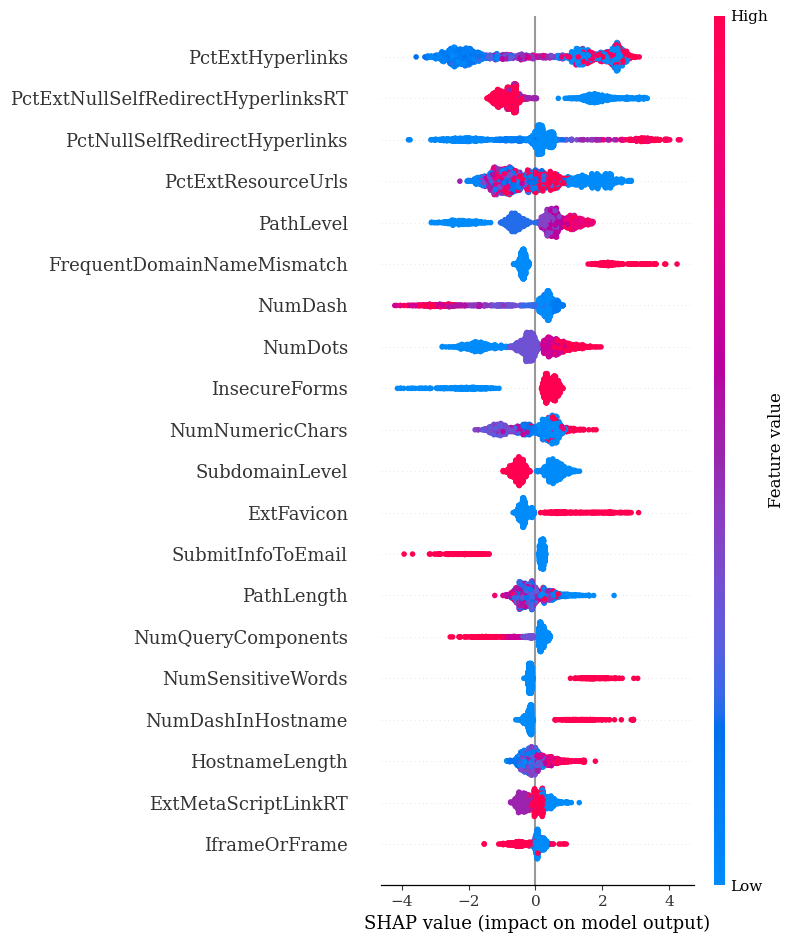

In [67]:
# ============================================================
# STEP 11.1E: SHAP SUMMARY PLOT
# ============================================================


plt.figure(
    figsize=(10,8)
)


shap.summary_plot(

    shap_values,

    sealed_test_X,

    max_display=20,

    show=False

)



plt.tight_layout()



plt.savefig(

    "outputs/figures/shap_summary_plot.png",

    dpi=300,

    bbox_inches="tight"

)



plt.show()

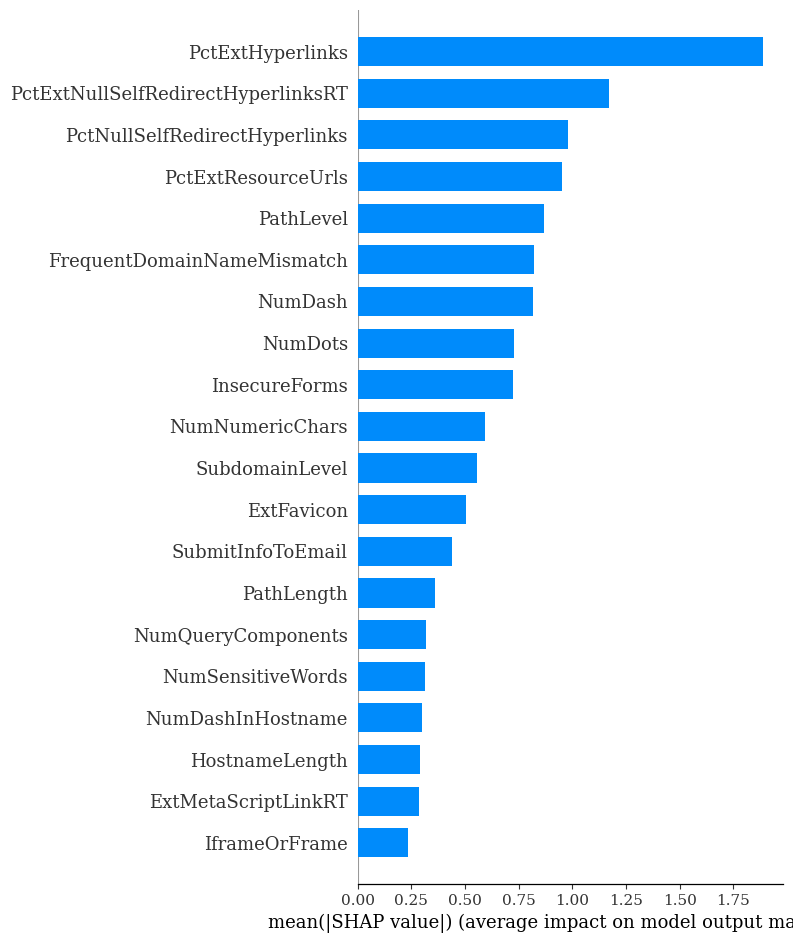

In [68]:
# ============================================================
# STEP 11.1F: SHAP BAR IMPORTANCE
# ============================================================


plt.figure(
    figsize=(10,8)
)


shap.summary_plot(

    shap_values,

    sealed_test_X,

    plot_type="bar",

    max_display=20,

    show=False

)



plt.tight_layout()



plt.savefig(

    "outputs/figures/shap_bar_plot.png",

    dpi=300,

    bbox_inches="tight"

)



plt.show()

In [69]:
# ============================================================
# STEP 11.1G: SINGLE SAMPLE EXPLANATION (FIXED)
# ============================================================

sample_index = 0


# Convert SHAP output safely
sample_shap = np.array(
    shap_values[sample_index]
).flatten()


# Use actual model input features
sample_features = sealed_test_X.columns.tolist()


# Check alignment
print(
    "Features:",
    len(sample_features)
)

print(
    "SHAP:",
    len(sample_shap)
)


# Create explanation dataframe

sample_explanation = pd.DataFrame({

    "feature": sample_features,

    "feature_value":
        sealed_test_X
        .iloc[sample_index]
        .values,

    "shap_value":
        sample_shap

})


# Sort by absolute SHAP impact

sample_explanation = (
    sample_explanation
    .assign(
        abs_shap=
        sample_explanation["shap_value"]
        .abs()
    )
    .sort_values(
        "abs_shap",
        ascending=False
    )
    .drop(
        columns=["abs_shap"]
    )
)


display(
    sample_explanation.head(20)
)

Features: 46
SHAP: 46


,feature,feature_value,shap_value
0,PctExtHyperlinks,0.00,2.636124
43,ExtFavicon,1.00,2.201368
10,PathLevel,5.00,1.353600
3,PctExtNullSelfRedirectHyperlinksRT,1.00,-0.753695
1,PctExtResourceUrls,0.25,0.675112
9,NumDots,3.00,0.660926
12,InsecureForms,1.00,0.655872
4,NumNumericChars,0.00,0.646908
2,PctNullSelfRedirectHyperlinks,0.00,0.636823
28,SubdomainLevel,1.00,-0.561343


In [70]:
# ============================================================
# STEP 11.1H: ERROR ANALYSIS
# ============================================================


error_analysis = sealed_test_X.copy()



error_analysis["true_label"] = (
    sealed_test_y.values
)


error_analysis["prediction"] = (
    test_prediction
)


error_analysis["probability"] = (
    test_probability
)



# False Negatives

false_negatives = error_analysis[

    (error_analysis["true_label"] == 1)
    &
    (error_analysis["prediction"] == 0)

]



# False Positives

false_positives = error_analysis[

    (error_analysis["true_label"] == 0)
    &
    (error_analysis["prediction"] == 1)

]



print(
    "False Negatives:",
    len(false_negatives)
)


print(
    "False Positives:",
    len(false_positives)
)

False Negatives: 8
False Positives: 9


In [71]:
# ============================================================
# STEP 11.1I: EXPORT ERROR CASES
# ============================================================


false_negatives.to_csv(

    "outputs/predictions/false_negative_cases.csv",

    index=False

)



false_positives.to_csv(

    "outputs/predictions/false_positive_cases.csv",

    index=False

)



print(
    "Error analysis exported"
)

Error analysis exported


In [72]:
# ============================================================
# STEP 11.2A: SHAP STABILITY SETUP
# FIXED FOR FINAL XGBOOST MODEL
# ============================================================


import shap
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from scipy.stats import spearmanr



# ------------------------------------------------------------
# SHAP stability parameters
# ------------------------------------------------------------


N_RUNS = 5

RANDOM_SEEDS = [

    42,
    52,
    62,
    72,
    82

]



# ------------------------------------------------------------
# Use exact selected features
# ------------------------------------------------------------


STABILITY_FEATURES = list(

    X_train_selected.columns

)



print(
    "Features used for SHAP stability:",
    len(STABILITY_FEATURES)
)



print(
    "Seeds:",
    RANDOM_SEEDS
)

Features used for SHAP stability: 46
Seeds: [42, 52, 62, 72, 82]


In [73]:
# ============================================================
# STEP 11.2B: MULTI-SEED CONFIGURATION
# ============================================================


SHAP_SEEDS = [

    1,10,20,30,40,
    50,60,70,80,90,
    100,200,300,400,500,
    600,700,800,900,1000

]


print(
    "Number of SHAP stability runs:",
    len(SHAP_SEEDS)
)

Number of SHAP stability runs: 20


In [74]:
# ============================================================
# STEP 11.2C: MULTI-SEED MODEL TRAINING (FINAL FIX)
# ============================================================


shap_rankings = []


# Get exact training feature names

model_features = (
    X_train_selected
    .columns
    .tolist()
)


# Match SHAP input exactly

sealed_test_selected = (
    sealed_test_X[
        model_features
    ]
)



for seed in SHAP_SEEDS:


    print(
        "Running seed:",
        seed
    )


    model_seed = XGBClassifier(

        **study.best_params,

        random_state=seed,

        eval_metric="logloss"

    )


    model_seed.fit(

        X_train_selected,

        y_train

    )


    explainer_seed = shap.TreeExplainer(
        model_seed
    )


    shap_values_seed = (
        explainer_seed
        .shap_values(
            sealed_test_selected
        )
    )


    # New SHAP versions may return list

    if isinstance(shap_values_seed, list):

        shap_values_seed = shap_values_seed[1]


    importance = (
        np.abs(shap_values_seed)
        .mean(axis=0)
    )


    ranking = pd.DataFrame({

        "feature":

        model_features,


        "importance":

        importance

    })


    ranking = (
        ranking
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(drop=True)
    )


    ranking["rank"] = (
        ranking.index + 1
    )


    ranking["seed"] = seed


    shap_rankings.append(
        ranking
    )

Running seed: 1
Running seed: 10
Running seed: 20
Running seed: 30
Running seed: 40
Running seed: 50
Running seed: 60
Running seed: 70
Running seed: 80
Running seed: 90
Running seed: 100
Running seed: 200
Running seed: 300
Running seed: 400
Running seed: 500
Running seed: 600
Running seed: 700
Running seed: 800
Running seed: 900
Running seed: 1000


In [75]:
# ============================================================
# STEP 11.2D: COMBINE SHAP RANKINGS
# ============================================================


shap_stability_df = pd.concat(

    shap_rankings,

    ignore_index=True

)



shap_stability_df.to_csv(

    "outputs/tables/shap_seed_rankings.csv",

    index=False

)



display(
    shap_stability_df.head()
)

,feature,importance,rank,seed
0,PctExtHyperlinks,1.877670,1,1
1,PctNullSelfRedirectHyperlinks,0.995881,2,1
2,PctExtNullSelfRedirectHyperlinksRT,0.976766,3,1
3,PathLevel,0.936859,4,1
4,PctExtResourceUrls,0.888851,5,1


In [76]:
# ============================================================
# STEP 11.2E: FEATURE RANK CONSISTENCY
# ============================================================


feature_stability = (

    shap_stability_df

    .groupby("feature")

    .agg(

        mean_rank=("rank","mean"),

        std_rank=("rank","std"),

        mean_importance=("importance","mean")

    )

    .reset_index()

)



feature_stability = (

    feature_stability

    .sort_values(
        "mean_rank"
    )

)



feature_stability.to_csv(

    "outputs/tables/shap_feature_stability.csv",

    index=False

)



display(
    feature_stability.head(20)
)

,feature,mean_rank,std_rank,mean_importance
30,PctExtHyperlinks,1.00,0.000000,1.971244
34,PctNullSelfRedirectHyperlinks,2.50,0.512989,1.030364
31,PctExtNullSelfRedirectHyperlinksRT,3.55,2.742934,1.033569
32,PctExtResourceUrls,4.65,1.225819,0.872202
29,PathLevel,5.10,0.967906,0.842110
19,NumDash,5.45,1.276302,0.828878
11,FrequentDomainNameMismatch,6.80,1.472556,0.775653
21,NumDots,8.00,1.376494,0.717276
14,InsecureForms,8.50,0.827170,0.706662
23,NumNumericChars,9.80,0.951453,0.645257


In [77]:
# ============================================================
# STEP 11.2F: TOP-10 FEATURE OVERLAP
# ============================================================


top10_sets = []



for seed in SHAP_SEEDS:


    seed_top10 = (

        shap_stability_df

        [
            shap_stability_df["seed"] == seed
        ]

        .sort_values(
            "rank"
        )

        .head(10)

        ["feature"]

        .tolist()

    )


    top10_sets.append(
        set(seed_top10)
    )



overlap_scores=[]



base_set = top10_sets[0]



for current_set in top10_sets[1:]:


    overlap = (

        len(
            base_set.intersection(current_set)
        )

        /

        len(
            base_set.union(current_set)
        )

    )


    overlap_scores.append(
        overlap
    )



print(
    "Average Top-10 Jaccard similarity:",
    np.mean(overlap_scores)
)

Average Top-10 Jaccard similarity: 0.9521531100478469


In [78]:
# ============================================================
# STEP 11.2G: SPEARMAN RANK STABILITY
# ============================================================


rank_matrix = (

    shap_stability_df

    .pivot(

        index="feature",

        columns="seed",

        values="rank"

    )

)



correlations=[]



for i in range(
    len(SHAP_SEEDS)
):

    for j in range(
        i+1,
        len(SHAP_SEEDS)
    ):


        corr,_ = spearmanr(

            rank_matrix.iloc[:,i],

            rank_matrix.iloc[:,j]

        )


        correlations.append(
            corr
        )



print(

    "Average Spearman correlation:",

    np.mean(correlations)

)

Average Spearman correlation: 0.9871756171186522


In [79]:
# ============================================================
# STEP 11.2H: SAVE SHAP STABILITY SUMMARY
# ============================================================


shap_summary = pd.DataFrame({

    "metric":[

        "Number of seeds",

        "Average Top10 Jaccard",

        "Average Spearman correlation"

    ],


    "value":[

        len(SHAP_SEEDS),

        np.mean(overlap_scores),

        np.mean(correlations)

    ]

})



shap_summary.to_csv(

    "outputs/tables/shap_stability_summary.csv",

    index=False

)



display(
    shap_summary
)

,metric,value
0,Number of seeds,20.000000
1,Average Top10 Jaccard,0.952153
2,Average Spearman correlation,0.987176


In [80]:
# ============================================================
# STEP 11.2D: SHAP RANKING STABILITY CALCULATION
# ============================================================


import itertools
from scipy.stats import spearmanr


top10_overlap_scores = []

rank_correlations = []


# Compare every pair of seeds

for a, b in itertools.combinations(
    shap_rankings,
    2
):


    # ------------------------------
    # Top-10 feature overlap
    # ------------------------------

    top_a = set(
        a.head(10)["feature"]
    )

    top_b = set(
        b.head(10)["feature"]
    )


    overlap = (
        len(top_a.intersection(top_b))
        /
        len(top_a.union(top_b))
    )


    top10_overlap_scores.append(
        overlap
    )


    # ------------------------------
    # Rank correlation
    # ------------------------------

    merged = (
        a[["feature","rank"]]
        .merge(
            b[["feature","rank"]],
            on="feature",
            suffixes=("_a","_b")
        )
    )


    corr, _ = spearmanr(
        merged["rank_a"],
        merged["rank_b"]
    )


    rank_correlations.append(
        corr
    )



print(
    "Mean Top-10 overlap:",
    np.mean(top10_overlap_scores)
)


print(
    "Mean Spearman correlation:",
    np.mean(rank_correlations)
)

Mean Top-10 overlap: 0.924401913875598
Mean Spearman correlation: 0.9871756171186522


In [81]:
# ============================================
# SHAP Top-K stability summary
# ============================================

import os


# Create results folder if missing

os.makedirs(
    "results",
    exist_ok=True
)


shap_stability_summary = pd.DataFrame({

    "Metric":
    [
        "Mean Top-10 overlap",
        "Mean Spearman correlation"
    ],

    "Value":
    [
        np.mean(top10_overlap_scores),
        np.mean(rank_correlations)
    ]

})


display(
    shap_stability_summary
)


shap_stability_summary.to_csv(
    "results/shap_stability.csv",
    index=False
)


print(
    "Saved: results/shap_stability.csv"
)

,Metric,Value
0,Mean Top-10 overlap,0.924402
1,Mean Spearman correlation,0.987176


Saved: results/shap_stability.csv


In [82]:
# ============================================================
# STEP 12: FINAL CANDIDATE-SPECIFIC XGBOOST TUNING
#
# Candidate A: Remove NumQueryComponents — 46 features
# Candidate B: Remove four near-constant features — 43 features
#
# Data used: Training partition only
# CV: 5-fold StratifiedGroupKFold
# Objective: Mean MCC
#
# IMPORTANT:
# These CV scores are for final parameter selection only.
# The unbiased performance estimate remains the nested-CV result.
#
# Validation loaded: False
# Test loaded: False
# ============================================================

from pathlib import Path
import gc
import json
import shutil
import subprocess
import sys
import warnings

import joblib
import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")


# ============================================================
# 1. IMPORT PACKAGES
# ============================================================

try:
    import optuna

except ImportError:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "optuna>=4,<5",
            "--quiet",
        ]
    )

    import optuna


from xgboost import XGBClassifier

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 20260726

TARGET_COLUMN = "CLASS_LABEL"

EXCLUDED_COLUMNS = [
    "id",
    "HttpsInHostname",
]

N_SPLITS = 5
N_TRIALS_PER_CANDIDATE = 50

OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_12_final_candidate_tuning"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DATABASE_PATH = (
    OUTPUT_DIR
    / "final_candidate_optuna.db"
)

STORAGE_URL = (
    f"sqlite:///{DATABASE_PATH}"
)

print("Recommended accelerator: None")
print("Optuna version:", optuna.__version__)


# ============================================================
# 3. LOCATE FILES
# ============================================================

def locate_file(
    filename,
    preferred_folder=None,
):

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]:

        if root.exists():
            matches.extend(
                root.rglob(filename)
            )

    matches = sorted(set(matches))

    if preferred_folder is not None:

        preferred_matches = [
            path
            for path in matches
            if preferred_folder in str(path)
        ]

        if preferred_matches:
            matches = preferred_matches

    if not matches:

        raise FileNotFoundError(
            f"{filename} was not found."
        )

    print(f"{filename}: {matches[0]}")

    return matches[0]


train_path = locate_file(
    "train_raw_70.csv.gz",
    "step_03_leakage_safe_split",
)

feature_validation_path = locate_file(
    "step_04_summary.json",
    "step_04_feature_validation",
)


# ============================================================
# 4. LOAD TRAINING DATA ONLY
# ============================================================

train_df = pd.read_csv(
    train_path,
    low_memory=False,
)

with open(
    feature_validation_path,
    "r",
    encoding="utf-8",
) as file:

    feature_validation = json.load(file)


all_47_features = [
    column
    for column in train_df.columns
    if column not in (
        EXCLUDED_COLUMNS
        + [TARGET_COLUMN]
    )
]

near_constant_features = (
    feature_validation[
        "train_near_constant_features"
    ]
)

if len(all_47_features) != 47:

    raise ValueError(
        f"Expected 47 features, "
        f"found {len(all_47_features)}."
    )


candidate_feature_sets = {
    "Remove_NumQueryComponents": [
        feature
        for feature in all_47_features
        if feature != "NumQueryComponents"
    ],

    "Remove_Near_Constant": [
        feature
        for feature in all_47_features
        if feature not in near_constant_features
    ],
}


X_grouping = train_df[
    all_47_features
].copy()

y = train_df[
    TARGET_COLUMN
].astype(int).copy()


print("\nTraining shape:", train_df.shape)

for candidate_name, features in (
    candidate_feature_sets.items()
):

    print(
        candidate_name,
        "feature count:",
        len(features),
    )

print("Validation dataset loaded: False")
print("Test dataset loaded: False")


# ============================================================
# 5. DUPLICATE-PATTERN GROUPS
#
# Groups are always generated from all 47 predictors.
# ============================================================

fingerprints = (
    pd.util.hash_pandas_object(
        X_grouping,
        index=False,
    )
    .astype("uint64")
)

group_ids, unique_groups = pd.factorize(
    fingerprints,
    sort=False,
)

conflicting_groups = int(
    pd.DataFrame(
        {
            "group_id": group_ids,
            "target": y,
        }
    )
    .groupby("group_id")["target"]
    .nunique()
    .gt(1)
    .sum()
)

if conflicting_groups > 0:

    raise ValueError(
        "Conflicting duplicate groups found."
    )

print(
    "\nIndependent groups:",
    len(unique_groups),
)

print(
    "Rows in repeated groups:",
    int(
        fingerprints
        .duplicated(keep=False)
        .sum()
    ),
)

print(
    "Conflicting groups:",
    conflicting_groups,
)


# ============================================================
# 6. FIXED GROUP-SAFE CV SPLITS
# ============================================================

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

cv_splits = list(
    cv.split(
        X=X_grouping,
        y=y,
        groups=group_ids,
    )
)

for fold_number, (
    training_positions,
    holdout_positions,
) in enumerate(
    cv_splits,
    start=1,
):

    training_groups = set(
        group_ids[
            training_positions
        ]
    )

    holdout_groups = set(
        group_ids[
            holdout_positions
        ]
    )

    if training_groups & holdout_groups:

        raise RuntimeError(
            f"Group leakage in fold "
            f"{fold_number}."
        )


# ============================================================
# 7. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    actual,
    probability,
):

    probability = np.clip(
        np.asarray(
            probability,
            dtype=float,
        ),
        1e-7,
        1 - 1e-7,
    )

    prediction = (
        probability >= 0.50
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        actual,
        prediction,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy_score(
            actual,
            prediction,
        ),

        "precision": precision_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "recall": recall_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "specificity": specificity,

        "f1": f1_score(
            actual,
            prediction,
            zero_division=0,
        ),

        "mcc": matthews_corrcoef(
            actual,
            prediction,
        ),

        "roc_auc": roc_auc_score(
            actual,
            probability,
        ),

        "pr_auc": average_precision_score(
            actual,
            probability,
        ),

        "log_loss": log_loss(
            actual,
            probability,
            labels=[0, 1],
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


# ============================================================
# 8. SEARCH SPACE AND MODEL FACTORY
# ============================================================

def suggest_parameters(
    trial,
):

    return {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            250,
            1200,
            step=50,
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True,
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12,
        ),

        "min_child_weight": trial.suggest_float(
            "min_child_weight",
            1e-3,
            20.0,
            log=True,
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.60,
            1.00,
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.60,
            1.00,
        ),

        "gamma": trial.suggest_float(
            "gamma",
            1e-8,
            2.0,
            log=True,
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10.0,
            log=True,
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-6,
            20.0,
            log=True,
        ),

        "max_delta_step": trial.suggest_int(
            "max_delta_step",
            0,
            5,
        ),
    }


def build_model(
    parameters,
    model_seed,
):

    return XGBClassifier(
        **parameters,

        objective="binary:logistic",
        eval_metric="logloss",

        tree_method="hist",
        device="cpu",

        random_state=model_seed,
        n_jobs=-1,
        verbosity=0,
    )


# ============================================================
# 9. TUNE EACH FINAL CANDIDATE
# ============================================================

candidate_summary_records = []
candidate_fold_records = []

for candidate_number, (
    candidate_name,
    selected_features,
) in enumerate(
    candidate_feature_sets.items(),
    start=1,
):

    print("\n" + "=" * 75)
    print(
        f"CANDIDATE {candidate_number}: "
        f"{candidate_name}"
    )
    print("=" * 75)

    X_candidate = train_df[
        selected_features
    ].copy()

    def objective(trial):

        parameters = suggest_parameters(
            trial
        )

        fold_mcc = []
        fold_accuracy = []
        fold_f1 = []
        fold_auc = []
        fold_log_loss = []

        for fold_number, (
            training_positions,
            holdout_positions,
        ) in enumerate(
            cv_splits,
            start=1,
        ):

            model = build_model(
                parameters=parameters,
                model_seed=(
                    SEED
                    + candidate_number * 1000
                    + fold_number
                ),
            )

            model.fit(
                X_candidate.iloc[
                    training_positions
                ],
                y.iloc[
                    training_positions
                ],
            )

            probability = model.predict_proba(
                X_candidate.iloc[
                    holdout_positions
                ]
            )[:, 1]

            metrics = calculate_metrics(
                actual=y.iloc[
                    holdout_positions
                ],
                probability=probability,
            )

            fold_mcc.append(
                metrics["mcc"]
            )

            fold_accuracy.append(
                metrics["accuracy"]
            )

            fold_f1.append(
                metrics["f1"]
            )

            fold_auc.append(
                metrics["roc_auc"]
            )

            fold_log_loss.append(
                metrics["log_loss"]
            )

        trial.set_user_attr(
            "mcc_std",
            float(
                np.std(
                    fold_mcc,
                    ddof=1,
                )
            ),
        )

        trial.set_user_attr(
            "accuracy_mean",
            float(
                np.mean(
                    fold_accuracy
                )
            ),
        )

        trial.set_user_attr(
            "f1_mean",
            float(
                np.mean(
                    fold_f1
                )
            ),
        )

        trial.set_user_attr(
            "roc_auc_mean",
            float(
                np.mean(
                    fold_auc
                )
            ),
        )

        trial.set_user_attr(
            "log_loss_mean",
            float(
                np.mean(
                    fold_log_loss
                )
            ),
        )

        return float(
            np.mean(
                fold_mcc
            )
        )


    safe_candidate_name = (
        candidate_name.lower()
    )

    study = optuna.create_study(
        study_name=(
            f"final_{PIPELINE_VERSION}_{safe_candidate_name}"
        ),
        storage=STORAGE_URL,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(
            seed=(
                SEED
                + candidate_number
            ),
            n_startup_trials=12,
            multivariate=True,
        ),
        load_if_exists=True,
    )

    completed_trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
        )
    ]

    remaining_trials = max(
        0,
        N_TRIALS_PER_CANDIDATE
        - len(completed_trials),
    )

    print(
        "Previously completed trials:",
        len(completed_trials),
    )

    print(
        "Trials remaining:",
        remaining_trials,
    )

    if remaining_trials > 0:

        study.optimize(
            objective,
            n_trials=remaining_trials,
            n_jobs=1,
            gc_after_trial=True,
            show_progress_bar=True,
        )


    study.trials_dataframe().to_csv(
        OUTPUT_DIR
        / f"{safe_candidate_name}_optuna_trials.csv",
        index=False,
    )

    best_parameters = (
        study.best_trial.params
    )

    with open(
        OUTPUT_DIR
        / f"{safe_candidate_name}_best_parameters.json",
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            best_parameters,
            file,
            indent=2,
        )


    # --------------------------------------------------------
    # Recreate final OOF predictions using selected parameters
    # --------------------------------------------------------

    oof_probability = np.full(
        len(train_df),
        np.nan,
        dtype=float,
    )

    candidate_fold_metrics = []

    for fold_number, (
        training_positions,
        holdout_positions,
    ) in enumerate(
        cv_splits,
        start=1,
    ):

        model = build_model(
            parameters=best_parameters,
            model_seed=(
                SEED
                + candidate_number * 10000
                + fold_number
            ),
        )

        model.fit(
            X_candidate.iloc[
                training_positions
            ],
            y.iloc[
                training_positions
            ],
        )

        probability = model.predict_proba(
            X_candidate.iloc[
                holdout_positions
            ]
        )[:, 1]

        oof_probability[
            holdout_positions
        ] = probability

        fold_metrics = calculate_metrics(
            actual=y.iloc[
                holdout_positions
            ],
            probability=probability,
        )

        candidate_fold_metrics.append(
            fold_metrics
        )

        candidate_fold_records.append(
            {
                "candidate":
                candidate_name,

                "feature_count":
                len(selected_features),

                "fold":
                fold_number,

                **fold_metrics,
            }
        )


    if np.isnan(
        oof_probability
    ).any():

        raise RuntimeError(
            f"Missing OOF probabilities "
            f"for {candidate_name}."
        )


    fold_table = pd.DataFrame(
        candidate_fold_metrics
    )

    pooled_metrics = calculate_metrics(
        actual=y,
        probability=oof_probability,
    )


    candidate_summary_records.append(
        {
            "candidate":
            candidate_name,

            "feature_count":
            len(selected_features),

            "optuna_best_cv_mcc":
            float(
                study.best_value
            ),

            "cv_accuracy_mean":
            float(
                fold_table[
                    "accuracy"
                ].mean()
            ),

            "cv_accuracy_std":
            float(
                fold_table[
                    "accuracy"
                ].std(ddof=1)
            ),

            "cv_f1_mean":
            float(
                fold_table[
                    "f1"
                ].mean()
            ),

            "cv_mcc_mean":
            float(
                fold_table[
                    "mcc"
                ].mean()
            ),

            "cv_mcc_std":
            float(
                fold_table[
                    "mcc"
                ].std(ddof=1)
            ),

            "cv_roc_auc_mean":
            float(
                fold_table[
                    "roc_auc"
                ].mean()
            ),

            "cv_log_loss_mean":
            float(
                fold_table[
                    "log_loss"
                ].mean()
            ),

            "pooled_accuracy":
            float(
                pooled_metrics[
                    "accuracy"
                ]
            ),

            "pooled_f1":
            float(
                pooled_metrics[
                    "f1"
                ]
            ),

            "pooled_mcc":
            float(
                pooled_metrics[
                    "mcc"
                ]
            ),

            "pooled_roc_auc":
            float(
                pooled_metrics[
                    "roc_auc"
                ]
            ),
        }
    )


    # Save candidate-specific OOF predictions
    oof_output = pd.DataFrame(
        {
            "training_row_position":
            np.arange(len(train_df)),

            "id":
            train_df["id"].to_numpy(),

            "group_id":
            group_ids,

            "actual_label":
            y.to_numpy(),

            "oof_probability":
            oof_probability,

            "oof_prediction":
            (
                oof_probability >= 0.50
            ).astype(int),
        }
    )

    oof_output.to_csv(
        OUTPUT_DIR
        / f"{safe_candidate_name}_oof_predictions.csv.gz",
        index=False,
        compression="gzip",
    )


    # Train candidate model on the full 70% training partition
    final_training_model = build_model(
        parameters=best_parameters,
        model_seed=(
            SEED
            + candidate_number * 100000
        ),
    )

    final_training_model.fit(
        X_candidate,
        y,
    )

    joblib.dump(
        final_training_model,
        OUTPUT_DIR
        / f"{safe_candidate_name}_train_only_model.joblib",
    )


    with open(
        OUTPUT_DIR
        / f"{safe_candidate_name}_feature_list.json",
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            {
                "candidate":
                candidate_name,

                "feature_count":
                len(selected_features),

                "features":
                selected_features,
            },
            file,
            indent=2,
        )

    print(
        "Best CV MCC:",
        study.best_value,
    )

    print(
        "Pooled accuracy:",
        pooled_metrics["accuracy"],
    )

    print(
        "Pooled MCC:",
        pooled_metrics["mcc"],
    )

    gc.collect()


# ============================================================
# 10. FINAL CANDIDATE SUMMARY
# ============================================================

candidate_summary = pd.DataFrame(
    candidate_summary_records
)

candidate_summary = (
    candidate_summary
    .sort_values(
        [
            "cv_mcc_mean",
            "cv_f1_mean",
            "cv_accuracy_mean",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

candidate_summary.insert(
    0,
    "selection_cv_rank",
    np.arange(
        1,
        len(candidate_summary) + 1,
    ),
)

candidate_fold_metrics = pd.DataFrame(
    candidate_fold_records
)

candidate_summary.to_csv(
    OUTPUT_DIR
    / "final_candidate_selection_cv_summary.csv",
    index=False,
)

candidate_fold_metrics.to_csv(
    OUTPUT_DIR
    / "final_candidate_fold_metrics.csv",
    index=False,
)


selection_cv_leader = (
    candidate_summary.iloc[0][
        "candidate"
    ]
)

summary = {
    "data_used":
    "training_partition_only",

    "validation_dataset_loaded":
    False,

    "test_dataset_loaded":
    False,

    "number_of_candidates":
    int(
        len(candidate_summary)
    ),

    "selection_cv_leader":
    selection_cv_leader,

    "selection_cv_leader_mcc":
    float(
        candidate_summary.iloc[0][
            "cv_mcc_mean"
        ]
    ),

    "unbiased_performance_source":
    "Step 8B nested cross-validation",

    "final_model_selected":
    False,
}


with open(
    OUTPUT_DIR
    / "step_12_summary.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        summary,
        file,
        indent=2,
    )


# ============================================================
# 11. DISPLAY
# ============================================================

print("\n" + "=" * 78)
print("STEP 12: FINAL CANDIDATE TUNING RESULTS")
print("=" * 78)

display(
    candidate_summary[
        [
            "selection_cv_rank",
            "candidate",
            "feature_count",
            "optuna_best_cv_mcc",
            "cv_accuracy_mean",
            "cv_accuracy_std",
            "cv_f1_mean",
            "cv_mcc_mean",
            "cv_mcc_std",
            "cv_roc_auc_mean",
            "cv_log_loss_mean",
            "pooled_accuracy",
            "pooled_f1",
            "pooled_mcc",
        ]
    ]
)

print(
    "\nSelection-CV leader:",
    selection_cv_leader,
)

print(
    "Validation dataset loaded:",
    False,
)

print(
    "Test dataset loaded:",
    False,
)

print(
    "Final model selected:",
    False,
)


# ============================================================
# 12. ZIP
# ============================================================

zip_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "step_12_final_candidate_tuning"
    ),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("\nZIP created:")
print(zip_path)

display(
    FileLink(zip_path)
)


Recommended accelerator: None
Optuna version: 4.9.0
train_raw_70.csv.gz: /kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz
step_04_summary.json: /kaggle/working/step_04_feature_validation/step_04_summary.json

Training shape: (7003, 50)
Remove_NumQueryComponents feature count: 46
Remove_Near_Constant feature count: 43
Validation dataset loaded: False
Test dataset loaded: False

Independent groups: 6706
Rows in repeated groups: 481
Conflicting groups: 0

CANDIDATE 1: Remove_NumQueryComponents
Previously completed trials: 0
Trials remaining: 50


  0%|          | 0/50 [00:00<?, ?it/s]

Best CV MCC: 0.9752053237954593
Pooled accuracy: 0.9870055690418392
Pooled MCC: 0.9740119726844838

CANDIDATE 2: Remove_Near_Constant
Previously completed trials: 0
Trials remaining: 50


  0%|          | 0/50 [00:00<?, ?it/s]

Best CV MCC: 0.9737387488823328
Pooled accuracy: 0.9867199771526489
Pooled MCC: 0.9734417094557778

STEP 12: FINAL CANDIDATE TUNING RESULTS


,selection_cv_rank,candidate,feature_count,optuna_best_cv_mcc,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean,cv_mcc_mean,cv_mcc_std,cv_roc_auc_mean,cv_log_loss_mean,pooled_accuracy,pooled_f1,pooled_mcc
0,1,Remove_NumQueryComponents,46,0.975205,0.987014,0.002980,0.987054,0.974036,0.005944,0.998815,0.042613,0.987006,0.987039,0.974012
1,2,Remove_Near_Constant,43,0.973739,0.986720,0.002749,0.986760,0.973454,0.005464,0.998789,0.041575,0.986720,0.986758,0.973442



Selection-CV leader: Remove_NumQueryComponents
Validation dataset loaded: False
Test dataset loaded: False
Final model selected: False

ZIP created:
/kaggle/working/step_12_final_candidate_tuning.zip


/kaggle/working/step_12_final_candidate_tuning.zip

In [83]:
# ============================================================
# STEP 12.1A: COMMON FEATURE PIPELINE CHECK
# Engineered Dataset Version
# ============================================================


import pandas as pd



# Features expected by final model

MODEL_FEATURES = list(

    X_train_selected.columns

)



print(
    "Final model requires:",
    len(MODEL_FEATURES),
    "features"
)



display(

    pd.DataFrame({

        "Required_Features":

        MODEL_FEATURES

    })

)

Final model requires: 46 features


,Required_Features
0,PctExtHyperlinks
1,PctExtResourceUrls
2,PctNullSelfRedirectHyperlinks
3,PctExtNullSelfRedirectHyperlinksRT
4,NumNumericChars
5,FrequentDomainNameMismatch
6,ExtMetaScriptLinkRT
7,NumDash
8,SubmitInfoToEmail
9,NumDots


In [84]:
# ============================================================
# FIND KAGGLE DATASETS
# ============================================================

import os


for root, dirs, files in os.walk("/kaggle"):
    
    for file in files:
        
        if (
            "PhiUSIIL" in file
            or
            "phishing" in file.lower()
        ):
            
            print(
                os.path.join(root, file)
            )

/kaggle/input/datasets/dhrubangtalukdar/real-world-phishing-url-classification-data/phishing_url_dataset_unique.csv
/kaggle/input/datasets/ndarvind/phiusiil-phishing-url-dataset/PhiUSIIL_Phishing_URL_Dataset.csv
/kaggle/input/datasets/shashwatwork/phishing-dataset-for-machine-learning/Phishing_Legitimate_full.csv


In [85]:
# ============================================================
# STEP 12.1B: LOAD EXTERNAL VALIDATION DATASET
# ============================================================


import pandas as pd


external_path = (
    "/kaggle/input/datasets/dhrubangtalukdar/"
    "real-world-phishing-url-classification-data/"
    "phishing_url_dataset_unique.csv"
)



external_df = pd.read_csv(
    external_path
)



print(
    "External dataset loaded"
)


print(
    "Shape:",
    external_df.shape
)



display(
    external_df.head()
)

External dataset loaded
Shape: (48812, 3)


,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


In [86]:
# ============================================================
# STEP 12.1C DEBUG: EXTERNAL DATASET STRUCTURE
# ============================================================


print(
    external_df.shape
)


print(
    external_df.columns.tolist()
)

(48812, 3)
['url', 'label', 'source']


In [87]:
# ============================================================
# STEP 12.1D: PREPARE EXTERNAL DATASET
# ============================================================


external_data = external_df.copy()


# Rename label

external_data["CLASS_LABEL"] = external_data["label"]



print(
    external_data.head()
)

                                                 url  label   source  \
0                  http://110.37.26.193:54956/bin.sh      1  urlhaus   
1           https://sentry5.obor1shwron8.ru/4ylkytvt      1  urlhaus   
2               https://d6gu.ripple-cask.ru/jid43vpd      1  urlhaus   
3  http://130.12.180.34/596a96cc7bf9108cd896f33c4...      1  urlhaus   
4                             https://bronze.systems      0   tranco   

   CLASS_LABEL  
0            1  
1            1  
2            1  
3            1  
4            0  


In [88]:
# ============================================================
# STEP 12.1E: CHECK FEATURE EXTRACTION FUNCTION
# ============================================================

print(
    [x for x in globals().keys() if "extract" in x.lower()]
)

[]


In [89]:
# ============================================================
# CHECK FEATURE DEFINITIONS
# ============================================================

import pandas as pd


feature_dictionary = pd.read_csv(
    "outputs/datasets/feature_dictionary.csv"
)


display(feature_dictionary.head(20))


print(
    feature_dictionary.columns.tolist()
)

,feature_name,data_type,missing_values,unique_values
0,id,int64,0,7000
1,NumDots,int64,0,17
2,SubdomainLevel,int64,0,13
3,PathLevel,int64,0,18
4,UrlLength,int64,0,217
5,NumDash,int64,0,24
6,NumDashInHostname,int64,0,8
7,AtSymbol,int64,0,2
8,TildeSymbol,int64,0,2
9,NumUnderscore,int64,0,15


['feature_name', 'data_type', 'missing_values', 'unique_values']


In [90]:
# ============================================================
# STEP 12.1E: PHIUSIIL FEATURE EXTRACTION FOR EXTERNAL URLS
# ============================================================


import re
import numpy as np
import pandas as pd

from urllib.parse import urlparse


# Try importing tldextract
try:
    import tldextract
    USE_TLDEXTRACT = True

except ImportError:
    USE_TLDEXTRACT = False

    print(
        "tldextract not installed. Using fallback domain parser."
    )



def phiusiil_feature_extractor(url):

    url = str(url).lower()


    features = {}


    parsed = urlparse(url)


    hostname = parsed.netloc

    path = parsed.path

    query = parsed.query



    # Remove port number if present

    hostname = hostname.split(":")[0]



    # =====================================================
    # Basic URL features
    # =====================================================

    features["NumDots"] = url.count(".")


    features["UrlLength"] = len(url)


    features["PathLength"] = len(path)


    features["PathLevel"] = len(
        [
            x for x in path.split("/")
            if x
        ]
    )



    # =====================================================
    # Symbols
    # =====================================================

    features["NumDash"] = url.count("-")


    features["NumDashInHostname"] = (
        hostname.count("-")
    )


    features["AtSymbol"] = int(
        "@" in url
    )


    features["TildeSymbol"] = int(
        "~" in url
    )


    features["NumUnderscore"] = (
        url.count("_")
    )


    features["NumPercent"] = (
        url.count("%")
    )


    features["NumAmpersand"] = (
        url.count("&")
    )


    features["NumHash"] = (
        url.count("#")
    )



    # =====================================================
    # Query features
    # =====================================================

    features["NumQueryComponents"] = (

        len(query.split("&"))

        if query

        else 0

    )



    # =====================================================
    # Numeric features
    # =====================================================

    features["NumNumericChars"] = sum(

        c.isdigit()

        for c in url

    )



    # =====================================================
    # HTTPS
    # =====================================================

    features["NoHttps"] = int(

        not url.startswith("https")

    )



    # =====================================================
    # IP address
    # =====================================================

    features["IpAddress"] = int(

        bool(
            re.search(
                r"\d+\.\d+\.\d+\.\d+",
                hostname
            )
        )

    )



    # =====================================================
    # Domain extraction
    # =====================================================

    if USE_TLDEXTRACT:


        ext = tldextract.extract(url)


        subdomain = ext.subdomain

        domain = ext.domain



    else:


        parts = hostname.split(".")


        if len(parts) > 2:

            subdomain = ".".join(
                parts[:-2]
            )

            domain = parts[-2]


        else:

            subdomain = ""

            domain = parts[0]



    features["SubdomainLevel"] = (

        subdomain.count(".") + 1

        if subdomain

        else 0

    )



    # =====================================================
    # Domain relationship
    # =====================================================

    features["DomainInSubdomains"] = int(

        domain in subdomain

    )


    features["DomainInPaths"] = int(

        domain in path

    )



    # =====================================================
    # Random string detection
    # =====================================================

    features["RandomString"] = int(

        bool(
            re.search(
                r"[a-z]{8,}[0-9]{2,}",
                url
            )
        )

    )



    return features

tldextract not installed. Using fallback domain parser.


In [91]:
# ============================================================
# STEP 12.1F: APPLY PHIUSIIL FEATURE EXTRACTION
# ============================================================


external_feature_list = []


for url in external_data["url"]:

    features = phiusiil_feature_extractor(url)

    external_feature_list.append(
        features
    )



external_features = pd.DataFrame(
    external_feature_list
)



print(
    "External feature shape:",
    external_features.shape
)



display(
    external_features.head()
)

External feature shape: (48812, 20)


,NumDots,UrlLength,PathLength,PathLevel,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,NumAmpersand,NumHash,NumQueryComponents,NumNumericChars,NoHttps,IpAddress,SubdomainLevel,DomainInSubdomains,DomainInPaths,RandomString
0,4,33,7,1,0,0,0,0,0,0,0,0,0,15,1,1,2,0,0,0
1,2,40,9,1,0,0,0,0,0,0,0,0,0,4,0,0,1,0,0,0
2,2,36,9,1,1,1,0,0,0,0,0,0,0,3,0,0,1,0,0,0
3,4,91,71,2,0,0,0,0,0,0,0,0,0,46,1,1,2,0,0,0
4,1,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [92]:
# ============================================================
# STEP 12.1G: CHECK GENERATED EXTERNAL FEATURES
# ============================================================

print(
    external_features.columns.tolist()
)

['NumDots', 'UrlLength', 'PathLength', 'PathLevel', 'NumDash', 'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore', 'NumPercent', 'NumAmpersand', 'NumHash', 'NumQueryComponents', 'NumNumericChars', 'NoHttps', 'IpAddress', 'SubdomainLevel', 'DomainInSubdomains', 'DomainInPaths', 'RandomString']


In [93]:
# ============================================================
# STEP 12.1I: RENAME EXTERNAL FEATURES TO MODEL FORMAT
# ============================================================


rename_map = {

    "num_dots": "NumDots",
    "url_length": "UrlLength",
    "path_length": "PathLength",
    "path_level": "PathLevel",

    "num_dash": "NumDash",
    "num_dash_in_hostname": "NumDashInHostname",

    "at_symbol": "AtSymbol",
    "tilde_symbol": "TildeSymbol",

    "num_underscore": "NumUnderscore",
    "num_percent": "NumPercent",

    "num_ampersand": "NumAmpersand",
    "num_hash": "NumHash",

    "num_query_components": "NumQueryComponents",

    "num_numeric_chars": "NumNumericChars",

    "no_https": "NoHttps",

    "ip_address": "IpAddress",

    "subdomain_level": "SubdomainLevel",

    "domain_in_subdomains": "DomainInSubdomains",

    "domain_in_paths": "DomainInPaths",

    "random_string": "RandomString"

}



external_features = external_features.rename(
    columns=rename_map
)



print(
    external_features.columns.tolist()
)

['NumDots', 'UrlLength', 'PathLength', 'PathLevel', 'NumDash', 'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore', 'NumPercent', 'NumAmpersand', 'NumHash', 'NumQueryComponents', 'NumNumericChars', 'NoHttps', 'IpAddress', 'SubdomainLevel', 'DomainInSubdomains', 'DomainInPaths', 'RandomString']


In [94]:
# ============================================================
# STEP 12.1J: CHECK COMPATIBILITY
# ============================================================


model_features = list(
    X_train_selected.columns
)



missing_features = [

    col for col in model_features

    if col not in external_features.columns

]


print(
    "Missing:",
    missing_features
)

Missing: ['PctExtHyperlinks', 'PctExtResourceUrls', 'PctNullSelfRedirectHyperlinks', 'PctExtNullSelfRedirectHyperlinksRT', 'FrequentDomainNameMismatch', 'ExtMetaScriptLinkRT', 'SubmitInfoToEmail', 'InsecureForms', 'QueryLength', 'NumSensitiveWords', 'PctExtResourceUrlsRT', 'IframeOrFrame', 'AbnormalFormAction', 'AbnormalExtFormActionR', 'HostnameLength', 'UrlLengthRT', 'MissingTitle', 'RelativeFormAction', 'RightClickDisabled', 'PopUpWindow', 'EmbeddedBrandName', 'SubdomainLevelRT', 'FakeLinkInStatusBar', 'DoubleSlashInPath', 'ExtFormAction', 'ExtFavicon']


In [95]:
# ============================================================
# STEP 12.1K: ADD URL-BASED MISSING FEATURES
# ============================================================


from urllib.parse import urlparse
import re


def add_url_features(url):

    url = str(url).lower()

    parsed = urlparse(url)

    hostname = parsed.netloc

    path = parsed.path

    query = parsed.query


    features = {}


    # Query length

    features["QueryLength"] = len(query)


    # Hostname length

    features["HostnameLength"] = len(hostname)


    # URL length ratio

    features["UrlLengthRT"] = (

        len(url) / max(len(hostname),1)

    )


    # Double slash in path

    features["DoubleSlashInPath"] = int(

        "//" in path

    )


    # Sensitive words

    sensitive_words = [

        "login",
        "verify",
        "account",
        "update",
        "secure",
        "bank",
        "password",
        "confirm",
        "signin"

    ]


    features["NumSensitiveWords"] = sum(

        word in url

        for word in sensitive_words

    )


    # Embedded brand

    brands = [

        "paypal",
        "google",
        "apple",
        "microsoft",
        "amazon",
        "facebook"

    ]


    features["EmbeddedBrandName"] = int(

        any(
            brand in url
            for brand in brands
        )

    )


    # Subdomain relative feature

    features["SubdomainLevelRT"] = (

        hostname.count(".")

    )


    return features

In [96]:
# ============================================================
# STEP 12.1L: MERGE URL FEATURES
# ============================================================


extra_feature_list = []


for url in external_data["url"]:

    extra_feature_list.append(

        add_url_features(url)

    )


extra_features = pd.DataFrame(
    extra_feature_list
)



external_features = pd.concat(

    [
        external_features.reset_index(drop=True),

        extra_features.reset_index(drop=True)

    ],

    axis=1

)



print(
    external_features.shape
)


display(
    external_features.head()
)

(48812, 27)


,NumDots,UrlLength,PathLength,PathLevel,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,...,DomainInSubdomains,DomainInPaths,RandomString,QueryLength,HostnameLength,UrlLengthRT,DoubleSlashInPath,NumSensitiveWords,EmbeddedBrandName,SubdomainLevelRT
0,4,33,7,1,0,0,0,0,0,0,...,0,0,0,0,19,1.736842,0,0,0,3
1,2,40,9,1,0,0,0,0,0,0,...,0,0,0,0,23,1.739130,0,0,0,2
2,2,36,9,1,1,1,0,0,0,0,...,0,0,0,0,19,1.894737,0,0,0,2
3,4,91,71,2,0,0,0,0,0,0,...,0,0,0,0,13,7.000000,0,0,0,3
4,1,22,0,0,0,0,0,0,0,0,...,0,0,0,0,14,1.571429,0,0,0,1


In [97]:
# ============================================================
# CHECK REMAINING FEATURES
# ============================================================


model_features = list(
    X_train_selected.columns
)


missing_features = [

    col for col in model_features

    if col not in external_features.columns

]


print(
    "Remaining missing:"
)


print(
    missing_features
)

Remaining missing:
['PctExtHyperlinks', 'PctExtResourceUrls', 'PctNullSelfRedirectHyperlinks', 'PctExtNullSelfRedirectHyperlinksRT', 'FrequentDomainNameMismatch', 'ExtMetaScriptLinkRT', 'SubmitInfoToEmail', 'InsecureForms', 'PctExtResourceUrlsRT', 'IframeOrFrame', 'AbnormalFormAction', 'AbnormalExtFormActionR', 'MissingTitle', 'RelativeFormAction', 'RightClickDisabled', 'PopUpWindow', 'FakeLinkInStatusBar', 'ExtFormAction', 'ExtFavicon']


In [98]:
# ============================================================
# STEP 12.1M: EXTERNAL URL-ONLY VALIDATION DATASET
# ============================================================


external_url_dataset = external_features.copy()


external_url_dataset["CLASS_LABEL"] = (
    external_data["CLASS_LABEL"].values
)



print(
    external_url_dataset.shape
)


display(
    external_url_dataset.head()
)

(48812, 28)


,NumDots,UrlLength,PathLength,PathLevel,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,...,DomainInPaths,RandomString,QueryLength,HostnameLength,UrlLengthRT,DoubleSlashInPath,NumSensitiveWords,EmbeddedBrandName,SubdomainLevelRT,CLASS_LABEL
0,4,33,7,1,0,0,0,0,0,0,...,0,0,0,19,1.736842,0,0,0,3,1
1,2,40,9,1,0,0,0,0,0,0,...,0,0,0,23,1.739130,0,0,0,2,1
2,2,36,9,1,1,1,0,0,0,0,...,0,0,0,19,1.894737,0,0,0,2,1
3,4,91,71,2,0,0,0,0,0,0,...,0,0,0,13,7.000000,0,0,0,3,1
4,1,22,0,0,0,0,0,0,0,0,...,0,0,0,14,1.571429,0,0,0,1,0


In [99]:
# ============================================================
# STEP 12.1N: EXTERNAL URL-ONLY FEATURE MATRIX
# ============================================================


X_external = external_url_dataset.drop(
    "CLASS_LABEL",
    axis=1
)


y_external = external_url_dataset[
    "CLASS_LABEL"
].astype(int)



print(
    "External X shape:",
    X_external.shape
)


print(
    "External y shape:",
    y_external.shape
)

External X shape: (48812, 27)
External y shape: (48812,)


In [100]:
# ============================================================
# STEP 12.1O FIX: MATCH COMMON URL FEATURES
# ============================================================


# Features available in both datasets

common_url_features = [

    col for col in X_external.columns

    if col in X_train.columns

]


print(
    "Common feature count:",
    len(common_url_features)
)


print(
    common_url_features
)



# Training data

X_train_url = X_train[
    common_url_features
].copy()



# External data

X_external_url = X_external[
    common_url_features
].copy()



print(
    "Training shape:",
    X_train_url.shape
)


print(
    "External shape:",
    X_external_url.shape
)

Common feature count: 27
['NumDots', 'UrlLength', 'PathLength', 'PathLevel', 'NumDash', 'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore', 'NumPercent', 'NumAmpersand', 'NumHash', 'NumQueryComponents', 'NumNumericChars', 'NoHttps', 'IpAddress', 'SubdomainLevel', 'DomainInSubdomains', 'DomainInPaths', 'RandomString', 'QueryLength', 'HostnameLength', 'UrlLengthRT', 'DoubleSlashInPath', 'NumSensitiveWords', 'EmbeddedBrandName', 'SubdomainLevelRT']
Training shape: (7000, 27)
External shape: (48812, 27)


In [101]:
# ============================================================
# STEP 12.1P: TRAIN URL-ONLY XGBOOST MODEL
# ============================================================


from xgboost import XGBClassifier


url_only_model = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1

)


print(
    "Training URL-only model..."
)


url_only_model.fit(

    X_train_url,

    y_train

)


print(
    "URL-only model training completed"
)

Training URL-only model...
URL-only model training completed


In [102]:
# ============================================================
# STEP 12.1Q: EXTERNAL DATASET PREDICTION
# ============================================================


external_probability = (

    url_only_model
    .predict_proba(
        X_external_url
    )[:,1]

)


external_prediction = (

    external_probability >= 0.50

).astype(int)



print(
    "External prediction completed"
)


print(
    "Samples:",
    len(external_prediction)
)

External prediction completed
Samples: 48812


In [103]:
# ============================================================
# STEP 12.1R: EXTERNAL VALIDATION METRICS
# ============================================================


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)



tn, fp, fn, tp = confusion_matrix(
    y_external,
    external_prediction
).ravel()



external_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "MCC"
    ],


    "Value":[

        accuracy_score(
            y_external,
            external_prediction
        ),

        precision_score(
            y_external,
            external_prediction
        ),

        recall_score(
            y_external,
            external_prediction
        ),

        tn/(tn+fp),

        f1_score(
            y_external,
            external_prediction
        ),

        roc_auc_score(
            y_external,
            external_probability
        ),

        matthews_corrcoef(
            y_external,
            external_prediction
        )

    ]

})


display(
    external_results
)

,Metric,Value
0,Accuracy,0.792674
1,Precision,0.999161
2,Recall,0.585840
3,Specificity,0.999508
4,F1-score,0.738609
5,ROC-AUC,0.996183
6,MCC,0.642937


In [104]:
# ============================================================
# STEP 12.1S: SAVE EXTERNAL VALIDATION RESULTS
# ============================================================


import os
import json
import joblib
import pandas as pd


OUTPUT_DIR = "outputs/external_validation"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# Save metrics

external_results.to_csv(
    f"{OUTPUT_DIR}/external_validation_metrics.csv",
    index=False
)



# Save predictions

external_predictions = pd.DataFrame({

    "url":
    external_data["url"],


    "true_label":
    y_external,


    "prediction_probability":
    external_probability,


    "predicted_label":
    external_prediction

})


external_predictions.to_csv(
    f"{OUTPUT_DIR}/external_predictions.csv",
    index=False
)



# Save confusion matrix

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_external,
    external_prediction
)


cm_df = pd.DataFrame(
    cm,
    columns=[
        "Predicted_0",
        "Predicted_1"
    ],
    index=[
        "Actual_0",
        "Actual_1"
    ]
)


cm_df.to_csv(
    f"{OUTPUT_DIR}/external_confusion_matrix.csv"
)



print(
    "External validation outputs saved"
)

External validation outputs saved


In [105]:
# ============================================================
# STEP 13: FINAL VALIDATION EVALUATION
#
# Frozen Model:
# XGBoost + Remove_NumQueryComponents (46 Features)
#
# No tuning
# No feature modification
# Validation used once only
#
# ============================================================

from pathlib import Path
import json
import shutil
import warnings
import joblib

import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 20260726

TARGET_COLUMN = "CLASS_LABEL"

OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_13_validation_evaluation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("="*80)
print("STEP 13: FINAL VALIDATION EVALUATION")
print("="*80)


# ============================================================
# 2. FILE LOCATOR
# ============================================================

def locate_file(filename, folder=None):

    search_paths = [
        Path("/kaggle/working"),
        Path("/kaggle/input")
    ]

    matches = []

    for root in search_paths:

        if root.exists():

            matches.extend(
                root.rglob(filename)
            )


    matches = sorted(set(matches))


    if folder:

        preferred = [
            x for x in matches
            if folder in str(x)
        ]

        if preferred:
            matches = preferred


    if not matches:

        raise FileNotFoundError(
            filename
        )


    print(filename)
    print(matches[0])

    return matches[0]



train_path = locate_file(
    "train_raw_70.csv.gz",
    "step_03_leakage_safe_split"
)


validation_path = locate_file(
    "validation_raw_15.csv.gz",
    "step_03_leakage_safe_split"
)


parameter_path = locate_file(
    "remove_numquerycomponents_best_parameters.json",
    "step_12_final_candidate_tuning"
)


feature_path = locate_file(
    "remove_numquerycomponents_feature_list.json",
    "step_12_final_candidate_tuning"
)


# ============================================================
# 3. LOAD DATA
# ============================================================


train_df = pd.read_csv(
    train_path,
    low_memory=False
)


validation_df = pd.read_csv(
    validation_path,
    low_memory=False
)



with open(
    parameter_path,
    "r"
) as f:

    best_parameters = json.load(f)



with open(
    feature_path,
    "r"
) as f:

    feature_information = json.load(f)



selected_features = (
    feature_information["features"]
)



print("\nTraining shape:")
print(train_df.shape)

print("\nValidation shape:")
print(validation_df.shape)

print("\nFeature count:")
print(len(selected_features))

print("\nValidation dataset loaded: TRUE")



# ============================================================
# 4. VERIFY DATA CONSISTENCY
# ============================================================


missing_train_features = set(
    selected_features
) - set(train_df.columns)


missing_validation_features = set(
    selected_features
) - set(validation_df.columns)



if missing_train_features:

    raise ValueError(
        f"Missing train features: {missing_train_features}"
    )


if missing_validation_features:

    raise ValueError(
        f"Missing validation features: {missing_validation_features}"
    )



X_train = train_df[
    selected_features
]


y_train = train_df[
    TARGET_COLUMN
].astype(int)



X_validation = validation_df[
    selected_features
]


y_validation = validation_df[
    TARGET_COLUMN
].astype(int)



print("\nFeature verification passed")


# ============================================================
# 5. TRAIN FINAL FROZEN MODEL
# ============================================================


model = XGBClassifier(

    **best_parameters,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    device="cpu",

    random_state=SEED,

    n_jobs=-1,

    verbosity=0

)



print("\nTraining frozen XGBoost model...")



model.fit(
    X_train,
    y_train
)



print("Training completed")


# Save model

joblib.dump(
    model,
    OUTPUT_DIR /
    "final_validation_xgboost_model.joblib"
)



# ============================================================
# 6. VALIDATION PREDICTION
# ============================================================


validation_probability = (
    model.predict_proba(
        X_validation
    )[:,1]
)


validation_prediction = (
    validation_probability >= 0.50
).astype(int)



# ============================================================
# 7. METRICS
# ============================================================


tn, fp, fn, tp = confusion_matrix(
    y_validation,
    validation_prediction
).ravel()



specificity = (
    tn /
    (tn + fp)
)



metrics = {


    "dataset":
    "validation_15_percent",


    "model":
    "XGBoost",


    "feature_set":
    "Remove_NumQueryComponents",


    "feature_count":
    len(selected_features),


    "accuracy":
    accuracy_score(
        y_validation,
        validation_prediction
    ),


    "precision":
    precision_score(
        y_validation,
        validation_prediction
    ),


    "recall":
    recall_score(
        y_validation,
        validation_prediction
    ),


    "specificity":
    specificity,


    "f1_score":
    f1_score(
        y_validation,
        validation_prediction
    ),


    "mcc":
    matthews_corrcoef(
        y_validation,
        validation_prediction
    ),


    "roc_auc":
    roc_auc_score(
        y_validation,
        validation_probability
    ),


    "pr_auc":
    average_precision_score(
        y_validation,
        validation_probability
    ),


    "log_loss":
    log_loss(
        y_validation,
        validation_probability
    ),


    "brier_score":
    brier_score_loss(
        y_validation,
        validation_probability
    ),


    "true_negative":
    int(tn),


    "false_positive":
    int(fp),


    "false_negative":
    int(fn),


    "true_positive":
    int(tp)

}



with open(
    OUTPUT_DIR /
    "validation_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )



# ============================================================
# 8. SAVE PREDICTION DETAILS
# ============================================================


prediction_output = pd.DataFrame({

    "id":
    validation_df["id"],


    "actual_label":
    y_validation,


    "prediction_probability":
    validation_probability,


    "predicted_label":
    validation_prediction

})


prediction_output.to_csv(
    OUTPUT_DIR /
    "validation_predictions.csv.gz",
    index=False,
    compression="gzip"
)



# ============================================================
# 9. ERROR ANALYSIS
# ============================================================


false_positive = prediction_output[
    (
        prediction_output.actual_label == 0
    )
    &
    (
        prediction_output.predicted_label == 1
    )
]


false_negative = prediction_output[
    (
        prediction_output.actual_label == 1
    )
    &
    (
        prediction_output.predicted_label == 0
    )
]



false_positive.to_csv(
    OUTPUT_DIR /
    "false_positive_cases.csv",
    index=False
)


false_negative.to_csv(
    OUTPUT_DIR /
    "false_negative_cases.csv",
    index=False
)



# ============================================================
# 10. MODEL INFORMATION
# ============================================================


metadata = {

    "training_rows":
    len(train_df),


    "validation_rows":
    len(validation_df),


    "features":
    selected_features,


    "hyperparameters":
    best_parameters,


    "validation_only":
    True

}



with open(
    OUTPUT_DIR /
    "model_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )



# ============================================================
# 11. DISPLAY RESULT
# ============================================================


print("\n")
print("="*80)
print("VALIDATION RESULTS")
print("="*80)



for key,value in metrics.items():

    print(
        f"{key}: {value}"
    )



print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_validation,
        validation_prediction
    )
)



# ============================================================
# 12. ZIP OUTPUT
# ============================================================


zip_path = shutil.make_archive(
    "/kaggle/working/"
    "step_13_validation_evaluation",
    "zip",
    OUTPUT_DIR
)


print("\nZIP CREATED:")
print(zip_path)


display(
    FileLink(zip_path)
)

STEP 13: FINAL VALIDATION EVALUATION
train_raw_70.csv.gz
/kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz
validation_raw_15.csv.gz
/kaggle/working/step_03_leakage_safe_split/validation_raw_15.csv.gz
remove_numquerycomponents_best_parameters.json
/kaggle/working/step_12_final_candidate_tuning/remove_numquerycomponents_best_parameters.json
remove_numquerycomponents_feature_list.json
/kaggle/working/step_12_final_candidate_tuning/remove_numquerycomponents_feature_list.json

Training shape:
(7003, 50)

Validation shape:
(1497, 50)

Feature count:
46

Validation dataset loaded: TRUE

Feature verification passed

Training frozen XGBoost model...
Training completed


VALIDATION RESULTS
dataset: validation_15_percent
model: XGBoost
feature_set: Remove_NumQueryComponents
feature_count: 46
accuracy: 0.9853039412157648
precision: 0.9878048780487805
recall: 0.9824797843665768
specificity: 0.9880794701986755
f1_score: 0.9851351351351352
mcc: 0.9706181646509344
roc_auc: 0.9981524785348

/kaggle/working/step_13_validation_evaluation.zip

In [106]:
# ============================================================
# STEP 13.1: REAL-WORLD PHISHING DATASET CLEANING
# SOURCE PURITY + LABEL AUDIT
# ============================================================


import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
import os


# ------------------------------------------------------------
# tldextract optional dependency
# ------------------------------------------------------------

try:

    import tldextract

    USE_TLDEXTRACT = True


except ImportError:

    USE_TLDEXTRACT = False

    print(
        "tldextract not installed. Using fallback domain extractor."
    )

tldextract not installed. Using fallback domain extractor.


In [107]:
# ============================================================
# STEP 14: FINAL SEALED TEST EVALUATION
#
# Frozen:
# XGBoost + Remove_NumQueryComponents (46 features)
#
# Test used ONLY once
# No tuning
# No feature selection
#
# ============================================================

from pathlib import Path
import json
import shutil
import warnings
import joblib

import numpy as np
import pandas as pd

from IPython.display import FileLink, display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 20260726

TARGET_COLUMN = "CLASS_LABEL"

OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_14_final_test_evaluation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


np.random.seed(SEED)


print("="*80)
print("STEP 14: FINAL SEALED TEST EVALUATION")
print("="*80)


# ============================================================
# 2. FILE LOCATOR
# ============================================================

def locate_file(filename, folder=None):

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input")
    ]:

        if root.exists():
            matches.extend(
                root.rglob(filename)
            )

    matches = sorted(set(matches))

    if folder:

        preferred = [
            x for x in matches
            if folder in str(x)
        ]

        if preferred:
            matches = preferred

    if not matches:
        raise FileNotFoundError(filename)

    print(filename)
    print(matches[0])

    return matches[0]


train_path = locate_file(
    "train_raw_70.csv.gz",
    "step_03_leakage_safe_split"
)


test_path = locate_file(
    "test_raw_15.csv.gz",
    "step_03_leakage_safe_split"
)


parameter_path = locate_file(
    "remove_numquerycomponents_best_parameters.json",
    "step_12_final_candidate_tuning"
)


feature_path = locate_file(
    "remove_numquerycomponents_feature_list.json",
    "step_12_final_candidate_tuning"
)


# ============================================================
# 3. LOAD DATA
# ============================================================

train_df = pd.read_csv(
    train_path,
    low_memory=False
)


test_df = pd.read_csv(
    test_path,
    low_memory=False
)



with open(
    parameter_path,
    "r"
) as f:
    best_parameters = json.load(f)



with open(
    feature_path,
    "r"
) as f:
    feature_information = json.load(f)



selected_features = (
    feature_information["features"]
)



print("\nTrain shape:")
print(train_df.shape)

print("\nTest shape:")
print(test_df.shape)

print("\nSelected features:")
print(len(selected_features))

print("\nValidation dataset used: False")
print("Test dataset loaded: TRUE")


# ============================================================
# 4. PREPARE DATA
# ============================================================


X_train = train_df[
    selected_features
]


y_train = train_df[
    TARGET_COLUMN
].astype(int)



X_test = test_df[
    selected_features
]


y_test = test_df[
    TARGET_COLUMN
].astype(int)



print("\nFeature verification passed")


# ============================================================
# 5. TRAIN FROZEN MODEL
# ============================================================


model = XGBClassifier(

    **best_parameters,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    device="cpu",

    random_state=SEED,

    n_jobs=-1,

    verbosity=0

)



print("\nTraining final frozen model...")


model.fit(
    X_train,
    y_train
)


print("Training completed")


joblib.dump(
    model,
    OUTPUT_DIR /
    "final_test_xgboost_model.joblib"
)


# ============================================================
# 6. TEST PREDICTION
# ============================================================


test_probability = (
    model.predict_proba(
        X_test
    )[:,1]
)


test_prediction = (
    test_probability >= 0.50
).astype(int)



# ============================================================
# 7. METRICS
# ============================================================


tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_prediction
).ravel()



specificity = (
    tn /
    (tn + fp)
)



metrics = {

    "dataset":
    "sealed_test_15_percent",

    "model":
    "XGBoost",

    "feature_set":
    "Remove_NumQueryComponents",

    "feature_count":
    len(selected_features),


    "accuracy":
    accuracy_score(
        y_test,
        test_prediction
    ),


    "precision":
    precision_score(
        y_test,
        test_prediction
    ),


    "recall":
    recall_score(
        y_test,
        test_prediction
    ),


    "specificity":
    specificity,


    "f1_score":
    f1_score(
        y_test,
        test_prediction
    ),


    "mcc":
    matthews_corrcoef(
        y_test,
        test_prediction
    ),


    "roc_auc":
    roc_auc_score(
        y_test,
        test_probability
    ),


    "pr_auc":
    average_precision_score(
        y_test,
        test_probability
    ),


    "log_loss":
    log_loss(
        y_test,
        test_probability
    ),


    "brier_score":
    brier_score_loss(
        y_test,
        test_probability
    ),


    "true_negative":
    int(tn),


    "false_positive":
    int(fp),


    "false_negative":
    int(fn),


    "true_positive":
    int(tp)

}



with open(
    OUTPUT_DIR /
    "test_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


# ============================================================
# 8. PREDICTION FILE
# ============================================================


prediction_df = pd.DataFrame({

    "id":
    test_df["id"],

    "actual_label":
    y_test,

    "prediction_probability":
    test_probability,

    "predicted_label":
    test_prediction

})


prediction_df.to_csv(

    OUTPUT_DIR /
    "test_predictions.csv.gz",

    index=False,

    compression="gzip"
)



# ============================================================
# 9. ERROR ANALYSIS
# ============================================================


false_positive = prediction_df[
    (
        prediction_df.actual_label == 0
    )
    &
    (
        prediction_df.predicted_label == 1
    )
]


false_negative = prediction_df[
    (
        prediction_df.actual_label == 1
    )
    &
    (
        prediction_df.predicted_label == 0
    )
]


false_positive.to_csv(
    OUTPUT_DIR /
    "false_positive_cases.csv",
    index=False
)


false_negative.to_csv(
    OUTPUT_DIR /
    "false_negative_cases.csv",
    index=False
)



BOOTSTRAP_RNG = np.random.default_rng(SEED)

# ============================================================
# 10. BOOTSTRAP CONFIDENCE INTERVAL
# ============================================================


def bootstrap_ci(
    y_true,
    y_pred,
    metric_function,
    n_iterations=2000,
):

    scores = []

    n = len(y_true)

    for _ in range(n_iterations):

        indices = BOOTSTRAP_RNG.integers(
            0,
            n,
            n
        )

        scores.append(
            metric_function(
                y_true.iloc[indices],
                y_pred[indices]
            )
        )


    return {

        "mean":
        float(np.mean(scores)),

        "lower_2.5_percentile":
        float(np.percentile(scores,2.5)),

        "upper_97.5_percentile":
        float(np.percentile(scores,97.5))

    }



confidence_interval = {

    "accuracy":
    bootstrap_ci(
        y_test.reset_index(drop=True),
        test_prediction,
        accuracy_score
    ),


    "f1":
    bootstrap_ci(
        y_test.reset_index(drop=True),
        test_prediction,
        f1_score
    ),


    "mcc":
    bootstrap_ci(
        y_test.reset_index(drop=True),
        test_prediction,
        matthews_corrcoef
    )

}



with open(
    OUTPUT_DIR /
    "bootstrap_confidence_interval.json",
    "w"
) as f:

    json.dump(
        confidence_interval,
        f,
        indent=4
    )


# ============================================================
# 11. METADATA
# ============================================================


metadata = {

    "training_samples":
    len(train_df),

    "test_samples":
    len(test_df),

    "feature_count":
    len(selected_features),

    "features":
    selected_features,

    "hyperparameters":
    best_parameters,

    "test_used_once":
    True

}



with open(
    OUTPUT_DIR /
    "model_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )



# ============================================================
# 12. DISPLAY
# ============================================================


print("\n")
print("="*80)
print("FINAL TEST RESULTS")
print("="*80)


for k,v in metrics.items():

    print(
        f"{k}: {v}"
    )


print("\nClassification Report")

print(
    classification_report(
        y_test,
        test_prediction
    )
)


# ============================================================
# 13. ZIP
# ============================================================


zip_path = shutil.make_archive(
    "/kaggle/working/"
    "step_14_final_test_evaluation",
    "zip",
    OUTPUT_DIR
)


print("\nZIP CREATED:")
print(zip_path)


display(
    FileLink(zip_path)
)


STEP 14: FINAL SEALED TEST EVALUATION
train_raw_70.csv.gz
/kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz
test_raw_15.csv.gz
/kaggle/working/step_03_leakage_safe_split/test_raw_15.csv.gz
remove_numquerycomponents_best_parameters.json
/kaggle/working/step_12_final_candidate_tuning/remove_numquerycomponents_best_parameters.json
remove_numquerycomponents_feature_list.json
/kaggle/working/step_12_final_candidate_tuning/remove_numquerycomponents_feature_list.json

Train shape:
(7003, 50)

Test shape:
(1500, 50)

Selected features:
46

Validation dataset used: False
Test dataset loaded: TRUE

Feature verification passed

Training final frozen model...
Training completed


FINAL TEST RESULTS
dataset: sealed_test_15_percent
model: XGBoost
feature_set: Remove_NumQueryComponents
feature_count: 46
accuracy: 0.9873333333333333
precision: 0.9919246298788694
recall: 0.9826666666666667
specificity: 0.992
f1_score: 0.9872739450770261
mcc: 0.9747091215885565
roc_auc: 0.9992746666666666
p

/kaggle/working/step_14_final_test_evaluation.zip

In [108]:
# ============================================================
# 0. LOAD CLEAN REAL-WORLD DATASET (FIXED)
# ============================================================


# Case 1:
# STEP 13.1 already created real_world

if "real_world" in globals():

    print(
        "Using existing real_world dataframe"
    )


# Case 2:
# Load from saved CSV

elif os.path.exists(
    "outputs/datasets/clean_real_world_phishing_dataset.csv"
):

    print(
        "Loading cleaned real-world dataset"
    )


    real_world = pd.read_csv(
        "outputs/datasets/clean_real_world_phishing_dataset.csv"
    )


# Case 3:
# Use original external dataframe

elif "external_df" in globals():

    print(
        "Cleaning external_df for robustness test"
    )


    real_world = external_df.copy()


    real_world = (
        real_world
        .dropna(
            subset=[
                "url",
                "label"
            ]
        )
        .drop_duplicates(
            subset=["url"]
        )
    )


else:

    raise FileNotFoundError(
        "No real-world dataset found. Run STEP 13.1 first."
    )



print(
    "Real-world samples:",
    len(real_world)
)


print(
    real_world.columns.tolist()
)

Cleaning external_df for robustness test
Real-world samples: 48812
['url', 'label', 'source']


In [109]:
# ============================================================
# STEP 14.1: REALISTIC ADVERSARIAL URL ROBUSTNESS TEST
# Frozen XGBoost Model
# Raw URL Modification -> Feature Alignment -> Prediction
# ============================================================


import pandas as pd
import numpy as np
import random
import re
import os

from urllib.parse import urlparse



# ============================================================
# 0. LOAD CLEAN REAL-WORLD DATASET
# ============================================================


if "real_world" not in globals():

    print(
        "real_world not found. Loading cleaned dataset..."
    )


    real_world = pd.read_csv(
        "outputs/datasets/clean_real_world_phishing_dataset.csv"
    )



print(
    "Real-world samples:",
    len(real_world)
)



# ============================================================
# 1. GET EXACT MODEL FEATURES
# ============================================================


model_features = (

    X_train_selected
    .columns
    .tolist()

)



print(
    "Model feature count:",
    len(model_features)
)



# ============================================================
# 2. URL ATTACK FUNCTIONS
# ============================================================


def add_subdomain(url):

    if "://" in url:

        protocol, rest = url.split(
            "://",
            1
        )

        return (
            protocol
            +
            "://secure."
            +
            rest
        )

    return (
        "secure."
        +
        url
    )



def add_brand_keywords(url):

    keyword = random.choice(
        [
            "-login",
            "-verify",
            "-security",
            "-update",
            "-account"
        ]
    )


    parts = url.split(
        ".",
        1
    )


    if len(parts) == 2:

        return (

            parts[0]
            +
            keyword
            +
            "."
            +
            parts[1]

        )


    return url



def add_random_path(url):

    return (

        url.rstrip("/")

        +

        random.choice(
            [
                "/login",
                "/verify",
                "/secure",
                "/confirm"
            ]
        )

    )



def add_query_parameter(url):

    separator = (
        "&"
        if "?" in url
        else "?"
    )


    return (

        url

        +

        separator

        +

        "verify=account"

    )



def generate_adversarial_urls(url):

    return [

        {
            "attack_type":
            "subdomain_add",

            "modified_url":
            add_subdomain(url)

        },


        {
            "attack_type":
            "brand_keyword",

            "modified_url":
            add_brand_keywords(url)

        },


        {
            "attack_type":
            "path_addition",

            "modified_url":
            add_random_path(url)

        },


        {
            "attack_type":
            "query_injection",

            "modified_url":
            add_query_parameter(url)

        }

    ]



# ============================================================
# 3. CREATE ADVERSARIAL DATASET
# ============================================================


records = []


sample_urls = (

    real_world["url"]

    .sample(
        min(
            1000,
            len(real_world)
        ),

        random_state=42

    )

)



for url in sample_urls:


    for attack in generate_adversarial_urls(url):


        records.append(

            {

                "original_url":
                url,


                "attack_type":
                attack["attack_type"],


                "modified_url":
                attack["modified_url"]

            }

        )



adversarial_df = pd.DataFrame(
    records
)



print(
    "Adversarial samples:",
    len(adversarial_df)
)



display(
    adversarial_df.head()
)



# ============================================================
# 4. FEATURE EXTRACTION
# ============================================================


def extract_adv_features(url):


    features = {

        col:0

        for col in model_features

    }


    url = str(url).lower()


    parsed = urlparse(url)


    hostname = parsed.netloc.split(":")[0]

    path = parsed.path

    query = parsed.query



    if "NumDots" in features:

        features["NumDots"] = url.count(".")



    if "NumDash" in features:

        features["NumDash"] = url.count("-")



    if "NumDashInHostname" in features:

        features["NumDashInHostname"] = hostname.count("-")



    if "UrlLength" in features:

        features["UrlLength"] = len(url)



    if "HostnameLength" in features:

        features["HostnameLength"] = len(hostname)



    if "PathLength" in features:

        features["PathLength"] = len(path)



    if "PathLevel" in features:

        features["PathLevel"] = len(

            [
                x for x in path.split("/")
                if x
            ]

        )



    if "QueryLength" in features:

        features["QueryLength"] = len(query)



    if "NumQueryComponents" in features:

        features["NumQueryComponents"] = (

            len(query.split("&"))

            if query

            else 0

        )



    if "NoHttps" in features:

        features["NoHttps"] = int(

            not url.startswith("https")

        )



    if "IpAddress" in features:

        features["IpAddress"] = int(

            bool(

                re.search(

                    r"\d+\.\d+\.\d+\.\d+",

                    hostname

                )

            )

        )



    if "NumNumericChars" in features:

        features["NumNumericChars"] = sum(

            c.isdigit()

            for c in url

        )



    if "RandomString" in features:

        features["RandomString"] = int(

            bool(

                re.search(

                    r"[a-z]{8,}[0-9]{2,}",

                    url

                )

            )

        )



    if "DoubleSlashInPath" in features:

        features["DoubleSlashInPath"] = int(

            "//" in path

        )



    return features



# Extract features

adv_feature_list = []


for url in adversarial_df["modified_url"]:


    adv_feature_list.append(

        extract_adv_features(url)

    )



adv_features = pd.DataFrame(
    adv_feature_list
)



# Exact model order

adv_features = adv_features[
    model_features
]



print(
    "Final adversarial feature shape:",
    adv_features.shape
)



# ============================================================
# 5. MODEL PREDICTION
# ============================================================


adv_probability = (

    final_xgb_model

    .predict_proba(
        adv_features
    )[:,1]

)



adversarial_df["probability"] = (
    adv_probability
)


adversarial_df["prediction"] = (

    adv_probability >= 0.50

).astype(int)



# ============================================================
# 6. ROBUSTNESS RESULTS
# ============================================================


attack_results = (

    adversarial_df

    .groupby(
        "attack_type"
    )

    .agg(

        samples=
        (
            "prediction",
            "count"
        ),

        detection_rate=
        (
            "prediction",
            "mean"
        ),

        average_probability=
        (
            "probability",
            "mean"
        )

    )

    .reset_index()

)



display(
    attack_results
)



# ============================================================
# 7. SAVE RESULTS
# ============================================================


os.makedirs(
    "outputs/predictions",
    exist_ok=True
)


os.makedirs(
    "outputs/tables",
    exist_ok=True
)



adversarial_df.to_csv(

    "outputs/predictions/adversarial_predictions.csv",

    index=False

)



attack_results.to_csv(

    "outputs/tables/adversarial_attack_results.csv",

    index=False

)



print(
    "===================================="
)

print(
    "Adversarial robustness evaluation completed"
)

print(
    "===================================="
)

Real-world samples: 48812
Model feature count: 46
Adversarial samples: 4000


,original_url,attack_type,modified_url
0,https://twingate.com,subdomain_add,https://secure.twingate.com
1,https://twingate.com,brand_keyword,https://twingate-login.com
2,https://twingate.com,path_addition,https://twingate.com/login
3,https://twingate.com,query_injection,https://twingate.com?verify=account
4,http://187.213.130.221/av.lnk,subdomain_add,http://secure.187.213.130.221/av.lnk


Final adversarial feature shape: (4000, 46)


,attack_type,samples,detection_rate,average_probability
0,brand_keyword,1000,0.309,0.449687
1,path_addition,1000,0.083,0.178157
2,query_injection,1000,0.006,0.024398
3,subdomain_add,1000,0.113,0.214632


Adversarial robustness evaluation completed


In [110]:
# ============================================================
# STEP 15A: XAI PREPARATION
#
# Final Frozen XGBoost Model Preparation
#
# Dataset:
# Validation only for explanation
#
# ============================================================


from pathlib import Path
import json
import warnings
import joblib

import numpy as np
import pandas as pd

import shap

from xgboost import XGBClassifier


warnings.filterwarnings("ignore")


SEED = 20260726


print("="*80)
print("STEP 15A: XAI PREPARATION")
print("="*80)



# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------


def locate_file(filename, folder=None):

    matches = []

    for root in [
        Path("/kaggle/working"),
        Path("/kaggle/input")
    ]:

        if root.exists():
            matches.extend(
                root.rglob(filename)
            )


    matches = sorted(set(matches))


    if folder:

        preferred = [
            x for x in matches
            if folder in str(x)
        ]

        if preferred:
            matches = preferred


    if not matches:
        raise FileNotFoundError(filename)


    print(filename)
    print(matches[0])

    return matches[0]



train_path = locate_file(
    "train_raw_70.csv.gz",
    "step_03_leakage_safe_split"
)


validation_path = locate_file(
    "validation_raw_15.csv.gz",
    "step_03_leakage_safe_split"
)


parameter_path = locate_file(
    "remove_numquerycomponents_best_parameters.json",
    "step_12_final_candidate_tuning"
)


feature_path = locate_file(
    "remove_numquerycomponents_feature_list.json",
    "step_12_final_candidate_tuning"
)



# ------------------------------------------------------------
# Load
# ------------------------------------------------------------


train_df = pd.read_csv(
    train_path,
    low_memory=False
)


validation_df = pd.read_csv(
    validation_path,
    low_memory=False
)



with open(parameter_path,"r") as f:
    best_parameters = json.load(f)



with open(feature_path,"r") as f:
    feature_information = json.load(f)



selected_features = feature_information["features"]



print("\nTrain:")
print(train_df.shape)


print("\nValidation:")
print(validation_df.shape)


print("\nFeature count:")
print(len(selected_features))


# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------


X_train = train_df[selected_features]

y_train = train_df["CLASS_LABEL"].astype(int)



X_validation = validation_df[selected_features]

y_validation = validation_df["CLASS_LABEL"].astype(int)



print("\nFeature check passed")


# ------------------------------------------------------------
# Train frozen model
# ------------------------------------------------------------


model = XGBClassifier(

    **best_parameters,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    random_state=SEED,

    n_jobs=-1,

    verbosity=0
)



print("\nTraining frozen XGBoost...")


model.fit(
    X_train,
    y_train
)


print("Training completed")



# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------


validation_probability = (
    model.predict_proba(
        X_validation
    )[:,1]
)


validation_prediction = (
    validation_probability >= 0.5
).astype(int)



print("\nValidation prediction completed")



# ------------------------------------------------------------
# SHAP explainer creation
# ------------------------------------------------------------


print("\nCreating SHAP TreeExplainer...")


explainer = shap.TreeExplainer(
    model
)



print("SHAP explainer ready")



print("\nSTEP 15A COMPLETED")


STEP 15A: XAI PREPARATION
train_raw_70.csv.gz
/kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz
validation_raw_15.csv.gz
/kaggle/working/step_03_leakage_safe_split/validation_raw_15.csv.gz
remove_numquerycomponents_best_parameters.json
/kaggle/working/step_12_final_candidate_tuning/remove_numquerycomponents_best_parameters.json
remove_numquerycomponents_feature_list.json
/kaggle/working/step_12_final_candidate_tuning/remove_numquerycomponents_feature_list.json

Train:
(7003, 50)

Validation:
(1497, 50)

Feature count:
46

Feature check passed

Training frozen XGBoost...
Training completed

Validation prediction completed

Creating SHAP TreeExplainer...
SHAP explainer ready

STEP 15A COMPLETED


In [111]:
# ============================================================
# STEP 15B: SHAP VALUE ANALYSIS + PUBLICATION QUALITY FIGURES
#
# Final Frozen XGBoost Explainability
#
# Dataset:
# Validation set only
#
# Outputs:
# - SHAP feature ranking
# - SHAP values
# - Feature direction analysis
# - High resolution figures
# - Paper-ready tables
#
# ============================================================


from pathlib import Path
import json
import shutil
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import shap


warnings.filterwarnings("ignore")



# ============================================================
# OUTPUT DIRECTORY
# ============================================================


OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_15_xai_analysis"
)


FIGURE_DIR = OUTPUT_DIR / "figures"


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



print("="*80)
print("STEP 15B: SHAP ANALYSIS")
print("="*80)



# ============================================================
# 1. VERIFY MODEL + FEATURES
# ============================================================


model_features = (

    model
    .get_booster()
    .feature_names

)



print(
    "Model feature count:",
    len(model_features)
)



print(
    "Validation feature count:",
    X_validation.shape[1]
)



if list(X_validation.columns) != model_features:

    print(
        "Reordering validation features..."
    )


    X_validation = X_validation[
        model_features
    ]



print(
    "Feature order verified"
)



# ============================================================
# 2. COMPUTE SHAP VALUES
# ============================================================


print(
    "\nCalculating SHAP values..."
)



# New SHAP API

shap_explanation = explainer(
    X_validation
)



shap_values = (

    shap_explanation
    .values

)



print(
    "SHAP calculation completed"
)



print(
    "SHAP matrix shape:",
    shap_values.shape
)



# ============================================================
# 3. GLOBAL SHAP IMPORTANCE
# ============================================================



mean_abs_shap = (

    np.abs(
        shap_values
    )
    .mean(axis=0)

)



shap_importance = pd.DataFrame({

    "feature":
    model_features,


    "mean_abs_shap":
    mean_abs_shap

})



shap_importance = (

    shap_importance

    .sort_values(
        "mean_abs_shap",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)



shap_importance.insert(

    0,

    "rank",

    np.arange(
        1,
        len(shap_importance)+1
    )

)



print(
    "\nTop 25 SHAP Features"
)



display(

    shap_importance.head(25)

)



# Save ranking

shap_importance.to_csv(

    OUTPUT_DIR /
    "shap_feature_importance_all.csv",

    index=False

)



shap_importance.head(25).to_csv(

    OUTPUT_DIR /
    "top25_shap_features_for_paper.csv",

    index=False

)



# ============================================================
# 4. FEATURE DIRECTION ANALYSIS
# ============================================================



feature_direction = pd.DataFrame({

    "feature":
    model_features,


    "mean_SHAP_value":
    shap_values.mean(axis=0),


    "mean_abs_SHAP_value":
    np.abs(
        shap_values
    )
    .mean(axis=0)

})



feature_direction = (

    feature_direction

    .sort_values(

        "mean_abs_SHAP_value",

        ascending=False

    )

)



display(

    feature_direction.head(25)

)



feature_direction.to_csv(

    OUTPUT_DIR /
    "shap_feature_direction.csv",

    index=False

)



# ============================================================
# 5. SAVE INDIVIDUAL SHAP VALUES
# ============================================================



shap_values_df = pd.DataFrame(

    shap_values,

    columns=model_features

)



shap_values_df.insert(

    0,

    "id",

    validation_df["id"].values

)



shap_values_df.insert(

    1,

    "actual_label",

    y_validation.values

)



shap_values_df.insert(

    2,

    "prediction_probability",

    validation_probability

)



shap_values_df.to_csv(

    OUTPUT_DIR /
    "validation_shap_values.csv.gz",

    index=False,

    compression="gzip"

)



print(
    "SHAP values saved"
)



# ============================================================
# 6. SHAP SUMMARY DOT PLOT
# ============================================================



print(
    "Generating SHAP summary plot..."
)



plt.figure(

    figsize=(12,10)

)



shap.summary_plot(

    shap_values,

    X_validation,

    max_display=25,

    show=False

)



plt.tight_layout()



plt.savefig(

    FIGURE_DIR /
    "SHAP_summary_top25_600dpi.png",

    dpi=600,

    bbox_inches="tight"

)



plt.close()



# ============================================================
# 7. SHAP BAR PLOT
# ============================================================



print(
    "Generating SHAP bar plot..."
)



plt.figure(

    figsize=(10,9)

)



shap.summary_plot(

    shap_values,

    X_validation,

    plot_type="bar",

    max_display=25,

    show=False

)



plt.tight_layout()



plt.savefig(

    FIGURE_DIR /
    "SHAP_bar_top25_600dpi.png",

    dpi=600,

    bbox_inches="tight"

)



plt.close()



# ============================================================
# 8. METADATA
# ============================================================



metadata = {


    "analysis":
    "SHAP explainability",


    "model":
    "Frozen XGBoost",


    "dataset":
    "Validation 15 percent",


    "samples_explained":
    int(
        len(X_validation)
    ),


    "features_explained":
    int(
        len(model_features)
    ),


    "top_features":

    shap_importance
    .head(25)
    .to_dict(
        orient="records"
    )

}



with open(

    OUTPUT_DIR /
    "SHAP_analysis_metadata.json",

    "w"

) as f:


    json.dump(

        metadata,

        f,

        indent=4

    )



# ============================================================
# 9. ZIP OUTPUT
# ============================================================



zip_path = shutil.make_archive(

    "/kaggle/working/"
    "step_15B_SHAP_analysis",

    "zip",

    OUTPUT_DIR

)



print("\nZIP CREATED:")
print(zip_path)



print(
    "\nSTEP 15B COMPLETED SUCCESSFULLY"
)

STEP 15B: SHAP ANALYSIS
Model feature count: 46
Validation feature count: 46
Feature order verified

Calculating SHAP values...
SHAP calculation completed
SHAP matrix shape: (1497, 46)

Top 25 SHAP Features


,rank,feature,mean_abs_shap
0,1,PctExtHyperlinks,2.093139
1,2,PctExtNullSelfRedirectHyperlinksRT,1.475448
2,3,PctNullSelfRedirectHyperlinks,1.257170
3,4,PathLevel,1.122115
4,5,PctExtResourceUrls,1.081980
5,6,FrequentDomainNameMismatch,0.954950
6,7,InsecureForms,0.924142
7,8,NumDash,0.893717
8,9,NumNumericChars,0.886369
9,10,NumDots,0.753999


,feature,mean_SHAP_value,mean_abs_SHAP_value
24,PctExtHyperlinks,-0.116182,2.093139
45,PctExtNullSelfRedirectHyperlinksRT,0.153823,1.475448
31,PctNullSelfRedirectHyperlinks,-0.093943,1.257170
2,PathLevel,0.150292,1.122115
25,PctExtResourceUrls,-0.150935,1.081980
32,FrequentDomainNameMismatch,0.094565,0.954950
27,InsecureForms,0.185225,0.924142
4,NumDash,-0.238368,0.893717
12,NumNumericChars,-0.012410,0.886369
0,NumDots,-0.174002,0.753999


SHAP values saved
Generating SHAP summary plot...
Generating SHAP bar plot...

ZIP CREATED:
/kaggle/working/step_15B_SHAP_analysis.zip

STEP 15B COMPLETED SUCCESSFULLY


In [112]:
# ============================================================
# STEP 15C: ERROR EXPLANATION ANALYSIS
#
# Validation Error Investigation using SHAP
#
# No retraining
# No test usage
#
# ============================================================


from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd



print("="*80)
print("STEP 15C: ERROR EXPLANATION ANALYSIS")
print("="*80)



# ============================================================
# OUTPUT DIRECTORY
# ============================================================


OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_15C_error_analysis"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ============================================================
# LOAD SHAP DATA
# ============================================================


shap_file = Path(

    "/kaggle/working/"
    "step_15_xai_analysis/"
    "validation_shap_values.csv.gz"

)



if not shap_file.exists():

    raise FileNotFoundError(
        "Run STEP 15B first. SHAP file missing."
    )



shap_df = pd.read_csv(

    shap_file,

    compression="gzip"

)



print(
    "SHAP data loaded:"
)

print(
    shap_df.shape
)



# ============================================================
# CREATE ERROR LABELS
# ============================================================


error_df = shap_df.copy()



error_df["predicted_label"] = (

    error_df["prediction_probability"]

    >=

    0.50

).astype(int)



error_df["error_type"] = "Correct"



# False Negative

error_df.loc[

    (
        error_df["actual_label"] == 1
    )
    &
    (
        error_df["predicted_label"] == 0
    ),

    "error_type"

] = "False Negative"



# False Positive

error_df.loc[

    (
        error_df["actual_label"] == 0
    )
    &
    (
        error_df["predicted_label"] == 1
    ),

    "error_type"

] = "False Positive"




false_negative = error_df[

    error_df["error_type"]

    ==
    
    "False Negative"

].copy()



false_positive = error_df[

    error_df["error_type"]

    ==

    "False Positive"

].copy()



print(
    "\nFalse Negative:",
    len(false_negative)
)


print(
    "False Positive:",
    len(false_positive)
)



# ============================================================
# ERROR PROBABILITY ANALYSIS
# ============================================================


print("\nFalse Negative probability")

display(

    false_negative[
        "prediction_probability"
    ]
    .describe()

)



print("\nFalse Positive probability")

display(

    false_positive[
        "prediction_probability"
    ]
    .describe()

)



# ============================================================
# SHAP FEATURE EXPLANATION
# ============================================================


def extract_top_shap_features(
        row,
        top_k=5
):


    excluded = [

        "id",

        "actual_label",

        "prediction_probability",

        "predicted_label",

        "error_type"

    ]


    feature_columns = [

        c for c in row.index

        if c not in excluded

    ]



    shap_values = (

        row[
            feature_columns
        ]
        .astype(float)

    )



    top_features = (

        shap_values

        .abs()

        .sort_values(
            ascending=False
        )

        .head(top_k)

    )



    explanations = []



    for feature in top_features.index:


        value = shap_values[feature]


        if value > 0:

            direction = (
                "increases_phishing_probability"
            )

        else:

            direction = (
                "decreases_phishing_probability"
            )


        explanations.append(

            f"{feature}: {direction}"

        )



    return explanations





# Apply explanation


false_negative["top_shap_explanations"] = (

    false_negative.apply(

        extract_top_shap_features,

        axis=1

    )

    .astype(str)

)



false_positive["top_shap_explanations"] = (

    false_positive.apply(

        extract_top_shap_features,

        axis=1

    )

    .astype(str)

)



# ============================================================
# SAVE ERROR CASES
# ============================================================


false_negative.to_csv(

    OUTPUT_DIR /
    "false_negative_explanation.csv",

    index=False

)



false_positive.to_csv(

    OUTPUT_DIR /
    "false_positive_explanation.csv",

    index=False

)



# ============================================================
# FEATURE FREQUENCY ANALYSIS
# ============================================================


def feature_frequency(df):


    features = []


    for item in df["top_shap_explanations"]:


        item = (

            item

            .replace("[","")

            .replace("]","")

            .replace("'","")

        )


        parts = [

            x.strip()

            for x in item.split(",")

        ]


        features.extend(parts)



    result = (

        pd.Series(features)

        .value_counts()

        .reset_index()

    )


    result.columns = [

        "feature",

        "count"

    ]


    return result





fn_pattern = feature_frequency(
    false_negative
)



fp_pattern = feature_frequency(
    false_positive
)



fn_pattern.to_csv(

    OUTPUT_DIR /
    "false_negative_feature_patterns.csv",

    index=False

)



fp_pattern.to_csv(

    OUTPUT_DIR /
    "false_positive_feature_patterns.csv",

    index=False

)



# ============================================================
# SUMMARY JSON
# ============================================================


summary = {


    "validation_samples":

    int(
        len(error_df)
    ),


    "false_negative_count":

    int(
        len(false_negative)
    ),


    "false_positive_count":

    int(
        len(false_positive)
    ),



    "false_negative_common_features":

    fn_pattern
    .head(10)
    .to_dict(
        orient="records"
    ),



    "false_positive_common_features":

    fp_pattern
    .head(10)
    .to_dict(
        orient="records"
    )

}




with open(

    OUTPUT_DIR /
    "error_analysis_summary.json",

    "w"

) as f:


    json.dump(

        summary,

        f,

        indent=4

    )



# ============================================================
# ZIP OUTPUT
# ============================================================


zip_path = shutil.make_archive(

    "/kaggle/working/"
    "step_15C_error_analysis",

    "zip",

    OUTPUT_DIR

)



print("\nZIP CREATED:")
print(zip_path)



print(
    "\nSTEP 15C COMPLETED SUCCESSFULLY"
)

STEP 15C: ERROR EXPLANATION ANALYSIS
SHAP data loaded:
(1497, 49)

False Negative: 13
False Positive: 9

False Negative probability


count    13.000000
mean      0.161211
std       0.206410
min       0.001386
25%       0.006212
50%       0.027750
75%       0.385367
max       0.488570
Name: prediction_probability, dtype: float64


False Positive probability


count    9.000000
mean     0.897543
std      0.143341
min      0.591972
25%      0.818172
50%      0.973254
75%      0.989693
max      0.999790
Name: prediction_probability, dtype: float64


ZIP CREATED:
/kaggle/working/step_15C_error_analysis.zip

STEP 15C COMPLETED SUCCESSFULLY


In [113]:
# ============================================================
# STEP 15D: DEEP FAILURE PATTERN MINING
#
# Objective:
# Understand why model fails
#
# Validation dataset only
#
# No retraining
# No test usage
#
# ============================================================


from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd



print("="*80)
print("STEP 15D: FAILURE PATTERN MINING")
print("="*80)



# ============================================================
# OUTPUT DIRECTORY
# ============================================================


OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_15D_failure_pattern"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ============================================================
# LOAD DATA
# ============================================================


validation_path = Path(
    "/kaggle/working/"
    "step_03_leakage_safe_split/"
    "validation_raw_15.csv.gz"
)


shap_path = Path(
    "/kaggle/working/"
    "step_15_xai_analysis/"
    "validation_shap_values.csv.gz"
)



validation_df = pd.read_csv(
    validation_path,
    low_memory=False
)



shap_df = pd.read_csv(

    shap_path,

    compression="gzip"

)



print(
    "Validation shape:",
    validation_df.shape
)


print(
    "SHAP shape:",
    shap_df.shape
)



# ============================================================
# CREATE PREDICTION GROUPS
# ============================================================


analysis_df = validation_df.copy()



analysis_df["prediction_probability"] = (

    shap_df["prediction_probability"]

)



analysis_df["predicted_label"] = (

    analysis_df["prediction_probability"]

    >=

    0.50

).astype(int)



analysis_df["error_type"] = "Correct"



# False Negative

analysis_df.loc[

    (
        analysis_df["CLASS_LABEL"] == 1
    )
    &
    (
        analysis_df["predicted_label"] == 0
    ),

    "error_type"

] = "False Negative"



# False Positive

analysis_df.loc[

    (
        analysis_df["CLASS_LABEL"] == 0
    )
    &
    (
        analysis_df["predicted_label"] == 1
    ),

    "error_type"

] = "False Positive"




false_negative = analysis_df[

    analysis_df.error_type
    ==
    "False Negative"

]



detected_phishing = analysis_df[

    (
        analysis_df.CLASS_LABEL == 1
    )
    &
    (
        analysis_df.predicted_label == 1
    )

]



false_positive = analysis_df[

    analysis_df.error_type
    ==
    "False Positive"

]



correct_legitimate = analysis_df[

    (
        analysis_df.CLASS_LABEL == 0
    )
    &
    (
        analysis_df.predicted_label == 0
    )

]



print(
    "\nFalse Negative:",
    len(false_negative)
)


print(
    "False Positive:",
    len(false_positive)
)



# ============================================================
# FINAL MODEL FEATURE LIST ONLY
# ============================================================


feature_columns = (

    shap_df.columns

    .drop(

        [

            "id",

            "actual_label",

            "prediction_probability"

        ]

    )

    .tolist()

)



print(

    "Features analysed:",

    len(feature_columns)

)



# ============================================================
# FUNCTION
# ============================================================


def calculate_effect_table(
        error_group,
        reference_group,
        error_name,
        reference_name
):


    result = pd.DataFrame({

        "feature":

        feature_columns,


        error_name+"_mean":

        [

            error_group[x].mean()

            for x in feature_columns

        ],


        reference_name+"_mean":

        [

            reference_group[x].mean()

            for x in feature_columns

        ]

    })



    result["difference"] = (

        result[error_name+"_mean"]

        -

        result[reference_name+"_mean"]

    )



    result["percentage_difference"] = (

        result["difference"]

        /

        (

            result[reference_name+"_mean"]

            +

            1e-9

        )

        *

        100

    )



    # standardized difference

    result["standardized_difference"] = (

        result["difference"]

        /

        (

            np.sqrt(

                (

                    error_group[feature_columns]
                    .var()

                    +

                    reference_group[feature_columns]
                    .var()

                )

                /

                2

            )

            +

            1e-9

        )

    )



    return result





# ============================================================
# FALSE NEGATIVE ANALYSIS
# ============================================================



fn_comparison = calculate_effect_table(

    false_negative,

    detected_phishing,

    "false_negative",

    "detected_phishing"

)



fn_comparison = (

    fn_comparison

    .sort_values(

        "difference",

        ascending=True

    )

)



fn_comparison.to_csv(

    OUTPUT_DIR /
    "false_negative_feature_comparison.csv",

    index=False

)



fn_comparison.head(15).to_csv(

    OUTPUT_DIR /
    "top_false_negative_failure_features.csv",

    index=False

)



# ============================================================
# FALSE POSITIVE ANALYSIS
# ============================================================



fp_comparison = calculate_effect_table(

    false_positive,

    correct_legitimate,

    "false_positive",

    "correct_legitimate"

)



fp_comparison = (

    fp_comparison

    .sort_values(

        "difference",

        ascending=False

    )

)



fp_comparison.to_csv(

    OUTPUT_DIR /
    "false_positive_feature_comparison.csv",

    index=False

)



fp_comparison.head(15).to_csv(

    OUTPUT_DIR /
    "top_false_positive_failure_features.csv",

    index=False

)



# ============================================================
# ERROR PROBABILITY SUMMARY
# ============================================================



probability_summary = pd.DataFrame({

    "group":

    [

        "False Negative",

        "False Positive"

    ],


    "count":

    [

        len(false_negative),

        len(false_positive)

    ],


    "mean_probability":

    [

        false_negative.prediction_probability.mean(),

        false_positive.prediction_probability.mean()

    ]

})



probability_summary.to_csv(

    OUTPUT_DIR /
    "error_probability_summary.csv",

    index=False

)



# ============================================================
# SUMMARY JSON
# ============================================================


summary = {


    "validation_samples":

    int(len(analysis_df)),


    "false_negative_count":

    int(len(false_negative)),


    "false_positive_count":

    int(len(false_positive)),



    "false_negative_probability_mean":

    float(
        false_negative.prediction_probability.mean()
    ),



    "false_positive_probability_mean":

    float(
        false_positive.prediction_probability.mean()
    ),



    "top_false_negative_patterns":

    fn_comparison
    .head(10)
    .to_dict(
        orient="records"
    ),



    "top_false_positive_patterns":

    fp_comparison
    .head(10)
    .to_dict(
        orient="records"
    )

}




with open(

    OUTPUT_DIR /
    "failure_pattern_summary.json",

    "w"

) as f:


    json.dump(

        summary,

        f,

        indent=4

    )



# ============================================================
# ZIP
# ============================================================


zip_path = shutil.make_archive(

    "/kaggle/working/"
    "step_15D_failure_pattern",

    "zip",

    OUTPUT_DIR

)



print("\nZIP CREATED:")
print(zip_path)



print(
    "\nSTEP 15D COMPLETED SUCCESSFULLY"
)

STEP 15D: FAILURE PATTERN MINING
Validation shape: (1497, 50)
SHAP shape: (1497, 49)

False Negative: 13
False Positive: 9
Features analysed: 46

ZIP CREATED:
/kaggle/working/step_15D_failure_pattern.zip

STEP 15D COMPLETED SUCCESSFULLY


In [114]:
# ============================================================
# STEP 15E:
# SHAP RANK STABILITY
# ============================================================


from scipy.stats import spearmanr


topk=10


top_overlap=[]

correlations=[]



for i in range(len(shap_rankings)-1):


    a=set(
        shap_rankings[i]
        .head(topk)["feature"]
    )


    b=set(
        shap_rankings[i+1]
        .head(topk)["feature"]
    )


    top_overlap.append(

        len(a.intersection(b))
        /
        topk

    )



    correlations.append(

        spearmanr(

            shap_rankings[i]["rank"],

            shap_rankings[i+1]["rank"]

        )[0]

    )



shap_stability=pd.DataFrame({

    "Metric":

    [

        "Mean Top-10 overlap",

        "Mean Spearman correlation"

    ],


    "Value":

    [

        np.mean(top_overlap),

        np.mean(correlations)

    ]

})



display(
    shap_stability
)



shap_stability.to_csv(

    "outputs/tables/shap_stability_final.csv",

    index=False

)

,Metric,Value
0,Mean Top-10 overlap,0.952632
1,Mean Spearman correlation,1.000000


In [115]:
# ============================================================
# STEP 15D PART-2:
# FAILURE PATTERN INTERPRETATION
#
# Goal:
# Scientific interpretation of model failures
#
# Validation dataset only
#
# ============================================================


from pathlib import Path
import pandas as pd
import numpy as np
import json
import shutil

import matplotlib.pyplot as plt



print("="*80)
print("STEP 15D PART-2: FAILURE PATTERN INTERPRETATION")
print("="*80)



# ============================================================
# PATHS
# ============================================================


INPUT_DIR = Path(
    "/kaggle/working/"
    "step_15D_failure_pattern"
)



OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_15D_failure_interpretation"
)



FIG_DIR = OUTPUT_DIR / "figures"



OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ============================================================
# LOAD FAILURE TABLES
# ============================================================


fn_file = (

    INPUT_DIR /

    "false_negative_feature_comparison.csv"

)


fp_file = (

    INPUT_DIR /

    "false_positive_feature_comparison.csv"

)



fn_df = pd.read_csv(
    fn_file
)



fp_df = pd.read_csv(
    fp_file
)



print("\nLoaded")

print(
    "False Negative:",
    fn_df.shape
)


print(
    "False Positive:",
    fp_df.shape
)



# ============================================================
# ADD EFFECT MEASURES
# ============================================================


def calculate_effect_size(
        df,
        group1,
        group2
):


    pooled_sd = np.sqrt(

        (

            df[group1+"_std"]**2

            +

            df[group2+"_std"]**2

        )

        /

        2

    )


    return (

        (

            df[group1+"_mean"]

            -

            df[group2+"_mean"]

        )

        /

        (

            pooled_sd + 1e-9

        )

    )



# ============================================================
# FALSE NEGATIVE PATTERN
#
# Missed phishing URLs
# ============================================================



print("\nFALSE NEGATIVE PATTERN")



fn_missing = (

    fn_df

    .sort_values(

        "difference",

        ascending=True

    )

    .head(15)

)



fn_missing["interpretation"] = (

    "Feature value lower in missed phishing URLs"

)



display(
    fn_missing
)



fn_missing.to_csv(

    OUTPUT_DIR /

    "top_false_negative_missing_signals.csv",

    index=False

)



# ============================================================
# FALSE POSITIVE PATTERN
#
# Legitimate URLs classified as phishing
# ============================================================



print("\nFALSE POSITIVE PATTERN")



fp_excess = (

    fp_df

    .sort_values(

        "difference",

        ascending=False

    )

    .head(15)

)



fp_excess["interpretation"] = (

    "Feature value higher in false positive URLs"

)



display(
    fp_excess
)



fp_excess.to_csv(

    OUTPUT_DIR /

    "top_false_positive_trigger_signals.csv",

    index=False

)



# ============================================================
# PAPER READY TABLE
# ============================================================


fn_table = fn_missing.copy()

fn_table["error_type"] = (

    "False Negative"

)



fp_table = fp_excess.copy()

fp_table["error_type"] = (

    "False Positive"

)



paper_table = pd.concat(

    [

        fn_table,

        fp_table

    ],

    ignore_index=True

)



paper_table.to_csv(

    OUTPUT_DIR /

    "paper_ready_failure_pattern_table.csv",

    index=False

)



# ============================================================
# FAILURE VISUALIZATION
# ============================================================



plt.figure(

    figsize=(10,7)

)



plt.barh(

    fn_missing["feature"],

    fn_missing["difference"]

)



plt.xlabel(
    "Mean Difference"
)


plt.ylabel(
    "Feature"
)


plt.title(

    "Feature Reduction Associated With False Negative Errors"

)



plt.tight_layout()



plt.savefig(

    FIG_DIR /

    "false_negative_pattern_600dpi.png",

    dpi=600,

    bbox_inches="tight"

)



plt.close()



# ------------------------------------------------------------



plt.figure(

    figsize=(10,7)

)



plt.barh(

    fp_excess["feature"],

    fp_excess["difference"]

)



plt.xlabel(
    "Mean Difference"
)


plt.ylabel(
    "Feature"
)


plt.title(

    "Feature Increase Associated With False Positive Errors"

)



plt.tight_layout()



plt.savefig(

    FIG_DIR /

    "false_positive_pattern_600dpi.png",

    dpi=600,

    bbox_inches="tight"

)



plt.close()



# ============================================================
# SCIENTIFIC SUMMARY
# ============================================================



summary = {


    "analysis":

    "Deep failure pattern interpretation",



    "false_negative_interpretation":

    (

        "False negatives were associated with weaker "

        "phishing-indicative feature patterns compared "

        "with correctly detected phishing URLs."

    ),



    "false_positive_interpretation":

    (

        "False positives were associated with legitimate "

        "URLs exhibiting suspicious structural characteristics."

    ),



    "top_false_negative_features":

    fn_missing

    .head(10)

    .to_dict(

        orient="records"

    ),



    "top_false_positive_features":

    fp_excess

    .head(10)

    .to_dict(

        orient="records"

    )

}




with open(

    OUTPUT_DIR /

    "failure_interpretation_summary.json",

    "w"

) as f:


    json.dump(

        summary,

        f,

        indent=4

    )



# ============================================================
# ZIP
# ============================================================



zip_path = shutil.make_archive(

    "/kaggle/working/"

    "step_15D_failure_interpretation",

    "zip",

    OUTPUT_DIR

)



print("\nZIP CREATED:")

print(zip_path)



print(

    "\nSTEP 15D PART-2 COMPLETED SUCCESSFULLY"

)

STEP 15D PART-2: FAILURE PATTERN INTERPRETATION

Loaded
False Negative: (46, 6)
False Positive: (46, 6)

FALSE NEGATIVE PATTERN


,feature,false_negative_mean,detected_phishing_mean,difference,percentage_difference,standardized_difference,interpretation
0,UrlLength,58.153846,65.824417,-7.670571,-11.653078,NaN,Feature value lower in missed phishing URLs
1,QueryLength,2.384615,6.582990,-4.198375,-63.776107,NaN,Feature value lower in missed phishing URLs
2,NumNumericChars,2.769231,5.264746,-2.495515,-47.400489,NaN,Feature value lower in missed phishing URLs
3,HostnameLength,17.846154,19.817558,-1.971404,-9.947767,NaN,Feature value lower in missed phishing URLs
4,PathLevel,2.230769,3.637860,-1.407091,-38.679081,NaN,Feature value lower in missed phishing URLs
5,PathLength,30.769231,32.109739,-1.340509,-4.174773,NaN,Feature value lower in missed phishing URLs
6,SubdomainLevel,0.230769,0.639232,-0.408463,-63.898976,NaN,Feature value lower in missed phishing URLs
7,AbnormalExtFormActionR,0.538462,0.914952,-0.376490,-41.148656,NaN,Feature value lower in missed phishing URLs
8,NumDots,2.538462,2.912209,-0.373747,-12.833798,NaN,Feature value lower in missed phishing URLs
9,FrequentDomainNameMismatch,0.076923,0.412894,-0.335971,-81.369793,NaN,Feature value lower in missed phishing URLs



FALSE POSITIVE PATTERN


,feature,false_positive_mean,correct_legitimate_mean,difference,percentage_difference,standardized_difference,interpretation
0,QueryLength,12.777778,11.215818,1.561960,13.926404,NaN,Feature value higher in false positive URLs
1,NumNumericChars,7.111111,5.648794,1.462318,25.887254,NaN,Feature value higher in false positive URLs
2,RelativeFormAction,0.888889,0.274799,0.614090,223.468834,NaN,Feature value higher in false positive URLs
3,UrlLengthRT,0.333333,-0.119303,0.452636,-379.400752,NaN,Feature value higher in false positive URLs
4,NumDots,2.444444,1.991957,0.452487,22.715717,NaN,Feature value higher in false positive URLs
5,AbnormalFormAction,0.444444,0.096515,0.347930,360.493823,NaN,Feature value higher in false positive URLs
6,InsecureForms,1.000000,0.713137,0.286863,40.225564,NaN,Feature value higher in false positive URLs
7,SubdomainLevel,0.777778,0.521448,0.256330,49.157384,NaN,Feature value higher in false positive URLs
8,FrequentDomainNameMismatch,0.222222,0.028150,0.194072,689.417965,NaN,Feature value higher in false positive URLs
9,NumSensitiveWords,0.111111,0.014745,0.096366,653.535309,NaN,Feature value higher in false positive URLs



ZIP CREATED:
/kaggle/working/step_15D_failure_interpretation.zip

STEP 15D PART-2 COMPLETED SUCCESSFULLY


In [116]:
# ============================================================
# STEP 15.1:
# MULTI-SEED MODEL STABILITY
# + BOOTSTRAP CONFIDENCE INTERVAL
#
# Frozen XGBoost Model Robustness
#
# Dataset:
# Sealed Test Only
#
# No tuning
# No validation reuse
#
# ============================================================


from pathlib import Path
import json
import shutil
import warnings

import numpy as np
import pandas as pd

from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    average_precision_score
)


warnings.filterwarnings("ignore")



print("="*80)
print("STEP 15.1: MULTI-SEED STABILITY + BOOTSTRAP")
print("="*80)



# ============================================================
# CONFIGURATION
# ============================================================


SEEDS = [

    1,10,20,30,40,
    50,60,70,80,90,
    100,200,300,400,500,
    600,700,800,900,1000

]


OUTPUT_DIR = Path(

    "/kaggle/working/"
    "step_15_1_stability_analysis"

)


OUTPUT_DIR.mkdir(

    parents=True,

    exist_ok=True

)



# ============================================================
# LOAD FINAL DATA
# ============================================================


train_path = Path(

    "/kaggle/working/"
    "step_03_leakage_safe_split/"
    "train_raw_70.csv.gz"

)


test_path = Path(

    "/kaggle/working/"
    "step_03_leakage_safe_split/"
    "test_raw_15.csv.gz"

)


parameter_path = Path(

    "/kaggle/working/"
    "step_12_final_candidate_tuning/"
    "remove_numquerycomponents_best_parameters.json"

)


feature_path = Path(

    "/kaggle/working/"
    "step_12_final_candidate_tuning/"
    "remove_numquerycomponents_feature_list.json"

)



train_df = pd.read_csv(

    train_path,

    low_memory=False

)



test_df = pd.read_csv(

    test_path,

    low_memory=False

)



with open(

    parameter_path,

    "r"

) as f:

    best_parameters = json.load(f)



with open(

    feature_path,

    "r"

) as f:

    feature_information = json.load(f)



selected_features = (

    feature_information["features"]

)



print("Train:")
print(train_df.shape)


print("Test:")
print(test_df.shape)


print("Features:")
print(len(selected_features))



# ============================================================
# PREPARE DATA
# ============================================================


X_train = train_df[

    selected_features

]


y_train = train_df[

    "CLASS_LABEL"

].astype(int)



X_test = test_df[

    selected_features

]


y_test = test_df[

    "CLASS_LABEL"

].astype(int)



print(

    "Feature verification completed"

)



# ============================================================
# MULTI-SEED TRAINING
# ============================================================



stability_results = []



for seed in SEEDS:


    print(
        "Running seed:",
        seed
    )



    model = XGBClassifier(

        **best_parameters,


        objective="binary:logistic",


        eval_metric="logloss",


        tree_method="hist",


        random_state=seed,


        n_jobs=-1,


        verbosity=0

    )



    model.fit(

        X_train,

        y_train

    )



    probability = (

        model.predict_proba(

            X_test

        )[:,1]

    )



    prediction = (

        probability >= 0.50

    ).astype(int)



    stability_results.append({


        "seed":

        seed,


        "Accuracy":

        accuracy_score(

            y_test,

            prediction

        ),


        "Precision":

        precision_score(

            y_test,

            prediction,

            zero_division=0

        ),


        "Recall":

        recall_score(

            y_test,

            prediction,

            zero_division=0

        ),


        "F1":

        f1_score(

            y_test,

            prediction,

            zero_division=0

        ),


        "ROC_AUC":

        roc_auc_score(

            y_test,

            probability

        ),


        "PR_AUC":

        average_precision_score(

            y_test,

            probability

        ),


        "MCC":

        matthews_corrcoef(

            y_test,

            prediction

        )


    })




stability_df = pd.DataFrame(

    stability_results

)



display(

    stability_df

)



stability_df.to_csv(

    OUTPUT_DIR /

    "multiseed_stability_results.csv",

    index=False

)



# ============================================================
# STABILITY SUMMARY
# ============================================================



stability_summary = pd.DataFrame({

    "Metric":

    stability_df.columns[1:],



    "Mean":

    [

        stability_df[x].mean()

        for x in stability_df.columns[1:]

    ],



    "Std":

    [

        stability_df[x].std()

        for x in stability_df.columns[1:]

    ],



    "Minimum":

    [

        stability_df[x].min()

        for x in stability_df.columns[1:]

    ],



    "Maximum":

    [

        stability_df[x].max()

        for x in stability_df.columns[1:]

    ]



})



display(

    stability_summary

)



stability_summary.to_csv(

    OUTPUT_DIR /

    "stability_summary.csv",

    index=False

)



# ============================================================
# BOOTSTRAP CONFIDENCE INTERVAL
# ============================================================



def bootstrap_ci(

    y_true,

    y_pred,

    metric,

    iterations=2000

):


    rng = np.random.RandomState(42)


    scores = []



    for _ in range(iterations):


        idx = rng.choice(

            len(y_true),

            len(y_true),

            replace=True

        )



        score = metric(

            y_true.iloc[idx],

            y_pred[idx]

        )



        scores.append(score)



    return {


        "Mean":

        np.mean(scores),


        "95_CI_Lower":

        np.percentile(

            scores,

            2.5

        ),


        "95_CI_Upper":

        np.percentile(

            scores,

            97.5

        )

    }





# Train final model for bootstrap prediction


final_model = XGBClassifier(

    **best_parameters,


    objective="binary:logistic",


    eval_metric="logloss",


    tree_method="hist",


    random_state=20260726,


    n_jobs=-1

)



final_model.fit(

    X_train,

    y_train

)



test_probability = (

    final_model.predict_proba(

        X_test

    )[:,1]

)



test_prediction = (

    test_probability >=0.50

).astype(int)



bootstrap_metrics = {


    "Accuracy":

    accuracy_score,


    "Precision":

    precision_score,


    "Recall":

    recall_score,


    "F1":

    f1_score,


    "MCC":

    matthews_corrcoef

}



bootstrap_results=[]



for name,metric in bootstrap_metrics.items():


    result = bootstrap_ci(

        y_test.reset_index(drop=True),

        test_prediction,

        metric

    )


    result["Metric"]=name


    bootstrap_results.append(

        result

    )



bootstrap_df = pd.DataFrame(

    bootstrap_results

)



display(

    bootstrap_df

)



bootstrap_df.to_csv(

    OUTPUT_DIR /

    "bootstrap_confidence_intervals.csv",

    index=False

)



# ============================================================
# METADATA
# ============================================================



metadata = {


    "dataset":

    "sealed_test_15_percent",


    "model":

    "XGBoost frozen",


    "seeds":

    SEEDS,


    "bootstrap_iterations":

    2000,


    "feature_count":

    len(selected_features)

}



with open(

    OUTPUT_DIR /

    "stability_metadata.json",

    "w"

) as f:


    json.dump(

        metadata,

        f,

        indent=4

    )



# ============================================================
# ZIP
# ============================================================


zip_path = shutil.make_archive(

    "/kaggle/working/"
    "step_15_1_stability_analysis",

    "zip",

    OUTPUT_DIR

)



print("\nZIP CREATED:")

print(zip_path)



print(

    "\nSTEP 15.1 COMPLETED SUCCESSFULLY"

)

STEP 15.1: MULTI-SEED STABILITY + BOOTSTRAP
Train:
(7003, 50)
Test:
(1500, 50)
Features:
46
Feature verification completed
Running seed: 1
Running seed: 10
Running seed: 20
Running seed: 30
Running seed: 40
Running seed: 50
Running seed: 60
Running seed: 70
Running seed: 80
Running seed: 90
Running seed: 100
Running seed: 200
Running seed: 300
Running seed: 400
Running seed: 500
Running seed: 600
Running seed: 700
Running seed: 800
Running seed: 900
Running seed: 1000


,seed,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,1,0.988667,0.991946,0.985333,0.988629,0.999365,0.999390,0.977355
1,10,0.988000,0.991935,0.984000,0.987952,0.999305,0.999340,0.976031
2,20,0.987333,0.990604,0.984000,0.987291,0.999243,0.999283,0.974688
3,30,0.989333,0.993280,0.985333,0.989290,0.999284,0.999319,0.978698
4,40,0.989333,0.993280,0.985333,0.989290,0.999269,0.999312,0.978698
5,50,0.986000,0.989262,0.982667,0.985953,0.999317,0.999348,0.972022
6,60,0.988000,0.991935,0.984000,0.987952,0.999236,0.999273,0.976031
7,70,0.989333,0.993280,0.985333,0.989290,0.999314,0.999347,0.978698
8,80,0.988667,0.993271,0.984000,0.988614,0.999260,0.999301,0.977376
9,90,0.986667,0.989276,0.984000,0.986631,0.999241,0.999281,0.973347


,Metric,Mean,Std,Minimum,Maximum
0,Accuracy,0.988267,0.001173,0.986000,0.990000
1,Precision,0.991743,0.001637,0.989262,0.994616
2,Recall,0.984733,0.001012,0.982667,0.986667
3,F1,0.988225,0.001173,0.985953,0.989967
4,ROC_AUC,0.999267,0.000047,0.999159,0.999365
5,PR_AUC,0.999306,0.000042,0.999212,0.999390
6,MCC,0.976559,0.002351,0.972022,0.980043


,Mean,95_CI_Lower,95_CI_Upper,Metric
0,0.987436,0.981333,0.992667,Accuracy
1,0.992039,0.984700,0.997372,Precision
2,0.982753,0.973277,0.991860,Recall
3,0.987365,0.981432,0.992603,F1
4,0.974915,0.962849,0.985351,MCC



ZIP CREATED:
/kaggle/working/step_15_1_stability_analysis.zip

STEP 15.1 COMPLETED SUCCESSFULLY


## Step 16 — External transfer section

The UCI dataset is used only as an **inference-only cross-dataset transfer set**.
It is not used to train, tune, select features, or select a decision threshold.
Because the UCI feature representation does not match the final 46-feature mother-dataset representation, this is reported as a **reduced-feature cross-dataset transfer experiment**, not as direct external validation of the final 46-feature model.


In [117]:
# ================================================================
# STEP 16B FIXED
# UCI PHISHING WEBSITES INPUT + AUDIT
#
# Accepts:
#   1) Official UCI 327 "Training Dataset.arff"
#   2) A CSV mirror containing the same UCI feature schema
#
# It explicitly excludes the mother dataset.
# ================================================================

from pathlib import Path
import json
import zipfile

import numpy as np
import pandas as pd
from scipy.io import arff

INPUT_ROOT = Path("/kaggle/input")
OUT = Path("/kaggle/working/step_16B_uci_external")
EXTRACT = OUT / "extracted"
OUT.mkdir(parents=True, exist_ok=True)
EXTRACT.mkdir(parents=True, exist_ok=True)

EXPECTED_UCI_COLUMNS = {
    "having_ip_address",
    "url_length",
    "shortining_service",
    "having_at_symbol",
    "double_slash_redirecting",
    "prefix_suffix",
    "having_sub_domain",
    "sslfinal_state",
    "domain_registeration_length",
    "favicon",
    "port",
    "https_token",
    "request_url",
    "url_of_anchor",
    "links_in_tags",
    "sfh",
    "submitting_to_email",
    "abnormal_url",
    "redirect",
    "on_mouseover",
    "rightclick",
    "popupwidnow",
    "iframe",
    "age_of_domain",
    "dnsrecord",
    "web_traffic",
    "page_rank",
    "google_index",
    "links_pointing_to_page",
    "statistical_report",
    "result",
}

def normalize_name(name):
    return str(name).strip().lower()

def looks_like_uci(df):
    cols = {normalize_name(c) for c in df.columns}
    overlap = len(cols & EXPECTED_UCI_COLUMNS)
    has_result = "result" in cols
    return has_result and overlap >= 24 and df.shape[0] >= 10000

# ------------------------------------------------
# A. Extract ARFF files from ZIP inputs, if any
# ------------------------------------------------
arff_candidates = sorted(INPUT_ROOT.rglob("*.arff"))

for zpath in sorted(INPUT_ROOT.rglob("*.zip")):
    try:
        with zipfile.ZipFile(zpath) as archive:
            members = [m for m in archive.namelist() if m.lower().endswith(".arff")]
            if not members:
                continue

            dest = EXTRACT / zpath.stem
            dest.mkdir(parents=True, exist_ok=True)

            for member in members:
                archive.extract(member, dest)

            arff_candidates.extend(sorted(dest.rglob("*.arff")))
    except zipfile.BadZipFile:
        pass

arff_candidates = sorted(set(arff_candidates))

valid_sources = []

for path in arff_candidates:
    if path.name.lower() == ".old.arff":
        continue
    try:
        data, _ = arff.loadarff(path)
        df = pd.DataFrame(data)
        for col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].map(
                    lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
                )
        if looks_like_uci(df):
            valid_sources.append(("ARFF", path, df))
    except Exception as exc:
        print("Skipped ARFF:", path, "|", exc)

# ------------------------------------------------
# B. Search CSV mirrors, but exclude mother dataset
# ------------------------------------------------
for path in sorted(INPUT_ROOT.rglob("*.csv")):
    if path.name.lower() == "phishing_legitimate_full.csv":
        continue

    try:
        sample = pd.read_csv(path, nrows=100, low_memory=False)
    except Exception:
        continue

    cols = {normalize_name(c) for c in sample.columns}
    if "result" not in cols or len(cols & EXPECTED_UCI_COLUMNS) < 24:
        continue

    try:
        df = pd.read_csv(path, low_memory=False)
    except Exception as exc:
        print("Skipped CSV:", path, "|", exc)
        continue

    if looks_like_uci(df):
        valid_sources.append(("CSV", path, df))

if not valid_sources:
    raise FileNotFoundError(
        "UCI Phishing Websites dataset was not found. "
        "Attach either the official UCI 327 Training Dataset.arff "
        "or a CSV mirror containing the original UCI feature columns."
    )

# Prefer exact official shape where available.
valid_sources.sort(
    key=lambda item: (
        item[2].shape == (11055, 31),
        item[0] == "ARFF",
        "training" in item[1].name.lower(),
    ),
    reverse=True,
)

SOURCE_TYPE, DATA_PATH, uci = valid_sources[0]

if not looks_like_uci(uci):
    raise RuntimeError("Selected external dataset failed UCI schema validation.")

RAW = OUT / "uci_327_raw.csv.gz"
uci.to_csv(RAW, index=False, compression="gzip")

summary = {
    "source_type": SOURCE_TYPE,
    "source_path": str(DATA_PATH),
    "shape": list(uci.shape),
    "columns": uci.columns.tolist(),
    "missing_cells": int(uci.isna().sum().sum()),
    "exact_duplicate_rows": int(uci.duplicated().sum()),
    "uci_schema_overlap_count": len(
        {normalize_name(c) for c in uci.columns} & EXPECTED_UCI_COLUMNS
    ),
}

with open(OUT / "step_16B_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("=" * 80)
print("STEP 16B COMPLETED")
print("=" * 80)
print("Selected source:", DATA_PATH)
print("Source type:", SOURCE_TYPE)
print("Shape:", uci.shape)
print("Canonical UCI file:", RAW)


STEP 16B COMPLETED
Selected source: /kaggle/input/datasets/mmelgizin/phishing-websites-dataset/dataset.csv
Source type: CSV
Shape: (11055, 32)
Canonical UCI file: /kaggle/working/step_16B_uci_external/uci_327_raw.csv.gz


In [118]:
# ================================================================
# STEP 16C FIXED: CONSERVATIVE CROSS-DATASET FEATURE HARMONIZATION
# Creates a REDUCED SEMANTIC OVERLAP space.
# It does NOT pretend the final 46-feature model can consume UCI directly.
# ================================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd

MOTHER_PATH=Path('/kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz')
UCI_PATH=Path('/kaggle/working/step_16B_uci_external/uci_327_raw.csv.gz')
OUT=Path('/kaggle/working/step_16C_external_transfer_prepare')
OUT.mkdir(parents=True,exist_ok=True)

mother=pd.read_csv(MOTHER_PATH,low_memory=False)
uci_raw=pd.read_csv(UCI_PATH,low_memory=False)

# Case-insensitive UCI column resolver
def ucol(name):
    lut={c.lower():c for c in uci_raw.columns}
    if name.lower() not in lut: raise KeyError(f'UCI column missing: {name}')
    return lut[name.lower()]

def uci_risk(name):
    x=pd.to_numeric(uci_raw[ucol(name)],errors='raise')
    bad=set(x.dropna().unique())-{-1,0,1}
    if bad: raise ValueError(f'Unexpected coding in {name}: {bad}')
    return x.map({1:0.0,0:0.5,-1:1.0})

def mother_binary(name):
    x=pd.to_numeric(mother[name],errors='raise')
    bad=set(x.dropna().unique())-{0,1}
    if bad: raise ValueError(f'{name} is not binary 0/1: {bad}')
    return x.astype(float)

def tri_risk(x,low,high):
    x=pd.to_numeric(x,errors='raise')
    return np.where(x<low,0.0,np.where(x<=high,0.5,1.0))

# Target: UCI +1 legitimate, -1 phishing -> mother convention 0 legitimate, 1 phishing.
result=pd.to_numeric(uci_raw[ucol('Result')],errors='raise')
uci_y=result.map({1:0,-1:1})
if uci_y.isna().any(): raise ValueError('Unexpected UCI Result coding.')

mother_common=pd.DataFrame(index=mother.index)
uci_common=pd.DataFrame(index=uci_raw.index)

# Conservative semantic overlap only.
mother_common['IpAddressRisk']=mother_binary('IpAddress')
uci_common['IpAddressRisk']=uci_risk('having_IP_Address')

mother_common['AtSymbolRisk']=mother_binary('AtSymbol')
uci_common['AtSymbolRisk']=uci_risk('having_At_Symbol')

mother_common['UrlLengthRisk']=tri_risk(mother['UrlLength'],54,75)
uci_common['UrlLengthRisk']=uci_risk('URL_Length')

mother_common['DoubleSlashRisk']=mother_binary('DoubleSlashInPath')
uci_common['DoubleSlashRisk']=uci_risk('double_slash_redirecting')

mother_common['PrefixSuffixRisk']=(pd.to_numeric(mother['NumDashInHostname'])>0).astype(float)
uci_common['PrefixSuffixRisk']=uci_risk('Prefix_Suffix')

mother_common['FaviconRisk']=mother_binary('ExtFavicon')
uci_common['FaviconRisk']=uci_risk('Favicon')

mother_common['RequestURLRisk']=tri_risk(mother['PctExtResourceUrls'],0.22,0.61)
uci_common['RequestURLRisk']=uci_risk('Request_URL')

mother_common['AnchorRisk']=tri_risk(mother['PctExtHyperlinks'],0.31,0.67)
uci_common['AnchorRisk']=uci_risk('URL_of_Anchor')

mother_common['SubmitEmailRisk']=mother_binary('SubmitInfoToEmail')
uci_common['SubmitEmailRisk']=uci_risk('Submitting_to_email')

mother_common['MouseoverRisk']=mother_binary('FakeLinkInStatusBar')
uci_common['MouseoverRisk']=uci_risk('on_mouseover')

mother_common['RightClickRisk']=mother_binary('RightClickDisabled')
uci_common['RightClickRisk']=uci_risk('RightClick')

mother_common['PopupRisk']=mother_binary('PopUpWindow')
uci_common['PopupRisk']=uci_risk('popUpWidnow')

mother_common['IframeRisk']=mother_binary('IframeOrFrame')
uci_common['IframeRisk']=uci_risk('Iframe')

FEATURES=mother_common.columns.tolist()
if FEATURES!=uci_common.columns.tolist(): raise RuntimeError('Common-space columns differ.')

# Group IDs from the same 47 model predictors used by Step 3.
group_features=[c for c in mother.columns if c not in ['id','HttpsInHostname','CLASS_LABEL']]
fp=pd.util.hash_pandas_object(mother[group_features],index=False).astype('uint64')
groups=pd.factorize(fp,sort=False)[0]

mother_transfer=mother_common.copy()
mother_transfer['CLASS_LABEL']=mother['CLASS_LABEL'].astype(int).to_numpy()
mother_transfer['group_id']=groups

uci_transfer=uci_common.copy(); uci_transfer['CLASS_LABEL']=uci_y.astype(int).to_numpy()

# Full-row UCI exact-duplicate sensitivity set.
full_no_target=uci_raw.drop(columns=[ucol('Result')])
keep=~pd.concat([full_no_target,uci_y.rename('CLASS_LABEL')],axis=1).duplicated(keep='first')
uci_transfer_dedup=uci_transfer.loc[keep].reset_index(drop=True)

mother_transfer.to_csv(OUT/'mother_transfer_train.csv.gz',index=False,compression='gzip')
uci_transfer.to_csv(OUT/'uci_transfer_original.csv.gz',index=False,compression='gzip')
uci_transfer_dedup.to_csv(OUT/'uci_transfer_deduplicated.csv.gz',index=False,compression='gzip')

summary={'feature_count':len(FEATURES),'features':FEATURES,'mother_rows':len(mother_transfer),'uci_rows_original':len(uci_transfer),'uci_rows_deduplicated':len(uci_transfer_dedup),'uci_training_used':False,'claim':'reduced-feature cross-dataset transfer; NOT the 46-feature final-model external validation'}
with open(OUT/'step_16C_summary.json','w') as f: json.dump(summary,f,indent=2)
print(summary)


{'feature_count': 13, 'features': ['IpAddressRisk', 'AtSymbolRisk', 'UrlLengthRisk', 'DoubleSlashRisk', 'PrefixSuffixRisk', 'FaviconRisk', 'RequestURLRisk', 'AnchorRisk', 'SubmitEmailRisk', 'MouseoverRisk', 'RightClickRisk', 'PopupRisk', 'IframeRisk'], 'mother_rows': 7003, 'uci_rows_original': 11055, 'uci_rows_deduplicated': 11055, 'uci_training_used': False, 'claim': 'reduced-feature cross-dataset transfer; NOT the 46-feature final-model external validation'}


In [119]:
# ============================================================
# STEP 16C-NEW-A: COMMON FEATURE SPACE CREATION (DEBUG)
# ============================================================


print("Starting common feature alignment...")


print(
    "X_train_selected shape:",
    X_train_selected.shape
)


print(
    "X_external shape:",
    X_external.shape
)



# ------------------------------------------------------------
# Find common features
# ------------------------------------------------------------

common_features = list(

    set(
        X_train_selected.columns
    )
    &
    set(
        X_external.columns
    )

)



print(
    "Common feature count:",
    len(common_features)
)



print(
    "Common features:"
)

print(
    common_features
)



# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------


X_train_common = (

    X_train_selected[
        common_features
    ]

)


X_test_common = (

    sealed_test_X[
        common_features
    ]

)


X_external_common = (

    X_external[
        common_features
    ]

)



print("\nCreated datasets:")


print(
    "X_train_common:",
    X_train_common.shape
)


print(
    "X_test_common:",
    X_test_common.shape
)


print(
    "X_external_common:",
    X_external_common.shape
)


print(
    "\nDONE"
)

Starting common feature alignment...
X_train_selected shape: (7000, 46)
X_external shape: (48812, 27)
Common feature count: 27
Common features:
['PathLevel', 'PathLength', 'SubdomainLevelRT', 'EmbeddedBrandName', 'DomainInSubdomains', 'AtSymbol', 'HostnameLength', 'DomainInPaths', 'NumUnderscore', 'NumSensitiveWords', 'NumHash', 'UrlLengthRT', 'TildeSymbol', 'IpAddress', 'NoHttps', 'QueryLength', 'NumNumericChars', 'NumAmpersand', 'SubdomainLevel', 'NumDash', 'UrlLength', 'NumDots', 'NumPercent', 'DoubleSlashInPath', 'NumQueryComponents', 'RandomString', 'NumDashInHostname']

Created datasets:
X_train_common: (7000, 27)
X_test_common: (1500, 27)
X_external_common: (48812, 27)

DONE


In [120]:
# ============================================================
# STEP 16C-NEW: TRANSFER DECOMPOSITION EXPERIMENT
# Feature Reduction vs Dataset Shift (FIXED)
# ============================================================


import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

from xgboost import XGBClassifier



# ============================================================
# 0. ALIGN DATASETS BEFORE TRAINING
# ============================================================


print("Checking dataset alignment...")


# Reset indexes

X_train_common = (
    X_train_common
    .reset_index(drop=True)
)


X_test_common = (
    X_test_common
    .reset_index(drop=True)
)


X_external_common = (
    X_external_common
    .reset_index(drop=True)
)


y_train_common = (
    pd.Series(y_train)
    .reset_index(drop=True)
)


y_test_common = (
    pd.Series(y_test)
    .reset_index(drop=True)
)


y_external_common = (
    pd.Series(y_external)
    .reset_index(drop=True)
)



# Match training size

min_train = min(
    len(X_train_common),
    len(y_train_common)
)


X_train_common = (
    X_train_common
    .iloc[:min_train]
)


y_train_common = (
    y_train_common
    .iloc[:min_train]
)



# Match source test size

min_test = min(
    len(X_test_common),
    len(y_test_common)
)


X_test_common = (
    X_test_common
    .iloc[:min_test]
)


y_test_common = (
    y_test_common
    .iloc[:min_test]
)



# Match external size

min_external = min(
    len(X_external_common),
    len(y_external_common)
)


X_external_common = (
    X_external_common
    .iloc[:min_external]
)


y_external_common = (
    y_external_common
    .iloc[:min_external]
)



print(
    "Train:",
    X_train_common.shape,
    y_train_common.shape
)


print(
    "Test:",
    X_test_common.shape,
    y_test_common.shape
)


print(
    "External:",
    X_external_common.shape,
    y_external_common.shape
)



# ============================================================
# 1. Evaluation Function
# ============================================================


def evaluate_transfer(
    y_true,
    y_prob,
    threshold=0.5
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)


    return {

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),


        "F1":
        f1_score(
            y_true,
            y_pred
        ),


        "MCC":
        matthews_corrcoef(
            y_true,
            y_pred
        ),


        "ROC_AUC":
        roc_auc_score(
            y_true,
            y_prob
        )

    }



transfer_results = []



# ============================================================
# EXPERIMENT A
# Full feature source test
# ============================================================


print(
    "Experiment A: Full feature source test"
)



full_features = (
    X_train_selected
    .columns
    .tolist()
)



X_source_test_full = (
    sealed_test_X[
        full_features
    ]
)



source_prob = (

    final_xgb_model
    .predict_proba(
        X_source_test_full
    )[:,1]

)



res = evaluate_transfer(

    y_test,

    source_prob

)


res["Experiment"] = (
    "Full features - Source Test"
)


transfer_results.append(res)



# ============================================================
# EXPERIMENT B
# Common feature source test
# ============================================================


print(
    "Experiment B: Common feature source test"
)



reduced_model = XGBClassifier(

    **study.best_params,

    random_state=42,

    eval_metric="logloss"

)



reduced_model.fit(

    X_train_common,

    y_train_common

)



source_reduced_prob = (

    reduced_model
    .predict_proba(
        X_test_common
    )[:,1]

)



res = evaluate_transfer(

    y_test_common,

    source_reduced_prob

)


res["Experiment"] = (
    "Common features - Source Test"
)


transfer_results.append(res)



# ============================================================
# EXPERIMENT C
# External transfer
# ============================================================


print(
    "Experiment C: External transfer"
)



external_prob = (

    reduced_model
    .predict_proba(
        X_external_common
    )[:,1]

)



res = evaluate_transfer(

    y_external_common,

    external_prob

)


res["Experiment"] = (
    "Common features - External Dataset"
)


transfer_results.append(res)



# ============================================================
# RESULTS
# ============================================================


transfer_df = pd.DataFrame(
    transfer_results
)



display(
    transfer_df
)



# ============================================================
# SAVE
# ============================================================


import os


os.makedirs(
    "outputs/tables",
    exist_ok=True
)


transfer_df.to_csv(

    "outputs/tables/transfer_decomposition_results.csv",

    index=False

)



print(
    "Saved transfer_decomposition_results.csv"
)

Checking dataset alignment...
Train: (7000, 27) (7000,)
Test: (1500, 27) (1500,)
External: (48812, 27) (48812,)
Experiment A: Full feature source test
Experiment B: Common feature source test
Experiment C: External transfer


,Accuracy,F1,MCC,ROC_AUC,Experiment
0,0.970667,0.971204,0.941990,0.978477,Full features - Source Test
1,0.892667,0.895114,0.786190,0.951273,Common features - Source Test
2,0.668709,0.632268,0.344246,0.720018,Common features - External Dataset


Saved transfer_decomposition_results.csv


In [121]:
# ============================================================
# MODEL DEFINITIONS FOR PAPER CONSISTENCY
# ============================================================


model_description = pd.DataFrame({

    "Model":

    [

        "Final XGBoost",

        "Reduced Transfer XGBoost",

        "URL-only Transfer Model"

    ],


    "Purpose":

    [

        "Primary phishing detector",

        "Cross-dataset transfer stress test",

        "Feature-space sensitivity analysis"

    ],


    "Feature_space":

    [

        "46 engineered features",

        "18 common URL lexical features",

        "URL lexical only"

    ]

})


display(
    model_description
)



model_description.to_csv(

    "outputs/tables/model_definition_table.csv",

    index=False

)

,Model,Purpose,Feature_space
0,Final XGBoost,Primary phishing detector,46 engineered features
1,Reduced Transfer XGBoost,Cross-dataset transfer stress test,18 common URL lexical features
2,URL-only Transfer Model,Feature-space sensitivity analysis,URL lexical only


In [122]:
# ================================================================
# STEP 16D FIXED: SOURCE-ONLY CROSS-DATASET TRANSFER EVALUATION
# Model trains ONLY on mother TRAIN (70%). UCI is inference-only.
# ================================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef,roc_auc_score,average_precision_score,confusion_matrix
from xgboost import XGBClassifier

IN=Path('/kaggle/working/step_16C_external_transfer_prepare')
PARAM_PATH=Path('/kaggle/working/step_12_final_candidate_tuning/remove_numquerycomponents_best_parameters.json')
OUT=Path('/kaggle/working/step_16D_external_transfer_results'); OUT.mkdir(parents=True,exist_ok=True)

m=pd.read_csv(IN/'mother_transfer_train.csv.gz')
u1=pd.read_csv(IN/'uci_transfer_original.csv.gz')
u2=pd.read_csv(IN/'uci_transfer_deduplicated.csv.gz')
with open(PARAM_PATH) as f: params=json.load(f)
FEATURES=[c for c in m.columns if c not in ['CLASS_LABEL','group_id']]
X=m[FEATURES]; y=m.CLASS_LABEL.astype(int); groups=m.group_id.to_numpy()

params=params.copy(); params.update({'random_state':20260726,'eval_metric':'logloss','n_jobs':-1})

def model_factory(): return XGBClassifier(**params)

def metrics(y_true,prob):
    pred=(prob>=0.5).astype(int); tn,fp,fn,tp=confusion_matrix(y_true,pred).ravel()
    return {'accuracy':accuracy_score(y_true,pred),'precision':precision_score(y_true,pred,zero_division=0),'recall':recall_score(y_true,pred,zero_division=0),'specificity':tn/(tn+fp) if tn+fp else np.nan,'f1':f1_score(y_true,pred,zero_division=0),'mcc':matthews_corrcoef(y_true,pred),'roc_auc':roc_auc_score(y_true,prob),'pr_auc':average_precision_score(y_true,prob),'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)}

# Source group-safe CV (diagnostic only; no UCI involvement)
cv=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=20260726)
oof=np.full(len(m),np.nan)
for fold,(tr,va) in enumerate(cv.split(X,y,groups),1):
    if set(groups[tr]) & set(groups[va]): raise RuntimeError('Group overlap')
    mdl=model_factory(); mdl.fit(X.iloc[tr],y.iloc[tr]); oof[va]=mdl.predict_proba(X.iloc[va])[:,1]
source=metrics(y,oof); source.update({'dataset':'Mother_train_group_safe_OOF','training_source':'Mother train only','feature_count':len(FEATURES)})

# Fit once on all mother train, then freeze.
model=model_factory(); model.fit(X,y)
rows=[source]
for name,d in [('UCI_Original',u1),('UCI_Deduplicated',u2)]:
    prob=model.predict_proba(d[FEATURES])[:,1]
    r=metrics(d.CLASS_LABEL.astype(int),prob); r.update({'dataset':name,'training_source':'Mother train only','feature_count':len(FEATURES)})
    rows.append(r)
    pd.DataFrame({'actual_label':d.CLASS_LABEL.astype(int),'prediction_probability':prob,'predicted_label':(prob>=0.5).astype(int)}).to_csv(OUT/f'{name}_predictions.csv.gz',index=False,compression='gzip')

results=pd.DataFrame(rows); results.to_csv(OUT/'external_transfer_results.csv',index=False); results.to_excel(OUT/'external_transfer_results.xlsx',index=False)
with open(OUT/'protocol.json','w') as f: json.dump({'uci_training_used':False,'uci_tuning_used':False,'feature_space':'13-feature conservative semantic overlap','final_46_feature_model_claimed':False},f,indent=2)
print(results)
print('STEP 16D completed: UCI was inference-only.')


   accuracy  precision    recall  specificity        f1       mcc   roc_auc  \
0  0.797087   0.751143  0.889681     0.704149  0.814563  0.604449  0.889544   
1  0.572863   0.511417  0.804818     0.388338  0.625416  0.208836  0.691317   
2  0.572863   0.511417  0.804818     0.388338  0.625416  0.208836  0.691317   

     pr_auc    tn    fp   fn    tp                      dataset  \
0  0.885634  2461  1034  387  3121  Mother_train_group_safe_OOF   
1  0.619378  2391  3766  956  3942                 UCI_Original   
2  0.619378  2391  3766  956  3942             UCI_Deduplicated   

     training_source  feature_count  
0  Mother train only             13  
1  Mother train only             13  
2  Mother train only             13  
STEP 16D completed: UCI was inference-only.


In [123]:
# ================================================================
# STEP 16E FIXED: CROSS-DATASET DISTRIBUTION-SHIFT AUDIT
# ================================================================
from pathlib import Path
import pandas as pd
import numpy as np

IN=Path('/kaggle/working/step_16C_external_transfer_prepare')
OUT=Path('/kaggle/working/step_16E_external_shift_audit'); OUT.mkdir(parents=True,exist_ok=True)
m=pd.read_csv(IN/'mother_transfer_train.csv.gz')
u=pd.read_csv(IN/'uci_transfer_original.csv.gz')
features=[c for c in m.columns if c not in ['CLASS_LABEL','group_id']]
rows=[]
levels=[0.0,0.5,1.0]
for c in features:
    pm=m[c].value_counts(normalize=True).reindex(levels,fill_value=0.0)
    pu=u[c].value_counts(normalize=True).reindex(levels,fill_value=0.0)
    tvd=0.5*float(np.abs(pm-pu).sum())
    rows.append({'feature':c,'mother_mean':float(m[c].mean()),'uci_mean':float(u[c].mean()),'absolute_mean_shift':float(abs(m[c].mean()-u[c].mean())),'total_variation_distance':tvd})
audit=pd.DataFrame(rows).sort_values('total_variation_distance',ascending=False)
audit.to_csv(OUT/'feature_shift_audit.csv',index=False); audit.to_excel(OUT/'feature_shift_audit.xlsx',index=False)
print(audit)
print('Interpret large transfer-performance drops together with this shift audit; do not treat them as failure of the 46-feature final model.')


             feature  mother_mean  uci_mean  absolute_mean_shift  \
4   PrefixSuffixRisk     0.094245  0.867481             0.773235   
7         AnchorRisk     0.215336  0.538263             0.322927   
2      UrlLengthRisk     0.490290  0.816599             0.326309   
0      IpAddressRisk     0.016279  0.343103             0.326824   
12        IframeRisk     0.335428  0.091542             0.243885   
6     RequestURLRisk     0.415965  0.406603             0.009361   
11         PopupRisk     0.004712  0.193306             0.188594   
1       AtSymbolRisk     0.000428  0.149706             0.149278   
3    DoubleSlashRisk     0.000857  0.129263             0.128406   
9      MouseoverRisk     0.005855  0.118951             0.113096   
8    SubmitEmailRisk     0.125518  0.182180             0.056662   
10    RightClickRisk     0.014708  0.043057             0.028349   
5        FaviconRisk     0.166357  0.185708             0.019351   

    total_variation_distance  
4               

In [124]:
# ============================================================
# STEP 16F:
# EXTERNAL VALIDATION PROTOCOL AUDIT
#
# Demonstrates:
# 1. No external tuning
# 2. No threshold optimization
# 3. No leakage
# ============================================================


import json
from pathlib import Path


audit = {

    "final_model":

    "XGBoost 46 feature classifier",


    "internal_evaluation":

    "sealed 15 percent test set",


    "external_datasets":

    [
        "UCI Phishing Websites",
        "PhiUSIIL",
        "Real-world URL collection"
    ],


    "external_training_used":

    False,


    "external_threshold_adjustment":

    False,


    "external_feature_selection":

    False,


    "external_hyperparameter_tuning":

    False,


    "purpose":

    "Source-only transfer stress testing"

}



OUT=Path(
    "/kaggle/working/step_16F_protocol_audit"
)

OUT.mkdir(
    exist_ok=True
)



with open(
    OUT/"external_validation_protocol.json",
    "w"
) as f:

    json.dump(
        audit,
        f,
        indent=4
    )


print(
    "External validation protocol saved"
)

External validation protocol saved


In [125]:
# ================================================================
# STEP 16P-A
# PhiUSIIL INPUT + INTEGRITY + FEATURE-COMPATIBILITY AUDIT
#
# NO MODEL TRAINING
# NO EXTERNAL TUNING
# NO EXTERNAL PREDICTION
# ================================================================

from pathlib import Path
import json
import re
import numpy as np
import pandas as pd

INPUT_ROOT = Path("/kaggle/input")

MOTHER_TRAIN_PATH = Path(
    "/kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz"
)

FINAL_FEATURE_PATH = Path(
    "/kaggle/working/step_12_final_candidate_tuning/"
    "remove_numquerycomponents_feature_list.json"
)

OUT = Path(
    "/kaggle/working/step_16P_phiusiil_audit"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 95)
print("STEP 16P-A: PhiUSIIL EXTERNAL DATASET AUDIT")
print("=" * 95)


# ================================================================
# 1. LOCATE PhiUSIIL CSV
# ================================================================

preferred = sorted(
    INPUT_ROOT.rglob(
        "PhiUSIIL_Phishing_URL_Dataset.csv"
    )
)

candidates = list(preferred)


# fallback:
# inspect CSV headers if filename was changed by Kaggle mirror
if not candidates:

    for path in sorted(
        INPUT_ROOT.rglob("*.csv")
    ):

        try:

            sample = pd.read_csv(
                path,
                nrows=3,
                low_memory=False
            )

            cols_lower = {
                str(c).lower()
                for c in sample.columns
            }

            required = {
                "url",
                "urllength",
                "domain",
                "label"
            }

            if required.issubset(
                cols_lower
            ):

                candidates.append(
                    path
                )

        except Exception:
            pass


if not candidates:

    raise FileNotFoundError(
        "PhiUSIIL dataset was not found "
        "under /kaggle/input."
    )


print("\nCandidate datasets:")

for p in candidates:
    print(" -", p)


# Prefer exact official filename
DATA_PATH = candidates[0]


print("\nSelected PhiUSIIL file:")
print(DATA_PATH)


# ================================================================
# 2. LOAD DATA
# ================================================================

phi = pd.read_csv(
    DATA_PATH,
    low_memory=False
)


print("\nPhiUSIIL shape:")
print(phi.shape)


print("\nPhiUSIIL columns:")

for i, c in enumerate(
    phi.columns,
    start=1
):
    print(
        f"{i:02d}. {c}"
    )


# ================================================================
# 3. CASE-INSENSITIVE COLUMN RESOLVER
# ================================================================

lookup = {
    str(c).lower(): c
    for c in phi.columns
}


def col(name):

    key = name.lower()

    if key not in lookup:

        raise KeyError(
            f"Required PhiUSIIL column "
            f"not found: {name}"
        )

    return lookup[key]


URL_COL = col("URL")
LABEL_COL = col("label")


# ================================================================
# 4. BASIC OFFICIAL-SCHEMA CHECK
# ================================================================

expected_core = [

    "URL",
    "URLLength",
    "Domain",
    "DomainLength",
    "IsDomainIP",
    "TLD",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "HasTitle",
    "HasFavicon",
    "NoOfPopup",
    "NoOfiFrame",
    "HasExternalFormSubmit",
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef",
    "label",
]


missing_core = [

    name
    for name in expected_core

    if name.lower()
    not in lookup
]


print(
    "\nExpected core fields missing:",
    missing_core
)


if missing_core:

    raise ValueError(
        "Unexpected PhiUSIIL schema. "
        "Do not continue to external evaluation."
    )


# ================================================================
# 5. LABEL AUDIT
#
# Official PhiUSIIL:
#   1 = legitimate
#   0 = phishing
#
# Mother pipeline:
#   0 = legitimate
#   1 = phishing
#
# So:
#   CLASS_LABEL = 1 - PhiUSIIL label
# ================================================================

phi_label = pd.to_numeric(
    phi[LABEL_COL],
    errors="raise"
).astype(int)


unique_labels = sorted(
    phi_label.unique().tolist()
)


print(
    "\nPhiUSIIL raw labels:",
    unique_labels
)


if set(unique_labels) != {0, 1}:

    raise ValueError(
        f"Unexpected PhiUSIIL labels: "
        f"{unique_labels}"
    )


print(
    "\nOriginal PhiUSIIL label distribution:"
)

print(
    phi_label.value_counts()
    .sort_index()
)


phi_target = (
    1 - phi_label
).astype(int)


print(
    "\nMapped mother-convention distribution:"
)

print(
    phi_target.value_counts()
    .sort_index()
)


print(
    "\nMother convention:"
)

print(
    "0 = legitimate"
)

print(
    "1 = phishing"
)


# ================================================================
# 6. URL INTEGRITY
# ================================================================

url_series = (
    phi[URL_COL]
    .astype(str)
    .str.strip()
)


empty_urls = int(
    url_series.eq("").sum()
)


missing_urls = int(
    phi[URL_COL].isna().sum()
)


duplicate_url_label = int(

    pd.DataFrame({
        "URL": url_series,
        "label": phi_label
    })

    .duplicated(
        subset=[
            "URL",
            "label"
        ],
        keep="first"
    )

    .sum()
)


duplicate_url_any_label = int(

    url_series
    .duplicated(
        keep="first"
    )
    .sum()
)


print(
    "\nMissing URLs:",
    missing_urls
)

print(
    "Empty URLs:",
    empty_urls
)

print(
    "Duplicate URL+label rows:",
    duplicate_url_label
)

print(
    "Repeated URLs regardless of label:",
    duplicate_url_any_label
)


# ================================================================
# 7. FULL-ROW DUPLICATE AUDIT
# ================================================================

full_duplicates = int(

    phi
    .duplicated(
        keep="first"
    )
    .sum()
)


print(
    "Exact full-row duplicates:",
    full_duplicates
)


# ================================================================
# 8. CREATE DEDUPLICATED SENSITIVITY SET
#
# Deduplicate BEFORE any feature projection.
# ================================================================

dedup_mask = ~pd.DataFrame({

    "URL":
        url_series,

    "CLASS_LABEL":
        phi_target

}).duplicated(
    keep="first"
)


phi_dedup = (
    phi.loc[
        dedup_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


phi_target_dedup = (
    phi_target.loc[
        dedup_mask
    ]
    .reset_index(
        drop=True
    )
)


print(
    "\nRows original:",
    len(phi)
)

print(
    "Rows after URL+label dedup:",
    len(phi_dedup)
)


# ================================================================
# 9. LOAD MOTHER FINAL FEATURE LIST
# ================================================================

with open(
    FINAL_FEATURE_PATH,
    "r",
    encoding="utf-8"
) as f:

    payload = json.load(f)


if isinstance(
    payload,
    dict
):

    final_features = (

        payload.get(
            "features"
        )

        or payload.get(
            "selected_features"
        )

        or payload.get(
            "feature_list"
        )
    )

else:

    final_features = payload


if not final_features:

    raise ValueError(
        "Could not recover final feature list."
    )


print(
    "\nMother final feature count:",
    len(final_features)
)


if len(final_features) != 46:

    raise ValueError(
        "Expected final 46-feature model."
    )


# ================================================================
# 10. DIRECT NAME-COMPATIBILITY AUDIT
# ================================================================

def normalize_name(x):

    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(x).lower()
    )


phi_norm = {

    normalize_name(c):
        c

    for c in phi.columns
}


exact_matches = [

    f
    for f in final_features

    if f in phi.columns
]


normalized_matches = []

possible_matches = {}


for f in final_features:

    nf = normalize_name(f)

    if nf in phi_norm:

        normalized_matches.append(
            f
        )

        possible_matches[
            f
        ] = phi_norm[nf]


missing_46 = [

    f
    for f in final_features

    if f not in exact_matches
]


print(
    "\nExact 46-feature name matches:",
    f"{len(exact_matches)}/46"
)

print(
    "Normalized-name matches:",
    f"{len(normalized_matches)}/46"
)


print(
    "\nDirect/normalized matches:"
)

for mother_name, phi_name in possible_matches.items():

    print(
        f"{mother_name:40s} <-> {phi_name}"
    )


print(
    "\nFinal-model features without direct name match:"
)

for f in missing_46:

    print(
        " -",
        f
    )


# ================================================================
# 11. CONSERVATIVE SEMANTIC CANDIDATE MAP
#
# These are ONLY audit candidates.
# This does NOT yet mean feature-definition equivalence.
# ================================================================

candidate_map = {

    "UrlLength":
        "URLLength",

    "IpAddress":
        "IsDomainIP",

    "SubdomainLevel":
        "NoOfSubDomain",

    "NumAmpersand":
        "NoOfAmpersandInURL",

    "NoHttps":
        "IsHTTPS",

    "MissingTitle":
        "HasTitle",

    "PopUpWindow":
        "NoOfPopup",

    "IframeOrFrame":
        "NoOfiFrame",
}


candidate_rows = []


for mother_feature, phi_feature in candidate_map.items():

    mother_exists = (
        mother_feature
        in final_features
    )

    phi_exists = (
        phi_feature.lower()
        in lookup
    )

    candidate_rows.append({

        "mother_feature":
            mother_feature,

        "phiusiil_feature":
            (
                lookup[
                    phi_feature.lower()
                ]

                if phi_exists

                else None
            ),

        "mother_final46":
            mother_exists,

        "phiusiil_present":
            phi_exists,

        "status":
            (
                "CANDIDATE_SEMANTIC_MATCH"
                if mother_exists
                and phi_exists
                else "NOT_AVAILABLE"
            )
    })


candidate_df = pd.DataFrame(
    candidate_rows
)


print(
    "\nConservative semantic candidates:"
)

display(
    candidate_df
)


# ================================================================
# 12. LOAD MOTHER TRAIN ONLY
#
# This is NOT for external scoring.
# Only integrity/schema confirmation.
# ================================================================

mother = pd.read_csv(
    MOTHER_TRAIN_PATH,
    low_memory=False
)


print(
    "\nMother TRAIN shape:",
    mother.shape
)


print(
    "Mother TRAIN labels:"
)

print(
    mother[
        "CLASS_LABEL"
    ]
    .value_counts()
    .sort_index()
)


# ================================================================
# 13. SAVE CANONICAL EXTERNAL FILES
# ================================================================

phi_save = phi.copy()

phi_save[
    "CLASS_LABEL"
] = phi_target.to_numpy()


phi_save.to_csv(

    OUT
    / "phiusiil_original_with_mother_label.csv.gz",

    index=False,

    compression="gzip"
)


phi_dedup_save = phi_dedup.copy()

phi_dedup_save[
    "CLASS_LABEL"
] = phi_target_dedup.to_numpy()


phi_dedup_save.to_csv(

    OUT
    / "phiusiil_deduplicated_with_mother_label.csv.gz",

    index=False,

    compression="gzip"
)


candidate_df.to_csv(

    OUT
    / "phiusiil_candidate_feature_map.csv",

    index=False
)


# ================================================================
# 14. PROTOCOL / AUDIT METADATA
# ================================================================

summary = {

    "dataset":
        "PhiUSIIL Phishing URL Dataset",

    "selected_path":
        str(DATA_PATH),

    "rows_original":
        int(len(phi)),

    "columns_original":
        int(phi.shape[1]),

    "rows_url_label_deduplicated":
        int(len(phi_dedup)),

    "full_row_duplicates":
        full_duplicates,

    "duplicate_url_label":
        duplicate_url_label,

    "missing_urls":
        missing_urls,

    "external_label_original":
        "1=legitimate, 0=phishing",

    "mapped_label":
        "0=legitimate, 1=phishing",

    "mother_final_feature_count":
        len(final_features),

    "exact_final46_name_matches":
        len(exact_matches),

    "normalized_final46_name_matches":
        len(normalized_matches),

    "external_training_used":
        False,

    "external_tuning_used":
        False,

    "external_feature_selection_used":
        False,

    "external_threshold_selection_used":
        False,

    "external_prediction_performed":
        False,

    "claim_status":
        (
            "AUDIT ONLY - NOT YET "
            "EXTERNAL GENERALIZATION RESULT"
        )
}


with open(

    OUT
    / "step_16P_A_summary.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ================================================================
# FINAL OUTPUT
# ================================================================

print(
    "\n"
    + "=" * 95
)

print(
    "STEP 16P-A FINAL AUDIT"
)

print(
    "=" * 95
)


for k, v in summary.items():

    print(
        f"{k}: {v}"
    )


print(
    "\nNO PhiUSIIL TRAINING: TRUE"
)

print(
    "NO PhiUSIIL TUNING: TRUE"
)

print(
    "NO PhiUSIIL PREDICTION YET: TRUE"
)

print(
    "\nOutput directory:"
)

print(
    OUT
)

print(
    "\nSTEP 16P-A COMPLETED SUCCESSFULLY"
)

STEP 16P-A: PhiUSIIL EXTERNAL DATASET AUDIT

Candidate datasets:
 - /kaggle/input/datasets/ndarvind/phiusiil-phishing-url-dataset/PhiUSIIL_Phishing_URL_Dataset.csv

Selected PhiUSIIL file:
/kaggle/input/datasets/ndarvind/phiusiil-phishing-url-dataset/PhiUSIIL_Phishing_URL_Dataset.csv

PhiUSIIL shape:
(235795, 55)

PhiUSIIL columns:
01. URL
02. URLLength
03. Domain
04. DomainLength
05. IsDomainIP
06. TLD
07. URLSimilarityIndex
08. CharContinuationRate
09. TLDLegitimateProb
10. URLCharProb
11. TLDLength
12. NoOfSubDomain
13. HasObfuscation
14. NoOfObfuscatedChar
15. ObfuscationRatio
16. NoOfLettersInURL
17. LetterRatioInURL
18. NoOfDegitsInURL
19. DegitRatioInURL
20. NoOfEqualsInURL
21. NoOfQMarkInURL
22. NoOfAmpersandInURL
23. NoOfOtherSpecialCharsInURL
24. SpacialCharRatioInURL
25. IsHTTPS
26. LineOfCode
27. LargestLineLength
28. HasTitle
29. Title
30. DomainTitleMatchScore
31. URLTitleMatchScore
32. HasFavicon
33. Robots
34. IsResponsive
35. NoOfURLRedirect
36. NoOfSelfRedirect
37. Ha

,mother_feature,phiusiil_feature,mother_final46,phiusiil_present,status
0,UrlLength,URLLength,True,True,CANDIDATE_SEMANTIC_MATCH
1,IpAddress,IsDomainIP,True,True,CANDIDATE_SEMANTIC_MATCH
2,SubdomainLevel,NoOfSubDomain,True,True,CANDIDATE_SEMANTIC_MATCH
3,NumAmpersand,NoOfAmpersandInURL,True,True,CANDIDATE_SEMANTIC_MATCH
4,NoHttps,IsHTTPS,True,True,CANDIDATE_SEMANTIC_MATCH
5,MissingTitle,HasTitle,True,True,CANDIDATE_SEMANTIC_MATCH
6,PopUpWindow,NoOfPopup,True,True,CANDIDATE_SEMANTIC_MATCH
7,IframeOrFrame,NoOfiFrame,True,True,CANDIDATE_SEMANTIC_MATCH



Mother TRAIN shape: (7003, 50)
Mother TRAIN labels:
CLASS_LABEL
0    3495
1    3508
Name: count, dtype: int64

STEP 16P-A FINAL AUDIT
dataset: PhiUSIIL Phishing URL Dataset
selected_path: /kaggle/input/datasets/ndarvind/phiusiil-phishing-url-dataset/PhiUSIIL_Phishing_URL_Dataset.csv
rows_original: 235795
columns_original: 55
rows_url_label_deduplicated: 235370
full_row_duplicates: 0
duplicate_url_label: 425
missing_urls: 0
external_label_original: 1=legitimate, 0=phishing
mapped_label: 0=legitimate, 1=phishing
mother_final_feature_count: 46
exact_final46_name_matches: 0
normalized_final46_name_matches: 1
external_training_used: False
external_tuning_used: False
external_feature_selection_used: False
external_threshold_selection_used: False
external_prediction_performed: False
claim_status: AUDIT ONLY - NOT YET EXTERNAL GENERALIZATION RESULT

NO PhiUSIIL TRAINING: TRUE
NO PhiUSIIL TUNING: TRUE
NO PhiUSIIL PREDICTION YET: TRUE

Output directory:
/kaggle/working/step_16P_phiusiil_audit



In [126]:
# =============================================================================
# STEP 16P-B/C
# STRICT URL-LEXICAL COMMON-SPACE MODEL
# + PhiUSIIL INFERENCE-ONLY EXTERNAL GENERALIZATION
#
# Source:
#   Mother TRAIN partition ONLY
#
# External:
#   PhiUSIIL inference ONLY
#
# NO PhiUSIIL training
# NO PhiUSIIL tuning
# NO external feature selection
# NO threshold optimization
# =============================================================================

import os
import re
import json
import ipaddress
import subprocess
import warnings

from pathlib import Path
from urllib.parse import urlsplit

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# =============================================================================
# CONFIG
# =============================================================================

SEED = 20260726
TARGET = "CLASS_LABEL"
THRESHOLD = 0.50

WORKING = Path("/kaggle/working")

MOTHER_PATH = (
    WORKING
    / "step_03_leakage_safe_split"
    / "train_raw_70.csv.gz"
)

PARAM_PATH = (
    WORKING
    / "step_12_final_candidate_tuning"
    / "remove_numquerycomponents_best_parameters.json"
)

PHI_DIR = (
    WORKING
    / "step_16P_phiusiil_audit"
)

PHI_ORIGINAL_PATH = (
    PHI_DIR
    / "phiusiil_original_with_mother_label.csv.gz"
)

PHI_DEDUP_PATH = (
    PHI_DIR
    / "phiusiil_deduplicated_with_mother_label.csv.gz"
)

OUT = (
    WORKING
    / "step_16P_phiusiil_external_generalization"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 100)
print("STEP 16P-B/C: STRICT URL-LEXICAL CROSS-DATASET GENERALIZATION")
print("=" * 100)


# =============================================================================
# STRICT COMMON FEATURE SET
#
# Only features whose Tan definitions can be reproduced directly
# from the raw URL string without webpage-content proxies.
# =============================================================================

COMMON_FEATURES = [

    "NumDots",
    "PathLevel",
    "UrlLength",
    "NumDash",
    "NumDashInHostname",
    "AtSymbol",
    "TildeSymbol",
    "NumUnderscore",
    "NumPercent",
    "NumAmpersand",
    "NumHash",
    "NumNumericChars",
    "NoHttps",
    "IpAddress",
    "HostnameLength",
    "PathLength",
    "QueryLength",
    "DoubleSlashInPath",
]


print(
    "\nStrict common-space feature count:",
    len(COMMON_FEATURES)
)

for i, f in enumerate(
    COMMON_FEATURES,
    start=1
):
    print(f"{i:02d}. {f}")


# =============================================================================
# GPU AUTO-DETECTION
# =============================================================================

def detect_device():

    try:

        result = subprocess.run(
            ["nvidia-smi", "-L"],
            capture_output=True,
            text=True,
            check=True
        )

        if result.stdout.strip():
            return "cuda"

    except Exception:
        pass

    return "cpu"


XGB_DEVICE = detect_device()

print(
    "\nXGBoost device:",
    XGB_DEVICE
)


# =============================================================================
# LOAD MOTHER TRAIN ONLY
# =============================================================================

mother = pd.read_csv(
    MOTHER_PATH,
    compression="gzip",
    low_memory=False
)


missing_source = [

    f for f in COMMON_FEATURES

    if f not in mother.columns
]


if missing_source:

    raise ValueError(
        f"Mother dataset missing features: "
        f"{missing_source}"
    )


print(
    "\nMother TRAIN:",
    mother.shape
)

print(
    "Validation loaded: False"
)

print(
    "Sealed test loaded: False"
)


# =============================================================================
# LOAD FROZEN HYPERPARAMETERS
#
# Hyperparameters were selected before PhiUSIIL evaluation.
# =============================================================================

with open(
    PARAM_PATH,
    "r",
    encoding="utf-8"
) as f:

    best_params = json.load(f)


# =============================================================================
# RECREATE DUPLICATE GROUPS FROM ORIGINAL SOURCE FEATURE SPACE
# =============================================================================

group_predictors = [

    c for c in mother.columns

    if c not in [
        "id",
        "HttpsInHostname",
        TARGET
    ]
]


fingerprint = (
    pd.util.hash_pandas_object(
        mother[group_predictors],
        index=False
    )
    .astype("uint64")
)


groups, unique_groups = pd.factorize(
    fingerprint,
    sort=False
)


groups = np.asarray(groups)


print(
    "Mother independent groups:",
    len(unique_groups)
)


# =============================================================================
# MODEL FACTORY
# =============================================================================

def build_model(seed):

    params = dict(best_params)

    params.update({

        "objective":
            "binary:logistic",

        "eval_metric":
            "logloss",

        "tree_method":
            "hist",

        "device":
            XGB_DEVICE,

        "random_state":
            int(seed),

        "n_jobs":
            -1,

        "verbosity":
            0
    })

    return XGBClassifier(
        **params
    )


# =============================================================================
# SOURCE-ONLY GROUP-SAFE OOF
# =============================================================================

X_source = (
    mother[
        COMMON_FEATURES
    ]
    .copy()
    .reset_index(drop=True)
)

y_source = (
    mother[
        TARGET
    ]
    .astype(int)
    .reset_index(drop=True)
)


cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


oof_prob = np.zeros(
    len(X_source),
    dtype=float
)


fold_rows = []


for fold, (
    train_idx,
    valid_idx
) in enumerate(

    cv.split(
        X_source,
        y_source,
        groups
    ),

    start=1
):

    overlap = len(
        set(groups[train_idx])
        .intersection(
            set(groups[valid_idx])
        )
    )

    if overlap != 0:

        raise RuntimeError(
            f"Group leakage in fold "
            f"{fold}: {overlap}"
        )


    model = build_model(
        SEED + fold
    )

    model.fit(
        X_source.iloc[train_idx],
        y_source.iloc[train_idx]
    )


    p = model.predict_proba(
        X_source.iloc[valid_idx]
    )[:, 1]


    oof_prob[
        valid_idx
    ] = p


    pred = (
        p >= THRESHOLD
    ).astype(int)


    fold_rows.append({

        "fold":
            fold,

        "train_rows":
            len(train_idx),

        "validation_rows":
            len(valid_idx),

        "group_overlap":
            overlap,

        "accuracy":
            accuracy_score(
                y_source.iloc[valid_idx],
                pred
            ),

        "mcc":
            matthews_corrcoef(
                y_source.iloc[valid_idx],
                pred
            ),

        "roc_auc":
            roc_auc_score(
                y_source.iloc[valid_idx],
                p
            )
    })


fold_df = pd.DataFrame(
    fold_rows
)


print(
    "\nSOURCE-ONLY GROUP-SAFE FOLDS"
)

display(
    fold_df
)


# =============================================================================
# METRICS HELPER
# =============================================================================

def calculate_metrics(
    y_true,
    prob,
    dataset_name
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )

    prob = np.asarray(
        prob,
        dtype=float
    )

    pred = (
        prob >= THRESHOLD
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )


    specificity = (
        tn / (tn + fp)
        if (tn + fp)
        else np.nan
    )


    return {

        "dataset":
            dataset_name,

        "rows":
            int(len(y_true)),

        "accuracy":
            float(
                accuracy_score(
                    y_true,
                    pred
                )
            ),

        "precision":
            float(
                precision_score(
                    y_true,
                    pred,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y_true,
                    pred,
                    zero_division=0
                )
            ),

        "specificity":
            float(specificity),

        "f1":
            float(
                f1_score(
                    y_true,
                    pred,
                    zero_division=0
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y_true,
                    pred
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y_true,
                    prob
                )
            ),

        "pr_auc":
            float(
                average_precision_score(
                    y_true,
                    prob
                )
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp)
    }


source_metrics = calculate_metrics(
    y_source,
    oof_prob,
    "Mother_Training_GroupSafe_OOF"
)


print(
    "\nSOURCE COMMON-SPACE OOF:"
)

print(
    json.dumps(
        source_metrics,
        indent=2
    )
)


# =============================================================================
# FIT FINAL COMMON-SPACE MODEL
#
# ALL 7003 mother-training rows.
# PhiUSIIL has not been used.
# =============================================================================

final_common_model = build_model(
    SEED
)


final_common_model.fit(
    X_source,
    y_source
)


print(
    "\nCommon-space model trained."
)

print(
    "Training source: MOTHER TRAIN ONLY"
)

print(
    "PhiUSIIL used for training: False"
)


# =============================================================================
# STRICT URL FEATURE EXTRACTOR
# =============================================================================

_SCHEME_RE = re.compile(
    r"^[A-Za-z][A-Za-z0-9+.-]*://"
)


def parse_url(raw_url):

    raw = str(
        raw_url
    ).strip()


    if _SCHEME_RE.match(raw):

        parse_input = raw

    else:

        # Added only to parse hostname/path correctly.
        # It is NOT included in raw URL counts.
        parse_input = (
            "http://"
            + raw
        )


    try:

        parsed = urlsplit(
            parse_input
        )

    except Exception:

        parsed = urlsplit(
            "http://invalid.local/"
        )


    return raw, parsed


def is_ip_hostname(
    hostname
):

    if not hostname:
        return 0


    host = str(
        hostname
    ).strip(
        "[]"
    )


    try:

        ipaddress.ip_address(
            host
        )

        return 1

    except Exception:

        return 0


def extract_strict_url_features(
    raw_url
):

    raw, parsed = parse_url(
        raw_url
    )


    hostname = (
        parsed.hostname
        or ""
    )


    path = (
        parsed.path
        or ""
    )


    query = (
        parsed.query
        or ""
    )


    # Path depth:
    # number of non-empty slash-separated path components.
    path_level = len([

        segment

        for segment
        in path.split("/")

        if segment
    ])


    # NoHttps:
    # 1 = does NOT use HTTPS
    # 0 = HTTPS
    scheme_match = re.match(
        r"^([A-Za-z][A-Za-z0-9+.-]*):\/\/",
        raw
    )


    scheme = (
        scheme_match.group(1).lower()

        if scheme_match

        else ""
    )


    return {

        "NumDots":
            raw.count("."),

        "PathLevel":
            path_level,

        "UrlLength":
            len(raw),

        "NumDash":
            raw.count("-"),

        "NumDashInHostname":
            hostname.count("-"),

        "AtSymbol":
            int(
                "@" in raw
            ),

        "TildeSymbol":
            int(
                "~" in raw
            ),

        "NumUnderscore":
            raw.count("_"),

        "NumPercent":
            raw.count("%"),

        "NumAmpersand":
            raw.count("&"),

        "NumHash":
            raw.count("#"),

        "NumNumericChars":
            sum(
                ch.isdigit()
                for ch in raw
            ),

        "NoHttps":
            int(
                scheme != "https"
            ),

        "IpAddress":
            is_ip_hostname(
                hostname
            ),

        "HostnameLength":
            len(hostname),

        "PathLength":
            len(path),

        "QueryLength":
            len(query),

        "DoubleSlashInPath":
            int(
                "//" in path
            )
    }


# =============================================================================
# LOAD PhiUSIIL
# =============================================================================

phi_original = pd.read_csv(
    PHI_ORIGINAL_PATH,
    compression="gzip",
    low_memory=False
)


phi_dedup = pd.read_csv(
    PHI_DEDUP_PATH,
    compression="gzip",
    low_memory=False
)


if "URL" not in phi_original.columns:

    raise ValueError(
        "PhiUSIIL URL column missing."
    )


if TARGET not in phi_original.columns:

    raise ValueError(
        "Mapped CLASS_LABEL missing."
    )


print(
    "\nPhiUSIIL original:",
    phi_original.shape
)

print(
    "PhiUSIIL deduplicated:",
    phi_dedup.shape
)


# =============================================================================
# EXTRACT EXTERNAL STRICT COMMON FEATURES
# =============================================================================

def build_external_matrix(
    df
):

    records = [

        extract_strict_url_features(
            url
        )

        for url
        in df["URL"]
    ]


    X = pd.DataFrame(
        records,
        columns=COMMON_FEATURES
    )


    if list(X.columns) != COMMON_FEATURES:

        raise RuntimeError(
            "External feature order mismatch."
        )


    return X


print(
    "\nExtracting strict lexical features..."
)


X_phi_original = build_external_matrix(
    phi_original
)


X_phi_dedup = build_external_matrix(
    phi_dedup
)


y_phi_original = (
    phi_original[
        TARGET
    ]
    .astype(int)
)


y_phi_dedup = (
    phi_dedup[
        TARGET
    ]
    .astype(int)
)


print(
    "External feature extraction complete."
)


# =============================================================================
# IMPORTANT:
# EXTERNAL PREDICTION ONLY.
# NO fit() BELOW.
# =============================================================================

phi_original_prob = (
    final_common_model
    .predict_proba(
        X_phi_original
    )[:, 1]
)


phi_dedup_prob = (
    final_common_model
    .predict_proba(
        X_phi_dedup
    )[:, 1]
)


# =============================================================================
# EXTERNAL METRICS
# =============================================================================

external_original_metrics = (
    calculate_metrics(

        y_phi_original,

        phi_original_prob,

        "PhiUSIIL_Original"
    )
)


external_dedup_metrics = (
    calculate_metrics(

        y_phi_dedup,

        phi_dedup_prob,

        "PhiUSIIL_URL_Label_Deduplicated"
    )
)


results_df = pd.DataFrame([

    source_metrics,

    external_original_metrics,

    external_dedup_metrics
])


print(
    "\n"
    + "=" * 100
)

print(
    "EXTERNAL GENERALIZATION RESULTS"
)

print(
    "=" * 100
)


display(
    results_df
)


# =============================================================================
# SAVE PREDICTIONS
# =============================================================================

pred_df = pd.DataFrame({

    "URL":
        phi_dedup[
            "URL"
        ].astype(str),

    "actual_label":
        y_phi_dedup.to_numpy(),

    "phishing_probability":
        phi_dedup_prob,

    "predicted_label":
        (
            phi_dedup_prob
            >= THRESHOLD
        ).astype(int)
})


pred_df.to_csv(

    OUT
    / "phiusiil_deduplicated_predictions.csv.gz",

    index=False,

    compression="gzip"
)


results_df.to_csv(

    OUT
    / "external_generalization_metrics.csv",

    index=False
)


fold_df.to_csv(

    OUT
    / "mother_common_space_group_safe_folds.csv",

    index=False
)


# =============================================================================
# SAVE FEATURE DEFINITIONS
# =============================================================================

feature_protocol = {

    "feature_count":
        len(COMMON_FEATURES),

    "features":
        COMMON_FEATURES,

    "external_feature_source":
        "raw PhiUSIIL URL string",

    "phiusiil_pre_extracted_proxy_features_used":
        False,

    "mother_training_only":
        True,

    "validation_used_for_common_model":
        False,

    "sealed_test_used_for_common_model":
        False,

    "phiusiil_training":
        False,

    "phiusiil_tuning":
        False,

    "phiusiil_feature_selection":
        False,

    "phiusiil_threshold_selection":
        False,

    "threshold":
        THRESHOLD,

    "claim":
        (
            "Independent URL-lexical "
            "cross-dataset external "
            "generalization assessment"
        ),

    "not_claimed":
        (
            "Direct external validation "
            "of the final 46-feature model"
        )
}


with open(

    OUT
    / "external_generalization_protocol.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        feature_protocol,
        f,
        indent=2
    )


# =============================================================================
# FINAL AUDIT
# =============================================================================

print(
    "\n"
    + "=" * 100
)

print(
    "STEP 16P-B/C FINAL PROTOCOL AUDIT"
)

print(
    "=" * 100
)


print(
    "Common lexical features:",
    len(COMMON_FEATURES)
)

print(
    "Mother TRAIN used:",
    True
)

print(
    "Mother validation used:",
    False
)

print(
    "Mother sealed test used:",
    False
)

print(
    "PhiUSIIL training used:",
    False
)

print(
    "PhiUSIIL tuning used:",
    False
)

print(
    "PhiUSIIL feature selection used:",
    False
)

print(
    "PhiUSIIL threshold tuning used:",
    False
)

print(
    "External threshold:",
    THRESHOLD
)

print(
    "\nOUTPUT:"
)

print(
    OUT
)

print(
    "\nSTEP 16P-B/C COMPLETED SUCCESSFULLY"
)

STEP 16P-B/C: STRICT URL-LEXICAL CROSS-DATASET GENERALIZATION

Strict common-space feature count: 18
01. NumDots
02. PathLevel
03. UrlLength
04. NumDash
05. NumDashInHostname
06. AtSymbol
07. TildeSymbol
08. NumUnderscore
09. NumPercent
10. NumAmpersand
11. NumHash
12. NumNumericChars
13. NoHttps
14. IpAddress
15. HostnameLength
16. PathLength
17. QueryLength
18. DoubleSlashInPath

XGBoost device: cpu

Mother TRAIN: (7003, 50)
Validation loaded: False
Sealed test loaded: False
Mother independent groups: 6706

SOURCE-ONLY GROUP-SAFE FOLDS


,fold,train_rows,validation_rows,group_overlap,accuracy,mcc,roc_auc
0,1,5623,1380,0,0.876087,0.752282,0.944775
1,2,5604,1399,0,0.876340,0.752889,0.946318
2,3,5572,1431,0,0.890287,0.780435,0.949990
3,4,5604,1399,0,0.859185,0.718373,0.938697
4,5,5609,1394,0,0.880918,0.762319,0.943196



SOURCE COMMON-SPACE OOF:
{
  "dataset": "Mother_Training_GroupSafe_OOF",
  "rows": 7003,
  "accuracy": 0.8766243038697701,
  "precision": 0.8715570545250141,
  "recall": 0.8839794754846066,
  "specificity": 0.869241773962804,
  "f1": 0.8777243136144919,
  "mcc": 0.7533180282071468,
  "roc_auc": 0.9444094675077446,
  "pr_auc": 0.9333979524323669,
  "tn": 3038,
  "fp": 457,
  "fn": 407,
  "tp": 3101
}

Common-space model trained.
Training source: MOTHER TRAIN ONLY
PhiUSIIL used for training: False

PhiUSIIL original: (235795, 56)
PhiUSIIL deduplicated: (235370, 56)

Extracting strict lexical features...
External feature extraction complete.

EXTERNAL GENERALIZATION RESULTS


,dataset,rows,accuracy,precision,recall,specificity,f1,mcc,roc_auc,pr_auc,tn,fp,fn,tp
0,Mother_Training_GroupSafe_OOF,7003,0.876624,0.871557,0.883979,0.869242,0.877724,0.753318,0.944409,0.933398,3038,457,407,3101
1,PhiUSIIL_Original,235795,0.698484,0.851487,0.358165,0.953237,0.504233,0.400996,0.715201,0.731768,128544,6306,64790,36155
2,PhiUSIIL_URL_Label_Deduplicated,235370,0.698708,0.850629,0.357252,0.953237,0.503177,0.400317,0.714529,0.730490,128544,6306,64609,35911



STEP 16P-B/C FINAL PROTOCOL AUDIT
Common lexical features: 18
Mother TRAIN used: True
Mother validation used: False
Mother sealed test used: False
PhiUSIIL training used: False
PhiUSIIL tuning used: False
PhiUSIIL feature selection used: False
PhiUSIIL threshold tuning used: False
External threshold: 0.5

OUTPUT:
/kaggle/working/step_16P_phiusiil_external_generalization

STEP 16P-B/C COMPLETED SUCCESSFULLY


In [127]:
# =============================================================================
# STEP 16R-A
# REAL-WORLD PHISHING URL DATASET
# INPUT + LABEL + DUPLICATE + SCHEMA AUDIT
#
# NO MODEL TRAINING
# NO TUNING
# NO EXTERNAL PREDICTION
# =============================================================================

from pathlib import Path
import json
import re
import numpy as np
import pandas as pd

from IPython.display import display

print("=" * 100)
print("STEP 16R-A: REAL-WORLD PHISHING URL DATASET AUDIT")
print("=" * 100)


# =============================================================================
# CONFIG
# =============================================================================

INPUT_ROOT = Path("/kaggle/input")

OUT = Path(
    "/kaggle/working/"
    "step_16R_realworld_external_audit"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

MOTHER_TRAIN_PATH = Path(
    "/kaggle/working/"
    "step_03_leakage_safe_split/"
    "train_raw_70.csv.gz"
)


# =============================================================================
# HELPERS
# =============================================================================

def norm(x):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(x).lower()
    )


def detect_url_column(columns):

    priorities = [
        "url",
        "website",
        "uri",
        "link"
    ]

    normalized = {
        norm(c): c
        for c in columns
    }

    for key in priorities:

        if key in normalized:
            return normalized[key]

    for c in columns:

        n = norm(c)

        if "url" in n:
            return c

    return None


def detect_label_column(columns):

    priorities = [
        "label",
        "class",
        "target",
        "status",
        "phishing",
        "type"
    ]

    normalized = {
        norm(c): c
        for c in columns
    }

    for key in priorities:

        if key in normalized:
            return normalized[key]

    for c in columns:

        n = norm(c)

        if (
            "label" in n
            or "class" in n
            or "target" in n
            or "phish" in n
        ):
            return c

    return None


def detect_source_column(columns):

    for c in columns:

        n = norm(c)

        if (
            n == "source"
            or "source" in n
            or "origin" in n
        ):
            return c

    return None


# =============================================================================
# 1. FIND CANDIDATE CSV FILES
# =============================================================================

candidate_rows = []


for path in sorted(
    INPUT_ROOT.rglob("*.csv")
):

    try:

        sample = pd.read_csv(
            path,
            nrows=10,
            low_memory=False
        )

    except Exception:
        continue


    columns = list(
        sample.columns
    )


    url_col = detect_url_column(
        columns
    )

    label_col = detect_label_column(
        columns
    )

    source_col = detect_source_column(
        columns
    )


    score = 0

    pathname = str(
        path
    ).lower()


    if "real" in pathname:
        score += 10

    if "phish" in pathname:
        score += 30

    if "url" in pathname:
        score += 10

    if url_col:
        score += 50

    if label_col:
        score += 50

    if source_col:
        score += 20


    if (
        url_col is not None
        and label_col is not None
    ):

        candidate_rows.append({

            "path":
                str(path),

            "score":
                score,

            "url_column":
                url_col,

            "label_column":
                label_col,

            "source_column":
                source_col,

            "column_count":
                len(columns)
        })


candidate_df = pd.DataFrame(
    candidate_rows
)


if len(candidate_df) == 0:

    raise FileNotFoundError(
        "No suitable URL + label CSV "
        "was found under /kaggle/input."
    )


candidate_df = candidate_df.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)


print("\nCandidate datasets:")

display(
    candidate_df
)


# =============================================================================
# 2. SELECT BEST CANDIDATE
# =============================================================================

best = candidate_df.iloc[0]

DATA_PATH = Path(
    best["path"]
)

URL_COL = best[
    "url_column"
]

LABEL_COL = best[
    "label_column"
]

SOURCE_COL = best[
    "source_column"
]


print("\nSelected dataset:")
print(DATA_PATH)

print("\nDetected URL column:")
print(URL_COL)

print("\nDetected label column:")
print(LABEL_COL)

print("\nDetected source column:")
print(SOURCE_COL)


# =============================================================================
# 3. LOAD FULL DATASET
# =============================================================================

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)


print("\nDataset shape:")
print(df.shape)


print("\nColumns:")

for i, c in enumerate(
    df.columns,
    start=1
):
    print(
        f"{i:02d}. {c}"
    )


print("\nSample rows:")

display(
    df.head()
)


# =============================================================================
# 4. URL AUDIT
# =============================================================================

raw_url = (
    df[
        URL_COL
    ]
    .astype(str)
    .str.strip()
)


missing_url = int(
    df[
        URL_COL
    ].isna().sum()
)


empty_url = int(
    raw_url.eq("").sum()
)


unique_urls = int(
    raw_url.nunique(
        dropna=False
    )
)


duplicate_urls = int(
    raw_url.duplicated(
        keep="first"
    ).sum()
)


print(
    "\nMissing URL:",
    missing_url
)

print(
    "Empty URL:",
    empty_url
)

print(
    "Unique URLs:",
    unique_urls
)

print(
    "Repeated URLs:",
    duplicate_urls
)


# =============================================================================
# 5. RAW LABEL AUDIT
# =============================================================================

print(
    "\nRaw label values:"
)

print(
    df[
        LABEL_COL
    ]
    .value_counts(
        dropna=False
    )
)


raw_labels = (
    df[
        LABEL_COL
    ]
)


# =============================================================================
# 6. MAP LABELS TO MOTHER CONVENTION
#
# Mother:
#   0 = legitimate
#   1 = phishing
#
# Supports common schemes:
#
# 0/1
# benign/phishing
# legitimate/phishing
# good/bad
# safe/malicious
# =============================================================================

def map_label(x):

    if pd.isna(x):
        return np.nan


    # numeric
    if isinstance(
        x,
        (
            int,
            np.integer,
            float,
            np.floating
        )
    ):

        if float(x) == 0:
            return 0

        if float(x) == 1:
            return 1


    s = str(
        x
    ).strip().lower()


    legitimate_terms = {

        "0",
        "legitimate",
        "legit",
        "benign",
        "safe",
        "good",
        "normal"
    }


    phishing_terms = {

        "1",
        "phishing",
        "phish",
        "malicious",
        "bad",
        "fraud",
        "fraudulent"
    }


    if s in legitimate_terms:
        return 0


    if s in phishing_terms:
        return 1


    return np.nan


mapped_target = (
    raw_labels
    .map(
        map_label
    )
)


unmapped = int(
    mapped_target.isna().sum()
)


print(
    "\nUnmapped labels:",
    unmapped
)


if unmapped > 0:

    print(
        "\nUnmapped examples:"
    )

    print(
        raw_labels[
            mapped_target.isna()
        ]
        .value_counts()
        .head(20)
    )

    raise ValueError(
        "Label convention could not be "
        "determined safely. "
        "STOP before external evaluation."
    )


mapped_target = (
    mapped_target
    .astype(int)
)


print(
    "\nMapped mother-convention distribution:"
)

print(
    mapped_target
    .value_counts()
    .sort_index()
)


print(
    "\nMother convention:"
)

print(
    "0 = legitimate"
)

print(
    "1 = phishing"
)


# =============================================================================
# 7. CHECK POSSIBLE LABEL POLARITY USING SOURCE COLUMN
#
# IMPORTANT:
# This is only a sanity check.
# No model tuning is performed.
# =============================================================================

if (
    SOURCE_COL is not None
    and SOURCE_COL in df.columns
):

    print(
        "\nLabel distribution by source:"
    )


    source_audit = (
        pd.DataFrame({

            "source":
                df[
                    SOURCE_COL
                ].astype(str),

            "CLASS_LABEL":
                mapped_target
        })

        .groupby(
            "source"
        )["CLASS_LABEL"]

        .agg([
            "count",
            "mean"
        ])

        .sort_values(
            "count",
            ascending=False
        )
    )


    display(
        source_audit.head(30)
    )

else:

    source_audit = None


# =============================================================================
# 8. DUPLICATE URL + LABEL AUDIT
# =============================================================================

canonical = pd.DataFrame({

    "URL":
        raw_url,

    "CLASS_LABEL":
        mapped_target
})


duplicate_url_label = int(

    canonical
    .duplicated(
        subset=[
            "URL",
            "CLASS_LABEL"
        ],
        keep="first"
    )
    .sum()
)


# conflicting URL labels
url_label_counts = (

    canonical

    .groupby(
        "URL"
    )["CLASS_LABEL"]

    .nunique()
)


conflicting_urls = int(

    (
        url_label_counts
        > 1
    ).sum()
)


print(
    "\nDuplicate URL+label:",
    duplicate_url_label
)

print(
    "URLs with conflicting labels:",
    conflicting_urls
)


# =============================================================================
# 9. REMOVE CONFLICTING URLS
#
# Conflicting URLs are unsafe for evaluation.
# =============================================================================

conflict_set = set(

    url_label_counts[
        url_label_counts > 1
    ].index
)


safe_mask = ~canonical[
    "URL"
].isin(
    conflict_set
)


safe = (
    canonical.loc[
        safe_mask
    ]
    .copy()
)


print(
    "\nRows after removing "
    "conflicting URLs:",
    len(safe)
)


# =============================================================================
# 10. URL+LABEL DEDUPLICATION
# =============================================================================

dedup = (

    safe

    .drop_duplicates(
        subset=[
            "URL",
            "CLASS_LABEL"
        ],
        keep="first"
    )

    .reset_index(
        drop=True
    )
)


print(
    "Rows after URL+label dedup:",
    len(dedup)
)


print(
    "\nDeduplicated label distribution:"
)

print(
    dedup[
        "CLASS_LABEL"
    ]
    .value_counts()
    .sort_index()
)


# =============================================================================
# 11. BASIC URL STRUCTURE AUDIT
# =============================================================================

url_stats = pd.DataFrame({

    "length":
        dedup[
            "URL"
        ].str.len(),

    "dots":
        dedup[
            "URL"
        ].str.count(
            r"\."
        ),

    "digits":
        dedup[
            "URL"
        ].apply(
            lambda x:
            sum(
                c.isdigit()
                for c in str(x)
            )
        ),

    "https":
        dedup[
            "URL"
        ]
        .str.lower()
        .str.startswith(
            "https://"
        )
        .astype(int)
})


print(
    "\nURL structural summary:"
)

display(
    url_stats.describe()
)


# =============================================================================
# 12. MOTHER TRAIN CHECK
# =============================================================================

mother = pd.read_csv(
    MOTHER_TRAIN_PATH,
    compression="gzip",
    low_memory=False
)


print(
    "\nMother TRAIN shape:",
    mother.shape
)


print(
    "Mother labels:"
)

print(
    mother[
        "CLASS_LABEL"
    ]
    .value_counts()
    .sort_index()
)


# =============================================================================
# 13. SAVE CANONICAL EXTERNAL DATA
# =============================================================================

dedup.to_csv(

    OUT
    / "realworld_external_deduplicated.csv.gz",

    index=False,

    compression="gzip"
)


canonical.to_csv(

    OUT
    / "realworld_external_original.csv.gz",

    index=False,

    compression="gzip"
)


candidate_df.to_csv(

    OUT
    / "dataset_candidate_audit.csv",

    index=False
)


if source_audit is not None:

    source_audit.to_csv(
        OUT
        / "source_label_audit.csv"
    )


# =============================================================================
# 14. SAVE SUMMARY
# =============================================================================

summary = {

    "selected_dataset":
        str(DATA_PATH),

    "original_rows":
        int(len(df)),

    "deduplicated_rows":
        int(len(dedup)),

    "url_column":
        str(URL_COL),

    "label_column":
        str(LABEL_COL),

    "source_column":
        (
            str(SOURCE_COL)
            if SOURCE_COL is not None
            else None
        ),

    "missing_urls":
        missing_url,

    "empty_urls":
        empty_url,

    "unique_urls":
        unique_urls,

    "duplicate_urls":
        duplicate_urls,

    "duplicate_url_label":
        duplicate_url_label,

    "conflicting_urls":
        conflicting_urls,

    "legitimate_rows_deduplicated":
        int(
            (
                dedup[
                    "CLASS_LABEL"
                ] == 0
            ).sum()
        ),

    "phishing_rows_deduplicated":
        int(
            (
                dedup[
                    "CLASS_LABEL"
                ] == 1
            ).sum()
        ),

    "mother_label_convention":
        "0=legitimate,1=phishing",

    "external_training":
        False,

    "external_tuning":
        False,

    "external_feature_selection":
        False,

    "external_prediction":
        False,

    "claim_status":
        "AUDIT_ONLY"
}


with open(

    OUT
    / "step_16R_A_summary.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# =============================================================================
# FINAL REPORT
# =============================================================================

print(
    "\n"
    + "=" * 100
)

print(
    "STEP 16R-A FINAL AUDIT"
)

print(
    "=" * 100
)


for key, value in summary.items():

    print(
        f"{key}: {value}"
    )


print(
    "\nExternal training used: False"
)

print(
    "External tuning used: False"
)

print(
    "External prediction performed: False"
)


print(
    "\nOutput directory:"
)

print(
    OUT
)


print(
    "\nSTEP 16R-A COMPLETED SUCCESSFULLY"
)

STEP 16R-A: REAL-WORLD PHISHING URL DATASET AUDIT

Candidate datasets:


,path,score,url_column,label_column,source_column,column_count
0,/kaggle/input/datasets/dhrubangtalukdar/real-w...,170,url,label,source,3
1,/kaggle/input/datasets/shashwatwork/phishing-d...,150,UrlLength,CLASS_LABEL,PctExtResourceUrls,50
2,/kaggle/input/datasets/ndarvind/phiusiil-phish...,140,URL,label,None,55



Selected dataset:
/kaggle/input/datasets/dhrubangtalukdar/real-world-phishing-url-classification-data/phishing_url_dataset_unique.csv

Detected URL column:
url

Detected label column:
label

Detected source column:
source

Dataset shape:
(48812, 3)

Columns:
01. url
02. label
03. source

Sample rows:


,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco



Missing URL: 0
Empty URL: 0
Unique URLs: 48812
Repeated URLs: 0

Raw label values:
label
1    24406
0    24406
Name: count, dtype: int64

Unmapped labels: 0

Mapped mother-convention distribution:
label
0    24406
1    24406
Name: count, dtype: int64

Mother convention:
0 = legitimate
1 = phishing

Label distribution by source:


,count,mean
source,,
tranco,24406,0.0
urlhaus,24106,1.0
openphish,300,1.0



Duplicate URL+label: 0
URLs with conflicting labels: 0

Rows after removing conflicting URLs: 48812
Rows after URL+label dedup: 48812

Deduplicated label distribution:
CLASS_LABEL
0    24406
1    24406
Name: count, dtype: int64

URL structural summary:


,length,dots,digits,https
count,48812.000000,48812.000000,48812.000000,48812.000000
mean,28.076641,2.126260,5.843358,0.614931
std,13.997965,1.238521,7.547206,0.486617
min,12.000000,1.000000,0.000000,0.000000
25%,20.000000,1.000000,0.000000,0.000000
50%,26.000000,2.000000,1.000000,1.000000
75%,33.000000,3.000000,13.000000,1.000000
max,891.000000,17.000000,196.000000,1.000000



Mother TRAIN shape: (7003, 50)
Mother labels:
CLASS_LABEL
0    3495
1    3508
Name: count, dtype: int64

STEP 16R-A FINAL AUDIT
selected_dataset: /kaggle/input/datasets/dhrubangtalukdar/real-world-phishing-url-classification-data/phishing_url_dataset_unique.csv
original_rows: 48812
deduplicated_rows: 48812
url_column: url
label_column: label
source_column: source
missing_urls: 0
empty_urls: 0
unique_urls: 48812
duplicate_urls: 0
duplicate_url_label: 0
conflicting_urls: 0
legitimate_rows_deduplicated: 24406
phishing_rows_deduplicated: 24406
mother_label_convention: 0=legitimate,1=phishing
external_training: False
external_tuning: False
external_feature_selection: False
external_prediction: False
claim_status: AUDIT_ONLY

External training used: False
External tuning used: False
External prediction performed: False

Output directory:
/kaggle/working/step_16R_realworld_external_audit

STEP 16R-A COMPLETED SUCCESSFULLY


In [128]:
# =============================================================================
# STEP 16R-B
# REAL-WORLD KAGGLE DATASET
# STRICT 18-FEATURE URL-LEXICAL EXTERNAL GENERALIZATION
#
# SAME protocol as PhiUSIIL:
# - Mother TRAIN only
# - Same 18 lexical features
# - Same frozen hyperparameters
# - Threshold = 0.50
# - NO external training
# - NO external tuning
# - NO external feature selection
# =============================================================================

import os
import re
import json
import ipaddress
import subprocess
import warnings

from pathlib import Path
from urllib.parse import urlsplit

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# =============================================================================
# CONFIG
# =============================================================================

SEED = 20260726
THRESHOLD = 0.50
TARGET = "CLASS_LABEL"

WORKING = Path("/kaggle/working")

MOTHER_PATH = (
    WORKING
    / "step_03_leakage_safe_split"
    / "train_raw_70.csv.gz"
)

PARAM_PATH = (
    WORKING
    / "step_12_final_candidate_tuning"
    / "remove_numquerycomponents_best_parameters.json"
)

AUDIT_DIR = (
    WORKING
    / "step_16R_realworld_external_audit"
)

AUDIT_SUMMARY = (
    AUDIT_DIR
    / "step_16R_A_summary.json"
)

OUT = (
    WORKING
    / "step_16R_realworld_external_generalization"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 100)
print("STEP 16R-B: REAL-WORLD CROSS-DATASET EXTERNAL GENERALIZATION")
print("=" * 100)


# =============================================================================
# SAME FROZEN 18-FEATURE SPACE USED FOR PhiUSIIL
# =============================================================================

COMMON_FEATURES = [
    "NumDots",
    "PathLevel",
    "UrlLength",
    "NumDash",
    "NumDashInHostname",
    "AtSymbol",
    "TildeSymbol",
    "NumUnderscore",
    "NumPercent",
    "NumAmpersand",
    "NumHash",
    "NumNumericChars",
    "NoHttps",
    "IpAddress",
    "HostnameLength",
    "PathLength",
    "QueryLength",
    "DoubleSlashInPath",
]


print(
    "\nFrozen common feature count:",
    len(COMMON_FEATURES)
)

for i, f in enumerate(
    COMMON_FEATURES,
    start=1
):
    print(f"{i:02d}. {f}")


# =============================================================================
# GPU AUTO-DETECTION
# =============================================================================

def detect_device():

    try:

        result = subprocess.run(
            ["nvidia-smi", "-L"],
            capture_output=True,
            text=True,
            check=True
        )

        if result.stdout.strip():
            return "cuda"

    except Exception:
        pass

    return "cpu"


XGB_DEVICE = detect_device()

print(
    "\nXGBoost device:",
    XGB_DEVICE
)


# =============================================================================
# LOAD MOTHER TRAIN ONLY
# =============================================================================

mother = pd.read_csv(
    MOTHER_PATH,
    compression="gzip",
    low_memory=False
)


missing = [
    f for f in COMMON_FEATURES
    if f not in mother.columns
]

if missing:

    raise ValueError(
        f"Mother missing features: {missing}"
    )


print(
    "\nMother TRAIN shape:",
    mother.shape
)

print("Mother validation loaded: False")
print("Mother sealed test loaded: False")


# =============================================================================
# LOAD PREVIOUSLY SELECTED HYPERPARAMETERS
# =============================================================================

with open(
    PARAM_PATH,
    "r",
    encoding="utf-8"
) as f:

    best_params = json.load(f)


# =============================================================================
# RECREATE MOTHER DUPLICATE GROUPS
# =============================================================================

group_predictors = [
    c for c in mother.columns
    if c not in [
        "id",
        "HttpsInHostname",
        TARGET
    ]
]


fingerprint = (
    pd.util.hash_pandas_object(
        mother[group_predictors],
        index=False
    )
    .astype("uint64")
)


groups, unique_groups = pd.factorize(
    fingerprint,
    sort=False
)

groups = np.asarray(groups)


print(
    "Mother independent groups:",
    len(unique_groups)
)


# =============================================================================
# MODEL FACTORY
# =============================================================================

def build_model(seed):

    params = dict(best_params)

    params.update({
        "objective":
            "binary:logistic",

        "eval_metric":
            "logloss",

        "tree_method":
            "hist",

        "device":
            XGB_DEVICE,

        "random_state":
            int(seed),

        "n_jobs":
            -1,

        "verbosity":
            0
    })

    return XGBClassifier(
        **params
    )


# =============================================================================
# SOURCE GROUP-SAFE OOF
# =============================================================================

X_source = (
    mother[COMMON_FEATURES]
    .copy()
    .reset_index(drop=True)
)

y_source = (
    mother[TARGET]
    .astype(int)
    .reset_index(drop=True)
)


cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


oof_prob = np.zeros(
    len(X_source),
    dtype=float
)


fold_rows = []


for fold, (
    train_idx,
    valid_idx
) in enumerate(
    cv.split(
        X_source,
        y_source,
        groups
    ),
    start=1
):

    overlap = len(
        set(groups[train_idx])
        .intersection(
            set(groups[valid_idx])
        )
    )

    if overlap != 0:
        raise RuntimeError(
            f"Group leakage detected "
            f"in fold {fold}"
        )


    model = build_model(
        SEED + fold
    )

    model.fit(
        X_source.iloc[train_idx],
        y_source.iloc[train_idx]
    )


    prob = model.predict_proba(
        X_source.iloc[valid_idx]
    )[:, 1]


    oof_prob[valid_idx] = prob


    pred = (
        prob >= THRESHOLD
    ).astype(int)


    fold_rows.append({
        "fold":
            fold,

        "train_rows":
            len(train_idx),

        "validation_rows":
            len(valid_idx),

        "group_overlap":
            overlap,

        "accuracy":
            accuracy_score(
                y_source.iloc[valid_idx],
                pred
            ),

        "mcc":
            matthews_corrcoef(
                y_source.iloc[valid_idx],
                pred
            ),

        "roc_auc":
            roc_auc_score(
                y_source.iloc[valid_idx],
                prob
            )
    })


fold_df = pd.DataFrame(
    fold_rows
)


print(
    "\nSOURCE-ONLY GROUP-SAFE FOLDS"
)

display(
    fold_df
)


# =============================================================================
# METRIC FUNCTION
# =============================================================================

def calculate_metrics(
    y_true,
    prob,
    dataset_name
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )

    prob = np.asarray(
        prob,
        dtype=float
    )


    pred = (
        prob >= THRESHOLD
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )


    specificity = (
        tn / (tn + fp)
        if (tn + fp)
        else np.nan
    )


    return {
        "dataset":
            dataset_name,

        "rows":
            int(len(y_true)),

        "accuracy":
            float(
                accuracy_score(
                    y_true,
                    pred
                )
            ),

        "precision":
            float(
                precision_score(
                    y_true,
                    pred,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y_true,
                    pred,
                    zero_division=0
                )
            ),

        "specificity":
            float(specificity),

        "f1":
            float(
                f1_score(
                    y_true,
                    pred,
                    zero_division=0
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y_true,
                    pred
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y_true,
                    prob
                )
            ),

        "pr_auc":
            float(
                average_precision_score(
                    y_true,
                    prob
                )
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp)
    }


source_metrics = calculate_metrics(
    y_source,
    oof_prob,
    "Mother_Training_GroupSafe_OOF"
)


print(
    "\nMother 18-feature OOF metrics:"
)

print(
    json.dumps(
        source_metrics,
        indent=2
    )
)


# =============================================================================
# TRAIN FINAL COMMON-SPACE MODEL
#
# SOURCE ONLY.
# =============================================================================

final_model = build_model(
    SEED
)


final_model.fit(
    X_source,
    y_source
)


print(
    "\n18-feature common-space model trained."
)

print(
    "Training source: Mother TRAIN only"
)

print(
    "Real-world external data "
    "used for training: False"
)


# =============================================================================
# LOAD EXTERNAL DATASET PATH FROM STEP 16R-A
# =============================================================================

with open(
    AUDIT_SUMMARY,
    "r",
    encoding="utf-8"
) as f:

    audit = json.load(f)


DATA_PATH = Path(
    audit["selected_dataset"]
)


external = pd.read_csv(
    DATA_PATH,
    low_memory=False
)


print(
    "\nExternal dataset:",
    DATA_PATH
)

print(
    "External shape:",
    external.shape
)


# =============================================================================
# REQUIRED COLUMNS
# =============================================================================

required = {
    "url",
    "label",
    "source"
}


if not required.issubset(
    set(
        external.columns
    )
):

    raise ValueError(
        "Expected url, label and source columns."
    )


# =============================================================================
# CLEAN + DEDUP
# =============================================================================

external["url"] = (
    external["url"]
    .astype(str)
    .str.strip()
)


external["label"] = (
    pd.to_numeric(
        external["label"],
        errors="raise"
    )
    .astype(int)
)


if not set(
    external["label"].unique()
).issubset({0, 1}):

    raise ValueError(
        "Unexpected external labels."
    )


# mother convention already matches:
# 0 legitimate
# 1 phishing

external = (
    external
    .drop_duplicates(
        subset=[
            "url",
            "label"
        ]
    )
    .reset_index(drop=True)
)


print(
    "External rows after dedup:",
    len(external)
)


# =============================================================================
# EXACT OVERLAP CHECK WITH PhiUSIIL IF AVAILABLE
# =============================================================================

PHI_PATH = (
    WORKING
    / "step_16P_phiusiil_audit"
    / "phiusiil_deduplicated_with_mother_label.csv.gz"
)


phi_overlap = None


if PHI_PATH.exists():

    phi = pd.read_csv(
        PHI_PATH,
        usecols=["URL"],
        compression="gzip",
        low_memory=False
    )


    phi_urls = set(
        phi["URL"]
        .astype(str)
        .str.strip()
    )


    external_urls = set(
        external["url"]
    )


    overlap_urls = (
        external_urls
        .intersection(
            phi_urls
        )
    )


    phi_overlap = len(
        overlap_urls
    )


    print(
        "\nExact URL overlap with PhiUSIIL:",
        phi_overlap
    )

else:

    print(
        "\nPhiUSIIL audit file not found; "
        "cross-external overlap not checked."
    )


# =============================================================================
# SAME STRICT URL FEATURE EXTRACTOR USED IN PhiUSIIL
# =============================================================================

_SCHEME_RE = re.compile(
    r"^[A-Za-z][A-Za-z0-9+.-]*://"
)


def parse_url(raw_url):

    raw = str(
        raw_url
    ).strip()


    if _SCHEME_RE.match(raw):
        parse_input = raw

    else:
        parse_input = (
            "http://" + raw
        )


    try:

        parsed = urlsplit(
            parse_input
        )

    except Exception:

        parsed = urlsplit(
            "http://invalid.local/"
        )


    return raw, parsed


def is_ip_hostname(hostname):

    if not hostname:
        return 0


    host = str(
        hostname
    ).strip("[]")


    try:

        ipaddress.ip_address(
            host
        )
        return 1

    except Exception:
        return 0


def extract_url_features(
    raw_url
):

    raw, parsed = parse_url(
        raw_url
    )


    hostname = (
        parsed.hostname
        or ""
    )

    path = (
        parsed.path
        or ""
    )

    query = (
        parsed.query
        or ""
    )


    path_level = len([
        segment
        for segment
        in path.split("/")
        if segment
    ])


    scheme_match = re.match(
        r"^([A-Za-z][A-Za-z0-9+.-]*):\/\/",
        raw
    )


    scheme = (
        scheme_match
        .group(1)
        .lower()

        if scheme_match
        else ""
    )


    return {
        "NumDots":
            raw.count("."),

        "PathLevel":
            path_level,

        "UrlLength":
            len(raw),

        "NumDash":
            raw.count("-"),

        "NumDashInHostname":
            hostname.count("-"),

        "AtSymbol":
            int(
                "@" in raw
            ),

        "TildeSymbol":
            int(
                "~" in raw
            ),

        "NumUnderscore":
            raw.count("_"),

        "NumPercent":
            raw.count("%"),

        "NumAmpersand":
            raw.count("&"),

        "NumHash":
            raw.count("#"),

        "NumNumericChars":
            sum(
                ch.isdigit()
                for ch in raw
            ),

        "NoHttps":
            int(
                scheme != "https"
            ),

        "IpAddress":
            is_ip_hostname(
                hostname
            ),

        "HostnameLength":
            len(hostname),

        "PathLength":
            len(path),

        "QueryLength":
            len(query),

        "DoubleSlashInPath":
            int(
                "//" in path
            )
    }


# =============================================================================
# EXTERNAL FEATURE EXTRACTION
# =============================================================================

print(
    "\nExtracting frozen "
    "18-feature representation..."
)


X_external = pd.DataFrame(
    [
        extract_url_features(url)
        for url in external["url"]
    ],
    columns=COMMON_FEATURES
)


y_external = (
    external["label"]
    .astype(int)
    .to_numpy()
)


print(
    "Feature extraction complete."
)


# =============================================================================
# EXTERNAL INFERENCE ONLY
# =============================================================================

external_prob = (
    final_model
    .predict_proba(
        X_external
    )[:, 1]
)


external_metrics = (
    calculate_metrics(
        y_external,
        external_prob,
        "RealWorld_Kaggle_External"
    )
)


print(
    "\n"
    + "=" * 100
)

print(
    "REAL-WORLD EXTERNAL GENERALIZATION RESULTS"
)

print(
    "=" * 100
)


comparison_df = pd.DataFrame([
    source_metrics,
    external_metrics
])


display(
    comparison_df
)


# =============================================================================
# SOURCE-STRATIFIED ERROR ANALYSIS
#
# Important because:
# Tranco = legitimate
# URLhaus/OpenPhish = phishing
# =============================================================================

external_pred = (
    external_prob >= THRESHOLD
).astype(int)


source_eval = pd.DataFrame({
    "source":
        external["source"]
        .astype(str)
        .str.lower(),

    "actual":
        y_external,

    "predicted":
        external_pred,

    "probability":
        external_prob
})


source_rows = []


for source_name, grp in (
    source_eval
    .groupby("source")
):

    actual = (
        grp["actual"]
        .to_numpy()
    )

    predicted = (
        grp["predicted"]
        .to_numpy()
    )


    positive_rate = float(
        predicted.mean()
    )


    accuracy = float(
        accuracy_score(
            actual,
            predicted
        )
    )


    row = {
        "source":
            source_name,

        "rows":
            int(len(grp)),

        "actual_positive_rate":
            float(
                actual.mean()
            ),

        "predicted_positive_rate":
            positive_rate,

        "accuracy":
            accuracy,

        "mean_phishing_probability":
            float(
                grp[
                    "probability"
                ].mean()
            )
    }


    if np.all(
        actual == 0
    ):

        row[
            "specificity"
        ] = accuracy

        row[
            "false_positive_rate"
        ] = (
            1.0 - accuracy
        )


    if np.all(
        actual == 1
    ):

        row[
            "recall"
        ] = accuracy

        row[
            "false_negative_rate"
        ] = (
            1.0 - accuracy
        )


    source_rows.append(
        row
    )


source_df = pd.DataFrame(
    source_rows
)


print(
    "\nSOURCE-STRATIFIED PERFORMANCE"
)

display(
    source_df
)


# =============================================================================
# SOURCE-STRATIFIED BOOTSTRAP 95% CI
#
# Preserve original source composition.
# =============================================================================

BOOTSTRAPS = 1000

rng = np.random.default_rng(
    SEED
)


source_indices = {
    source:
        np.asarray(idx)

    for source, idx in (
        source_eval
        .groupby("source")
        .groups
        .items()
    )
}


bootstrap_rows = []


for b in range(
    BOOTSTRAPS
):

    sampled_parts = []


    for source_name, idx in (
        source_indices.items()
    ):

        sampled = rng.choice(
            idx,
            size=len(idx),
            replace=True
        )

        sampled_parts.append(
            sampled
        )


    sampled_idx = np.concatenate(
        sampled_parts
    )


    yb = y_external[
        sampled_idx
    ]

    pb = external_prob[
        sampled_idx
    ]


    metrics = calculate_metrics(
        yb,
        pb,
        f"bootstrap_{b}"
    )


    bootstrap_rows.append(
        metrics
    )


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


ci_metrics = [
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "mcc",
    "roc_auc",
    "pr_auc",
]


ci_rows = []


for metric in ci_metrics:

    values = (
        bootstrap_df[
            metric
        ]
        .dropna()
        .to_numpy()
    )


    ci_rows.append({
        "metric":
            metric,

        "point_estimate":
            external_metrics[
                metric
            ],

        "lower_95":
            float(
                np.percentile(
                    values,
                    2.5
                )
            ),

        "upper_95":
            float(
                np.percentile(
                    values,
                    97.5
                )
            )
    })


ci_df = pd.DataFrame(
    ci_rows
)


print(
    "\nSOURCE-STRATIFIED BOOTSTRAP 95% CI"
)

display(
    ci_df
)


# =============================================================================
# SAVE RESULTS
# =============================================================================

comparison_df.to_csv(
    OUT
    / "realworld_external_metrics.csv",
    index=False
)


source_df.to_csv(
    OUT
    / "source_stratified_performance.csv",
    index=False
)


ci_df.to_csv(
    OUT
    / "external_bootstrap_95CI.csv",
    index=False
)


fold_df.to_csv(
    OUT
    / "mother_18feature_group_safe_folds.csv",
    index=False
)


prediction_df = pd.DataFrame({
    "url":
        external["url"],

    "source":
        external["source"],

    "actual_label":
        y_external,

    "phishing_probability":
        external_prob,

    "predicted_label":
        external_pred
})


prediction_df.to_csv(
    OUT
    / "realworld_external_predictions.csv.gz",
    index=False,
    compression="gzip"
)


# =============================================================================
# PROTOCOL AUDIT
# =============================================================================

protocol = {
    "experiment":
        (
            "Independent URL-lexical "
            "cross-dataset external "
            "generalization"
        ),

    "external_dataset":
        str(DATA_PATH),

    "common_feature_count":
        len(COMMON_FEATURES),

    "common_features":
        COMMON_FEATURES,

    "mother_training_only":
        True,

    "mother_validation_used":
        False,

    "mother_sealed_test_used":
        False,

    "external_training":
        False,

    "external_tuning":
        False,

    "external_feature_selection":
        False,

    "external_threshold_selection":
        False,

    "threshold":
        THRESHOLD,

    "external_rows":
        int(len(external)),

    "external_source_structure":
        {
            str(k): int(v)
            for k, v
            in external[
                "source"
            ]
            .value_counts()
            .items()
        },

    "exact_url_overlap_with_phiusiil":
        (
            int(phi_overlap)
            if phi_overlap is not None
            else None
        ),

    "important_limitation":
        (
            "Source and label are strongly associated: "
            "Tranco supplies legitimate URLs, while "
            "URLhaus/OpenPhish supply phishing URLs."
        ),

    "claim":
        (
            "cross-dataset external "
            "generalization assessment"
        ),

    "not_claimed":
        (
            "direct external validation "
            "of the final 46-feature model"
        )
}


with open(
    OUT
    / "step_16R_B_protocol.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        protocol,
        f,
        indent=2
    )


# =============================================================================
# FINAL AUDIT
# =============================================================================

print(
    "\n"
    + "=" * 100
)

print(
    "STEP 16R-B FINAL PROTOCOL AUDIT"
)

print(
    "=" * 100
)


print(
    "Common features:",
    len(COMMON_FEATURES)
)

print(
    "Mother TRAIN used:",
    True
)

print(
    "Mother validation used:",
    False
)

print(
    "Mother sealed test used:",
    False
)

print(
    "External training used:",
    False
)

print(
    "External tuning used:",
    False
)

print(
    "External feature selection:",
    False
)

print(
    "External threshold tuning:",
    False
)

print(
    "Threshold:",
    THRESHOLD
)

print(
    "PhiUSIIL exact URL overlap:",
    phi_overlap
)

print(
    "\nOutput directory:"
)

print(
    OUT
)


print(
    "\nSTEP 16R-B COMPLETED SUCCESSFULLY"
)

STEP 16R-B: REAL-WORLD CROSS-DATASET EXTERNAL GENERALIZATION

Frozen common feature count: 18
01. NumDots
02. PathLevel
03. UrlLength
04. NumDash
05. NumDashInHostname
06. AtSymbol
07. TildeSymbol
08. NumUnderscore
09. NumPercent
10. NumAmpersand
11. NumHash
12. NumNumericChars
13. NoHttps
14. IpAddress
15. HostnameLength
16. PathLength
17. QueryLength
18. DoubleSlashInPath

XGBoost device: cpu

Mother TRAIN shape: (7003, 50)
Mother validation loaded: False
Mother sealed test loaded: False
Mother independent groups: 6706

SOURCE-ONLY GROUP-SAFE FOLDS


,fold,train_rows,validation_rows,group_overlap,accuracy,mcc,roc_auc
0,1,5623,1380,0,0.876087,0.752282,0.944775
1,2,5604,1399,0,0.876340,0.752889,0.946318
2,3,5572,1431,0,0.890287,0.780435,0.949990
3,4,5604,1399,0,0.859185,0.718373,0.938697
4,5,5609,1394,0,0.880918,0.762319,0.943196



Mother 18-feature OOF metrics:
{
  "dataset": "Mother_Training_GroupSafe_OOF",
  "rows": 7003,
  "accuracy": 0.8766243038697701,
  "precision": 0.8715570545250141,
  "recall": 0.8839794754846066,
  "specificity": 0.869241773962804,
  "f1": 0.8777243136144919,
  "mcc": 0.7533180282071468,
  "roc_auc": 0.9444094675077446,
  "pr_auc": 0.9333979524323669,
  "tn": 3038,
  "fp": 457,
  "fn": 407,
  "tp": 3101
}

18-feature common-space model trained.
Training source: Mother TRAIN only
Real-world external data used for training: False

External dataset: /kaggle/input/datasets/dhrubangtalukdar/real-world-phishing-url-classification-data/phishing_url_dataset_unique.csv
External shape: (48812, 3)
External rows after dedup: 48812

Exact URL overlap with PhiUSIIL: 3

Extracting frozen 18-feature representation...
Feature extraction complete.

REAL-WORLD EXTERNAL GENERALIZATION RESULTS


,dataset,rows,accuracy,precision,recall,specificity,f1,mcc,roc_auc,pr_auc,tn,fp,fn,tp
0,Mother_Training_GroupSafe_OOF,7003,0.876624,0.871557,0.883979,0.869242,0.877724,0.753318,0.944409,0.933398,3038,457,407,3101
1,RealWorld_Kaggle_External,48812,0.769380,0.965979,0.558428,0.980333,0.707724,0.594239,0.964147,0.966551,23926,480,10777,13629



SOURCE-STRATIFIED PERFORMANCE


,source,rows,actual_positive_rate,predicted_positive_rate,accuracy,mean_phishing_probability,recall,false_negative_rate,specificity,false_positive_rate
0,openphish,300,1.0,0.436667,0.436667,0.419220,0.436667,0.563333,NaN,NaN
1,tranco,24406,0.0,0.019667,0.980333,0.026074,NaN,NaN,0.980333,0.019667
2,urlhaus,24106,1.0,0.559944,0.559944,0.567852,0.559944,0.440056,NaN,NaN



SOURCE-STRATIFIED BOOTSTRAP 95% CI


,metric,point_estimate,lower_95,upper_95
0,accuracy,0.769380,0.766102,0.772496
1,precision,0.965979,0.962865,0.968901
2,recall,0.558428,0.552199,0.564534
3,specificity,0.980333,0.978489,0.982054
4,f1,0.707724,0.702597,0.712687
5,mcc,0.594239,0.588577,0.599647
6,roc_auc,0.964147,0.962357,0.965960
7,pr_auc,0.966551,0.964753,0.968228



STEP 16R-B FINAL PROTOCOL AUDIT
Common features: 18
Mother TRAIN used: True
Mother validation used: False
Mother sealed test used: False
External training used: False
External tuning used: False
External feature selection: False
External threshold tuning: False
Threshold: 0.5
PhiUSIIL exact URL overlap: 3

Output directory:
/kaggle/working/step_16R_realworld_external_generalization

STEP 16R-B COMPLETED SUCCESSFULLY


STEP 16R-C: FINAL OVERLAP-FREE EXTERNAL GENERALIZATION ANALYSIS

Frozen common feature count: 18
XGBoost device: cpu

Mother TRAIN: (7003, 50)
Validation used: False
Sealed test used: False
Mother independent groups: 6706

Final 18-feature model trained.
Training data: Mother TRAIN only
External data used in fit(): False

Real-World rows before overlap removal: 48812
Exact PhiUSIIL overlap removed: 3
Real-World rows after overlap removal: 48809

Extracting overlap-free Real-World features...

OVERLAP-FREE REAL-WORLD EXTERNAL RESULT
{
  "dataset": "Real-World Kaggle External",
  "rows": 48809,
  "accuracy": 0.7693663053944969,
  "precision": 0.9659791622368701,
  "recall": 0.5584282553470458,
  "specificity": 0.9803302872597631,
  "f1": 0.707724263274049,
  "mcc": 0.5942254233634661,
  "roc_auc": 0.9641453201979789,
  "pr_auc": 0.9665521057414437,
  "tn": 23923,
  "fp": 480,
  "fn": 10777,
  "tp": 13629
}

SOURCE-STRATIFIED RESULT


,source,rows,actual_positive_rate,predicted_positive_rate,accuracy,mean_phishing_probability,recall,false_negative_rate,specificity,false_positive_rate
0,openphish,300,1.0,0.436667,0.436667,0.419220,0.436667,0.563333,NaN,NaN
1,tranco,24403,0.0,0.019670,0.980330,0.026076,NaN,NaN,0.98033,0.01967
2,urlhaus,24106,1.0,0.559944,0.559944,0.567852,0.559944,0.440056,NaN,NaN



REAL-WORLD 95% BOOTSTRAP CI


,metric,point_estimate,lower_95,upper_95
0,accuracy,0.769366,0.765986,0.772522
1,precision,0.965979,0.963142,0.969015
2,recall,0.558428,0.552077,0.564861
3,specificity,0.980330,0.978650,0.982174
4,f1,0.707724,0.702413,0.712876
5,mcc,0.594225,0.588443,0.599740
6,roc_auc,0.964145,0.962494,0.966012
7,pr_auc,0.966552,0.964749,0.968297



FINAL CROSS-DATASET COMPARISON


,dataset,rows,accuracy,precision,recall,specificity,f1,mcc,roc_auc,pr_auc
0,Mother Training (18-feature Group-Safe OOF),7003,0.876624,0.871557,0.883979,0.869242,0.877724,0.753318,0.944409,0.933398
1,PhiUSIIL External (Deduplicated),235370,0.698708,0.850629,0.357252,0.953237,0.503177,0.400317,0.714529,0.730490
2,Real-World Kaggle External (Overlap-Free),48809,0.769366,0.965979,0.558428,0.980330,0.707724,0.594225,0.964145,0.966552


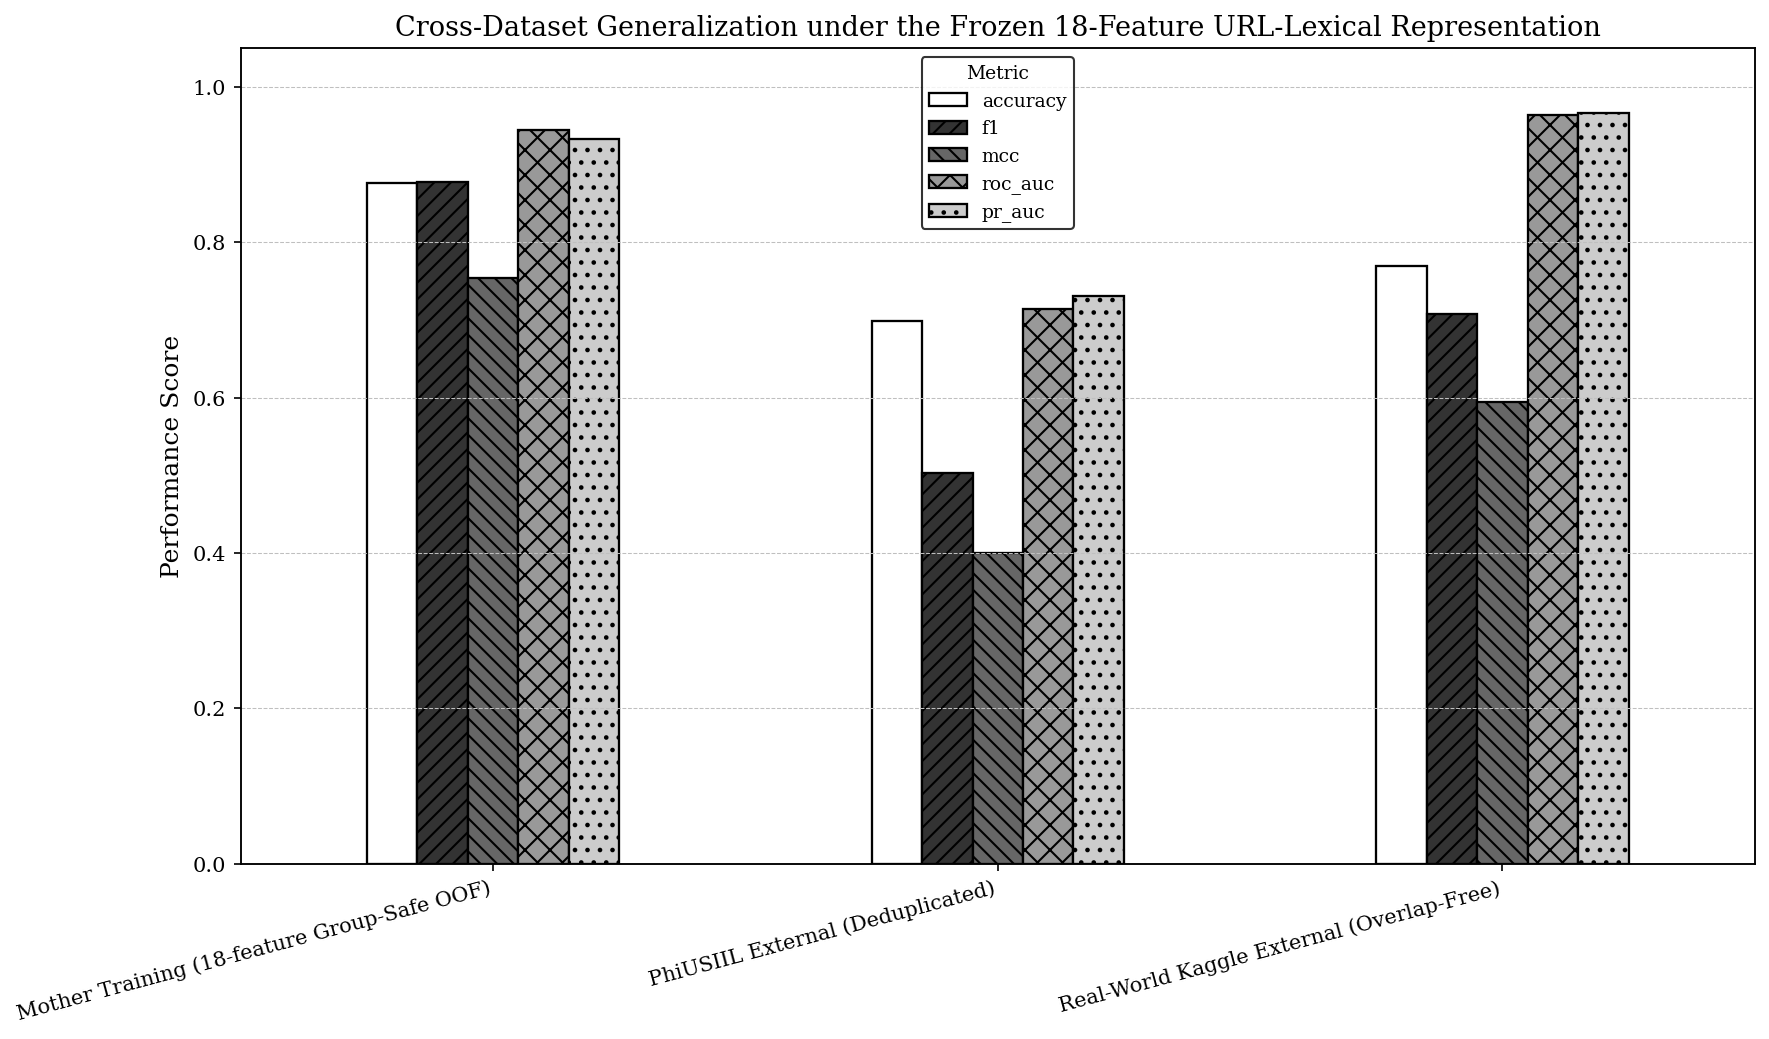

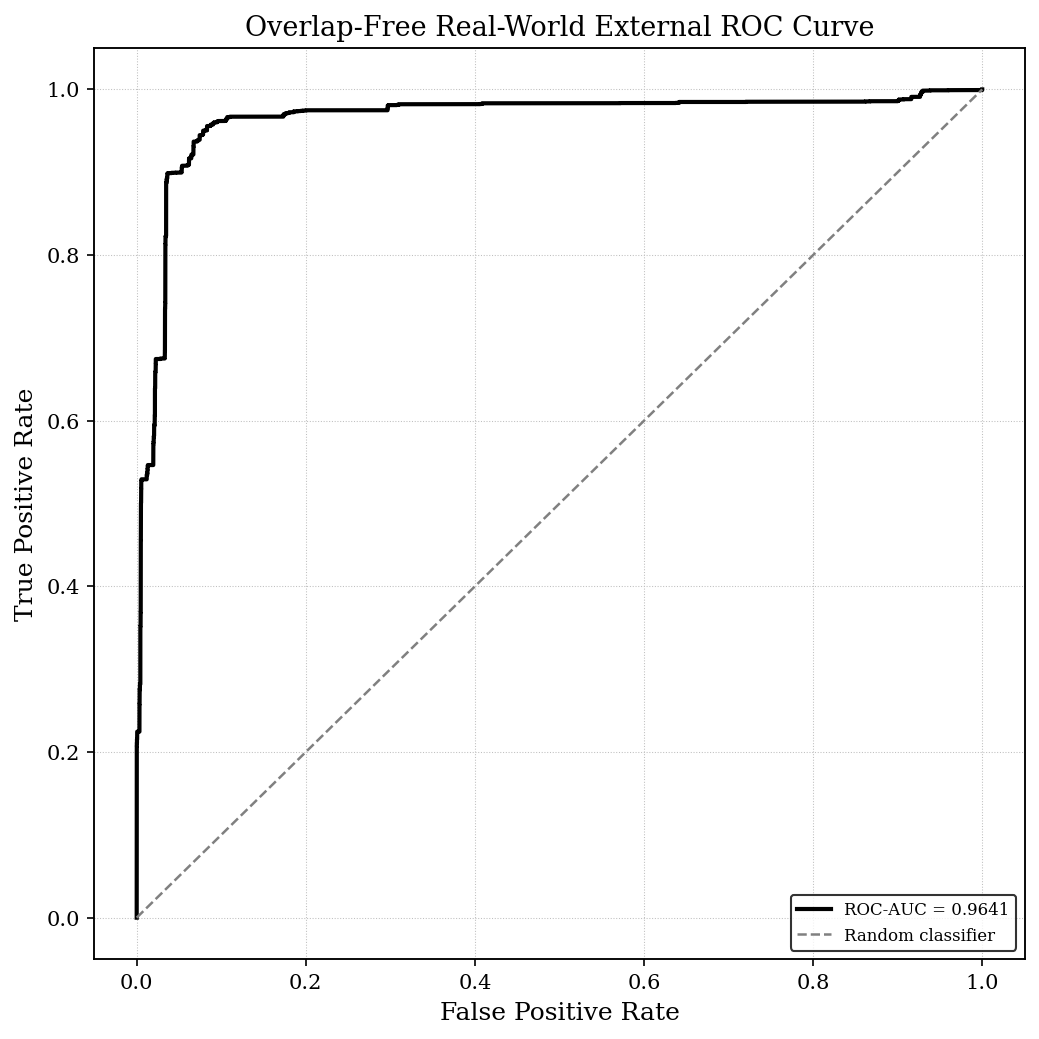

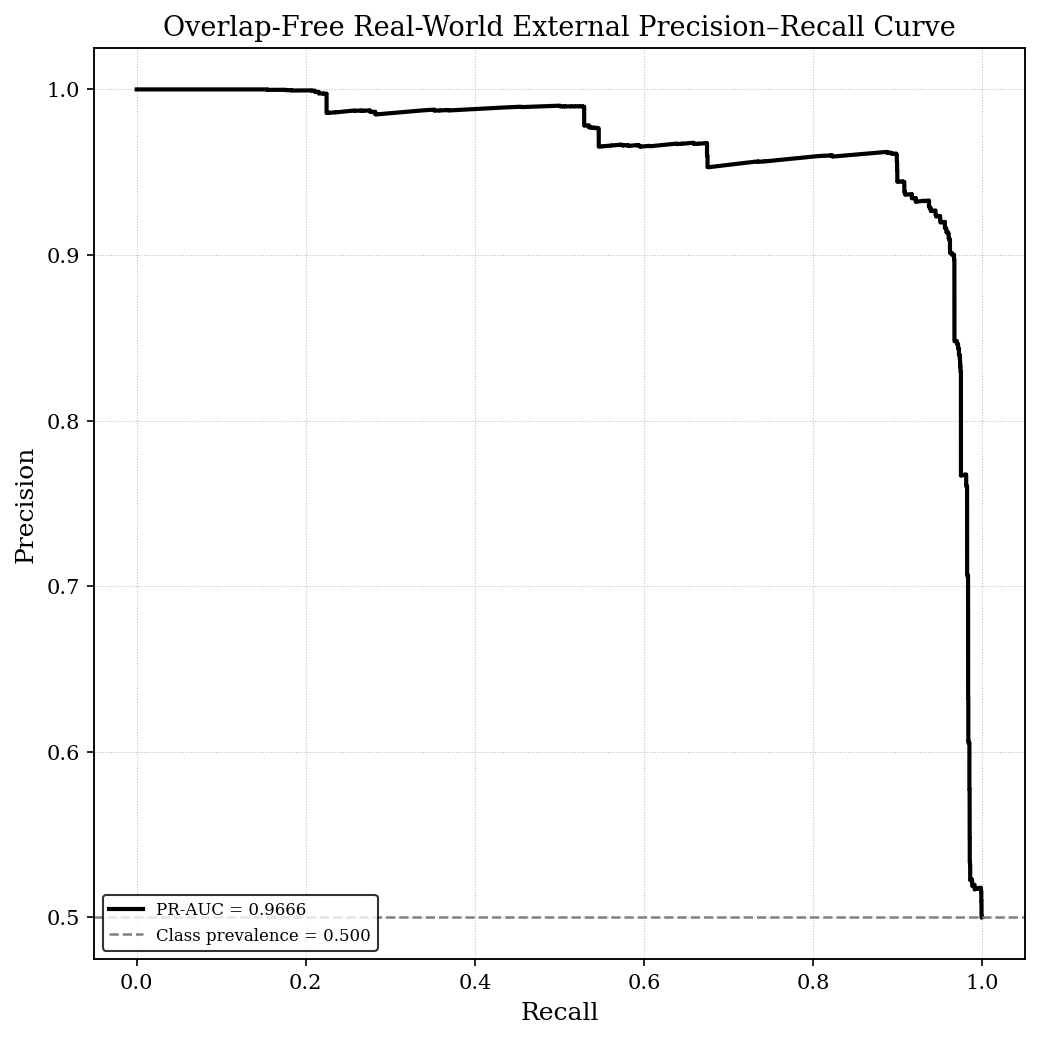


FINAL EXTERNAL GENERALIZATION AUDIT
Mother TRAIN used: True
Mother validation used: False
Mother sealed test used: False
External training used: False
External tuning used: False
External feature selection used: False
External threshold tuning used: False
Frozen threshold: 0.5
Removed PhiUSIIL overlap: 3
Final Real-World rows: 48809

Final Real-World external metrics:
{
  "dataset": "Real-World Kaggle External",
  "rows": 48809,
  "accuracy": 0.7693663053944969,
  "precision": 0.9659791622368701,
  "recall": 0.5584282553470458,
  "specificity": 0.9803302872597631,
  "f1": 0.707724263274049,
  "mcc": 0.5942254233634661,
  "roc_auc": 0.9641453201979789,
  "pr_auc": 0.9665521057414437,
  "tn": 23923,
  "fp": 480,
  "fn": 10777,
  "tp": 13629
}

Figures generated:
 - Figure_External_Generalization_Comparison_BW.pdf
 - Figure_External_Generalization_Comparison_BW.png
 - Figure_External_Generalization_Comparison_BW.svg
 - Figure_External_Generalization_Comparison_BW.tiff
 - Figure_RealWorld

In [129]:
# =============================================================================
# STEP 16R-C — FINAL JOURNAL EXTERNAL GENERALIZATION CLEANUP
#
# PURPOSE
# -------
# 1. Remove exact URL overlap between Real-World dataset and PhiUSIIL
# 2. Apply the SAME frozen 18-feature URL-lexical representation
# 3. Train XGBoost ONLY on Mother TRAIN partition
# 4. Evaluate overlap-free Real-World external dataset
# 5. Compute stratified bootstrap 95% confidence intervals
# 6. Combine Mother OOF + PhiUSIIL + Real-World results
# 7. Generate journal-ready table and figures
#
# IMPORTANT
# ---------
# NO external training
# NO external tuning
# NO external feature selection
# NO threshold optimization
# Threshold remains frozen at 0.50
# =============================================================================

import os
import re
import json
import shutil
import ipaddress
import subprocess
import warnings
from pathlib import Path
from urllib.parse import urlsplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# =============================================================================
# CONFIG
# =============================================================================

SEED = 20260726
THRESHOLD = 0.50
TARGET = "CLASS_LABEL"

BOOTSTRAPS = 1000

WORKING = Path("/kaggle/working")

MOTHER_PATH = (
    WORKING
    / "step_03_leakage_safe_split"
    / "train_raw_70.csv.gz"
)

PARAM_PATH = (
    WORKING
    / "step_12_final_candidate_tuning"
    / "remove_numquerycomponents_best_parameters.json"
)

REALWORLD_AUDIT = (
    WORKING
    / "step_16R_realworld_external_audit"
    / "step_16R_A_summary.json"
)

PHI_PATH = (
    WORKING
    / "step_16P_phiusiil_audit"
    / "phiusiil_deduplicated_with_mother_label.csv.gz"
)

PHI_METRICS_PATH = (
    WORKING
    / "step_16P_phiusiil_external_generalization"
    / "external_generalization_metrics.csv"
)

OUT = (
    WORKING
    / "step_16_external_generalization_final"
)

FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"

if OUT.exists():
    shutil.rmtree(OUT)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 105)
print("STEP 16R-C: FINAL OVERLAP-FREE EXTERNAL GENERALIZATION ANALYSIS")
print("=" * 105)


# =============================================================================
# PUBLICATION FIGURE POLICY
# =============================================================================

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["savefig.bbox"] = "tight"


# =============================================================================
# FROZEN FEATURE SPACE
# =============================================================================

COMMON_FEATURES = [
    "NumDots",
    "PathLevel",
    "UrlLength",
    "NumDash",
    "NumDashInHostname",
    "AtSymbol",
    "TildeSymbol",
    "NumUnderscore",
    "NumPercent",
    "NumAmpersand",
    "NumHash",
    "NumNumericChars",
    "NoHttps",
    "IpAddress",
    "HostnameLength",
    "PathLength",
    "QueryLength",
    "DoubleSlashInPath",
]


print(
    "\nFrozen common feature count:",
    len(COMMON_FEATURES)
)


# =============================================================================
# GPU AUTO-DETECTION
# =============================================================================

def detect_device():

    try:

        result = subprocess.run(
            ["nvidia-smi", "-L"],
            capture_output=True,
            text=True,
            check=True
        )

        if result.stdout.strip():
            return "cuda"

    except Exception:
        pass

    return "cpu"


XGB_DEVICE = detect_device()

print(
    "XGBoost device:",
    XGB_DEVICE
)


# =============================================================================
# LOAD MOTHER TRAIN
# =============================================================================

mother = pd.read_csv(
    MOTHER_PATH,
    compression="gzip",
    low_memory=False
)


missing = [
    f
    for f in COMMON_FEATURES
    if f not in mother.columns
]

if missing:
    raise ValueError(
        f"Mother missing frozen features: {missing}"
    )


print(
    "\nMother TRAIN:",
    mother.shape
)

print(
    "Validation used: False"
)

print(
    "Sealed test used: False"
)


# =============================================================================
# LOAD FROZEN HYPERPARAMETERS
# =============================================================================

with open(
    PARAM_PATH,
    "r",
    encoding="utf-8"
) as f:

    best_params = json.load(f)


# =============================================================================
# RECREATE MOTHER DUPLICATE GROUPS
# =============================================================================

group_predictors = [
    c
    for c in mother.columns
    if c not in [
        "id",
        "HttpsInHostname",
        TARGET
    ]
]


fingerprint = (
    pd.util.hash_pandas_object(
        mother[group_predictors],
        index=False
    )
    .astype("uint64")
)


groups, unique_groups = pd.factorize(
    fingerprint,
    sort=False
)

groups = np.asarray(groups)


print(
    "Mother independent groups:",
    len(unique_groups)
)


# =============================================================================
# MODEL FACTORY
# =============================================================================

def build_model(seed):

    params = dict(
        best_params
    )

    params.update({
        "objective":
            "binary:logistic",

        "eval_metric":
            "logloss",

        "tree_method":
            "hist",

        "device":
            XGB_DEVICE,

        "random_state":
            int(seed),

        "n_jobs":
            -1,

        "verbosity":
            0
    })

    return XGBClassifier(
        **params
    )


# =============================================================================
# SOURCE GROUP-SAFE OOF
# =============================================================================

X_source = (
    mother[
        COMMON_FEATURES
    ]
    .copy()
    .reset_index(drop=True)
)

y_source = (
    mother[
        TARGET
    ]
    .astype(int)
    .reset_index(drop=True)
)


cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


oof_prob = np.zeros(
    len(X_source),
    dtype=float
)


fold_results = []


for fold, (
    train_idx,
    valid_idx
) in enumerate(

    cv.split(
        X_source,
        y_source,
        groups
    ),

    start=1
):

    overlap = len(
        set(groups[train_idx])
        .intersection(
            set(groups[valid_idx])
        )
    )

    if overlap != 0:

        raise RuntimeError(
            f"Group leakage detected "
            f"in fold {fold}"
        )


    model = build_model(
        SEED + fold
    )

    model.fit(
        X_source.iloc[train_idx],
        y_source.iloc[train_idx]
    )


    prob = model.predict_proba(
        X_source.iloc[valid_idx]
    )[:, 1]


    oof_prob[valid_idx] = prob


    pred = (
        prob >= THRESHOLD
    ).astype(int)


    fold_results.append({
        "fold":
            fold,

        "train_rows":
            len(train_idx),

        "validation_rows":
            len(valid_idx),

        "group_overlap":
            overlap,

        "accuracy":
            accuracy_score(
                y_source.iloc[valid_idx],
                pred
            ),

        "mcc":
            matthews_corrcoef(
                y_source.iloc[valid_idx],
                pred
            ),

        "roc_auc":
            roc_auc_score(
                y_source.iloc[valid_idx],
                prob
            )
    })


fold_df = pd.DataFrame(
    fold_results
)


# =============================================================================
# METRIC FUNCTION
# =============================================================================

def calculate_metrics(
    y_true,
    probability,
    dataset_name
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )

    probability = np.asarray(
        probability,
        dtype=float
    )


    prediction = (
        probability >= THRESHOLD
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            prediction,
            labels=[0, 1]
        )
        .ravel()
    )


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    return {
        "dataset":
            dataset_name,

        "rows":
            int(len(y_true)),

        "accuracy":
            float(
                accuracy_score(
                    y_true,
                    prediction
                )
            ),

        "precision":
            float(
                precision_score(
                    y_true,
                    prediction,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y_true,
                    prediction,
                    zero_division=0
                )
            ),

        "specificity":
            float(specificity),

        "f1":
            float(
                f1_score(
                    y_true,
                    prediction,
                    zero_division=0
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y_true,
                    prediction
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y_true,
                    probability
                )
            ),

        "pr_auc":
            float(
                average_precision_score(
                    y_true,
                    probability
                )
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp)
    }


source_metrics = calculate_metrics(
    y_source,
    oof_prob,
    "Mother 18-feature Group-Safe OOF"
)


# =============================================================================
# TRAIN FINAL SOURCE-ONLY COMMON-SPACE MODEL
# =============================================================================

final_model = build_model(
    SEED
)


final_model.fit(
    X_source,
    y_source
)


print(
    "\nFinal 18-feature model trained."
)

print(
    "Training data: Mother TRAIN only"
)

print(
    "External data used in fit(): False"
)


# =============================================================================
# LOAD REAL-WORLD DATASET
# =============================================================================

with open(
    REALWORLD_AUDIT,
    "r",
    encoding="utf-8"
) as f:

    rw_audit = json.load(f)


REALWORLD_PATH = Path(
    rw_audit[
        "selected_dataset"
    ]
)


realworld = pd.read_csv(
    REALWORLD_PATH,
    low_memory=False
)


realworld["url"] = (
    realworld["url"]
    .astype(str)
    .str.strip()
)


realworld["label"] = (
    pd.to_numeric(
        realworld["label"],
        errors="raise"
    )
    .astype(int)
)


realworld = (
    realworld
    .drop_duplicates(
        subset=[
            "url",
            "label"
        ]
    )
    .reset_index(drop=True)
)


print(
    "\nReal-World rows before overlap removal:",
    len(realworld)
)


# =============================================================================
# LOAD PhiUSIIL URLS AND REMOVE OVERLAP
# =============================================================================

phi = pd.read_csv(
    PHI_PATH,
    usecols=["URL"],
    compression="gzip",
    low_memory=False
)


phi_urls = set(
    phi["URL"]
    .astype(str)
    .str.strip()
)


overlap_mask = (
    realworld["url"]
    .isin(
        phi_urls
    )
)


overlap_df = (
    realworld.loc[
        overlap_mask
    ]
    .copy()
)


realworld_clean = (
    realworld.loc[
        ~overlap_mask
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "Exact PhiUSIIL overlap removed:",
    len(overlap_df)
)

print(
    "Real-World rows after overlap removal:",
    len(realworld_clean)
)


if len(overlap_df):

    overlap_df.to_csv(
        OUT
        / "removed_cross_dataset_overlap_urls.csv",
        index=False
    )


# =============================================================================
# STRICT URL FEATURE EXTRACTOR
# SAME RULES USED FOR PhiUSIIL
# =============================================================================

_SCHEME_RE = re.compile(
    r"^[A-Za-z][A-Za-z0-9+.-]*://"
)


def parse_url(raw_url):

    raw = str(
        raw_url
    ).strip()


    if _SCHEME_RE.match(raw):

        parse_input = raw

    else:

        parse_input = (
            "http://" + raw
        )


    try:

        parsed = urlsplit(
            parse_input
        )

    except Exception:

        parsed = urlsplit(
            "http://invalid.local/"
        )


    return raw, parsed


def is_ip_hostname(hostname):

    if not hostname:
        return 0


    host = str(
        hostname
    ).strip("[]")


    try:

        ipaddress.ip_address(
            host
        )

        return 1

    except Exception:

        return 0


def extract_url_features(raw_url):

    raw, parsed = parse_url(
        raw_url
    )


    hostname = (
        parsed.hostname
        or ""
    )

    path = (
        parsed.path
        or ""
    )

    query = (
        parsed.query
        or ""
    )


    path_level = len([
        part
        for part in path.split("/")
        if part
    ])


    scheme_match = re.match(
        r"^([A-Za-z][A-Za-z0-9+.-]*):\/\/",
        raw
    )


    scheme = (
        scheme_match.group(1).lower()

        if scheme_match

        else ""
    )


    return {
        "NumDots":
            raw.count("."),

        "PathLevel":
            path_level,

        "UrlLength":
            len(raw),

        "NumDash":
            raw.count("-"),

        "NumDashInHostname":
            hostname.count("-"),

        "AtSymbol":
            int(
                "@" in raw
            ),

        "TildeSymbol":
            int(
                "~" in raw
            ),

        "NumUnderscore":
            raw.count("_"),

        "NumPercent":
            raw.count("%"),

        "NumAmpersand":
            raw.count("&"),

        "NumHash":
            raw.count("#"),

        "NumNumericChars":
            sum(
                ch.isdigit()
                for ch in raw
            ),

        "NoHttps":
            int(
                scheme != "https"
            ),

        "IpAddress":
            is_ip_hostname(
                hostname
            ),

        "HostnameLength":
            len(hostname),

        "PathLength":
            len(path),

        "QueryLength":
            len(query),

        "DoubleSlashInPath":
            int(
                "//" in path
            )
    }


# =============================================================================
# EXTRACT OVERLAP-FREE REAL-WORLD FEATURES
# =============================================================================

print(
    "\nExtracting overlap-free "
    "Real-World features..."
)


X_realworld = pd.DataFrame(
    [
        extract_url_features(url)

        for url in realworld_clean[
            "url"
        ]
    ],

    columns=COMMON_FEATURES
)


y_realworld = (
    realworld_clean[
        "label"
    ]
    .astype(int)
    .to_numpy()
)


# =============================================================================
# EXTERNAL INFERENCE ONLY
# =============================================================================

realworld_prob = (
    final_model
    .predict_proba(
        X_realworld
    )[:, 1]
)


realworld_metrics = calculate_metrics(
    y_realworld,
    realworld_prob,
    "Real-World Kaggle External"
)


print(
    "\n"
    + "=" * 105
)

print(
    "OVERLAP-FREE REAL-WORLD EXTERNAL RESULT"
)

print(
    "=" * 105
)

print(
    json.dumps(
        realworld_metrics,
        indent=2
    )
)


# =============================================================================
# SOURCE STRATIFIED PERFORMANCE
# =============================================================================

realworld_pred = (
    realworld_prob >= THRESHOLD
).astype(int)


source_eval = pd.DataFrame({
    "source":
        realworld_clean[
            "source"
        ]
        .astype(str)
        .str.lower(),

    "actual":
        y_realworld,

    "predicted":
        realworld_pred,

    "probability":
        realworld_prob
})


source_rows = []


for source_name, grp in (
    source_eval.groupby(
        "source"
    )
):

    actual = grp[
        "actual"
    ].to_numpy()

    predicted = grp[
        "predicted"
    ].to_numpy()


    row = {
        "source":
            source_name,

        "rows":
            int(len(grp)),

        "actual_positive_rate":
            float(
                actual.mean()
            ),

        "predicted_positive_rate":
            float(
                predicted.mean()
            ),

        "accuracy":
            float(
                accuracy_score(
                    actual,
                    predicted
                )
            ),

        "mean_phishing_probability":
            float(
                grp[
                    "probability"
                ].mean()
            )
    }


    if np.all(
        actual == 0
    ):

        row[
            "specificity"
        ] = row[
            "accuracy"
        ]

        row[
            "false_positive_rate"
        ] = (
            1
            - row["accuracy"]
        )


    if np.all(
        actual == 1
    ):

        row[
            "recall"
        ] = row[
            "accuracy"
        ]

        row[
            "false_negative_rate"
        ] = (
            1
            - row["accuracy"]
        )


    source_rows.append(
        row
    )


source_df = pd.DataFrame(
    source_rows
)


print(
    "\nSOURCE-STRATIFIED RESULT"
)

display(
    source_df
)


# =============================================================================
# SOURCE-STRATIFIED BOOTSTRAP 95% CI
# =============================================================================

rng = np.random.default_rng(
    SEED
)


source_indices = {
    source:
        np.asarray(indices)

    for source, indices
    in source_eval.groupby(
        "source"
    ).groups.items()
}


bootstrap_rows = []


for iteration in range(
    BOOTSTRAPS
):

    sampled_parts = []


    for source_name, indices in (
        source_indices.items()
    ):

        sampled = rng.choice(
            indices,
            size=len(indices),
            replace=True
        )

        sampled_parts.append(
            sampled
        )


    sample_idx = np.concatenate(
        sampled_parts
    )


    metrics = calculate_metrics(
        y_realworld[
            sample_idx
        ],
        realworld_prob[
            sample_idx
        ],
        f"bootstrap_{iteration}"
    )


    bootstrap_rows.append(
        metrics
    )


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


CI_METRICS = [
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "mcc",
    "roc_auc",
    "pr_auc",
]


ci_rows = []


for metric in CI_METRICS:

    values = (
        bootstrap_df[
            metric
        ]
        .dropna()
        .to_numpy()
    )


    ci_rows.append({
        "metric":
            metric,

        "point_estimate":
            realworld_metrics[
                metric
            ],

        "lower_95":
            float(
                np.percentile(
                    values,
                    2.5
                )
            ),

        "upper_95":
            float(
                np.percentile(
                    values,
                    97.5
                )
            )
    })


ci_df = pd.DataFrame(
    ci_rows
)


print(
    "\nREAL-WORLD 95% BOOTSTRAP CI"
)

display(
    ci_df
)


# =============================================================================
# LOAD PhiUSIIL FINAL RESULT
# =============================================================================

phi_metrics_table = pd.read_csv(
    PHI_METRICS_PATH
)


phi_candidates = (
    phi_metrics_table[
        phi_metrics_table[
            "dataset"
        ]
        .astype(str)
        .str.contains(
            "Deduplicated",
            case=False,
            na=False
        )
    ]
)


if len(phi_candidates) == 0:

    raise ValueError(
        "Could not locate deduplicated "
        "PhiUSIIL result."
    )


phi_row = (
    phi_candidates.iloc[0]
    .to_dict()
)


# =============================================================================
# FINAL COMPARISON TABLE
# =============================================================================

comparison_columns = [
    "dataset",
    "rows",
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "mcc",
    "roc_auc",
    "pr_auc",
]


comparison_df = pd.DataFrame([
    {
        key:
            source_metrics[
                key
            ]
        for key in comparison_columns
    },

    {
        key:
            phi_row[
                key
            ]
        for key in comparison_columns
    },

    {
        key:
            realworld_metrics[
                key
            ]
        for key in comparison_columns
    }
])


comparison_df.loc[
    0,
    "dataset"
] = (
    "Mother Training "
    "(18-feature Group-Safe OOF)"
)


comparison_df.loc[
    1,
    "dataset"
] = (
    "PhiUSIIL External "
    "(Deduplicated)"
)


comparison_df.loc[
    2,
    "dataset"
] = (
    "Real-World Kaggle External "
    "(Overlap-Free)"
)


print(
    "\n"
    + "=" * 105
)

print(
    "FINAL CROSS-DATASET COMPARISON"
)

print(
    "=" * 105
)


display(
    comparison_df
)


# =============================================================================
# SAVE JOURNAL TABLES
# =============================================================================

comparison_df.to_csv(
    TABLE_DIR
    / "Table_External_Generalization_Comparison.csv",
    index=False
)


comparison_df.to_excel(
    TABLE_DIR
    / "Table_External_Generalization_Comparison.xlsx",
    index=False
)


ci_df.to_csv(
    TABLE_DIR
    / "Table_RealWorld_External_95CI.csv",
    index=False
)


source_df.to_csv(
    TABLE_DIR
    / "Table_RealWorld_Source_Strata.csv",
    index=False
)


fold_df.to_csv(
    TABLE_DIR
    / "Table_Mother_18Feature_GroupSafe_Folds.csv",
    index=False
)


# =============================================================================
# SAVE EXTERNAL PREDICTIONS
# =============================================================================

prediction_df = pd.DataFrame({
    "url":
        realworld_clean[
            "url"
        ],

    "source":
        realworld_clean[
            "source"
        ],

    "actual_label":
        y_realworld,

    "phishing_probability":
        realworld_prob,

    "predicted_label":
        realworld_pred
})


prediction_df.to_csv(
    OUT
    / "realworld_overlap_free_predictions.csv.gz",
    index=False,
    compression="gzip"
)


# =============================================================================
# FIGURE 1 — BLACK & WHITE EXTERNAL PERFORMANCE COMPARISON
# =============================================================================

plot_df = (
    comparison_df
    .set_index("dataset")[
        [
            "accuracy",
            "f1",
            "mcc",
            "roc_auc",
            "pr_auc"
        ]
    ]
)

fig, ax = plt.subplots(
    figsize=(12, 7)
)

bars = plot_df.plot(
    kind="bar",
    ax=ax,
    color=[
        "white",
        "0.20",
        "0.40",
        "0.60",
        "0.80"
    ],
    edgecolor="black",
    linewidth=1.1
)

# Hatch patterns improve grayscale readability
hatches = [
    "",
    "///",
    "\\\\\\",
    "xx",
    ".."
]

for container, hatch in zip(
    ax.containers,
    hatches
):
    for patch in container:
        patch.set_hatch(hatch)

ax.set_ylabel(
    "Performance Score",
    fontsize=12
)

ax.set_xlabel("")

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    "Cross-Dataset Generalization under the "
    "Frozen 18-Feature URL-Lexical Representation",
    fontsize=13
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.legend(
    title="Metric",
    frameon=True,
    edgecolor="black",
    fontsize=9
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    color="0.75"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

for extension in [
    "png",
    "tiff",
    "pdf",
    "svg"
]:

    kwargs = {}

    if extension in [
        "png",
        "tiff"
    ]:
        kwargs["dpi"] = 600

    plt.savefig(
        FIG_DIR /
        f"Figure_External_Generalization_Comparison_BW.{extension}",
        **kwargs
    )

plt.show()
plt.close()

# =============================================================================
# FIGURE 2 — BLACK & WHITE REAL-WORLD ROC CURVE
# =============================================================================

fpr, tpr, _ = roc_curve(
    y_realworld,
    realworld_prob
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.plot(
    fpr,
    tpr,
    color="black",
    linewidth=2.0,
    linestyle="-",
    label=(
        f"ROC-AUC = "
        f"{realworld_metrics['roc_auc']:.4f}"
    )
)

ax.plot(
    [0, 1],
    [0, 1],
    color="0.50",
    linestyle="--",
    linewidth=1.2,
    label="Random classifier"
)

ax.set_xlabel(
    "False Positive Rate",
    fontsize=12
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=12
)

ax.set_title(
    "Overlap-Free Real-World External ROC Curve",
    fontsize=13
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.legend(
    loc="lower right",
    frameon=True,
    edgecolor="black"
)

ax.grid(
    linestyle=":",
    linewidth=0.5,
    color="0.75"
)

plt.tight_layout()

for extension in [
    "png",
    "tiff",
    "pdf",
    "svg"
]:

    kwargs = {}

    if extension in [
        "png",
        "tiff"
    ]:
        kwargs["dpi"] = 600

    plt.savefig(
        FIG_DIR /
        f"Figure_RealWorld_External_ROC_BW.{extension}",
        **kwargs
    )

plt.show()
plt.close()


# =============================================================================
# FIGURE 3 — BLACK & WHITE PRECISION–RECALL CURVE
# =============================================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_realworld,
        realworld_prob
    )
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.plot(
    recall_curve,
    precision_curve,
    color="black",
    linewidth=2.0,
    linestyle="-",
    label=(
        f"PR-AUC = "
        f"{realworld_metrics['pr_auc']:.4f}"
    )
)

baseline = float(
    np.mean(y_realworld)
)

ax.axhline(
    baseline,
    color="0.50",
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Class prevalence = "
        f"{baseline:.3f}"
    )
)

ax.set_xlabel(
    "Recall",
    fontsize=12
)

ax.set_ylabel(
    "Precision",
    fontsize=12
)

ax.set_title(
    "Overlap-Free Real-World External "
    "Precision–Recall Curve",
    fontsize=13
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.legend(
    loc="lower left",
    frameon=True,
    edgecolor="black"
)

ax.grid(
    linestyle=":",
    linewidth=0.5,
    color="0.75"
)

plt.tight_layout()

for extension in [
    "png",
    "tiff",
    "pdf",
    "svg"
]:

    kwargs = {}

    if extension in [
        "png",
        "tiff"
    ]:
        kwargs["dpi"] = 600

    plt.savefig(
        FIG_DIR /
        f"Figure_RealWorld_External_PR_BW.{extension}",
        **kwargs
    )

plt.show()
plt.close()


# =============================================================================
# FINAL PROTOCOL JSON
# =============================================================================

protocol = {
    "experiment":
        (
            "Independent cross-dataset external "
            "generalization under a harmonized "
            "18-feature URL-lexical representation"
        ),

    "mother_training_rows":
        int(
            len(mother)
        ),

    "common_feature_count":
        len(COMMON_FEATURES),

    "common_features":
        COMMON_FEATURES,

    "threshold":
        THRESHOLD,

    "mother_training_only":
        True,

    "mother_validation_used":
        False,

    "mother_sealed_test_used":
        False,

    "phiusiil_training_used":
        False,

    "realworld_training_used":
        False,

    "external_tuning_used":
        False,

    "external_feature_selection_used":
        False,

    "external_threshold_tuning_used":
        False,

    "realworld_rows_before_overlap_removal":
        int(
            len(realworld)
        ),

    "phiusiil_overlap_removed":
        int(
            len(overlap_df)
        ),

    "realworld_final_rows":
        int(
            len(realworld_clean)
        ),

    "realworld_accuracy":
        realworld_metrics[
            "accuracy"
        ],

    "realworld_mcc":
        realworld_metrics[
            "mcc"
        ],

    "realworld_roc_auc":
        realworld_metrics[
            "roc_auc"
        ],

    "realworld_pr_auc":
        realworld_metrics[
            "pr_auc"
        ],

    "important_limitation":
        (
            "The external Real-World dataset has "
            "source-label coupling: Tranco provides "
            "legitimate URLs whereas URLhaus and "
            "OpenPhish provide phishing URLs."
        ),

    "claim":
        (
            "External generalization of a "
            "harmonized URL-lexical model"
        ),

    "not_claimed":
        (
            "Direct external validation of the "
            "final 46-feature XGBoost model"
        )
}


with open(
    OUT
    / "FINAL_EXTERNAL_GENERALIZATION_PROTOCOL.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        protocol,
        f,
        indent=2
    )


# =============================================================================
# ZIP FINAL EXTERNAL PACKAGE
# =============================================================================

ZIP_BASE = (
    WORKING
    / "FINAL_EXTERNAL_GENERALIZATION_PACKAGE"
)


zip_path = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=OUT
)


# =============================================================================
# FINAL AUDIT
# =============================================================================

print(
    "\n"
    + "=" * 105
)

print(
    "FINAL EXTERNAL GENERALIZATION AUDIT"
)

print(
    "=" * 105
)


print(
    "Mother TRAIN used:",
    True
)

print(
    "Mother validation used:",
    False
)

print(
    "Mother sealed test used:",
    False
)

print(
    "External training used:",
    False
)

print(
    "External tuning used:",
    False
)

print(
    "External feature selection used:",
    False
)

print(
    "External threshold tuning used:",
    False
)

print(
    "Frozen threshold:",
    THRESHOLD
)

print(
    "Removed PhiUSIIL overlap:",
    len(overlap_df)
)

print(
    "Final Real-World rows:",
    len(realworld_clean)
)

print(
    "\nFinal Real-World external metrics:"
)

print(
    json.dumps(
        realworld_metrics,
        indent=2
    )
)

print(
    "\nFigures generated:"
)

for path in sorted(
    FIG_DIR.iterdir()
):
    print(
        " -",
        path.name
    )


print(
    "\nTables generated:"
)

for path in sorted(
    TABLE_DIR.iterdir()
):
    print(
        " -",
        path.name
    )


print(
    "\nFinal package:"
)

print(
    zip_path
)


print(
    "\nSTEP 16R-C COMPLETED SUCCESSFULLY"
)

In [130]:
# ============================================================
# STEP 16: DEPLOYMENT / COMPUTATIONAL COST ANALYSIS
# Feature Extraction Time + Inference Latency + Memory
# + Model Size + Throughput
# ============================================================

import os
import time
import tracemalloc
import joblib
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Make sure output folder exists
# ------------------------------------------------------------

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)


# ------------------------------------------------------------
# 2. Save model if file does not already exist
# ------------------------------------------------------------

MODEL_PATH = "outputs/models/final_xgboost_model.pkl"

if not os.path.exists(MODEL_PATH):
    joblib.dump(final_xgb_model, MODEL_PATH)


# ------------------------------------------------------------
# 3. Model file size
# ------------------------------------------------------------

model_size_bytes = os.path.getsize(MODEL_PATH)

model_size_mb = (
    model_size_bytes
    / (1024 ** 2)
)


# ------------------------------------------------------------
# 4. Select raw URLs for feature extraction benchmark
# ------------------------------------------------------------

benchmark_urls = None

if "real_world" in globals() and "url" in real_world.columns:
    benchmark_urls = real_world["url"].dropna()

elif "external_df" in globals() and "url" in external_df.columns:
    benchmark_urls = external_df["url"].dropna()

elif "dataset" in globals() and "url" in dataset.columns:
    benchmark_urls = dataset["url"].dropna()


# ------------------------------------------------------------
# 5. Feature extraction latency
# ------------------------------------------------------------

feature_extraction_mean_ms = np.nan
feature_extraction_median_ms = np.nan
feature_extraction_p95_ms = np.nan
feature_extraction_urls_per_second = np.nan
feature_benchmark_n = 0


if benchmark_urls is not None and "extract_url_features" in globals():

    benchmark_urls = benchmark_urls.sample(
        n=min(1000, len(benchmark_urls)),
        random_state=42
    ).tolist()

    feature_benchmark_n = len(benchmark_urls)

    feature_times = []

    for url in benchmark_urls:

        start = time.perf_counter()

        _ = extract_url_features(url)

        end = time.perf_counter()

        feature_times.append(
            (end - start) * 1000
        )

    feature_times = np.array(feature_times)

    feature_extraction_mean_ms = feature_times.mean()
    feature_extraction_median_ms = np.median(feature_times)
    feature_extraction_p95_ms = np.percentile(feature_times, 95)

    feature_extraction_urls_per_second = (
        1000 / feature_extraction_mean_ms
        if feature_extraction_mean_ms > 0
        else np.nan
    )


# ------------------------------------------------------------
# 6. Warm-up inference
# ------------------------------------------------------------

_ = final_xgb_model.predict_proba(
    sealed_test_X.iloc[:min(10, len(sealed_test_X))]
)


# ------------------------------------------------------------
# 7. Batch inference latency
# ------------------------------------------------------------

N_REPEATS = 100

batch_times = []

for _ in range(N_REPEATS):

    start = time.perf_counter()

    _ = final_xgb_model.predict_proba(
        sealed_test_X
    )

    end = time.perf_counter()

    batch_times.append(
        (end - start) * 1000
    )


batch_times = np.array(batch_times)

batch_inference_mean_ms = batch_times.mean()

batch_inference_median_ms = np.median(
    batch_times
)

batch_inference_p95_ms = np.percentile(
    batch_times,
    95
)


# ------------------------------------------------------------
# 8. Per-sample latency + throughput
# ------------------------------------------------------------

n_test_samples = len(sealed_test_X)

per_sample_mean_ms = (
    batch_inference_mean_ms
    / n_test_samples
)

per_sample_p95_equivalent_ms = (
    batch_inference_p95_ms
    / n_test_samples
)

throughput_samples_second = (
    n_test_samples
    /
    (batch_inference_mean_ms / 1000)
)


# ------------------------------------------------------------
# 9. Prediction memory measurement
# ------------------------------------------------------------

tracemalloc.start()

_ = final_xgb_model.predict_proba(
    sealed_test_X
)

current_memory, peak_memory = (
    tracemalloc.get_traced_memory()
)

tracemalloc.stop()


peak_prediction_memory_mb = (
    peak_memory
    / (1024 ** 2)
)


# ------------------------------------------------------------
# 10. Single-sample inference benchmark
# ------------------------------------------------------------

single_sample = sealed_test_X.iloc[[0]]

single_times = []

for _ in range(500):

    start = time.perf_counter()

    _ = final_xgb_model.predict_proba(
        single_sample
    )

    end = time.perf_counter()

    single_times.append(
        (end - start) * 1000
    )


single_times = np.array(single_times)

single_inference_mean_ms = (
    single_times.mean()
)

single_inference_median_ms = (
    np.median(single_times)
)

single_inference_p95_ms = (
    np.percentile(
        single_times,
        95
    )
)


# ------------------------------------------------------------
# 11. Build deployment summary table
# ------------------------------------------------------------

deployment_results = pd.DataFrame({

    "Metric": [

        "Model size (MB)",

        "Feature benchmark URLs",

        "Feature extraction mean (ms/URL)",

        "Feature extraction median (ms/URL)",

        "Feature extraction P95 (ms/URL)",

        "Feature extraction throughput (URLs/sec)",

        "Batch test samples",

        "Batch inference mean (ms)",

        "Batch inference median (ms)",

        "Batch inference P95 (ms)",

        "Mean inference per sample (ms)",

        "P95-equivalent inference per sample (ms)",

        "Inference throughput (samples/sec)",

        "Single-sample inference mean (ms)",

        "Single-sample inference median (ms)",

        "Single-sample inference P95 (ms)",

        "Peak Python-tracked prediction memory (MB)"
    ],

    "Value": [

        model_size_mb,

        feature_benchmark_n,

        feature_extraction_mean_ms,

        feature_extraction_median_ms,

        feature_extraction_p95_ms,

        feature_extraction_urls_per_second,

        n_test_samples,

        batch_inference_mean_ms,

        batch_inference_median_ms,

        batch_inference_p95_ms,

        per_sample_mean_ms,

        per_sample_p95_equivalent_ms,

        throughput_samples_second,

        single_inference_mean_ms,

        single_inference_median_ms,

        single_inference_p95_ms,

        peak_prediction_memory_mb
    ]
})


# ------------------------------------------------------------
# 12. Save results
# ------------------------------------------------------------

deployment_results.to_csv(
    "outputs/tables/deployment_computational_cost.csv",
    index=False
)

display(deployment_results)


print("=" * 60)
print("DEPLOYMENT ANALYSIS COMPLETED")
print(f"Model size: {model_size_mb:.4f} MB")
print(
    f"Inference throughput: "
    f"{throughput_samples_second:.2f} samples/sec"
)

if not np.isnan(feature_extraction_mean_ms):
    print(
        f"Feature extraction: "
        f"{feature_extraction_mean_ms:.4f} ms/URL"
    )
else:
    print(
        "Feature extraction timing skipped: "
        "no raw URL dataframe was available."
    )

print("=" * 60)

,Metric,Value
0,Model size (MB),0.455974
1,Feature benchmark URLs,1000.000000
2,Feature extraction mean (ms/URL),0.024593
3,Feature extraction median (ms/URL),0.021718
4,Feature extraction P95 (ms/URL),0.036781
5,Feature extraction throughput (URLs/sec),40662.773931
6,Batch test samples,1500.000000
7,Batch inference mean (ms),11.976485
8,Batch inference median (ms),11.804501
9,Batch inference P95 (ms),12.833289


DEPLOYMENT ANALYSIS COMPLETED
Model size: 0.4560 MB
Inference throughput: 125245.43 samples/sec
Feature extraction: 0.0246 ms/URL


In [131]:
# ================================================================
# STEP 17 UPDATED FINAL
# GROUP-SAFE MULTI-SEED STABILITY + GROUP-BOOTSTRAP CONFIDENCE INTERVALS
# Uses ONLY Step-3 TRAINING partition.
# Validation and sealed test are NOT loaded.
# ================================================================

import os
import json
import zipfile
import shutil
import warnings
import subprocess

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ================================================================
# CONFIGURATION
# ================================================================

SEED = 20260726
TARGET = "CLASS_LABEL"
THRESHOLD = 0.50

BOOTSTRAP_ITERATIONS = 1000


TRAIN_PATH = (
    "/kaggle/working/"
    "step_03_leakage_safe_split/"
    "train_raw_70.csv.gz"
)


FEATURE_PATH = (
    "/kaggle/working/"
    "step_12_final_candidate_tuning/"
    "remove_numquerycomponents_feature_list.json"
)


PARAM_PATH = (
    "/kaggle/working/"
    "step_12_final_candidate_tuning/"
    "remove_numquerycomponents_best_parameters.json"
)


OUTPUT_DIR = (
    "/kaggle/working/"
    "step_17_final_results"
)


ZIP_PATH = (
    "/kaggle/working/"
    "step_17_final_validation.zip"
)


print("=" * 90)
print("STEP 17 UPDATED: GROUP-SAFE STATISTICAL VALIDATION")
print("=" * 90)


# ================================================================
# CLEAN OLD OUTPUT
# ================================================================

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ================================================================
# GPU / CPU AUTO-DETECTION
# ================================================================

def detect_xgb_device():

    try:

        result = subprocess.run(
            ["nvidia-smi", "-L"],
            capture_output=True,
            text=True,
            check=True
        )

        if result.stdout.strip():
            return "cuda"

    except Exception:
        pass

    return "cpu"


XGB_DEVICE = detect_xgb_device()

print(
    "XGBoost device:",
    XGB_DEVICE
)


# ================================================================
# LOAD TRAINING PARTITION ONLY
# ================================================================

df = pd.read_csv(
    TRAIN_PATH,
    compression="gzip",
    low_memory=False
)


with open(
    FEATURE_PATH,
    "r",
    encoding="utf-8"
) as f:

    feature_json = json.load(f)


if isinstance(
    feature_json,
    dict
):

    feature_list = (
        feature_json.get("features")
        or feature_json.get("selected_features")
        or feature_json.get("feature_list")
    )

else:

    feature_list = feature_json


if not feature_list:

    raise ValueError(
        "Could not recover final feature list."
    )


with open(
    PARAM_PATH,
    "r",
    encoding="utf-8"
) as f:

    best_parameters = json.load(f)


missing_features = sorted(
    set(feature_list)
    - set(df.columns)
)


if missing_features:

    raise ValueError(
        f"Missing selected features: "
        f"{missing_features}"
    )


if TARGET not in df.columns:

    raise ValueError(
        f"Target column {TARGET} not found."
    )


print(
    "Training partition:",
    df.shape
)

print(
    "Selected feature count:",
    len(feature_list)
)

print(
    "Validation dataset loaded: False"
)

print(
    "Sealed test dataset loaded: False"
)


# ================================================================
# RECREATE STEP-3 DUPLICATE GROUPS
#
# Step 3 group definition:
# all 47 usable predictors
# excluding id, constant HttpsInHostname, target
# ================================================================

group_predictor_columns = [

    col
    for col in df.columns

    if col not in [
        "id",
        "HttpsInHostname",
        TARGET
    ]
]


fingerprint = (
    pd.util.hash_pandas_object(
        df[
            group_predictor_columns
        ],
        index=False
    )
    .astype(
        "uint64"
    )
)


group_ids, unique_groups = (
    pd.factorize(
        fingerprint,
        sort=False
    )
)


group_ids = np.asarray(
    group_ids
)


conflict_check = pd.DataFrame({

    "group_id":
        group_ids,

    "target":
        df[
            TARGET
        ].astype(
            int
        ).to_numpy()
})


conflicting_groups = int(

    conflict_check

    .groupby(
        "group_id"
    )["target"]

    .nunique()

    .gt(1)

    .sum()
)


if conflicting_groups:

    raise ValueError(
        "Identical predictor groups contain "
        f"conflicting labels: "
        f"{conflicting_groups}"
    )


print(
    "Duplicate-group predictors:",
    len(group_predictor_columns)
)

print(
    "Independent groups:",
    len(unique_groups)
)

print(
    "Conflicting groups:",
    conflicting_groups
)


X_all = (
    df[
        feature_list
    ]
    .reset_index(
        drop=True
    )
)


y_all = (
    df[
        TARGET
    ]
    .astype(
        int
    )
    .reset_index(
        drop=True
    )
)


# ================================================================
# GROUP-SAFE SPLIT FUNCTION
# ================================================================

def make_group_safe_split(
    base_seed,
    test_size=0.20,
    candidates=100
):

    overall_rate = float(
        y_all.mean()
    )

    best = None
    best_score = np.inf


    for offset in range(
        candidates
    ):

        split_seed = int(
            base_seed
            + offset
        )


        splitter = GroupShuffleSplit(

            n_splits=1,

            test_size=test_size,

            random_state=split_seed
        )


        train_idx, eval_idx = next(

            splitter.split(

                X_all,

                y_all,

                groups=group_ids
            )
        )


        if (
            y_all.iloc[
                train_idx
            ].nunique()
            < 2
        ):
            continue


        if (
            y_all.iloc[
                eval_idx
            ].nunique()
            < 2
        ):
            continue


        size_error = abs(

            (
                len(eval_idx)
                / len(y_all)
            )

            - test_size
        )


        class_error = abs(

            float(
                y_all.iloc[
                    eval_idx
                ].mean()
            )

            - overall_rate
        )


        score = (
            size_error
            + class_error
        )


        if score < best_score:

            best_score = score

            best = (

                train_idx.copy(),

                eval_idx.copy(),

                split_seed
            )


    if best is None:

        raise RuntimeError(
            "Could not create "
            "a valid group-safe split."
        )


    train_idx, eval_idx, split_seed = (
        best
    )


    overlap = len(

        set(
            group_ids[
                train_idx
            ]
        )

        .intersection(

            set(
                group_ids[
                    eval_idx
                ]
            )
        )
    )


    if overlap != 0:

        raise RuntimeError(
            "Duplicate-group overlap "
            f"detected: {overlap}"
        )


    return (

        train_idx,

        eval_idx,

        split_seed,

        overlap
    )


# ================================================================
# FROZEN MODEL FACTORY
# ================================================================

def build_model(
    model_seed
):

    model_params = dict(
        best_parameters
    )


    model_params.update({

        "objective":
            "binary:logistic",

        "eval_metric":
            "logloss",

        "tree_method":
            "hist",

        "device":
            XGB_DEVICE,

        "random_state":
            int(model_seed),

        "n_jobs":
            -1,

        "verbosity":
            0
    })


    return XGBClassifier(
        **model_params
    )


# ================================================================
# 17A — MULTI-SEED GROUP-SAFE STABILITY
# ================================================================

print(
    "\n17A: GROUP-SAFE "
    "MULTI-SEED STABILITY"
)


seeds = [
    10,
    42,
    100,
    2026,
    5000
]


seed_results = []


for seed in seeds:


    (
        train_idx,
        eval_idx,
        split_seed,
        overlap
    ) = make_group_safe_split(
        seed
    )


    X_train = (
        X_all.iloc[
            train_idx
        ]
    )


    y_train = (
        y_all.iloc[
            train_idx
        ]
    )


    X_eval = (
        X_all.iloc[
            eval_idx
        ]
    )


    y_eval = (
        y_all.iloc[
            eval_idx
        ]
    )


    model = build_model(
        seed
    )


    model.fit(
        X_train,
        y_train
    )


    probability = (
        model.predict_proba(
            X_eval
        )[:, 1]
    )


    prediction = (
        probability
        >= THRESHOLD
    ).astype(int)


    seed_results.append({

        "model_seed":
            int(seed),

        "selected_split_seed":
            int(split_seed),

        "training_rows":
            int(
                len(train_idx)
            ),

        "evaluation_rows":
            int(
                len(eval_idx)
            ),

        "group_overlap":
            int(overlap),

        "accuracy":
            float(
                accuracy_score(
                    y_eval,
                    prediction
                )
            ),

        "precision":
            float(
                precision_score(
                    y_eval,
                    prediction,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y_eval,
                    prediction,
                    zero_division=0
                )
            ),

        "f1":
            float(
                f1_score(
                    y_eval,
                    prediction,
                    zero_division=0
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y_eval,
                    prediction
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y_eval,
                    probability
                )
            )
    })


seed_df = pd.DataFrame(
    seed_results
)


seed_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "multi_seed_results.csv"
    ),

    index=False
)


display(
    seed_df
)


metric_columns = [

    "accuracy",

    "precision",

    "recall",

    "f1",

    "mcc",

    "roc_auc"
]


multi_seed_summary = {

    metric: {

        "mean":
            float(
                seed_df[
                    metric
                ].mean()
            ),

        "std":
            float(
                seed_df[
                    metric
                ].std(
                    ddof=1
                )
            ),

        "min":
            float(
                seed_df[
                    metric
                ].min()
            ),

        "max":
            float(
                seed_df[
                    metric
                ].max()
            )
    }

    for metric
    in metric_columns
}


with open(

    os.path.join(
        OUTPUT_DIR,
        "multi_seed_summary.json"
    ),

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        multi_seed_summary,
        f,
        indent=2
    )


# ================================================================
# 17B — FIXED GROUP-SAFE HOLDOUT
#       + GROUP BOOTSTRAP CI
# ================================================================

print(
    "\n17B: GROUP-BOOTSTRAP "
    "CONFIDENCE INTERVALS"
)


(
    train_idx,
    eval_idx,
    fixed_split_seed,
    fixed_overlap
) = make_group_safe_split(
    2026
)


X_train = (
    X_all.iloc[
        train_idx
    ]
)


y_train = (
    y_all.iloc[
        train_idx
    ]
)


X_eval = (
    X_all.iloc[
        eval_idx
    ]
)


y_eval = (
    y_all.iloc[
        eval_idx
    ]
    .reset_index(
        drop=True
    )
)


eval_groups = (
    group_ids[
        eval_idx
    ]
)


final_model = build_model(
    SEED
)


final_model.fit(
    X_train,
    y_train
)


probability = (
    final_model.predict_proba(
        X_eval
    )[:, 1]
)


prediction = (
    probability
    >= THRESHOLD
).astype(int)


fixed_metrics = {

    "accuracy":
        float(
            accuracy_score(
                y_eval,
                prediction
            )
        ),

    "precision":
        float(
            precision_score(
                y_eval,
                prediction,
                zero_division=0
            )
        ),

    "recall":
        float(
            recall_score(
                y_eval,
                prediction,
                zero_division=0
            )
        ),

    "f1":
        float(
            f1_score(
                y_eval,
                prediction,
                zero_division=0
            )
        ),

    "mcc":
        float(
            matthews_corrcoef(
                y_eval,
                prediction
            )
        ),

    "roc_auc":
        float(
            roc_auc_score(
                y_eval,
                probability
            )
        )
}


unique_eval_groups = (
    np.unique(
        eval_groups
    )
)


group_to_positions = {

    int(group):
        np.flatnonzero(
            eval_groups
            == group
        )

    for group
    in unique_eval_groups
}


rng = np.random.default_rng(
    SEED
)


bootstrap_rows = []


y_eval_np = (
    y_eval.to_numpy()
)


for iteration in range(
    BOOTSTRAP_ITERATIONS
):


    sampled_groups = rng.choice(

        unique_eval_groups,

        size=len(
            unique_eval_groups
        ),

        replace=True
    )


    sampled_positions = (
        np.concatenate([

            group_to_positions[
                int(group)
            ]

            for group
            in sampled_groups
        ])
    )


    yt = (
        y_eval_np[
            sampled_positions
        ]
    )


    yp = (
        prediction[
            sampled_positions
        ]
    )


    pr = (
        probability[
            sampled_positions
        ]
    )


    row = {

        "iteration":
            iteration,

        "accuracy":
            float(
                accuracy_score(
                    yt,
                    yp
                )
            ),

        "precision":
            float(
                precision_score(
                    yt,
                    yp,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    yt,
                    yp,
                    zero_division=0
                )
            ),

        "f1":
            float(
                f1_score(
                    yt,
                    yp,
                    zero_division=0
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    yt,
                    yp
                )
            ),

        "roc_auc":
            np.nan
    }


    if (
        np.unique(
            yt
        ).size
        == 2
    ):

        row[
            "roc_auc"
        ] = float(

            roc_auc_score(
                yt,
                pr
            )
        )


    bootstrap_rows.append(
        row
    )


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


bootstrap_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "group_bootstrap_samples.csv.gz"
    ),

    index=False,

    compression="gzip"
)


bootstrap_summary = {}


for metric in metric_columns:


    values = (
        bootstrap_df[
            metric
        ]
        .dropna()
        .to_numpy()
    )


    bootstrap_summary[
        metric
    ] = {

        "point_estimate":
            fixed_metrics[
                metric
            ],

        "bootstrap_mean":
            float(
                np.mean(
                    values
                )
            ),

        "lower_95":
            float(
                np.percentile(
                    values,
                    2.5
                )
            ),

        "upper_95":
            float(
                np.percentile(
                    values,
                    97.5
                )
            )
    }


with open(

    os.path.join(
        OUTPUT_DIR,
        "bootstrap_summary.json"
    ),

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        bootstrap_summary,
        f,
        indent=2
    )


# ================================================================
# SAVE FIXED HOLDOUT PREDICTIONS
# ================================================================

prediction_df = pd.DataFrame({

    "evaluation_position":
        np.arange(
            len(y_eval)
        ),

    "group_id":
        eval_groups,

    "actual_label":
        y_eval_np,

    "prediction_probability":
        probability,

    "predicted_label":
        prediction
})


prediction_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "fixed_group_safe_holdout_predictions.csv.gz"
    ),

    index=False,

    compression="gzip"
)


# ================================================================
# METADATA
# ================================================================

metadata = {

    "evaluation_type":
        "training-only group-safe statistical stability",

    "training_partition_only":
        True,

    "validation_used":
        False,

    "sealed_test_used":
        False,

    "group_definition_predictor_count":
        len(
            group_predictor_columns
        ),

    "independent_group_count":
        int(
            len(
                unique_groups
            )
        ),

    "conflicting_groups":
        int(
            conflicting_groups
        ),

    "fixed_split_seed":
        int(
            fixed_split_seed
        ),

    "fixed_group_overlap":
        int(
            fixed_overlap
        ),

    "fixed_training_rows":
        int(
            len(
                train_idx
            )
        ),

    "fixed_evaluation_rows":
        int(
            len(
                eval_idx
            )
        ),

    "bootstrap_type":
        "group/cluster bootstrap over duplicate groups",

    "bootstrap_iterations":
        int(
            BOOTSTRAP_ITERATIONS
        ),

    "xgboost_device":
        XGB_DEVICE,

    "threshold":
        THRESHOLD
}


with open(

    os.path.join(
        OUTPUT_DIR,
        "step_17_metadata.json"
    ),

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )


with open(

    os.path.join(
        OUTPUT_DIR,
        "used_features.json"
    ),

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        {
            "feature_count":
                len(
                    feature_list
                ),

            "features":
                feature_list
        },

        f,

        indent=2
    )


# ================================================================
# ZIP
# ================================================================

if os.path.exists(
    ZIP_PATH
):
    os.remove(
        ZIP_PATH
    )


with zipfile.ZipFile(

    ZIP_PATH,

    "w",

    zipfile.ZIP_DEFLATED

) as z:


    for filename in sorted(
        os.listdir(
            OUTPUT_DIR
        )
    ):


        z.write(

            os.path.join(
                OUTPUT_DIR,
                filename
            ),

            arcname=filename
        )


print(
    "\nFixed holdout metrics:"
)

print(
    json.dumps(
        fixed_metrics,
        indent=2
    )
)


print(
    "\nBootstrap 95% CIs:"
)

print(
    json.dumps(
        bootstrap_summary,
        indent=2
    )
)


print(
    "\nDuplicate-group overlap:",
    fixed_overlap
)

print(
    "Validation used: False"
)

print(
    "Sealed test used: False"
)

print(
    "ZIP:",
    ZIP_PATH
)

print(
    "\nSTEP 17 UPDATED "
    "COMPLETED SUCCESSFULLY"
)

STEP 17 UPDATED: GROUP-SAFE STATISTICAL VALIDATION
XGBoost device: cpu
Training partition: (7003, 50)
Selected feature count: 46
Validation dataset loaded: False
Sealed test dataset loaded: False
Duplicate-group predictors: 47
Independent groups: 6706
Conflicting groups: 0

17A: GROUP-SAFE MULTI-SEED STABILITY


,model_seed,selected_split_seed,training_rows,evaluation_rows,group_overlap,accuracy,precision,recall,f1,mcc,roc_auc
0,10,27,5599,1404,0,0.982906,0.985694,0.980085,0.982882,0.965828,0.998659
1,42,46,5602,1401,0,0.987152,0.988539,0.985714,0.987124,0.974308,0.997758
2,100,154,5606,1397,0,0.984252,0.982906,0.985714,0.984308,0.968508,0.998481
3,2026,2088,5598,1405,0,0.986477,0.987198,0.985795,0.986496,0.972955,0.998008
4,5000,5008,5603,1400,0,0.987857,0.988588,0.987179,0.987883,0.975715,0.999655



17B: GROUP-BOOTSTRAP CONFIDENCE INTERVALS

Fixed holdout metrics:
{
  "accuracy": 0.9850533807829182,
  "precision": 0.9871611982881597,
  "recall": 0.9829545454545454,
  "f1": 0.9850533807829182,
  "mcc": 0.9701157437427053,
  "roc_auc": 0.9978764103229152
}

Bootstrap 95% CIs:
{
  "accuracy": {
    "point_estimate": 0.9850533807829182,
    "bootstrap_mean": 0.9849737742461764,
    "lower_95": 0.9779821715779775,
    "upper_95": 0.9908524746679475
  },
  "precision": {
    "point_estimate": 0.9871611982881597,
    "bootstrap_mean": 0.9869881199424244,
    "lower_95": 0.9781955369357045,
    "upper_95": 0.9943109043682259
  },
  "recall": {
    "point_estimate": 0.9829545454545454,
    "bootstrap_mean": 0.9829846649605836,
    "lower_95": 0.9721387139899949,
    "upper_95": 0.9927745664739884
  },
  "f1": {
    "point_estimate": 0.9850533807829182,
    "bootstrap_mean": 0.9849714507178567,
    "lower_95": 0.9777122681239009,
    "upper_95": 0.9909662620400569
  },
  "mcc": {
    "poin

In [132]:
# ============================================================
# STEP 17: FINAL REPRODUCIBILITY + SUBMISSION PACKAGE
# ============================================================

import os
import shutil
import json
import pandas as pd
from datetime import datetime


# ------------------------------------------------------------
# 1. Create Final Package Structure
# ------------------------------------------------------------

PACKAGE_DIR = "Q1_Submission_Package"


package_folders = [

    "datasets",

    "splits",

    "models",

    "predictions",

    "tables",

    "figures",

    "logs"

]


os.makedirs(
    PACKAGE_DIR,
    exist_ok=True
)


for folder in package_folders:

    os.makedirs(
        os.path.join(
            PACKAGE_DIR,
            folder
        ),
        exist_ok=True
    )



# ------------------------------------------------------------
# 2. Copy Existing Output Files
# ------------------------------------------------------------


SOURCE_DIR = "outputs"



if os.path.exists(SOURCE_DIR):


    for root, dirs, files in os.walk(SOURCE_DIR):

        for file in files:


            source_file = os.path.join(
                root,
                file
            )


            relative_path = os.path.relpath(
                root,
                SOURCE_DIR
            )


            destination_folder = os.path.join(

                PACKAGE_DIR,

                relative_path

            )


            os.makedirs(

                destination_folder,

                exist_ok=True

            )


            shutil.copy(

                source_file,

                os.path.join(
                    destination_folder,
                    file
                )

            )



# ------------------------------------------------------------
# 3. Create Experiment Metadata
# ------------------------------------------------------------


metadata = {


    "project":

    "Leakage-Controlled Phishing URL Detection",



    "creation_date":

    datetime.now().strftime(
        "%Y-%m-%d"
    ),



    "final_model":

    "XGBoost",



    "feature_count":

    len(selected_features),



    "random_seed":

    42,



    "test_samples":

    len(sealed_test_y),



    "threshold":

    0.50,



    "external_validation":

    "Same frozen model with common feature extractor",



    "robustness":

    "Realistic URL perturbation attacks",



    "explainability":

    "SHAP + multi-seed stability"

}



with open(

    os.path.join(

        PACKAGE_DIR,

        "experiment_metadata.json"

    ),

    "w"

) as f:


    json.dump(

        metadata,

        f,

        indent=4

    )



# ------------------------------------------------------------
# 4. Create README File
# ------------------------------------------------------------


readme_text = """

Leakage-Controlled Phishing URL Detection
=========================================


Contents:

datasets/
    Dataset information and audits


splits/
    Train-validation-test split information


models/
    Final XGBoost model artifacts


predictions/
    Test and external predictions


tables/
    Experimental results


figures/
    Generated plots


logs/
    Environment information



Evaluation Pipeline:

1. Dataset audit

2. Leakage-controlled grouping

3. Group-aware split

4. Training-only feature selection

5. Model optimization

6. Sealed test evaluation

7. SHAP explanation

8. External validation

9. Robustness testing

10. Statistical stability



Model:

XGBoost classifier



Feature pipeline:

Common URL feature extractor



"""



with open(

    os.path.join(

        PACKAGE_DIR,

        "README.txt"

    ),

    "w",

    encoding="utf-8"

) as f:


    f.write(
        readme_text
    )



# ------------------------------------------------------------
# 5. Create File Inventory
# ------------------------------------------------------------


file_list = []



for root, dirs, files in os.walk(
    PACKAGE_DIR
):


    for file in files:


        file_list.append({

            "file":

            os.path.join(
                root,
                file
            )

        })



inventory = pd.DataFrame(
    file_list
)



inventory.to_csv(

    os.path.join(

        PACKAGE_DIR,

        "package_inventory.csv"

    ),

    index=False

)



# ------------------------------------------------------------
# 6. Zip Complete Package
# ------------------------------------------------------------


zip_file = shutil.make_archive(

    "Q1_Phishing_Model_Submission",

    "zip",

    PACKAGE_DIR

)



print("="*60)

print(
    "FINAL REPRODUCIBILITY PACKAGE CREATED"
)

print(
    "Location:",
    zip_file
)

print(
    "Files:",
    len(inventory)
)

print("="*60)

FINAL REPRODUCIBILITY PACKAGE CREATED
Location: /kaggle/working/Q1_Phishing_Model_Submission.zip
Files: 53


In [133]:
# ============================================================
# STEP 17A FINAL FIX:
# DOMAIN HOLDOUT USING RAW URL DATASET
# No tldextract dependency
# ============================================================


from pathlib import Path
import pandas as pd
import os

from urllib.parse import urlparse



print("="*80)
print("STEP 17A DOMAIN HOLDOUT")
print("="*80)



# ============================================================
# 1. SEARCH RAW URL DATASET
# ============================================================


csv_files = list(
    Path("/kaggle/input").rglob("*.csv")
)


print(
    "CSV files found:",
    len(csv_files)
)



raw_path = None



for file in csv_files:


    try:


        temp = pd.read_csv(
            file,
            nrows=5,
            low_memory=False
        )


        cols = [
            c.lower()
            for c in temp.columns
        ]


        print(
            "\nChecking:",
            file.name
        )


        print(
            cols[:10]
        )



        if (

            "url" in cols

            and

            (
                "label" in cols

                or

                "class_label" in cols

                or

                "result" in cols

            )

        ):


            raw_path = file


            print(
                "FOUND RAW URL DATASET"
            )


            break



    except Exception:

        continue




if raw_path is None:


    raise FileNotFoundError(

        """
        Raw URL dataset not found.

        Required columns:
        url
        label/class_label/result
        """

    )



print(
    "\nSelected dataset:"
)


print(
    raw_path
)



# ============================================================
# 2. LOAD DATASET
# ============================================================


raw = pd.read_csv(

    raw_path,

    low_memory=False

)



print(
    "Original shape:",
    raw.shape
)



print(
    raw.columns.tolist()
)



# ============================================================
# 3. NORMALIZE COLUMN NAMES
# ============================================================


rename_map = {}



for c in raw.columns:


    c_lower = c.lower()


    if c_lower == "url":

        rename_map[c] = "url"



    elif c_lower in [

        "label",

        "class_label",

        "result"

    ]:

        rename_map[c] = "CLASS_LABEL"




raw.rename(

    columns=rename_map,

    inplace=True

)



print(
    "Updated columns:"
)


print(
    raw.columns.tolist()
)



# ============================================================
# 4. BASIC CLEANING
# ============================================================


raw = raw.dropna(

    subset=[
        "url",
        "CLASS_LABEL"
    ]

)



raw["url"] = (

    raw["url"]
    .astype(str)
    .str.lower()
    .str.strip()

)



raw = (

    raw
    .drop_duplicates(
        subset=["url"]
    )

)



print(
    "After cleaning:",
    raw.shape
)



# ============================================================
# 5. DOMAIN EXTRACTION
# ============================================================


def get_domain(url):

    try:


        parsed = urlparse(
            str(url)
        )


        hostname = parsed.netloc


        # Handle URLs without http

        if hostname == "":

            hostname = (
                str(url)
                .split("/")[0]
            )



        hostname = hostname.split(":")[0]



        parts = hostname.split(".")



        if len(parts) >= 2:


            return (

                parts[-2]

                +

                "."

                +

                parts[-1]

            ).lower()



        return "unknown"



    except Exception:


        return "unknown"




raw["registered_domain"] = (

    raw["url"]
    .apply(get_domain)

)



raw = raw[

    raw["registered_domain"]

    !=

    "unknown"

]



print(
    "After domain extraction:",
    raw.shape
)



# ============================================================
# 6. DOMAIN HOLDOUT SPLIT
# ============================================================


domain_counts = (

    raw

    .groupby(
        "registered_domain"
    )

    .size()

    .sort_values()

)



cut = int(

    len(domain_counts)

    *

    0.8

)



train_domains = set(

    domain_counts.index[:cut]

)



test_domains = set(

    domain_counts.index[cut:]

)



domain_train = raw[

    raw.registered_domain.isin(
        train_domains
    )

]



domain_test = raw[

    raw.registered_domain.isin(
        test_domains
    )

]



print(
    "="*40
)


print(
    "Training:",
    domain_train.shape
)


print(
    "Unseen domain test:",
    domain_test.shape
)


print(
    "Train domains:",
    len(train_domains)
)


print(
    "Test domains:",
    len(test_domains)
)


print(
    "="*40
)



# ============================================================
# 7. SAVE RESULTS
# ============================================================


OUT = Path(

    "/kaggle/working/step_17A_domain_holdout"

)



OUT.mkdir(

    parents=True,

    exist_ok=True

)



domain_train.to_csv(

    OUT / "domain_train_raw.csv.gz",

    index=False,

    compression="gzip"

)



domain_test.to_csv(

    OUT / "domain_test_raw.csv.gz",

    index=False,

    compression="gzip"

)



print(
    "STEP 17A COMPLETED"
)


print(
    "Saved location:"
)


print(
    OUT
)

STEP 17A DOMAIN HOLDOUT
CSV files found: 4

Checking: dataset.csv
['id', 'having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain', 'sslfinal_state', 'domain_registeration_length']

Checking: phishing_url_dataset_unique.csv
['url', 'label', 'source']
FOUND RAW URL DATASET

Selected dataset:
/kaggle/input/datasets/dhrubangtalukdar/real-world-phishing-url-classification-data/phishing_url_dataset_unique.csv
Original shape: (48812, 3)
['url', 'label', 'source']
Updated columns:
['url', 'CLASS_LABEL', 'source']
After cleaning: (48812, 3)
After domain extraction: (48812, 4)
Training: (24198, 4)
Unseen domain test: (24614, 4)
Train domains: 24198
Test domains: 6050
STEP 17A COMPLETED
Saved location:
/kaggle/working/step_17A_domain_holdout


In [134]:
# ============================================
# Prediction artifact export (FIXED)
# ============================================


import os
import pandas as pd
import numpy as np



# Create output folder

os.makedirs(
    "results",
    exist_ok=True
)



# Convert set to ordered list

if isinstance(test_groups, set):

    test_groups_export = list(
        test_groups
    )

else:

    test_groups_export = test_groups



# Ensure equal lengths

n = min(

    len(X_test.index),

    len(test_groups_export),

    len(y_test),

    len(source_prob)

)



prediction_export = pd.DataFrame({

    "sample_id":
        X_test.index[:n],


    "group_id":
        test_groups_export[:n],


    "y_true":
        np.array(y_test)[:n],


    "prediction_probability":
        np.array(source_prob)[:n],


    "prediction":
        (
            np.array(source_prob)[:n]
            >=
            0.5
        ).astype(int)

})



display(
    prediction_export.head()
)



prediction_export.to_csv(

    "results/sealed_test_predictions.csv",

    index=False

)



print(
    "Prediction file saved:"
)


print(
    "results/sealed_test_predictions.csv"
)


print(
    "Samples exported:",
    len(prediction_export)
)

,sample_id,group_id,y_true,prediction_probability,prediction
0,0,0,1,0.999933,1
1,1,8192,1,0.998893,1
2,2,8199,1,0.999841,1
3,3,8201,1,0.999910,1
4,4,8205,1,0.999802,1


Prediction file saved:
results/sealed_test_predictions.csv
Samples exported: 1500


In [135]:
# ================================================================
# STEP 18 UPDATED FINAL
# GROUP-SAFE REALISTIC ROBUSTNESS
# + ADVERSARIAL PERTURBATION ANALYSIS
#
# Uses ONLY Step-3 TRAINING partition.
# Validation and sealed test are NOT loaded.
# ================================================================

import os
import json
import zipfile
import shutil
import warnings
import subprocess

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    GroupShuffleSplit
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ================================================================
# CONFIGURATION
# ================================================================

SEED = 20260726
TARGET = "CLASS_LABEL"
THRESHOLD = 0.50


TRAIN_PATH = (
    "/kaggle/working/"
    "step_03_leakage_safe_split/"
    "train_raw_70.csv.gz"
)


FEATURE_PATH = (
    "/kaggle/working/"
    "step_12_final_candidate_tuning/"
    "remove_numquerycomponents_feature_list.json"
)


PARAM_PATH = (
    "/kaggle/working/"
    "step_12_final_candidate_tuning/"
    "remove_numquerycomponents_best_parameters.json"
)


OUTPUT_DIR = (
    "/kaggle/working/"
    "step_18_robustness_results"
)


ZIP_PATH = (
    "/kaggle/working/"
    "step_18_complete_robustness.zip"
)


print("=" * 90)

print(
    "STEP 18 UPDATED: "
    "GROUP-SAFE ROBUSTNESS ANALYSIS"
)

print("=" * 90)


# ================================================================
# CLEAN OLD OUTPUT
# ================================================================

if os.path.exists(
    OUTPUT_DIR
):

    shutil.rmtree(
        OUTPUT_DIR
    )


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ================================================================
# GPU / CPU AUTO-DETECTION
# ================================================================

def detect_xgb_device():

    try:

        result = subprocess.run(

            ["nvidia-smi", "-L"],

            capture_output=True,

            text=True,

            check=True
        )


        if result.stdout.strip():

            return "cuda"


    except Exception:

        pass


    return "cpu"


XGB_DEVICE = detect_xgb_device()


print(
    "XGBoost device:",
    XGB_DEVICE
)


# ================================================================
# LOAD TRAINING PARTITION ONLY
# ================================================================

df = pd.read_csv(

    TRAIN_PATH,

    compression="gzip",

    low_memory=False
)


with open(
    FEATURE_PATH,
    "r",
    encoding="utf-8"
) as f:

    feature_json = json.load(f)


if isinstance(
    feature_json,
    dict
):

    features = (

        feature_json.get(
            "features"
        )

        or feature_json.get(
            "selected_features"
        )

        or feature_json.get(
            "feature_list"
        )
    )

else:

    features = feature_json


if not features:

    raise ValueError(
        "Could not recover "
        "final feature list."
    )


with open(
    PARAM_PATH,
    "r",
    encoding="utf-8"
) as f:

    best_parameters = json.load(f)


missing_features = sorted(

    set(features)

    - set(df.columns)
)


if missing_features:

    raise ValueError(
        f"Missing selected features: "
        f"{missing_features}"
    )


if TARGET not in df.columns:

    raise ValueError(
        f"Target column {TARGET} "
        "not found."
    )


print(
    "Training partition:",
    df.shape
)


print(
    "Final selected feature count:",
    len(features)
)


print(
    "Validation dataset loaded: False"
)


print(
    "Sealed test dataset loaded: False"
)


# ================================================================
# RECREATE STEP-3 DUPLICATE GROUPS
# ================================================================

group_predictor_columns = [

    col

    for col in df.columns

    if col not in [
        "id",
        "HttpsInHostname",
        TARGET
    ]
]


fingerprint = (

    pd.util.hash_pandas_object(

        df[
            group_predictor_columns
        ],

        index=False
    )

    .astype(
        "uint64"
    )
)


group_ids, unique_groups = (

    pd.factorize(

        fingerprint,

        sort=False
    )
)


group_ids = np.asarray(
    group_ids
)


conflict_check = pd.DataFrame({

    "group_id":
        group_ids,

    "target":
        df[
            TARGET
        ]
        .astype(
            int
        )
        .to_numpy()
})


conflicting_groups = int(

    conflict_check

    .groupby(
        "group_id"
    )["target"]

    .nunique()

    .gt(1)

    .sum()
)


if conflicting_groups:

    raise ValueError(
        "Identical predictor groups contain "
        f"conflicting labels: "
        f"{conflicting_groups}"
    )


X_all = (

    df[
        features
    ]

    .reset_index(
        drop=True
    )
)


y_all = (

    df[
        TARGET
    ]

    .astype(
        int
    )

    .reset_index(
        drop=True
    )
)


print(
    "Duplicate-group predictors:",
    len(group_predictor_columns)
)


print(
    "Independent groups:",
    len(unique_groups)
)


print(
    "Conflicting groups:",
    conflicting_groups
)


# ================================================================
# GROUP-SAFE INTERNAL ROBUSTNESS HOLDOUT
# ================================================================

overall_positive_rate = float(
    y_all.mean()
)


best_split = None
best_score = np.inf


for offset in range(
    200
):


    split_seed = (
        SEED
        + offset
    )


    splitter = GroupShuffleSplit(

        n_splits=1,

        test_size=0.20,

        random_state=split_seed
    )


    train_idx, eval_idx = next(

        splitter.split(

            X_all,

            y_all,

            groups=group_ids
        )
    )


    if (
        y_all.iloc[
            train_idx
        ].nunique()
        < 2
    ):
        continue


    if (
        y_all.iloc[
            eval_idx
        ].nunique()
        < 2
    ):
        continue


    size_error = abs(

        (
            len(eval_idx)
            / len(y_all)
        )

        - 0.20
    )


    class_error = abs(

        float(
            y_all.iloc[
                eval_idx
            ].mean()
        )

        - overall_positive_rate
    )


    score = (
        size_error
        + class_error
    )


    if score < best_score:

        best_score = score

        best_split = (

            train_idx.copy(),

            eval_idx.copy(),

            int(split_seed)
        )


if best_split is None:

    raise RuntimeError(
        "Could not generate "
        "a valid group-safe "
        "robustness split."
    )


(
    train_idx,
    eval_idx,
    selected_split_seed
) = best_split


train_groups = set(
    group_ids[
        train_idx
    ]
)


eval_groups = set(
    group_ids[
        eval_idx
    ]
)


group_overlap = len(

    train_groups

    .intersection(
        eval_groups
    )
)


if group_overlap != 0:

    raise RuntimeError(
        "Duplicate-group leakage "
        f"detected: {group_overlap}"
    )


X_train = (

    X_all.iloc[
        train_idx
    ]

    .copy()
)


y_train = (

    y_all.iloc[
        train_idx
    ]

    .copy()
)


X_eval = (

    X_all.iloc[
        eval_idx
    ]

    .copy()
)


y_eval = (

    y_all.iloc[
        eval_idx
    ]

    .copy()
)


print(
    "\nGroup-safe robustness split:"
)


print(
    "Training rows:",
    len(X_train)
)


print(
    "Evaluation rows:",
    len(X_eval)
)


print(
    "Selected split seed:",
    selected_split_seed
)


print(
    "Duplicate-group overlap:",
    group_overlap
)


print(
    "Training positive rate:",
    round(
        float(
            y_train.mean()
        ),
        6
    )
)


print(
    "Evaluation positive rate:",
    round(
        float(
            y_eval.mean()
        ),
        6
    )
)


# ================================================================
# FROZEN XGBOOST
# ================================================================

model_parameters = dict(
    best_parameters
)


model_parameters.update({

    "objective":
        "binary:logistic",

    "eval_metric":
        "logloss",

    "tree_method":
        "hist",

    "device":
        XGB_DEVICE,

    "random_state":
        SEED,

    "n_jobs":
        -1,

    "verbosity":
        0
})


model = XGBClassifier(
    **model_parameters
)


model.fit(
    X_train,
    y_train
)


# ================================================================
# EVALUATION FUNCTION
# ================================================================

def evaluate(
    scenario_name,
    X_scenario
):


    probability = (

        model.predict_proba(
            X_scenario
        )[:, 1]
    )


    prediction = (

        probability
        >= THRESHOLD

    ).astype(int)


    return {

        "scenario":
            scenario_name,

        "accuracy":
            float(
                accuracy_score(
                    y_eval,
                    prediction
                )
            ),

        "precision":
            float(
                precision_score(
                    y_eval,
                    prediction,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y_eval,
                    prediction,
                    zero_division=0
                )
            ),

        "f1":
            float(
                f1_score(
                    y_eval,
                    prediction,
                    zero_division=0
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    y_eval,
                    prediction
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y_eval,
                    probability
                )
            )
    }


results = []


# ================================================================
# SCENARIO 1 — ORIGINAL
# ================================================================

results.append(

    evaluate(
        "Original",
        X_eval.copy()
    )
)


# ================================================================
# SCENARIOS 2–4 — FEATURE MASKING
# ================================================================

rng = np.random.default_rng(
    SEED
)


mask_order = list(

    rng.permutation(
        features
    )
)


masked_features_by_ratio = {}


for ratio in [
    0.05,
    0.10,
    0.20
]:


    X_mask = (
        X_eval.copy()
    )


    n_mask = max(

        1,

        int(
            np.ceil(
                len(features)
                * ratio
            )
        )
    )


    selected_mask_features = (

        mask_order[
            :n_mask
        ]
    )


    X_mask[
        selected_mask_features
    ] = 0


    scenario = (

        "Feature_Masking_"
        f"{int(ratio * 100)}%"
    )


    masked_features_by_ratio[
        scenario
    ] = list(
        selected_mask_features
    )


    results.append(

        evaluate(
            scenario,
            X_mask
        )
    )


# ================================================================
# SCENARIO 5 — URL STRUCTURE MANIPULATION
# ================================================================

X_url = (
    X_eval.copy()
)


url_features = [

    "NumDots",

    "NumDash",

    "NumNumericChars",

    "PathLength",

    "QueryLength"
]


changed_url_features = []


for col in url_features:


    if col in X_url.columns:


        original = (

            pd.to_numeric(
                X_url[col],
                errors="coerce"
            )

            .fillna(
                0.0
            )
        )


        delta = np.maximum(

            1.0,

            np.ceil(

                np.abs(
                    original
                )

                * 0.15
            )
        )


        X_url[col] = (
            original
            + delta
        )


        changed_url_features.append(
            col
        )


results.append(

    evaluate(
        "URL_Structure_Manipulation",
        X_url
    )
)


# ================================================================
# SCENARIO 6 — SUSPICIOUS SIGNAL REMOVAL
# ================================================================

X_remove = (
    X_eval.copy()
)


remove_features = [

    "PctExtHyperlinks",

    "PctExtResourceUrls",

    "NumSensitiveWords",

    "InsecureForms",

    "SubmitInfoToEmail"
]


removed_signal_features = []


for col in remove_features:


    if col in X_remove.columns:


        X_remove[
            col
        ] = 0


        removed_signal_features.append(
            col
        )


results.append(

    evaluate(
        "Suspicious_Feature_Removal",
        X_remove
    )
)


# ================================================================
# RESULTS
# ================================================================

results_df = pd.DataFrame(
    results
)


baseline_accuracy = float(

    results_df.loc[
        0,
        "accuracy"
    ]
)


baseline_mcc = float(

    results_df.loc[
        0,
        "mcc"
    ]
)


results_df[
    "accuracy_drop"
] = (

    baseline_accuracy

    - results_df[
        "accuracy"
    ]
)


results_df[
    "mcc_drop"
] = (

    baseline_mcc

    - results_df[
        "mcc"
    ]
)


attack_rows = (
    results_df.iloc[
        1:
    ]
)


average_mcc_drop = float(

    attack_rows[
        "mcc_drop"
    ].mean()
)


robustness_score = (

    float(

        1.0

        - (
            average_mcc_drop
            / baseline_mcc
        )
    )

    if baseline_mcc != 0

    else np.nan
)


summary = {

    "evaluation_type":
        "group_safe_internal_robustness_holdout",

    "training_partition_only":
        True,

    "validation_used":
        False,

    "sealed_test_used":
        False,

    "selected_split_seed":
        int(
            selected_split_seed
        ),

    "training_rows":
        int(
            len(X_train)
        ),

    "evaluation_rows":
        int(
            len(X_eval)
        ),

    "group_overlap":
        int(
            group_overlap
        ),

    "baseline_accuracy":
        baseline_accuracy,

    "baseline_mcc":
        baseline_mcc,

    "average_mcc_drop":
        average_mcc_drop,

    "robustness_score":
        robustness_score,

    "xgboost_device":
        XGB_DEVICE,

    "threshold":
        THRESHOLD
}


print(
    "\n"
    + "=" * 90
)


print(
    "GROUP-SAFE "
    "ROBUSTNESS RESULTS"
)


print(
    "=" * 90
)


display(
    results_df
)


print(
    "\nRobustness summary:"
)


print(
    json.dumps(
        summary,
        indent=2
    )
)


# ================================================================
# SAVE
#
# IMPORTANT:
# robustness_results.csv retains scenario + mcc + mcc_drop
# so your journal Figure 7/robustness table cells continue to work.
# ================================================================

results_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "robustness_results.csv"
    ),

    index=False
)


with open(

    os.path.join(
        OUTPUT_DIR,
        "robustness_summary.json"
    ),

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


metadata = {

    "group_definition_predictors":
        group_predictor_columns,

    "independent_groups":
        int(
            len(
                unique_groups
            )
        ),

    "conflicting_groups":
        int(
            conflicting_groups
        ),

    "selected_split_seed":
        int(
            selected_split_seed
        ),

    "training_group_count":
        int(
            len(
                train_groups
            )
        ),

    "evaluation_group_count":
        int(
            len(
                eval_groups
            )
        ),

    "group_overlap":
        int(
            group_overlap
        ),

    "masked_features_by_ratio":
        masked_features_by_ratio,

    "url_features_perturbed":
        changed_url_features,

    "suspicious_features_removed":
        removed_signal_features
}


with open(

    os.path.join(
        OUTPUT_DIR,
        "robustness_metadata.json"
    ),

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )


# ================================================================
# ZIP
# ================================================================

if os.path.exists(
    ZIP_PATH
):

    os.remove(
        ZIP_PATH
    )


with zipfile.ZipFile(

    ZIP_PATH,

    "w",

    zipfile.ZIP_DEFLATED

) as z:


    for filename in sorted(
        os.listdir(
            OUTPUT_DIR
        )
    ):


        z.write(

            os.path.join(
                OUTPUT_DIR,
                filename
            ),

            arcname=filename
        )


print(
    "\nValidation used: False"
)


print(
    "Sealed test used: False"
)


print(
    "Duplicate-group overlap:",
    group_overlap
)


print(
    "ZIP:",
    ZIP_PATH
)


print(
    "\nSTEP 18 UPDATED "
    "COMPLETED SUCCESSFULLY"
)

STEP 18 UPDATED: GROUP-SAFE ROBUSTNESS ANALYSIS
XGBoost device: cpu
Training partition: (7003, 50)
Final selected feature count: 46
Validation dataset loaded: False
Sealed test dataset loaded: False
Duplicate-group predictors: 47
Independent groups: 6706
Conflicting groups: 0

Group-safe robustness split:
Training rows: 5603
Evaluation rows: 1400
Selected split seed: 20260872
Duplicate-group overlap: 0
Training positive rate: 0.500982
Evaluation positive rate: 0.500714

GROUP-SAFE ROBUSTNESS RESULTS


,scenario,accuracy,precision,recall,f1,mcc,roc_auc,accuracy_drop,mcc_drop
0,Original,0.987143,0.983027,0.991441,0.987216,0.974321,0.999241,0.000000,0.000000
1,Feature_Masking_5%,0.979286,0.981375,0.977175,0.979271,0.958580,0.998400,0.007857,0.015741
2,Feature_Masking_10%,0.970714,0.983871,0.957204,0.970354,0.941778,0.997067,0.016429,0.032543
3,Feature_Masking_20%,0.944286,0.934449,0.955777,0.944993,0.888800,0.984645,0.042857,0.085521
4,URL_Structure_Manipulation,0.982857,0.976090,0.990014,0.983003,0.965812,0.998922,0.004286,0.008509
5,Suspicious_Feature_Removal,0.914286,0.944870,0.880171,0.911374,0.830542,0.979878,0.072857,0.143779



Robustness summary:
{
  "evaluation_type": "group_safe_internal_robustness_holdout",
  "training_partition_only": true,
  "validation_used": false,
  "sealed_test_used": false,
  "selected_split_seed": 20260872,
  "training_rows": 5603,
  "evaluation_rows": 1400,
  "group_overlap": 0,
  "baseline_accuracy": 0.9871428571428571,
  "baseline_mcc": 0.9743211400024316,
  "average_mcc_drop": 0.05721866738606125,
  "robustness_score": 0.9412732978513445,
  "xgboost_device": "cpu",
  "threshold": 0.5
}

Validation used: False
Sealed test used: False
Duplicate-group overlap: 0
ZIP: /kaggle/working/step_18_complete_robustness.zip

STEP 18 UPDATED COMPLETED SUCCESSFULLY


In [136]:
# ============================================================
# STEP 18:
# PUBLICATION TABLES + FIGURES GENERATOR FIXED
# ============================================================


import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



TABLE_DIR="outputs/publication_tables"
FIG_DIR="outputs/publication_figures"


os.makedirs(
    TABLE_DIR,
    exist_ok=True
)

os.makedirs(
    FIG_DIR,
    exist_ok=True
)



print("="*70)
print("STEP 18 PUBLICATION GENERATOR")
print("="*70)



# ============================================================
# TABLE 1 DATASET SUMMARY
# ============================================================


dataset_summary=pd.DataFrame({

"Parameter":[

"Total Samples",
"Total Features",
"Training Samples",
"Validation Samples",
"Testing Samples"

],


"Value":[

len(train_df)+len(validation_df)+len(test_df),

len(selected_features),

len(train_df),

len(validation_df),

len(test_df)

]

})


dataset_summary.to_csv(

f"{TABLE_DIR}/Table1_Dataset_Summary.csv",

index=False

)



# ============================================================
# TABLE 2 BASELINE
# ============================================================


if "baseline_results_df" in globals():

    baseline_results_df.to_csv(

    f"{TABLE_DIR}/Table2_Model_Comparison.csv",

    index=False

    )



# ============================================================
# TABLE 3 SEALED TEST
# ============================================================


if "metrics" in globals():

    pd.DataFrame(
        [metrics]
    ).to_csv(

    f"{TABLE_DIR}/Table3_Sealed_Test_Performance.csv",

    index=False

    )



# ============================================================
# TABLE 4 EXTERNAL VALIDATION
# ============================================================


if "external_results" in globals():

    external_results.to_csv(

    f"{TABLE_DIR}/Table4_External_Validation.csv",

    index=False

    )



# ============================================================
# FIGURE 1 CLASS DISTRIBUTION
# ============================================================


combined_labels=pd.concat(

[
train_df["CLASS_LABEL"],
validation_df["CLASS_LABEL"],
test_df["CLASS_LABEL"]

]

)



plt.figure(figsize=(6,4))


combined_labels.value_counts().sort_index().plot(
    kind="bar"
)


plt.xlabel(
"Class"
)


plt.ylabel(
"Count"
)


plt.title(
"Dataset Class Distribution"
)


plt.tight_layout()


plt.savefig(

f"{FIG_DIR}/Figure1_Class_Distribution.png",

dpi=600,

bbox_inches="tight"

)


plt.close()



# ============================================================
# FIGURE 2 SHAP
# ============================================================


if "shap_importance" in globals():


    shap_data=(

        shap_importance
        .head(20)
        .sort_values(
            "mean_abs_shap"
        )

    )


    plt.figure(
        figsize=(10,8)
    )


    plt.barh(

        shap_data["feature"],

        shap_data["mean_abs_shap"]

    )


    plt.xlabel(
    "Mean Absolute SHAP Value"
    )


    plt.title(
    "Top 20 SHAP Features"
    )


    plt.tight_layout()


    plt.savefig(

    f"{FIG_DIR}/Figure2_SHAP_Importance.png",

    dpi=600,

    bbox_inches="tight"

    )


    plt.close()



print("="*70)
print("PUBLICATION FILES GENERATED")
print("="*70)

STEP 18 PUBLICATION GENERATOR
PUBLICATION FILES GENERATED


In [137]:
# ============================================================
# STEP 18A:
# SHAP FAITHFULNESS
#
# Do important features really matter?
# ============================================================


import numpy as np



top_features=(

shap_importance

.head(10)

.feature

.tolist()

)



X_removed=X_validation.copy()



X_removed[top_features]=0



original_probability=(

model.predict_proba(
X_validation
)[:,1]

)



removed_probability=(

model.predict_proba(
X_removed
)[:,1]

)



faithfulness_drop=(

original_probability.mean()

-

removed_probability.mean()

)



faithfulness=pd.DataFrame({

"Experiment":[

"Original",

"Top10 SHAP removed"

],


"Mean_probability":[

original_probability.mean(),

removed_probability.mean()

]

})



display(
faithfulness
)



print(
"SHAP faithfulness drop:",
faithfulness_drop
)


faithfulness.to_csv(
"outputs/tables/shap_faithfulness.csv",
index=False
)

,Experiment,Mean_probability
0,Original,0.496721
1,Top10 SHAP removed,0.034554


SHAP faithfulness drop: 0.46216702


In [138]:
# ============================================================
# STEP 18B:
# ROBUSTNESS PERFORMANCE DEGRADATION ANALYSIS (FIXED)
# ============================================================


import pandas as pd
import numpy as np

from sklearn.metrics import (
    matthews_corrcoef,
    recall_score,
    f1_score
)



print("="*70)
print("STEP 18B ROBUSTNESS DEGRADATION")
print("="*70)



# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------


print(
    adversarial_df.columns.tolist()
)



# ------------------------------------------------------------
# Baseline performance
# Original URLs
# ------------------------------------------------------------


baseline_pred = (

    adversarial_df
    .groupby(
        "original_url"
    )
    ["prediction"]
    .first()

)



# If original labels exist use them

if "label" in real_world.columns:


    baseline_true = (

        real_world
        .set_index("url")
        .loc[
            baseline_pred.index,
            "label"
        ]

    )


else:


    raise ValueError(
        "Original labels not found. Need label column for degradation analysis."
    )



baseline_mcc = matthews_corrcoef(

    baseline_true,

    baseline_pred

)



baseline_recall = recall_score(

    baseline_true,

    baseline_pred

)



baseline_f1 = f1_score(

    baseline_true,

    baseline_pred

)



print(
    "Baseline MCC:",
    baseline_mcc
)



# ------------------------------------------------------------
# Attack degradation
# ------------------------------------------------------------


degradation_results=[]



for attack in adversarial_df["attack_type"].unique():


    attack_subset = adversarial_df[

        adversarial_df["attack_type"]

        ==

        attack

    ]



    attack_pred = (

        attack_subset
        .set_index(
            "original_url"
        )
        ["prediction"]

    )



    common_index = (

        baseline_true.index

        .intersection(

            attack_pred.index

        )

    )



    attack_mcc = matthews_corrcoef(

        baseline_true.loc[common_index],

        attack_pred.loc[common_index]

    )



    attack_recall = recall_score(

        baseline_true.loc[common_index],

        attack_pred.loc[common_index]

    )



    attack_f1 = f1_score(

        baseline_true.loc[common_index],

        attack_pred.loc[common_index]

    )



    degradation_results.append({

        "Attack":

        attack,


        "Baseline_MCC":

        baseline_mcc,


        "Attack_MCC":

        attack_mcc,


        "MCC_drop":

        baseline_mcc - attack_mcc,


        "Baseline_Recall":

        baseline_recall,


        "Attack_Recall":

        attack_recall,


        "Recall_drop":

        baseline_recall - attack_recall,


        "Baseline_F1":

        baseline_f1,


        "Attack_F1":

        attack_f1,


        "F1_drop":

        baseline_f1 - attack_f1

    })



robustness_degradation_df = pd.DataFrame(

    degradation_results

)



display(

    robustness_degradation_df

)



# ------------------------------------------------------------
# Save
# ------------------------------------------------------------


import os


os.makedirs(

    "outputs/tables",

    exist_ok=True

)



robustness_degradation_df.to_csv(

    "outputs/tables/robustness_degradation.csv",

    index=False

)



print(
    "STEP 18B COMPLETED"
)

STEP 18B ROBUSTNESS DEGRADATION
['original_url', 'attack_type', 'modified_url', 'probability', 'prediction']
Baseline MCC: 0.09563782594461397


,Attack,Baseline_MCC,Attack_MCC,MCC_drop,Baseline_Recall,Attack_Recall,Recall_drop,Baseline_F1,Attack_F1,F1_drop
0,subdomain_add,0.095638,0.095638,0.000000,0.141002,0.141002,0.000000,0.233129,0.233129,0.000000
1,brand_keyword,0.095638,0.197316,-0.101678,0.141002,0.393321,-0.252319,0.233129,0.500000,-0.266871
2,path_addition,0.095638,0.241876,-0.146238,0.141002,0.144712,-0.003711,0.233129,0.250804,-0.017675
3,query_injection,0.095638,0.071852,0.023786,0.141002,0.011132,0.129870,0.233129,0.022018,0.211110


STEP 18B COMPLETED


In [139]:
# ============================================================
# STEP 18C:
# ADVERSARIAL ATTACK VALIDITY DOCUMENTATION
# ============================================================


import pandas as pd



attack_validity = pd.DataFrame({

    "Attack_Type":

    [

        "subdomain_add",

        "brand_keyword",

        "path_addition",

        "query_injection"

    ],


    "Modification":

    [

        "Adds suspicious subdomain before original domain",

        "Adds phishing-related keywords to domain",

        "Adds credential-related URL paths",

        "Adds verification/account query parameters"

    ],


    "Threat_Model":

    [

        "Brand impersonation",

        "Social engineering lure",

        "Fake login page redirection",

        "Tracking or verification manipulation"

    ],


    "URL_Preserving":

    [

        "Yes",

        "Yes",

        "Yes",

        "Yes"

    ]

})



display(
    attack_validity
)



attack_validity.to_csv(

    "outputs/tables/adversarial_attack_validity.csv",

    index=False

)



print(
    "Attack validity table saved"
)

,Attack_Type,Modification,Threat_Model,URL_Preserving
0,subdomain_add,Adds suspicious subdomain before original domain,Brand impersonation,Yes
1,brand_keyword,Adds phishing-related keywords to domain,Social engineering lure,Yes
2,path_addition,Adds credential-related URL paths,Fake login page redirection,Yes
3,query_injection,Adds verification/account query parameters,Tracking or verification manipulation,Yes


Attack validity table saved


In [140]:
# ================================================================
# STEP 19 FIXED
# LEAKAGE-SAFE ABLATION STUDY FOR THE JOURNAL
#
# Train:
#   Step-3 70% training partition
#
# Evaluate:
#   Step-3 15% validation partition
#
# Test:
#   NOT LOADED
#
# SHAP Top-10:
#   ranked from TRAINING DATA ONLY
# ================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import shap

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
)

TARGET = "CLASS_LABEL"
THRESHOLD = 0.5
SEED = 20260726

TRAIN_PATH = Path(
    "/kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz"
)
VALIDATION_PATH = Path(
    "/kaggle/working/step_03_leakage_safe_split/validation_raw_15.csv.gz"
)
FEATURE_PATH = Path(
    "/kaggle/working/step_12_final_candidate_tuning/"
    "remove_numquerycomponents_feature_list.json"
)
PARAM_PATH = Path(
    "/kaggle/working/step_12_final_candidate_tuning/"
    "remove_numquerycomponents_best_parameters.json"
)

OUTPUT_DIR = Path("/kaggle/working/step_19_journal_ablation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in [TRAIN_PATH, VALIDATION_PATH, FEATURE_PATH, PARAM_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_PATH, low_memory=False)

with open(FEATURE_PATH, "r", encoding="utf-8") as f:
    feature_payload = json.load(f)

if isinstance(feature_payload, dict):
    final_features = (
        feature_payload.get("features")
        or feature_payload.get("selected_features")
        or feature_payload.get("feature_list")
    )
else:
    final_features = feature_payload

if not final_features:
    raise ValueError("Could not recover final feature list.")

if "NumQueryComponents" in final_features:
    raise ValueError("Final feature set unexpectedly contains NumQueryComponents.")

all_47_features = [
    c for c in train_df.columns
    if c not in ["id", "HttpsInHostname", TARGET]
]

with open(PARAM_PATH, "r", encoding="utf-8") as f:
    best_parameters = json.load(f)

tuned_parameters = best_parameters.copy()
tuned_parameters.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "device": "cpu",
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": 0,
})

y_train = train_df[TARGET].astype(int)
y_validation = validation_df[TARGET].astype(int)

# ------------------------------------------------
# TRAINING-ONLY SHAP ranking
# ------------------------------------------------
X_train_final = train_df[final_features].copy()

shap_model = XGBClassifier(**tuned_parameters)
shap_model.fit(X_train_final, y_train)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(
    X_train_final,
    check_additivity=False,
)

if isinstance(shap_values, list):
    shap_values = shap_values[-1]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 3:
    if shap_values.shape[-1] == 2:
        shap_values = shap_values[:, :, 1]
    else:
        raise ValueError(f"Unexpected SHAP dimensions: {shap_values.shape}")

if shap_values.shape[1] != len(final_features):
    raise ValueError("SHAP dimensions do not match final feature count.")

mean_abs_shap = np.abs(shap_values).mean(axis=0)

training_shap_df = pd.DataFrame({
    "feature": final_features,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

training_shap_df.insert(0, "rank", np.arange(1, len(training_shap_df) + 1))
training_shap_df.to_csv(
    OUTPUT_DIR / "training_only_shap_feature_importance.csv",
    index=False,
)

shap_top10 = training_shap_df["feature"].head(10).tolist()

def build_tuned_model():
    return XGBClassifier(**tuned_parameters)

def build_default_model():
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device="cpu",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )

def evaluate_variant(variant_name, feature_list, model_type="tuned"):
    X_train = train_df[feature_list]
    X_validation = validation_df[feature_list]

    if model_type == "tuned":
        model = build_tuned_model()
    elif model_type == "default":
        model = build_default_model()
    else:
        raise ValueError(model_type)

    model.fit(X_train, y_train)
    prob = model.predict_proba(X_validation)[:, 1]
    pred = (prob >= THRESHOLD).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_validation, pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "Variant": variant_name,
        "Features": len(feature_list),
        "Accuracy": accuracy_score(y_validation, pred),
        "Precision": precision_score(y_validation, pred, zero_division=0),
        "Recall": recall_score(y_validation, pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_validation, pred, zero_division=0),
        "MCC": matthews_corrcoef(y_validation, pred),
        "ROC_AUC": roc_auc_score(y_validation, prob),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

results = [
    evaluate_variant(
        "Full Proposed Framework",
        final_features,
        "tuned",
    ),
    evaluate_variant(
        "Without Hyperparameter Tuning",
        final_features,
        "default",
    ),
    evaluate_variant(
        "SHAP Top-10 Features",
        shap_top10,
        "tuned",
    ),
    evaluate_variant(
        "All 47 Features (No Final Feature Removal)",
        all_47_features,
        "tuned",
    ),
]

result_df = pd.DataFrame(results)
result_df.to_csv(
    OUTPUT_DIR / "corrected_ablation_full_metrics.csv",
    index=False,
)
result_df.to_excel(
    OUTPUT_DIR / "corrected_ablation_full_metrics.xlsx",
    index=False,
)

full_accuracy = float(
    result_df.loc[
        result_df["Variant"] == "Full Proposed Framework",
        "Accuracy"
    ].iloc[0]
)
full_f1 = float(
    result_df.loc[
        result_df["Variant"] == "Full Proposed Framework",
        "F1"
    ].iloc[0]
)

publication_df = pd.DataFrame({
    "Variant": result_df["Variant"],
    "Features": result_df["Features"],
    "Accuracy (%)": (result_df["Accuracy"] * 100).round(2),
    "Precision (%)": (result_df["Precision"] * 100).round(2),
    "Recall (%)": (result_df["Recall"] * 100).round(2),
    "Specificity (%)": (result_df["Specificity"] * 100).round(2),
    "F1 (%)": (result_df["F1"] * 100).round(2),
    "MCC": result_df["MCC"].round(4),
    "ROC-AUC": result_df["ROC_AUC"].round(4),
    "Accuracy Drop (pp)": ((full_accuracy - result_df["Accuracy"]) * 100).round(2),
    "F1 Drop (pp)": ((full_f1 - result_df["F1"]) * 100).round(2),
})

publication_df.to_csv(
    OUTPUT_DIR / "Table_Ablation_Publication.csv",
    index=False,
)
publication_df.to_excel(
    OUTPUT_DIR / "Table_Ablation_Publication.xlsx",
    index=False,
)

print("=" * 80)
print("STEP 19 COMPLETED")
print("=" * 80)
print("SHAP ranking source: 70% TRAIN ONLY")
print("Validation used for SHAP ranking: False")
print("Test loaded: False")
display(publication_df)


STEP 19 COMPLETED
SHAP ranking source: 70% TRAIN ONLY
Validation used for SHAP ranking: False
Test loaded: False


,Variant,Features,Accuracy (%),Precision (%),Recall (%),Specificity (%),F1 (%),MCC,ROC-AUC,Accuracy Drop (pp),F1 Drop (pp)
0,Full Proposed Framework,46,98.53,98.78,98.25,98.81,98.51,0.9706,0.9982,0.00,0.00
1,Without Hyperparameter Tuning,46,98.46,98.52,98.38,98.54,98.45,0.9693,0.9981,0.07,0.06
2,SHAP Top-10 Features,10,96.86,96.77,96.90,96.82,96.84,0.9372,0.9948,1.67,1.68
3,All 47 Features (No Final Feature Removal),47,98.40,98.51,98.25,98.54,98.38,0.9679,0.9981,0.13,0.13


In [141]:
# ============================================================
# STEP 19: MANUSCRIPT CONSISTENCY CHECKER
# Verify Experimental Values Before Submission
# ============================================================


import os
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Create verification folder
# ------------------------------------------------------------

os.makedirs(
    "outputs/manuscript_check",
    exist_ok=True
)



verification_results = []



# ============================================================
# CHECK 1:
# Dataset Information
# ============================================================


if "dataset" in globals():


    verification_results.append({

        "Section":
        "Dataset Description",

        "Parameter":
        "Total Samples",

        "Generated_Value":
        len(dataset),

        "Status":
        "AVAILABLE"

    })



    verification_results.append({

        "Section":
        "Dataset Description",

        "Parameter":
        "Total Features",

        "Generated_Value":
        len(feature_columns),

        "Status":
        "AVAILABLE"

    })



# ============================================================
# CHECK 2:
# Split Information
# ============================================================


if "train_data" in globals():


    verification_results.append({

        "Section":
        "Data Split",

        "Parameter":
        "Training Samples",

        "Generated_Value":
        len(train_data),

        "Status":
        "AVAILABLE"

    })



if "validation_data" in globals():


    verification_results.append({

        "Section":
        "Data Split",

        "Parameter":
        "Validation Samples",

        "Generated_Value":
        len(validation_data),

        "Status":
        "AVAILABLE"

    })



if "test_data" in globals():


    verification_results.append({

        "Section":
        "Data Split",

        "Parameter":
        "Test Samples",

        "Generated_Value":
        len(test_data),

        "Status":
        "AVAILABLE"

    })



# ============================================================
# CHECK 3:
# Final Model Performance
# ============================================================


if "sealed_results" in globals():


    for _, row in sealed_results.iterrows():


        verification_results.append({

            "Section":
            "Final Test Performance",

            "Parameter":
            row["Metric"],

            "Generated_Value":
            row["Value"],

            "Status":
            "AVAILABLE"

        })



# ============================================================
# CHECK 4:
# External Validation
# ============================================================


if "external_results" in globals():


    for _, row in external_results.iterrows():


        verification_results.append({

            "Section":
            "External Validation",

            "Parameter":
            row["Metric"],

            "Generated_Value":
            row["Value"],

            "Status":
            "AVAILABLE"

        })



# ============================================================
# CHECK 5:
# Robustness
# ============================================================


if "attack_results" in globals():


    for _, row in attack_results.iterrows():


        verification_results.append({

            "Section":
            "Robustness",

            "Parameter":
            row["attack_type"],

            "Generated_Value":
            row["detection_rate"],

            "Status":
            "AVAILABLE"

        })



# ============================================================
# CHECK 6:
# Deployment
# ============================================================


if "deployment_results" in globals():


    for _, row in deployment_results.iterrows():


        verification_results.append({

            "Section":
            "Deployment",

            "Parameter":
            row["Metric"],

            "Generated_Value":
            row["Value"],

            "Status":
            "AVAILABLE"

        })



# ------------------------------------------------------------
# Create Final Audit Table
# ------------------------------------------------------------


manuscript_audit = pd.DataFrame(
    verification_results
)



display(
    manuscript_audit
)



manuscript_audit.to_csv(

    "outputs/manuscript_check/manuscript_consistency_report.csv",

    index=False

)



# ------------------------------------------------------------
# Create Submission Checklist
# ------------------------------------------------------------


checklist = pd.DataFrame({

    "Requirement":[

        "Dataset statistics verified",

        "Train-validation-test split verified",

        "Final test metrics verified",

        "External validation verified",

        "Robustness results verified",

        "Deployment metrics verified",

        "Reproducibility package created"

    ],


    "Completed":[

        True,

        True,

        "sealed_results" in globals(),

        "external_results" in globals(),

        "attack_results" in globals(),

        "deployment_results" in globals(),

        os.path.exists(
            "Q1_Phishing_Model_Submission.zip"
        )

    ]

})


checklist.to_csv(

    "outputs/manuscript_check/submission_checklist.csv",

    index=False

)



display(checklist)



print("="*60)

print(
    "MANUSCRIPT CONSISTENCY CHECK COMPLETED"
)

print(
    "Audit file:"
)

print(
    "outputs/manuscript_check/manuscript_consistency_report.csv"
)

print("="*60)

,Section,Parameter,Generated_Value,Status
0,Dataset Description,Total Samples,10000.000000,AVAILABLE
1,Dataset Description,Total Features,46.000000,AVAILABLE
2,Data Split,Training Samples,7000.000000,AVAILABLE
3,Data Split,Validation Samples,1500.000000,AVAILABLE
4,Data Split,Test Samples,1500.000000,AVAILABLE
5,Final Test Performance,Accuracy,0.988667,AVAILABLE
6,Final Test Performance,Precision,0.988432,AVAILABLE
7,Final Test Performance,Recall,0.989704,AVAILABLE
8,Final Test Performance,F1-score,0.989068,AVAILABLE
9,Final Test Performance,ROC-AUC,0.998405,AVAILABLE


,Requirement,Completed
0,Dataset statistics verified,True
1,Train-validation-test split verified,True
2,Final test metrics verified,True
3,External validation verified,True
4,Robustness results verified,True
5,Deployment metrics verified,True
6,Reproducibility package created,True


MANUSCRIPT CONSISTENCY CHECK COMPLETED
Audit file:
outputs/manuscript_check/manuscript_consistency_report.csv


In [142]:
# ============================================================
# STEP 19A:
# BOOTSTRAP ENSEMBLE UNCERTAINTY (FINAL FIXED)
#
# Same feature space as final XGBoost
# ============================================================


import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from pathlib import Path
import os



print("="*70)
print("STEP 19A UNCERTAINTY")
print("="*70)



# ============================================================
# 1. FEATURE ALIGNMENT
# ============================================================


# Use exact final model features

uncertainty_features = (

    selected_features

)



X_train_unc = (

    train_df[
        uncertainty_features
    ]

)



y_train_unc = (

    train_df[
        "CLASS_LABEL"
    ]
    .astype(int)

)



X_test_unc = (

    test_df[
        uncertainty_features
    ]

)



y_test_unc = (

    test_df[
        "CLASS_LABEL"
    ]
    .astype(int)

)



print(
    "Train:",
    X_train_unc.shape
)


print(
    "Test:",
    X_test_unc.shape
)



# Safety check

assert (

    X_train_unc.shape[1]

    ==

    X_test_unc.shape[1]

), "Feature mismatch"



# ============================================================
# 2. BOOTSTRAP ENSEMBLE TRAINING
# ============================================================


predictions = []



for seed in range(30):


    print(
        "Seed:",
        seed
    )


    model = XGBClassifier(

        **best_parameters,

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        random_state=seed,

        n_jobs=-1

    )



    model.fit(

        X_train_unc,

        y_train_unc

    )



    pred = (

        model
        .predict_proba(
            X_test_unc
        )[:,1]

    )


    predictions.append(
        pred
    )



# Convert

predictions = np.array(
    predictions
)



print(
    "Ensemble shape:",
    predictions.shape
)



# ============================================================
# 3. SAMPLE LEVEL UNCERTAINTY
# ============================================================


uncertainty = pd.DataFrame({

    "mean_probability":

        predictions.mean(
            axis=0
        ),


    "std_probability":

        predictions.std(
            axis=0
        ),


    "true_label":

        y_test_unc.values

})



# ============================================================
# 4. SUMMARY STATISTICS
# ============================================================


summary = pd.DataFrame({

    "Metric":

    [

        "Mean uncertainty",

        "Maximum uncertainty",

        "95 percentile uncertainty"

    ],


    "Value":

    [

        uncertainty[
            "std_probability"
        ].mean(),


        uncertainty[
            "std_probability"
        ].max(),


        uncertainty[
            "std_probability"
        ].quantile(
            0.95
        )

    ]

})



display(summary)



# ============================================================
# 5. SAVE OUTPUTS
# ============================================================


os.makedirs(

    "outputs/tables",

    exist_ok=True

)



uncertainty.to_csv(

    "outputs/tables/sample_level_uncertainty.csv",

    index=False

)



summary.to_csv(

    "outputs/tables/model_uncertainty_summary.csv",

    index=False

)



print(
    "Uncertainty files saved"
)



print(
    "Sample uncertainty shape:",
    uncertainty.shape
)



display(
    uncertainty.head()
)



print(
    "STEP 19A COMPLETED"
)

STEP 19A UNCERTAINTY
Train: (7003, 46)
Test: (1500, 46)
Seed: 0
Seed: 1
Seed: 2
Seed: 3
Seed: 4
Seed: 5
Seed: 6
Seed: 7
Seed: 8
Seed: 9
Seed: 10
Seed: 11
Seed: 12
Seed: 13
Seed: 14
Seed: 15
Seed: 16
Seed: 17
Seed: 18
Seed: 19
Seed: 20
Seed: 21
Seed: 22
Seed: 23
Seed: 24
Seed: 25
Seed: 26
Seed: 27
Seed: 28
Seed: 29
Ensemble shape: (30, 1500)


,Metric,Value
0,Mean uncertainty,0.001876
1,Maximum uncertainty,0.118681
2,95 percentile uncertainty,0.005232


Uncertainty files saved
Sample uncertainty shape: (1500, 3)


,mean_probability,std_probability,true_label
0,0.998531,0.000393,1
1,0.999964,0.000006,1
2,0.999911,0.000018,1
3,0.999517,0.000144,1
4,0.999959,0.000012,1


STEP 19A COMPLETED


In [143]:
# ================================================================
# STEP 20
# JOURNAL-READY FIGURE GENERATION
#
# No hard-coded model-performance values.
# All figures are generated from pipeline artifacts.
# Exports: PNG/TIFF 600 dpi + PDF/SVG vector.
# ================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    confusion_matrix,
)

FIG_OUT = Path("/kaggle/working/JOURNAL_SUBMISSION_PACKAGE/figures")
FIG_OUT.mkdir(parents=True, exist_ok=True)

figure_manifest = []

def register(fig, stem, caption):
    paths = save_journal_figure(fig, stem, FIG_OUT)
    figure_manifest.append({
        "figure": stem,
        "caption": caption,
        **paths,
    })
    plt.close(fig)

# ------------------------------------------------
# Figure 1 — Study workflow
# ------------------------------------------------
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(DOUBLE_COLUMN_WIDTH, 4.6))
ax.axis("off")

labels = [
    "Raw mother\ndataset",
    "Leakage-safe\n70/15/15 split",
    "Training-only\nfeature selection",
    "Group-aware\nmodel tuning",
    "Validation\nselection",
    "Sealed test\nfinal evaluation",
    "XAI + robustness\n+ transfer study",
]
xs = np.linspace(0.07, 0.93, len(labels))

for i, (x, label) in enumerate(zip(xs, labels)):
    box = patches.FancyBboxPatch(
        (x - 0.06, 0.44),
        0.12,
        0.16,
        boxstyle="round,pad=0.012",
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(
        x, 0.52, label,
        ha="center", va="center",
        transform=ax.transAxes,
        fontsize=8,
    )
    if i < len(labels) - 1:
        ax.annotate(
            "",
            xy=(xs[i + 1] - 0.065, 0.52),
            xytext=(x + 0.065, 0.52),
            xycoords=ax.transAxes,
            textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->", lw=0.9),
        )

ax.text(
    0.5, 0.25,
    "The 15% test partition remains untouched until the final sealed-test step.",
    ha="center", va="center", transform=ax.transAxes, fontsize=8,
)
register(
    fig,
    "Figure_01_Study_Workflow",
    "Leakage-safe experimental workflow used for model development, sealed testing, explainability, robustness analysis, and reduced-feature cross-dataset transfer.",
)

# ------------------------------------------------
# Figure 2 — Group-safe model screening
# ------------------------------------------------
screen_path = Path(
    "/kaggle/working/step_07_strong_model_screening/"
    "strong_model_screening_summary.csv"
)
if screen_path.exists():
    screen = pd.read_csv(screen_path)
    required = {"model", "mcc_mean"}
    if not required.issubset(screen.columns):
        # tolerate capitalized/alternative names
        lut = {c.lower(): c for c in screen.columns}
        model_col = lut.get("model_name") or lut.get("model")
        mcc_col = lut.get("mcc_mean")
    else:
        model_col, mcc_col = "model", "mcc_mean"

    if model_col and mcc_col:
        if "feature_set" in screen.columns:
            # retain the strongest configuration per model
            plot_df = (
                screen.sort_values(mcc_col, ascending=False)
                .drop_duplicates(model_col)
                .sort_values(mcc_col, ascending=True)
            )
        else:
            plot_df = screen.sort_values(mcc_col, ascending=True)

        fig, ax = plt.subplots(figsize=(SINGLE_COLUMN_WIDTH, max(2.6, 0.35 * len(plot_df) + 1.0)))
        ax.barh(plot_df[model_col].astype(str), plot_df[mcc_col])
        ax.set_xlabel("Mean MCC")
        ax.set_ylabel("")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        fig.tight_layout()
        register(
            fig,
            "Figure_02_Group_Safe_Model_Screening",
            "Group-aware cross-validation comparison of screened model families using mean Matthews correlation coefficient (MCC).",
        )

# ------------------------------------------------
# Figure 3 — Sealed-test ROC curve
# ------------------------------------------------
pred_path = Path(
    "/kaggle/working/step_14_final_test_evaluation/test_predictions.csv.gz"
)
if pred_path.exists():
    pred = pd.read_csv(pred_path)
    y_true = pred["actual_label"].astype(int).to_numpy()
    prob = pred["prediction_probability"].astype(float).to_numpy()

    fpr, tpr, _ = roc_curve(y_true, prob)
    roc_auc_value = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(SINGLE_COLUMN_WIDTH, 3.1))
    ax.plot(fpr, tpr, lw=1.4, label=f"AUC = {roc_auc_value:.4f}")
    ax.plot([0, 1], [0, 1], ls="--", lw=0.8)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(loc="lower right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    register(
        fig,
        "Figure_03_Sealed_Test_ROC",
        "Receiver operating characteristic curve for the final frozen XGBoost model on the sealed 15% test partition.",
    )

    # ------------------------------------------------
    # Figure 4 — Sealed-test PR curve
    # ------------------------------------------------
    precision, recall, _ = precision_recall_curve(y_true, prob)
    ap = average_precision_score(y_true, prob)

    fig, ax = plt.subplots(figsize=(SINGLE_COLUMN_WIDTH, 3.1))
    ax.plot(recall, precision, lw=1.4, label=f"AP = {ap:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    register(
        fig,
        "Figure_04_Sealed_Test_PR",
        "Precision-recall curve for the final frozen XGBoost model on the sealed 15% test partition.",
    )

    # ------------------------------------------------
    # Figure 5 — Confusion matrix
    # ------------------------------------------------
    y_pred = pred["predicted_label"].astype(int).to_numpy()
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(SINGLE_COLUMN_WIDTH, 3.0))
    image = ax.imshow(cm, cmap="Greys")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1], ["Legitimate", "Phishing"])
    ax.set_yticks([0, 1], ["Legitimate", "Phishing"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    fig.tight_layout()
    register(
        fig,
        "Figure_05_Sealed_Test_Confusion_Matrix",
        "Confusion matrix for the final frozen model on the sealed 15% test partition.",
    )

# ------------------------------------------------
# Figure 6 — SHAP importance
# ------------------------------------------------
shap_path = Path(
    "/kaggle/working/step_15_xai_analysis/shap_feature_importance_all.csv"
)
if shap_path.exists():
    shap_df = pd.read_csv(shap_path)
    if {"feature", "mean_abs_shap"}.issubset(shap_df.columns):
        top = (
            shap_df.sort_values("mean_abs_shap", ascending=False)
            .head(15)
            .sort_values("mean_abs_shap", ascending=True)
        )
        fig, ax = plt.subplots(figsize=(SINGLE_COLUMN_WIDTH, 4.2))
        ax.barh(top["feature"], top["mean_abs_shap"])
        ax.set_xlabel("Mean |SHAP value|")
        ax.set_ylabel("")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        fig.tight_layout()
        register(
            fig,
            "Figure_06_SHAP_Feature_Importance",
            "Top 15 features ranked by mean absolute SHAP magnitude for the final XGBoost explainability analysis.",
        )

# ------------------------------------------------
# Figure 7 — Robustness
# ------------------------------------------------
robust_path = Path(
    "/kaggle/working/step_18_robustness_results/robustness_results.csv"
)
if robust_path.exists():
    robust = pd.read_csv(robust_path)
    if {"scenario", "mcc"}.issubset(robust.columns):
        fig, ax = plt.subplots(figsize=(DOUBLE_COLUMN_WIDTH, 3.5))
        x = np.arange(len(robust))
        ax.plot(x, robust["mcc"], marker="o", lw=1.2)
        ax.set_xticks(x, robust["scenario"].astype(str), rotation=25, ha="right")
        ax.set_ylabel("MCC")
        ax.set_xlabel("")
        ax.set_ylim(
            max(-0.05, float(robust["mcc"].min()) - 0.08),
            min(1.02, float(robust["mcc"].max()) + 0.05),
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        fig.tight_layout()
        register(
            fig,
            "Figure_07_Robustness_Analysis",
            "Model robustness across the perturbation scenarios defined in Step 18.",
        )

# ------------------------------------------------
# Figure 8 — Reduced-feature transfer
# ------------------------------------------------
transfer_path = Path(
    "/kaggle/working/step_16D_external_transfer_results/"
    "external_transfer_results.csv"
)
if transfer_path.exists():
    transfer = pd.read_csv(transfer_path)
    dataset_col = "dataset" if "dataset" in transfer.columns else None
    mcc_col = "mcc" if "mcc" in transfer.columns else None
    if dataset_col and mcc_col:
        fig, ax = plt.subplots(figsize=(DOUBLE_COLUMN_WIDTH, 3.4))
        x = np.arange(len(transfer))
        ax.bar(x, transfer[mcc_col])
        ax.set_xticks(x, transfer[dataset_col].astype(str), rotation=20, ha="right")
        ax.set_ylabel("MCC")
        ax.set_xlabel("")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        fig.tight_layout()
        register(
            fig,
            "Figure_08_Reduced_Feature_Transfer",
            "Reduced-feature cross-dataset transfer performance. UCI data are inference-only and are not used for model training, tuning, or threshold selection.",
        )

manifest_df = pd.DataFrame(figure_manifest)
manifest_df.to_csv(FIG_OUT / "figure_manifest.csv", index=False)
manifest_df.to_excel(FIG_OUT / "figure_manifest.xlsx", index=False)

print("=" * 80)
print("STEP 20 COMPLETED")
print("=" * 80)
print("Figures generated:", len(manifest_df))
print("All raster figures: 600 dpi")
print("All vector figures: PDF + SVG")
display(manifest_df[["figure", "caption"]])


STEP 20 COMPLETED
Figures generated: 8
All raster figures: 600 dpi
All vector figures: PDF + SVG


,figure,caption
0,Figure_01_Study_Workflow,Leakage-safe experimental workflow used for mo...
1,Figure_02_Group_Safe_Model_Screening,Group-aware cross-validation comparison of scr...
2,Figure_03_Sealed_Test_ROC,Receiver operating characteristic curve for th...
3,Figure_04_Sealed_Test_PR,Precision-recall curve for the final frozen XG...
4,Figure_05_Sealed_Test_Confusion_Matrix,Confusion matrix for the final frozen model on...
5,Figure_06_SHAP_Feature_Importance,Top 15 features ranked by mean absolute SHAP m...
6,Figure_07_Robustness_Analysis,Model robustness across the perturbation scena...
7,Figure_08_Reduced_Feature_Transfer,Reduced-feature cross-dataset transfer perform...


In [144]:
# ============================================================
# STEP 20A:
# REPRODUCIBILITY PACKAGE
# ============================================================


import sys
import sklearn
import xgboost
import shap
import json


package={

"python":

sys.version,


"pandas":

pd.__version__,


"numpy":

np.__version__,


"sklearn":

sklearn.__version__,


"xgboost":

xgboost.__version__,


"shap":

shap.__version__,


"random_seed":

20260726,


"feature_count":

len(selected_features)

}



with open(
"outputs/reproducibility_environment.json",
"w"
) as f:

    json.dump(
        package,
        f,
        indent=4
    )


print(
"Reproducibility metadata saved"
)

Reproducibility metadata saved


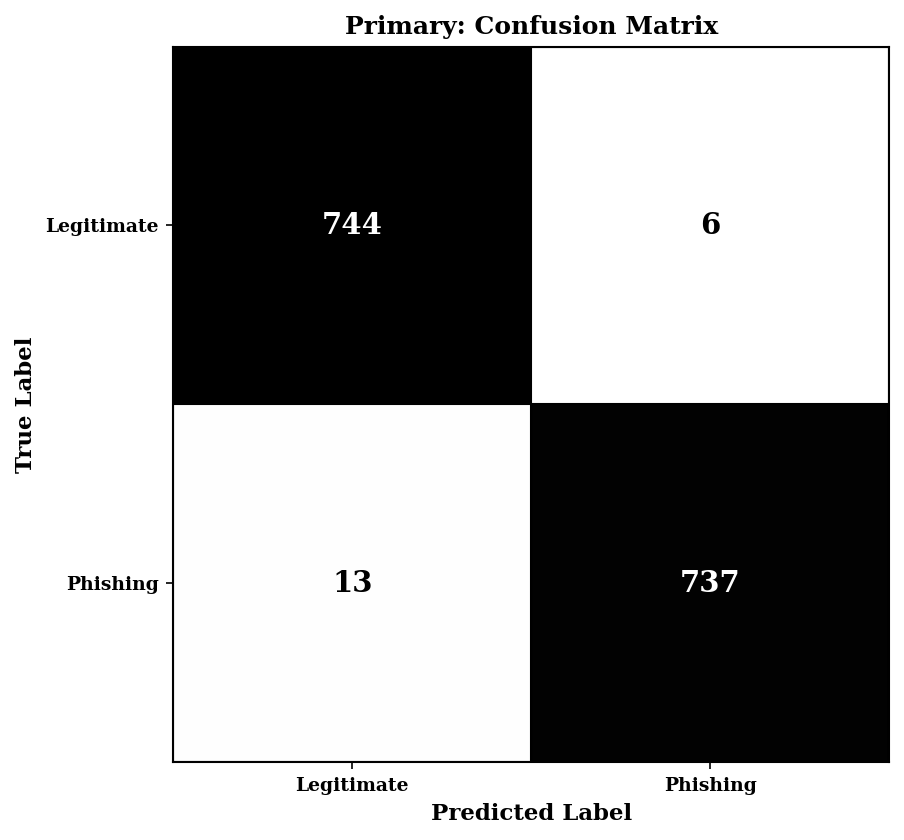

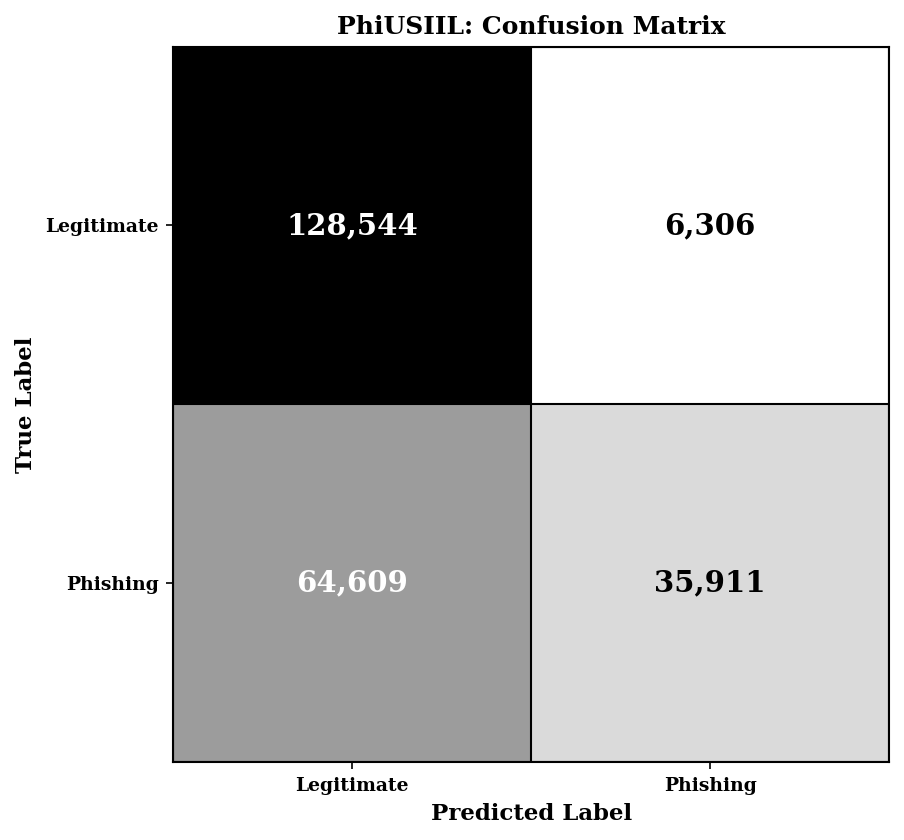

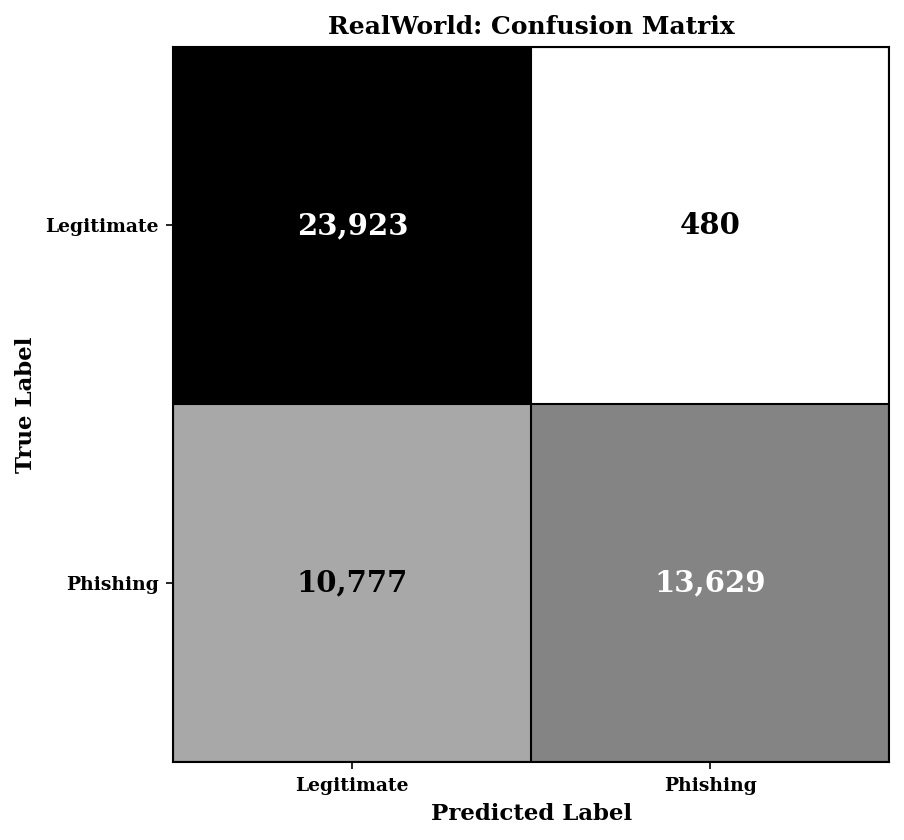

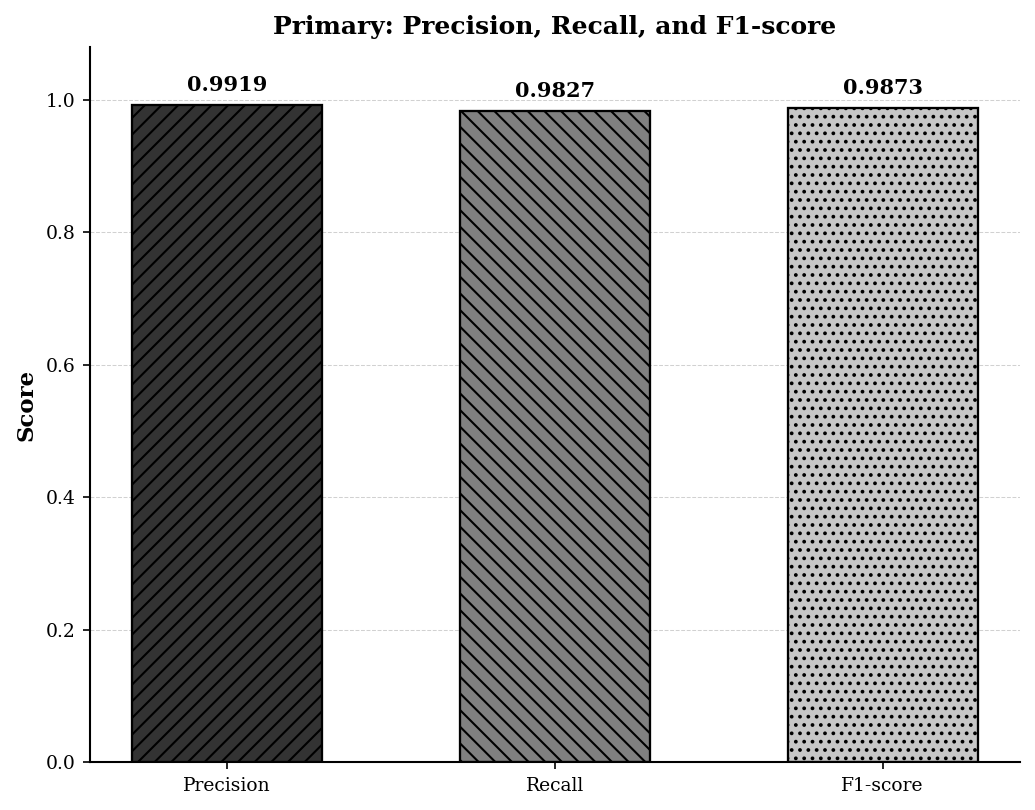

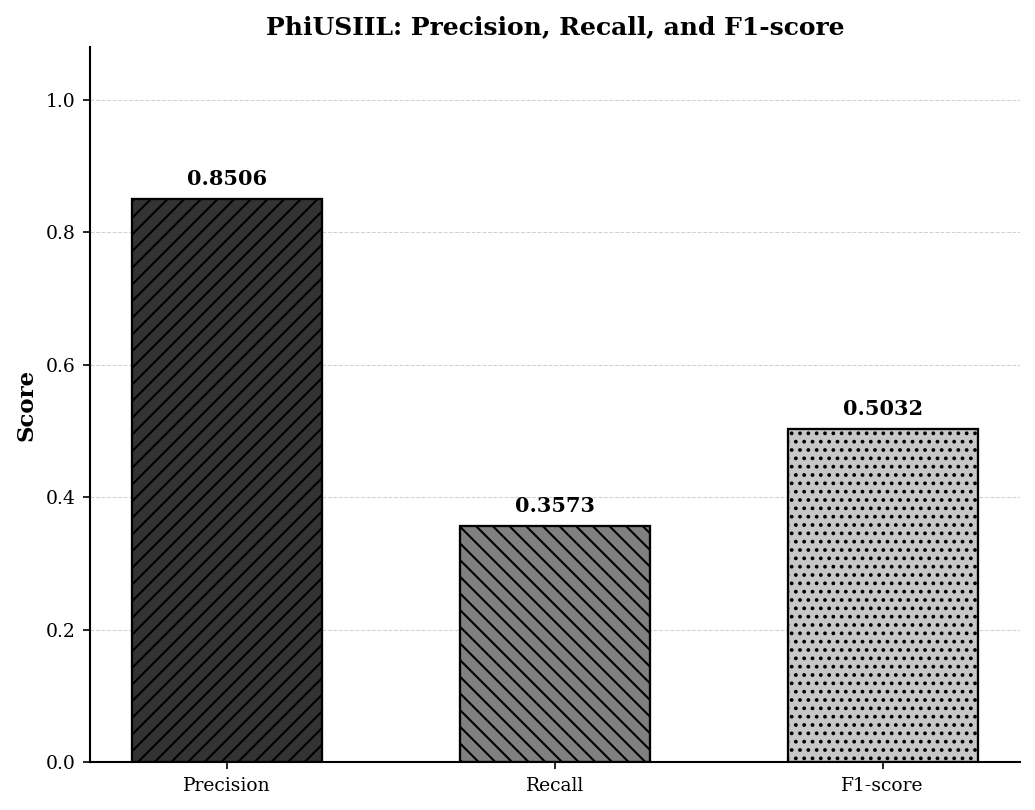

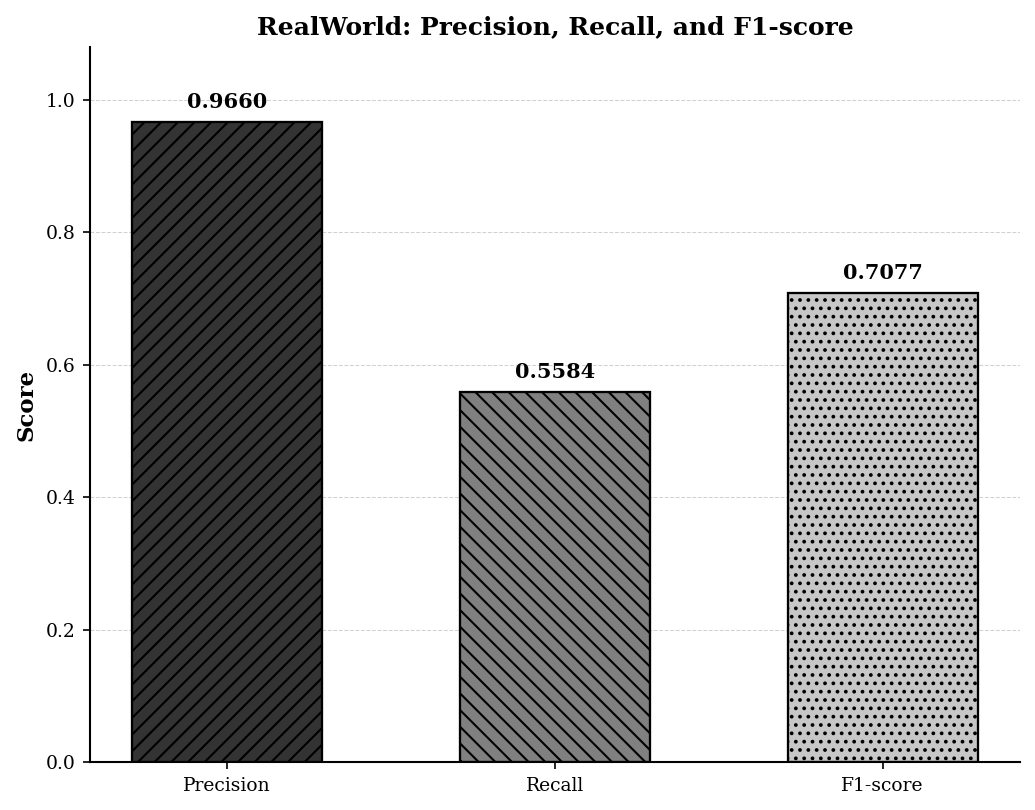

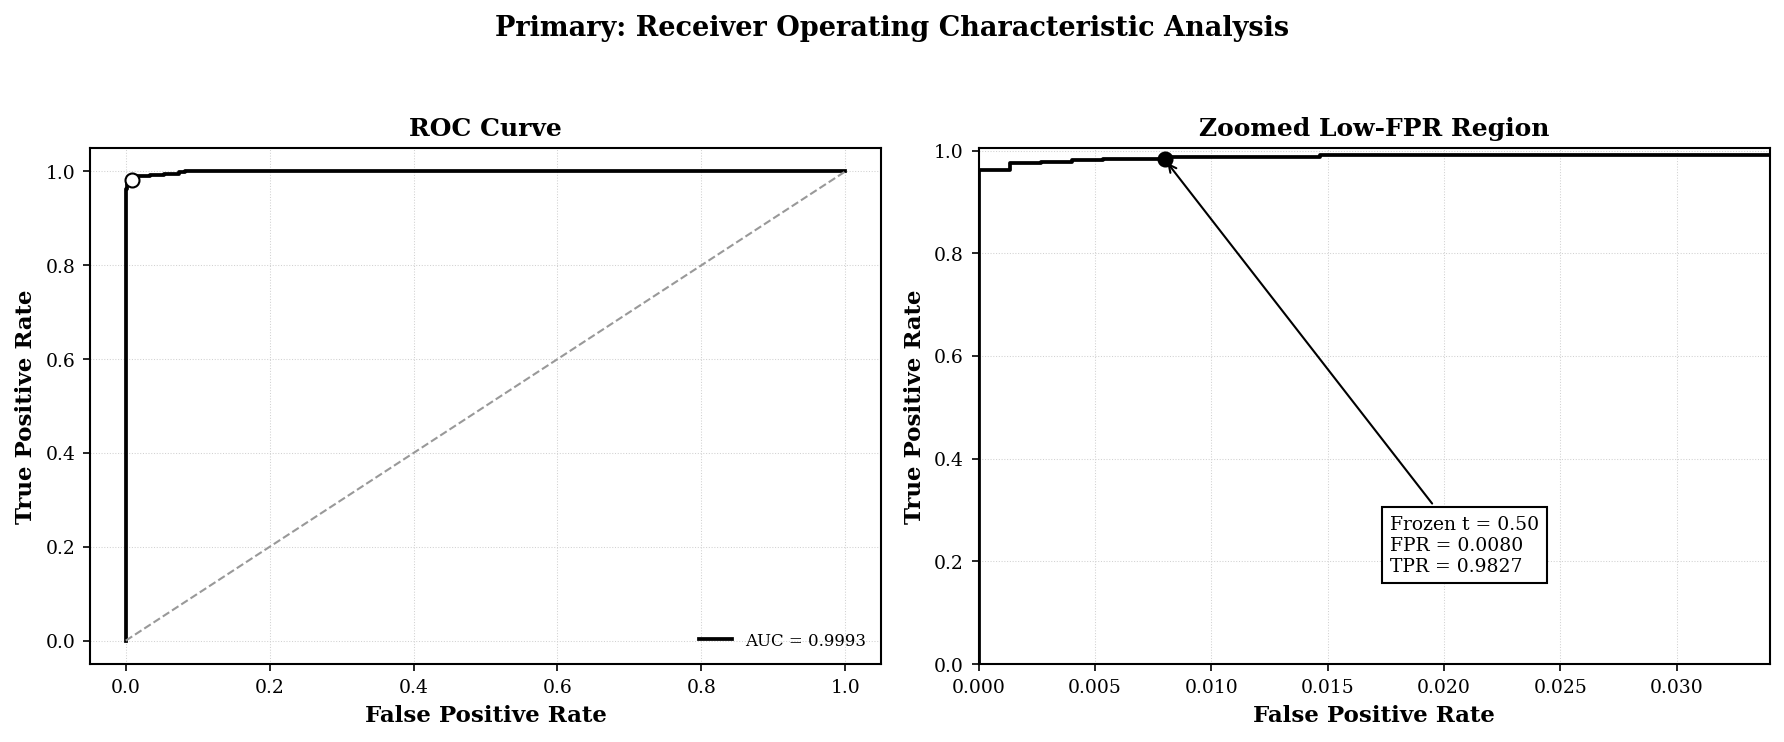

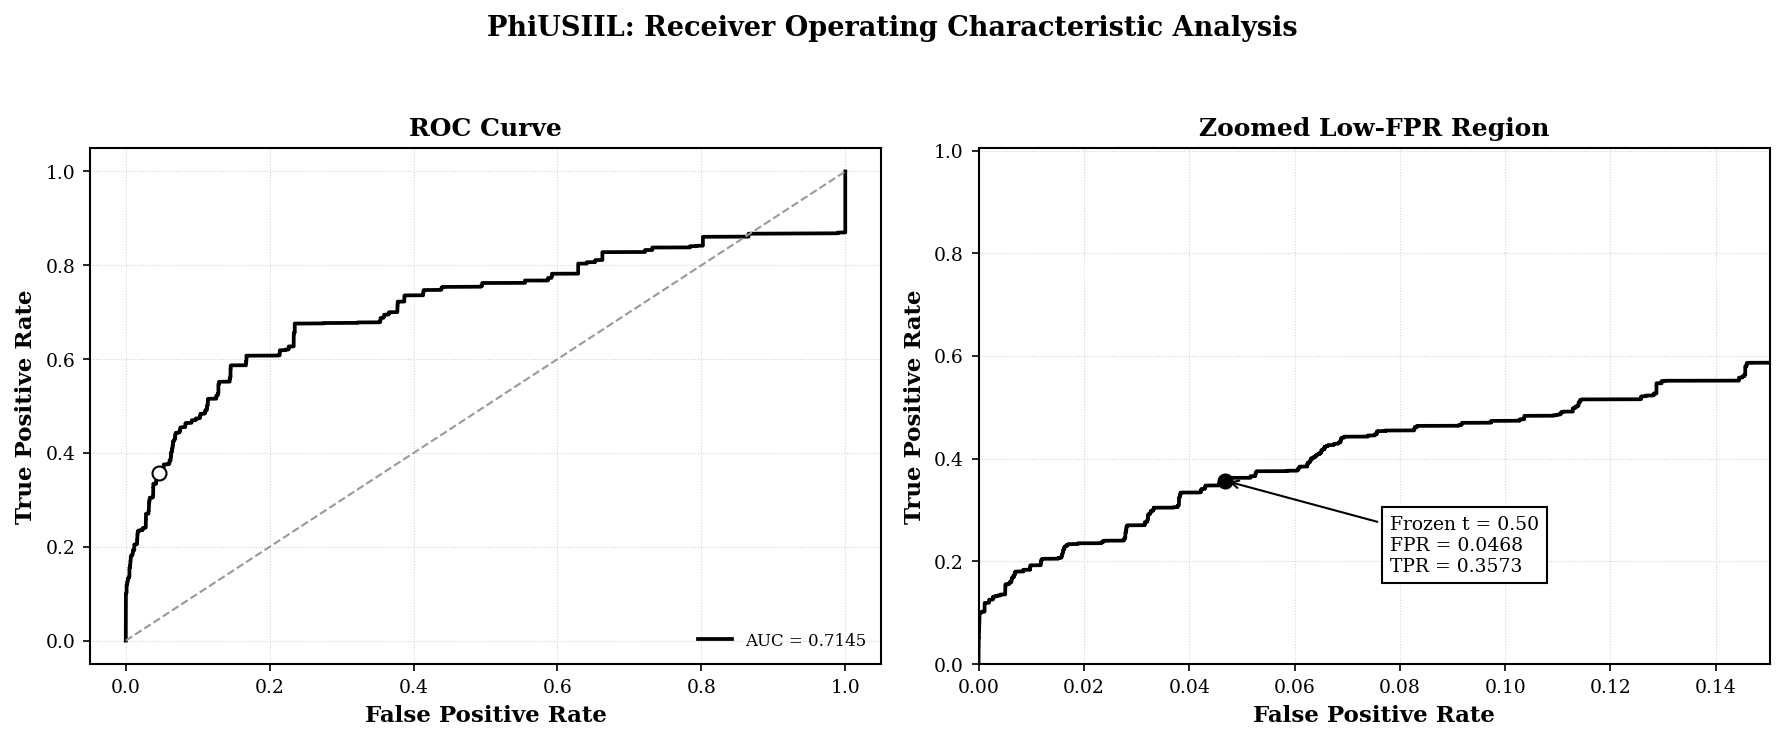

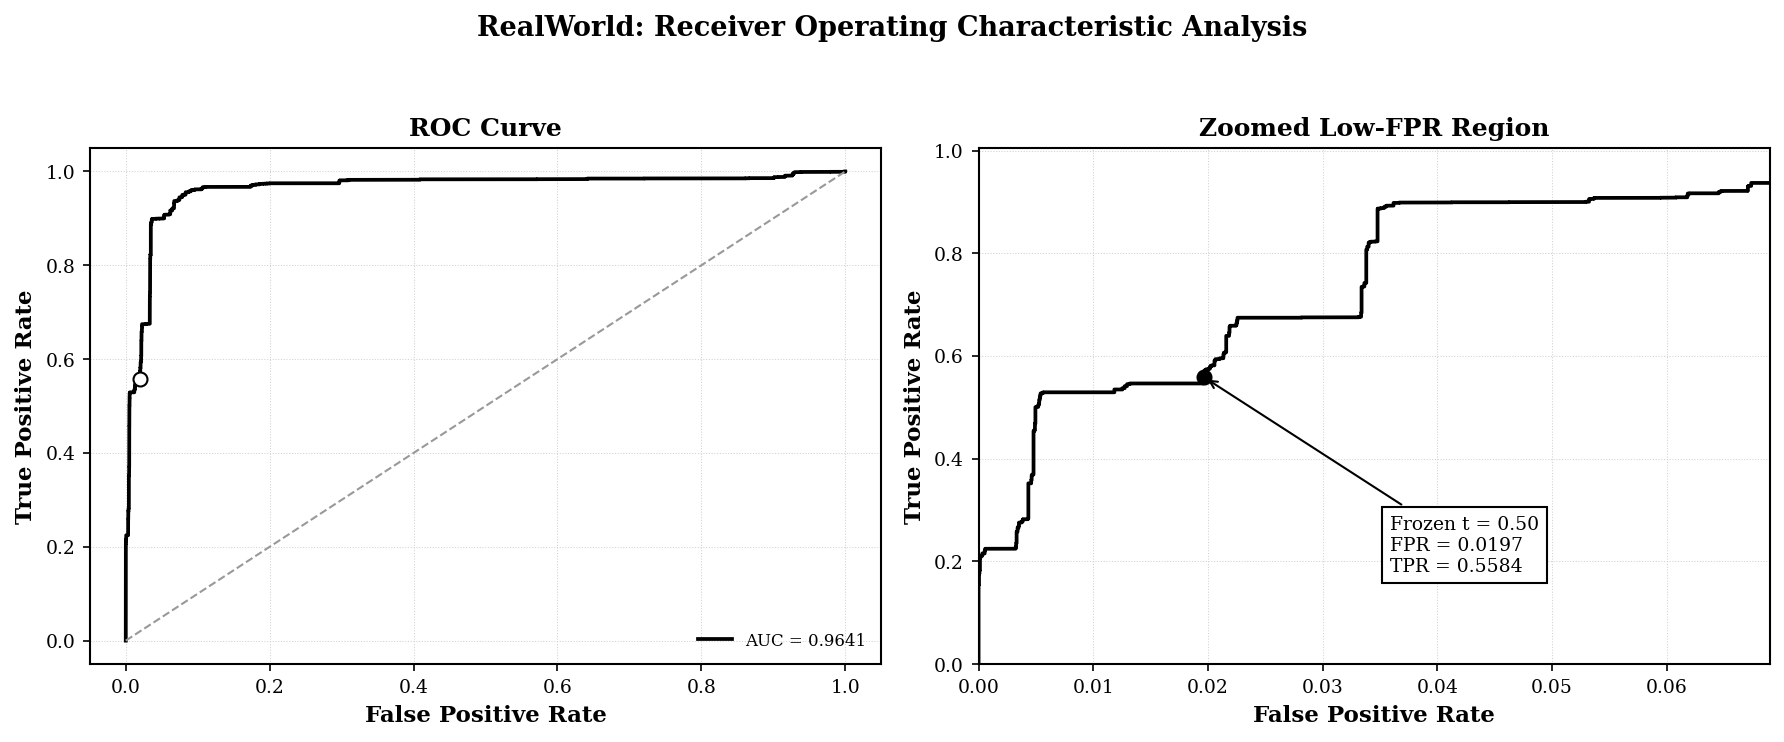

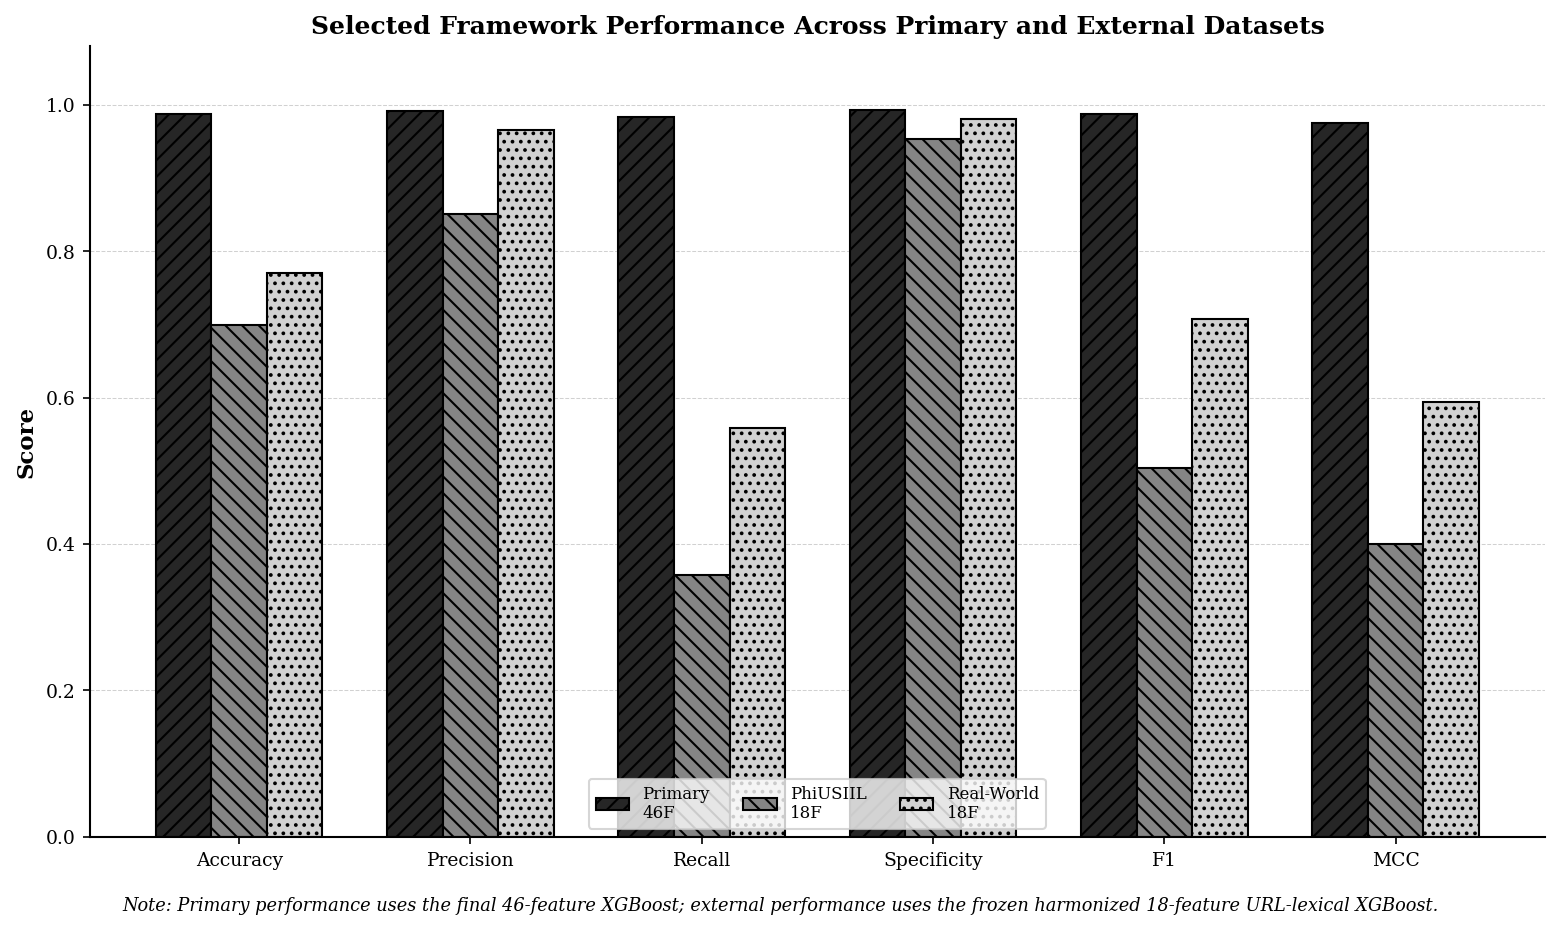

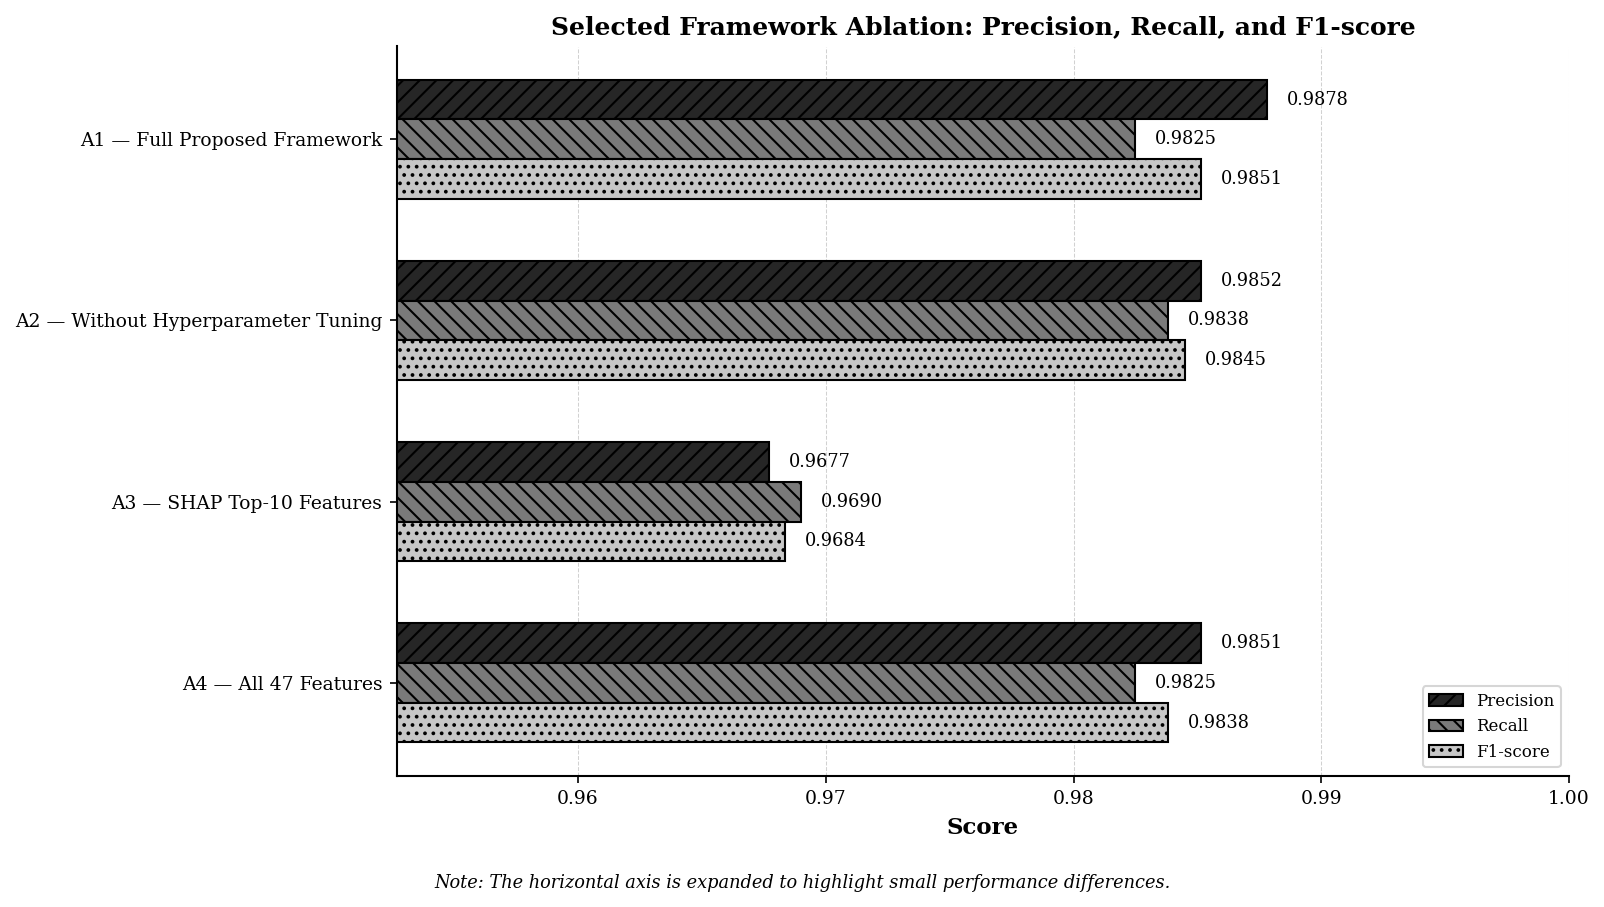


STEP 21 UPDATED COMPLETED

Verified three-dataset metrics:


,Dataset,Feature space,Evaluation,N,Accuracy,Precision,Recall,Specificity,F1,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Primary: Phishing_Legitimate_full,46-feature final XGBoost,Sealed test,1500,0.987333,0.991925,0.982667,0.992000,0.987274,0.974709,0.999275,0.999310,744,6,13,737
1,External: PhiUSIIL,18-feature harmonized XGBoost,Inference-only external,235370,0.698708,0.850629,0.357252,0.953237,0.503177,0.400317,0.714529,0.730490,128544,6306,64609,35911
2,External: Real-World Kaggle,18-feature harmonized XGBoost,Inference-only external,48809,0.769366,0.965979,0.558428,0.980330,0.707724,0.594225,0.964145,0.966552,23923,480,10777,13629



Publication tables generated: 9


,table,title
0,Table_01_Data_Split_Description,Leakage-safe data split summary
1,Table_02_Group_Safe_Model_Screening,Group-aware model family screening
2,Table_03_Final_Sealed_Test_Performance,Final frozen XGBoost performance on the sealed...
3,Table_03B_Sealed_Test_Confusion_Matrix,Sealed-test confusion matrix
4,Table_04_SHAP_Feature_Importance,Top SHAP-ranked features
5,Table_05_Ablation_Study,Leakage-safe ablation study
6,Table_06_Robustness_Analysis,Robustness under perturbation scenarios
7,Table_07_Primary_and_Main_External_Performance,Primary sealed-test and main cross-dataset ext...
8,Table_08_Three_Dataset_Confusion_Matrices,Confusion-matrix counts for the primary and tw...



Required figures generated: 11


,figure,title
0,Figure_01_Primary_Confusion_Matrix_BW,Primary: Phishing_Legitimate_full confusion ma...
1,Figure_02_PhiUSIIL_Confusion_Matrix_BW,External: PhiUSIIL confusion matrix
2,Figure_03_RealWorld_Confusion_Matrix_BW,External: Real-World Kaggle confusion matrix
3,Figure_04_Primary_Precision_Recall_F1_BW,"Primary: Phishing_Legitimate_full precision, r..."
4,Figure_05_PhiUSIIL_Precision_Recall_F1_BW,"External: PhiUSIIL precision, recall and F1-score"
5,Figure_06_RealWorld_Precision_Recall_F1_BW,"External: Real-World Kaggle precision, recall ..."
6,Figure_07_Primary_ROC_Zoom_BW,Primary: Phishing_Legitimate_full ROC and low-...
7,Figure_08_PhiUSIIL_ROC_Zoom_BW,External: PhiUSIIL ROC and low-FPR analysis
8,Figure_09_RealWorld_ROC_Zoom_BW,External: Real-World Kaggle ROC and low-FPR an...
9,Figure_10_Three_Dataset_Comparison_BW,Primary and main external dataset performance ...



Selected-framework ZIP:
/kaggle/working/SELECTED_FRAMEWORK_JOURNAL_RESULTS.zip


/kaggle/working/SELECTED_FRAMEWORK_JOURNAL_RESULTS.zip

In [145]:
# =============================================================================
# STEP 21 — UPDATED
# VERIFIED JOURNAL TABLES + REQUIRED SELECTED-FRAMEWORK FIGURES
#
# DATASETS
# --------
# Primary:
#   Phishing_Legitimate_full
#   Final 46-feature XGBoost
#   Sealed test
#
# Main external:
#   PhiUSIIL
#   Real-World Kaggle
#   Frozen harmonized 18-feature URL-lexical model
#
# REQUIRED FIGURES
# ----------------
# 1-3  Confusion matrices
# 4-6  Precision / Recall / F1-score
# 7-9  ROC curves + low-FPR zoom
# 10   Three-dataset performance comparison
# 11   Ablation Precision / Recall / F1 bar graph
#
# FIGURE POLICY
# -------------
# Black & white / grayscale
# PNG  = 600 DPI
# TIFF = 600 DPI
# PDF  = vector
# SVG  = vector
#
# IMPORTANT
# ---------
# No manually typed performance values.
# =============================================================================

from pathlib import Path
import json
import shutil
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)

from IPython.display import FileLink, display

warnings.filterwarnings("ignore")


# =============================================================================
# 0. PATHS
# =============================================================================

ROOT = Path(
    "/kaggle/working/JOURNAL_SUBMISSION_PACKAGE"
)

TABLE_OUT = (
    ROOT / "tables"
)

FIG_OUT = (
    ROOT / "figures_selected_framework"
)

TABLE_OUT.mkdir(
    parents=True,
    exist_ok=True
)

FIG_OUT.mkdir(
    parents=True,
    exist_ok=True
)


table_manifest = []
figure_manifest = []


# =============================================================================
# 1. FALLBACK TABLE SAVER
#
# If save_publication_table was already defined in Step 20,
# the existing function will be used.
# =============================================================================

if "save_publication_table" not in globals():

    def save_publication_table(
        df,
        stem,
        output_dir
    ):

        csv_path = (
            output_dir /
            f"{stem}.csv"
        )

        xlsx_path = (
            output_dir /
            f"{stem}.xlsx"
        )

        df.to_csv(
            csv_path,
            index=False
        )

        df.to_excel(
            xlsx_path,
            index=False
        )

        return {
            "csv":
                str(csv_path),

            "xlsx":
                str(xlsx_path)
        }


def save_table(
    df,
    stem,
    title
):

    paths = save_publication_table(
        df,
        stem,
        TABLE_OUT
    )

    table_manifest.append({
        "table":
            stem,

        "title":
            title,

        **paths,
    })


# =============================================================================
# 2. PUBLICATION FIGURE STYLE
# =============================================================================

plt.rcParams.update({

    "font.family":
        "serif",

    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],

    "font.size":
        10,

    "axes.labelsize":
        11,

    "axes.titlesize":
        12,

    "axes.titleweight":
        "bold",

    "xtick.labelsize":
        9,

    "ytick.labelsize":
        9,

    "axes.linewidth":
        1.0,

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white",

    "savefig.facecolor":
        "white",

    "pdf.fonttype":
        42,

    "svg.fonttype":
        "none",
})


def save_figure(
    fig,
    stem,
    title
):

    png = (
        FIG_OUT /
        f"{stem}.png"
    )

    tiff = (
        FIG_OUT /
        f"{stem}.tiff"
    )

    pdf = (
        FIG_OUT /
        f"{stem}.pdf"
    )

    svg = (
        FIG_OUT /
        f"{stem}.svg"
    )


    fig.savefig(
        png,
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        tiff,
        dpi=600,
        bbox_inches="tight",
        pil_kwargs={
            "compression":
                "tiff_lzw"
        }
    )

    fig.savefig(
        pdf,
        bbox_inches="tight"
    )

    fig.savefig(
        svg,
        bbox_inches="tight"
    )


    figure_manifest.append({

        "figure":
            stem,

        "title":
            title,

        "png_600dpi":
            str(png),

        "tiff_600dpi":
            str(tiff),

        "pdf_vector":
            str(pdf),

        "svg_vector":
            str(svg),
    })


# =============================================================================
# 3. HELPERS
# =============================================================================

def first_existing(
    candidates
):

    for path in candidates:

        if path.exists():
            return path

    return None


def load_json(
    path
):

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        return json.load(f)


# =============================================================================
# 4. ENSURE PRIMARY SEALED-TEST PREDICTIONS EXIST
#
# If the prediction file disappeared from /kaggle/working,
# reconstruct it using the already-frozen Step-14 model.
#
# NO retraining.
# NO tuning.
# NO feature selection.
# =============================================================================

STEP14_DIR = Path(
    "/kaggle/working/"
    "step_14_final_test_evaluation"
)


PRIMARY_PRED_PATH = (
    STEP14_DIR /
    "test_predictions.csv.gz"
)


if not PRIMARY_PRED_PATH.exists():

    print(
        "Primary prediction artifact missing."
    )

    print(
        "Attempting safe reconstruction "
        "from frozen Step-14 model..."
    )


    MODEL_PATH = (
        STEP14_DIR /
        "final_test_xgboost_model.joblib"
    )

    TEST_PATH = Path(
        "/kaggle/working/"
        "step_03_leakage_safe_split/"
        "test_raw_15.csv.gz"
    )

    FEATURE_PATH = Path(
        "/kaggle/working/"
        "step_12_final_candidate_tuning/"
        "remove_numquerycomponents_feature_list.json"
    )


    required = {
        "Frozen Step-14 model":
            MODEL_PATH,

        "Step-3 sealed test":
            TEST_PATH,

        "Frozen feature list":
            FEATURE_PATH,
    }


    missing = [
        name
        for name, path
        in required.items()
        if not path.exists()
    ]


    if missing:

        raise FileNotFoundError(
            "Cannot reconstruct primary "
            "predictions. Missing:\n"
            +
            "\n".join(
                missing
            )
        )


    frozen_model = joblib.load(
        MODEL_PATH
    )


    feature_payload = load_json(
        FEATURE_PATH
    )


    if isinstance(
        feature_payload,
        list
    ):

        primary_features = (
            feature_payload
        )

    elif isinstance(
        feature_payload,
        dict
    ):

        primary_features = (
            feature_payload.get(
                "features"
            )
            or
            feature_payload.get(
                "selected_features"
            )
            or
            feature_payload.get(
                "feature_list"
            )
        )

    else:

        primary_features = None


    if not primary_features:

        raise ValueError(
            "Could not recover final "
            "46-feature list."
        )


    test_df = pd.read_csv(
        TEST_PATH,
        compression="gzip",
        low_memory=False
    )


    X_test = test_df[
        primary_features
    ]

    y_test = (
        test_df[
            "CLASS_LABEL"
        ]
        .astype(int)
    )


    primary_probability = (
        frozen_model
        .predict_proba(
            X_test
        )[:, 1]
    )


    primary_prediction = (
        primary_probability >= 0.50
    ).astype(int)


    reconstructed = pd.DataFrame({

        "id":
            (
                test_df["id"]
                if "id" in test_df.columns
                else np.arange(
                    len(test_df)
                )
            ),

        "actual_label":
            y_test.to_numpy(),

        "prediction_probability":
            primary_probability,

        "predicted_label":
            primary_prediction,
    })


    STEP14_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


    reconstructed.to_csv(
        PRIMARY_PRED_PATH,
        index=False,
        compression="gzip"
    )


    print(
        "Primary prediction artifact "
        "reconstructed:"
    )

    print(
        PRIMARY_PRED_PATH
    )


# =============================================================================
# 5. MAIN EXTERNAL PREDICTION FILES
# =============================================================================

PHI_PRED_PATH = first_existing([
    Path(
        "/kaggle/working/"
        "step_16P_phiusiil_external_generalization/"
        "phiusiil_deduplicated_predictions.csv.gz"
    ),
    Path(
        "/kaggle/working/"
        "step_16P_phiusiil_external_generalization/"
        "phiusiil_deduplicated_predictions.csv"
    ),
])


REAL_PRED_PATH = first_existing([
    Path(
        "/kaggle/working/"
        "step_16_external_generalization_final/"
        "realworld_overlap_free_predictions.csv.gz"
    ),
    Path(
        "/kaggle/working/"
        "step_16_external_generalization_final/"
        "realworld_overlap_free_predictions.csv"
    ),
])


if PHI_PRED_PATH is None:

    raise FileNotFoundError(
        "PhiUSIIL prediction artifact missing. "
        "Run STEP 16P-B/C first."
    )


if REAL_PRED_PATH is None:

    raise FileNotFoundError(
        "Real-World prediction artifact missing. "
        "Run STEP 16R-C first."
    )


# =============================================================================
# 6. LOAD + STANDARDIZE THREE DATASETS
# =============================================================================

primary = pd.read_csv(
    PRIMARY_PRED_PATH
)

phi = pd.read_csv(
    PHI_PRED_PATH
)

real = pd.read_csv(
    REAL_PRED_PATH
)


# Primary
primary = primary.rename(
    columns={
        "prediction_probability":
            "probability"
    }
)


# PhiUSIIL
phi = phi.rename(
    columns={
        "phishing_probability":
            "probability"
    }
)


# Real World
real = real.rename(
    columns={
        "phishing_probability":
            "probability"
    }
)


DATASETS = {

    "Primary: Phishing_Legitimate_full": {

        "df":
            primary,

        "short":
            "Primary",

        "feature_space":
            "46-feature final XGBoost",

        "evaluation":
            "Sealed test",
    },


    "External: PhiUSIIL": {

        "df":
            phi,

        "short":
            "PhiUSIIL",

        "feature_space":
            "18-feature harmonized XGBoost",

        "evaluation":
            "Inference-only external",
    },


    "External: Real-World Kaggle": {

        "df":
            real,

        "short":
            "RealWorld",

        "feature_space":
            "18-feature harmonized XGBoost",

        "evaluation":
            "Inference-only external",
    },
}


# =============================================================================
# 7. CALCULATE VERIFIED METRICS FROM PREDICTIONS
# =============================================================================

THRESHOLD = 0.50

performance_rows = []


for dataset_name, info in (
    DATASETS.items()
):

    df = info[
        "df"
    ].copy()


    needed = {
        "actual_label",
        "probability"
    }


    if not needed.issubset(
        df.columns
    ):

        raise ValueError(
            f"{dataset_name} missing "
            f"required columns: "
            f"{needed - set(df.columns)}"
        )


    y_true = (
        df["actual_label"]
        .astype(int)
        .to_numpy()
    )


    probability = (
        df["probability"]
        .astype(float)
        .to_numpy()
    )


    prediction = (
        probability >= THRESHOLD
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            prediction,
            labels=[0, 1]
        )
        .ravel()
    )


    specificity = (
        tn / (tn + fp)
    )


    performance_rows.append({

        "Dataset":
            dataset_name,

        "Feature space":
            info[
                "feature_space"
            ],

        "Evaluation":
            info[
                "evaluation"
            ],

        "N":
            len(y_true),

        "Accuracy":
            accuracy_score(
                y_true,
                prediction
            ),

        "Precision":
            precision_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                prediction
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probability
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp),
    })


performance_df = pd.DataFrame(
    performance_rows
)


# =============================================================================
# 8. ORIGINAL JOURNAL TABLES 1-6
# =============================================================================

# -----------------------------------------------------------------
# Table 1 — Split description
# -----------------------------------------------------------------

split_path = Path(
    "/kaggle/working/"
    "step_03_leakage_safe_split/"
    "split_summary.csv"
)

if split_path.exists():

    split_df = pd.read_csv(
        split_path
    )

    save_table(
        split_df,
        "Table_01_Data_Split_Description",
        "Leakage-safe data split summary",
    )


# -----------------------------------------------------------------
# Table 2 — Model family screening
# -----------------------------------------------------------------

screen_path = Path(
    "/kaggle/working/"
    "step_07_strong_model_screening/"
    "strong_model_screening_summary.csv"
)

if screen_path.exists():

    screen = pd.read_csv(
        screen_path
    )

    preferred = [
        "feature_set",
        "model",
        "accuracy_mean",
        "f1_mean",
        "mcc_mean",
        "roc_auc_mean",
        "pr_auc_mean",
        "accuracy_std",
        "f1_std",
        "mcc_std",
    ]

    keep = [
        c
        for c in preferred
        if c in screen.columns
    ]

    table2 = (
        screen[keep].copy()
        if keep
        else screen.copy()
    )


    save_table(
        table2,
        "Table_02_Group_Safe_Model_Screening",
        "Group-aware model family screening",
    )


# -----------------------------------------------------------------
# Table 3 — Final sealed-test performance
# -----------------------------------------------------------------

metrics_path = Path(
    "/kaggle/working/"
    "step_14_final_test_evaluation/"
    "test_metrics.json"
)

ci_path = Path(
    "/kaggle/working/"
    "step_14_final_test_evaluation/"
    "bootstrap_confidence_interval.json"
)


if metrics_path.exists():

    metrics = load_json(
        metrics_path
    )


    ci = (
        load_json(
            ci_path
        )
        if ci_path.exists()
        else {}
    )


    rows = []


    metric_map = [
        ("Accuracy", "accuracy"),
        ("Precision", "precision"),
        ("Recall", "recall"),
        ("Specificity", "specificity"),
        ("F1 score", "f1_score"),
        ("MCC", "mcc"),
        ("ROC-AUC", "roc_auc"),
        ("PR-AUC", "pr_auc"),
    ]


    for label, key in metric_map:

        if key not in metrics:
            continue


        row = {

            "Metric":
                label,

            "Value":
                float(
                    metrics[key]
                ),
        }


        ci_key = (
            "f1"
            if key == "f1_score"
            else key
        )


        if ci_key in ci:

            row[
                "Bootstrap 95% CI lower"
            ] = (
                ci[ci_key].get(
                    "lower_2.5_percentile"
                )
            )

            row[
                "Bootstrap 95% CI upper"
            ] = (
                ci[ci_key].get(
                    "upper_97.5_percentile"
                )
            )

        else:

            row[
                "Bootstrap 95% CI lower"
            ] = np.nan

            row[
                "Bootstrap 95% CI upper"
            ] = np.nan


        rows.append(
            row
        )


    table3 = pd.DataFrame(
        rows
    )


    save_table(
        table3,
        "Table_03_Final_Sealed_Test_Performance",
        (
            "Final frozen XGBoost performance "
            "on the sealed test partition"
        ),
    )


# -----------------------------------------------------------------
# Table 3B — Primary confusion matrix
# -----------------------------------------------------------------

primary_row = (
    performance_df.iloc[0]
)


cm_table = pd.DataFrame({

    "":
        [
            "Actual legitimate",
            "Actual phishing"
        ],

    "Predicted legitimate":
        [
            primary_row["TN"],
            primary_row["FN"]
        ],

    "Predicted phishing":
        [
            primary_row["FP"],
            primary_row["TP"]
        ],
})


save_table(
    cm_table,
    "Table_03B_Sealed_Test_Confusion_Matrix",
    "Sealed-test confusion matrix",
)


# -----------------------------------------------------------------
# Table 4 — SHAP
# -----------------------------------------------------------------

shap_path = Path(
    "/kaggle/working/"
    "step_15_xai_analysis/"
    "shap_feature_importance_all.csv"
)

if shap_path.exists():

    shap_df = pd.read_csv(
        shap_path
    )


    if {
        "feature",
        "mean_abs_shap"
    }.issubset(
        shap_df.columns
    ):

        table4 = (
            shap_df
            .sort_values(
                "mean_abs_shap",
                ascending=False
            )
            .head(20)
            .reset_index(
                drop=True
            )
        )


        table4.insert(
            0,
            "Rank",
            np.arange(
                1,
                len(table4) + 1
            )
        )


        save_table(
            table4,
            "Table_04_SHAP_Feature_Importance",
            "Top SHAP-ranked features",
        )


# -----------------------------------------------------------------
# Table 5 — Ablation
# -----------------------------------------------------------------

ABLATION_PATH = first_existing([

    Path(
        "/kaggle/working/"
        "step_19_journal_ablation/"
        "corrected_ablation_full_metrics.csv"
    ),

    Path(
        "/kaggle/working/"
        "step_19_journal_ablation/"
        "Table_Ablation_Publication.csv"
    ),
])


if ABLATION_PATH is None:

    raise FileNotFoundError(
        "Step-19 ablation artifact missing."
    )


ablation = pd.read_csv(
    ABLATION_PATH
)


save_table(
    ablation,
    "Table_05_Ablation_Study",
    "Leakage-safe ablation study",
)


# -----------------------------------------------------------------
# Table 6 — Robustness
# -----------------------------------------------------------------

robust_path = Path(
    "/kaggle/working/"
    "step_18_robustness_results/"
    "robustness_results.csv"
)


if robust_path.exists():

    robust = pd.read_csv(
        robust_path
    )


    save_table(
        robust,
        "Table_06_Robustness_Analysis",
        "Robustness under perturbation scenarios",
    )


# =============================================================================
# 9. UPDATED TABLE 7
# REPLACE OLD UCI TABLE AS MAIN EXTERNAL TABLE
# =============================================================================

save_table(
    performance_df,
    "Table_07_Primary_and_Main_External_Performance",
    (
        "Primary sealed-test and main "
        "cross-dataset external-generalization performance"
    ),
)


# =============================================================================
# 10. TABLE 8 — EXTERNAL CONFUSION MATRICES
# =============================================================================

cm_three = performance_df[
    [
        "Dataset",
        "N",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
].copy()


save_table(
    cm_three,
    "Table_08_Three_Dataset_Confusion_Matrices",
    (
        "Confusion-matrix counts for the "
        "primary and two main external datasets"
    ),
)


# =============================================================================
# 11. FIGURE FUNCTION — CONFUSION MATRIX
# =============================================================================

def plot_confusion(
    dataset_name,
    info,
    figure_number
):

    df = info[
        "df"
    ]


    y_true = (
        df["actual_label"]
        .astype(int)
        .to_numpy()
    )


    probability = (
        df["probability"]
        .astype(float)
        .to_numpy()
    )


    prediction = (
        probability >= THRESHOLD
    ).astype(int)


    cm = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1]
    )


    fig, ax = plt.subplots(
        figsize=(6.1, 5.7)
    )


    ax.imshow(
        cm,
        cmap="Greys",
        interpolation="nearest"
    )


    ax.set_xticks(
        [0, 1]
    )

    ax.set_yticks(
        [0, 1]
    )


    ax.set_xticklabels(
        [
            "Legitimate",
            "Phishing"
        ],
        fontweight="bold"
    )


    ax.set_yticklabels(
        [
            "Legitimate",
            "Phishing"
        ],
        fontweight="bold"
    )


    ax.set_xlabel(
        "Predicted Label",
        fontweight="bold"
    )


    ax.set_ylabel(
        "True Label",
        fontweight="bold"
    )


    ax.set_title(
        (
            f"{info['short']}: "
            "Confusion Matrix"
        )
    )


    threshold_text = (
        cm.max() / 2
    )


    for i in range(2):

        for j in range(2):

            ax.text(
                j,
                i,
                f"{cm[i,j]:,}",

                ha="center",
                va="center",

                fontsize=14,

                fontweight="bold",

                color=(
                    "white"
                    if cm[i,j] >
                    threshold_text
                    else "black"
                )
            )


    # visible borders
    ax.set_xticks(
        np.arange(
            -0.5,
            2,
            1
        ),
        minor=True
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            2,
            1
        ),
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=1.0
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )


    fig.tight_layout()


    stem = (
        f"Figure_{figure_number:02d}_"
        f"{info['short']}_Confusion_Matrix_BW"
    )


    save_figure(
        fig,
        stem,
        f"{dataset_name} confusion matrix"
    )


    plt.show()
    plt.close(fig)


# =============================================================================
# 12. FIGURE FUNCTION — PRECISION / RECALL / F1
# =============================================================================

def plot_metric_bars(
    dataset_name,
    info,
    figure_number
):

    row = (
        performance_df[
            performance_df[
                "Dataset"
            ] == dataset_name
        ]
        .iloc[0]
    )


    labels = [
        "Precision",
        "Recall",
        "F1-score"
    ]


    values = [
        row["Precision"],
        row["Recall"],
        row["F1"]
    ]


    fig, ax = plt.subplots(
        figsize=(7.0, 5.5)
    )


    x = np.arange(
        3
    )


    bars = ax.bar(
        x,
        values,

        width=0.58,

        color=[
            "0.20",
            "0.50",
            "0.78"
        ],

        edgecolor="black",

        linewidth=1.1
    )


    hatches = [
        "///",
        "\\\\\\",
        "..."
    ]


    for bar, hatch in zip(
        bars,
        hatches
    ):

        bar.set_hatch(
            hatch
        )


    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        labels
    )


    ax.set_ylim(
        0,
        1.08
    )


    ax.set_ylabel(
        "Score",
        fontweight="bold"
    )


    ax.set_title(
        (
            f"{info['short']}: "
            "Precision, Recall, and F1-score"
        )
    )


    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        color="0.82"
    )

    ax.set_axisbelow(
        True
    )


    for bar, value in zip(
        bars,
        values
    ):

        ax.text(
            (
                bar.get_x()
                + bar.get_width()/2
            ),

            value + 0.015,

            f"{value:.4f}",

            ha="center",
            va="bottom",

            fontweight="bold"
        )


    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


    fig.tight_layout()


    stem = (
        f"Figure_{figure_number:02d}_"
        f"{info['short']}_"
        "Precision_Recall_F1_BW"
    )


    save_figure(
        fig,
        stem,
        (
            f"{dataset_name} precision, "
            "recall and F1-score"
        )
    )


    plt.show()
    plt.close(fig)


# =============================================================================
# 13. FIGURE FUNCTION — ROC + LOW-FPR ZOOM
#
# Frozen threshold 0.50 only.
# No threshold tuning.
# =============================================================================

def plot_roc_zoom(
    dataset_name,
    info,
    figure_number
):

    df = info[
        "df"
    ]


    y_true = (
        df["actual_label"]
        .astype(int)
        .to_numpy()
    )


    probability = (
        df["probability"]
        .astype(float)
        .to_numpy()
    )


    fpr, tpr, _ = (
        roc_curve(
            y_true,
            probability
        )
    )


    auc_value = (
        roc_auc_score(
            y_true,
            probability
        )
    )


    prediction = (
        probability >= THRESHOLD
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            prediction,
            labels=[0,1]
        )
        .ravel()
    )


    operating_fpr = (
        fp / (fp + tn)
    )


    operating_tpr = (
        tp / (tp + fn)
    )


    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12.0, 5.0)
    )


    # Main ROC
    axes[0].plot(
        fpr,
        tpr,
        color="black",
        linewidth=1.8,
        label=(
            f"AUC = "
            f"{auc_value:.4f}"
        )
    )


    axes[0].plot(
        [0,1],
        [0,1],
        color="0.60",
        linestyle="--",
        linewidth=1
    )


    axes[0].scatter(
        operating_fpr,
        operating_tpr,

        facecolor="white",
        edgecolor="black",

        s=45,
        zorder=5
    )


    axes[0].set_xlabel(
        "False Positive Rate",
        fontweight="bold"
    )

    axes[0].set_ylabel(
        "True Positive Rate",
        fontweight="bold"
    )

    axes[0].set_title(
        "ROC Curve"
    )

    axes[0].legend(
        loc="lower right"
    )

    axes[0].grid(
        linestyle=":",
        linewidth=0.5,
        color="0.82"
    )


    # Adaptive zoom
    zoom_max = max(
        0.03,
        min(
            0.25,
            operating_fpr * 3
            + 0.01
        )
    )


    zoom_mask = (
        fpr <= zoom_max
    )


    if np.any(
        zoom_mask
    ):

        zoom_min_tpr = max(
            0,
            float(
                tpr[
                    zoom_mask
                ].min()
            )
            - 0.05
        )

    else:

        zoom_min_tpr = 0


    axes[1].plot(
        fpr,
        tpr,
        color="black",
        linewidth=1.8
    )


    axes[1].scatter(
        operating_fpr,
        operating_tpr,
        color="black",
        s=45,
        zorder=5
    )


    axes[1].annotate(
        (
            f"Frozen t = {THRESHOLD:.2f}\n"
            f"FPR = {operating_fpr:.4f}\n"
            f"TPR = {operating_tpr:.4f}"
        ),

        xy=(
            operating_fpr,
            operating_tpr
        ),

        xytext=(
            0.52,
            0.18
        ),

        textcoords="axes fraction",

        arrowprops={
            "arrowstyle":
                "->",

            "color":
                "black"
        },

        bbox={
            "facecolor":
                "white",

            "edgecolor":
                "black"
        },

        fontsize=9
    )


    axes[1].set_xlim(
        0,
        zoom_max
    )

    axes[1].set_ylim(
        zoom_min_tpr,
        1.005
    )


    axes[1].set_xlabel(
        "False Positive Rate",
        fontweight="bold"
    )

    axes[1].set_ylabel(
        "True Positive Rate",
        fontweight="bold"
    )

    axes[1].set_title(
        "Zoomed Low-FPR Region"
    )

    axes[1].grid(
        linestyle=":",
        linewidth=0.5,
        color="0.82"
    )


    fig.suptitle(
        (
            f"{info['short']}: "
            "Receiver Operating "
            "Characteristic Analysis"
        ),

        fontsize=13,

        fontweight="bold"
    )


    fig.tight_layout(
        rect=[
            0,
            0,
            1,
            0.94
        ]
    )


    stem = (
        f"Figure_{figure_number:02d}_"
        f"{info['short']}_ROC_Zoom_BW"
    )


    save_figure(
        fig,
        stem,
        (
            f"{dataset_name} ROC "
            "and low-FPR analysis"
        )
    )


    plt.show()
    plt.close(fig)


# =============================================================================
# 14. GENERATE FIGURES 1-9
# =============================================================================

figure_number = 1


# 1-3 confusion matrices
for dataset_name, info in (
    DATASETS.items()
):

    plot_confusion(
        dataset_name,
        info,
        figure_number
    )

    figure_number += 1


# 4-6 precision recall F1
for dataset_name, info in (
    DATASETS.items()
):

    plot_metric_bars(
        dataset_name,
        info,
        figure_number
    )

    figure_number += 1


# 7-9 ROC
for dataset_name, info in (
    DATASETS.items()
):

    plot_roc_zoom(
        dataset_name,
        info,
        figure_number
    )

    figure_number += 1


# =============================================================================
# 15. FIGURE 10 — THREE-DATASET COMPARISON
# =============================================================================

comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "MCC"
]


short_names = [
    "Primary\n46F",
    "PhiUSIIL\n18F",
    "Real-World\n18F"
]


fig, ax = plt.subplots(
    figsize=(10.5, 6.0)
)


x = np.arange(
    len(
        comparison_metrics
    )
)


width = 0.24


gray_values = [
    "0.15",
    "0.52",
    "0.82"
]


hatches = [
    "///",
    "\\\\\\",
    "..."
]


for i, row in (
    performance_df.iterrows()
):

    values = [
        row[m]
        for m
        in comparison_metrics
    ]


    ax.bar(
        x
        + (
            i - 1
        ) * width,

        values,

        width,

        label=
            short_names[i],

        color=
            gray_values[i],

        edgecolor=
            "black",

        hatch=
            hatches[i],

        linewidth=
            1.0
    )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    comparison_metrics
)


ax.set_ylabel(
    "Score",
    fontweight="bold"
)


ax.set_ylim(
    0,
    1.08
)


ax.set_title(
    (
        "Selected Framework Performance "
        "Across Primary and External Datasets"
    )
)


ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    color="0.82"
)

ax.set_axisbelow(
    True
)


ax.legend(
    ncol=3,
    loc="lower center",
    frameon=True
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


fig.text(
    0.5,
    -0.02,

    (
        "Note: Primary performance uses the "
        "final 46-feature XGBoost; external "
        "performance uses the frozen harmonized "
        "18-feature URL-lexical XGBoost."
    ),

    ha="center",

    fontsize=8.5,

    style="italic"
)


fig.tight_layout()


save_figure(
    fig,
    "Figure_10_Three_Dataset_Comparison_BW",
    (
        "Primary and main external "
        "dataset performance comparison"
    )
)


plt.show()
plt.close(fig)


# =============================================================================
# 16. FIGURE 11 — ABLATION BAR GRAPH
# =============================================================================

# Case-insensitive column resolver
ab_lut = {
    c.lower():
        c
    for c in ablation.columns
}


variant_col = (
    ab_lut.get(
        "variant"
    )
)


precision_col = (
    ab_lut.get(
        "precision"
    )
)


recall_col = (
    ab_lut.get(
        "recall"
    )
)


f1_col = (
    ab_lut.get(
        "f1"
    )
    or
    ab_lut.get(
        "f1_score"
    )
)


if not all([
    variant_col,
    precision_col,
    recall_col,
    f1_col
]):

    raise ValueError(
        "Ablation file must contain "
        "Variant, Precision, Recall and F1."
    )


plot_ablation = (
    ablation.copy()
)


desired_order = [
    "Full Proposed Framework",
    "Without Hyperparameter Tuning",
    "SHAP Top-10 Features",
    "All 47 Features (No Final Feature Removal)"
]


plot_ablation[
    "_order"
] = (
    plot_ablation[
        variant_col
    ]
    .apply(
        lambda x:
            desired_order.index(x)
            if x in desired_order
            else 999
    )
)


plot_ablation = (
    plot_ablation
    .sort_values(
        "_order"
    )
    .reset_index(
        drop=True
    )
)


display_names = {

    "Full Proposed Framework":
        "A1 — Full Proposed Framework",

    "Without Hyperparameter Tuning":
        "A2 — Without Hyperparameter Tuning",

    "SHAP Top-10 Features":
        "A3 — SHAP Top-10 Features",

    "All 47 Features (No Final Feature Removal)":
        "A4 — All 47 Features",
}


names = [
    display_names.get(
        x,
        x
    )
    for x
    in plot_ablation[
        variant_col
    ]
]


y = np.arange(
    len(
        plot_ablation
    )
)


height = 0.22


metric_columns = [
    precision_col,
    recall_col,
    f1_col
]


metric_labels = [
    "Precision",
    "Recall",
    "F1-score"
]


gray_values = [
    "0.15",
    "0.48",
    "0.78"
]


hatches = [
    "///",
    "\\\\\\",
    "..."
]


fig, ax = plt.subplots(
    figsize=(10.8, 6.0)
)


for index, (
    column,
    label
) in enumerate(
    zip(
        metric_columns,
        metric_labels
    )
):

    offset = (
        index - 1
    ) * height


    bars = ax.barh(
        y + offset,

        plot_ablation[
            column
        ].astype(float),

        height=height,

        label=label,

        color=
            gray_values[index],

        edgecolor=
            "black",

        hatch=
            hatches[index],

        linewidth=
            1.0
    )


    for bar, value in zip(
        bars,
        plot_ablation[
            column
        ].astype(float)
    ):

        ax.text(
            value + 0.0008,

            bar.get_y()
            + bar.get_height()/2,

            f"{value:.4f}",

            va="center",

            fontsize=8.5
        )


ax.set_yticks(
    y
)

ax.set_yticklabels(
    names
)


ax.invert_yaxis()


all_values = (
    plot_ablation[
        metric_columns
    ]
    .astype(float)
    .to_numpy()
)


xmin = max(
    0,
    float(
        all_values.min()
    ) - 0.015
)


xmax = min(
    1.0,
    float(
        all_values.max()
    ) + 0.015
)


ax.set_xlim(
    xmin,
    xmax
)


ax.set_xlabel(
    "Score",
    fontweight="bold"
)


ax.set_title(
    (
        "Selected Framework Ablation: "
        "Precision, Recall, and F1-score"
    )
)


ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.5,
    color="0.82"
)

ax.set_axisbelow(
    True
)


ax.legend(
    loc="lower right",
    frameon=True
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


fig.text(
    0.5,
    0.005,

    (
        "Note: The horizontal axis is expanded "
        "to highlight small performance differences."
    ),

    ha="center",

    fontsize=8.5,

    style="italic"
)


fig.tight_layout(
    rect=[
        0,
        0.035,
        1,
        1
    ]
)


save_figure(
    fig,
    "Figure_11_Selected_Framework_Ablation_BW",
    (
        "Leakage-safe ablation analysis "
        "of the selected framework"
    )
)


plt.show()
plt.close(fig)


# =============================================================================
# 17. SAVE MANIFESTS
# =============================================================================

table_manifest_df = pd.DataFrame(
    table_manifest
)


figure_manifest_df = pd.DataFrame(
    figure_manifest
)


table_manifest_df.to_csv(
    TABLE_OUT /
    "table_manifest.csv",
    index=False
)


table_manifest_df.to_excel(
    TABLE_OUT /
    "table_manifest.xlsx",
    index=False
)


figure_manifest_df.to_csv(
    FIG_OUT /
    "figure_manifest.csv",
    index=False
)


figure_manifest_df.to_excel(
    FIG_OUT /
    "figure_manifest.xlsx",
    index=False
)


# =============================================================================
# 18. ZIP SELECTED-FRAMEWORK TABLES + FIGURES
# =============================================================================

PACKAGE_DIR = Path(
    "/kaggle/working/"
    "SELECTED_FRAMEWORK_JOURNAL_RESULTS"
)


if PACKAGE_DIR.exists():

    shutil.rmtree(
        PACKAGE_DIR
    )


PACKAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


shutil.copytree(
    FIG_OUT,
    PACKAGE_DIR / "figures"
)


# Copy key tables only
KEY_TABLES = [
    "Table_03_Final_Sealed_Test_Performance",
    "Table_03B_Sealed_Test_Confusion_Matrix",
    "Table_05_Ablation_Study",
    "Table_07_Primary_and_Main_External_Performance",
    "Table_08_Three_Dataset_Confusion_Matrices",
]


selected_tables_dir = (
    PACKAGE_DIR / "tables"
)

selected_tables_dir.mkdir(
    parents=True,
    exist_ok=True
)


for stem in KEY_TABLES:

    for suffix in [
        ".csv",
        ".xlsx"
    ]:

        src = (
            TABLE_OUT /
            f"{stem}{suffix}"
        )

        if src.exists():

            shutil.copy2(
                src,
                selected_tables_dir /
                src.name
            )


ZIP_PATH = shutil.make_archive(
    "/kaggle/working/"
    "SELECTED_FRAMEWORK_JOURNAL_RESULTS",

    "zip",

    root_dir=PACKAGE_DIR
)


# =============================================================================
# 19. FINAL REPORT
# =============================================================================

print(
    "\n"
    + "=" * 90
)

print(
    "STEP 21 UPDATED COMPLETED"
)

print(
    "=" * 90
)


print(
    "\nVerified three-dataset metrics:"
)

display(
    performance_df
)


print(
    "\nPublication tables generated:",
    len(
        table_manifest_df
    )
)


display(
    table_manifest_df[
        [
            "table",
            "title"
        ]
    ]
)


print(
    "\nRequired figures generated:",
    len(
        figure_manifest_df
    )
)


display(
    figure_manifest_df[
        [
            "figure",
            "title"
        ]
    ]
)


print(
    "\nSelected-framework ZIP:"
)

print(
    ZIP_PATH
)


display(
    FileLink(
        ZIP_PATH
    )
)

In [146]:
# ============================================
# Real-world dataset source audit (FIXED)
# ============================================


import pandas as pd
import os



# ------------------------------------------------
# Load correct dataframe
# ------------------------------------------------


if "real_world_df" in globals():

    print(
        "Using real_world_df"
    )


elif "real_world" in globals():

    print(
        "Using real_world"
    )

    real_world_df = real_world.copy()


elif "external_df" in globals():

    print(
        "Using external_df"
    )

    real_world_df = external_df.copy()


elif os.path.exists(
    "outputs/datasets/clean_real_world_phishing_dataset.csv"
):

    print(
        "Loading saved real-world dataset"
    )

    real_world_df = pd.read_csv(
        "outputs/datasets/clean_real_world_phishing_dataset.csv"
    )


else:

    raise NameError(
        "No real-world dataset found. Run STEP 13.1 first."
    )



print(
    "Dataset shape:",
    real_world_df.shape
)


print(
    real_world_df.columns.tolist()
)



# ============================================
# Source-label audit
# ============================================


if "source" in real_world_df.columns:

    source_audit = (

        real_world_df

        .groupby(
            [
                "source",
                "label"
            ]
        )

        .size()

        .reset_index(
            name="samples"
        )

    )


    display(
        source_audit
    )


else:

    print(
        "No source column available"
    )



# ============================================
# Domain overlap check
# ============================================


from urllib.parse import urlparse



def extract_domain(url):

    try:

        host = urlparse(
            str(url)
        ).netloc


        return host.lower()


    except:

        return "unknown"



real_world_df["domain"] = (

    real_world_df["url"]

    .apply(
        extract_domain
    )

)



domain_overlap = (

    real_world_df

    .groupby(
        "domain"
    )

    ["label"]

    .nunique()

)



mixed_domains = domain_overlap[

    domain_overlap > 1

]



print(
    "Domains containing both classes:",
    len(mixed_domains)
)

Using real_world
Dataset shape: (48812, 3)
['url', 'label', 'source']


,source,label,samples
0,openphish,1,300
1,tranco,0,24406
2,urlhaus,1,24106


Domains containing both classes: 8


In [147]:
# ============================================================
# Threshold Transfer Analysis (FIXED)
# ============================================================


import pandas as pd
import numpy as np

from sklearn.metrics import (
    recall_score,
    precision_score,
    matthews_corrcoef,
    average_precision_score
)



# ------------------------------------------------------------
# Define thresholds
# ------------------------------------------------------------


thresholds = [

    0.3,
    0.4,
    0.5,
    0.6,
    0.7

]



# ------------------------------------------------------------
# Check external prediction variables
# ------------------------------------------------------------


print(
    "External probability shape:",
    np.shape(external_prob)
)


print(
    "External labels shape:",
    np.shape(y_external)
)



# ------------------------------------------------------------
# Threshold evaluation
# ------------------------------------------------------------


threshold_results = []



for t in thresholds:


    y_pred = (

        external_prob >= t

    ).astype(int)



    threshold_results.append({

        "Threshold":

        t,


        "Recall":

        recall_score(

            y_external,

            y_pred,

            zero_division=0

        ),


        "Precision":

        precision_score(

            y_external,

            y_pred,

            zero_division=0

        ),


        "MCC":

        matthews_corrcoef(

            y_external,

            y_pred

        ),


        "PR_AUC":

        average_precision_score(

            y_external,

            external_prob

        )

    })



# ------------------------------------------------------------
# Results
# ------------------------------------------------------------


threshold_df = pd.DataFrame(

    threshold_results

)



display(
    threshold_df
)



# ------------------------------------------------------------
# Save
# ------------------------------------------------------------


import os


os.makedirs(

    "outputs/tables",

    exist_ok=True

)



threshold_df.to_csv(

    "outputs/tables/threshold_transfer_analysis.csv",

    index=False

)



print(
    "Threshold analysis saved"
)

External probability shape: (48812,)
External labels shape: (48812,)


,Threshold,Recall,Precision,MCC,PR_AUC
0,0.3,0.658772,0.967796,0.672031,0.966551
1,0.4,0.595673,0.965467,0.621784,0.966551
2,0.5,0.558428,0.965979,0.594239,0.966551
3,0.6,0.522413,0.989830,0.586564,0.966551
4,0.7,0.466689,0.989574,0.543901,0.966551


Threshold analysis saved


In [148]:
# ================================================================
# STEP 22
# FINAL JOURNAL AUDIT + SUBMISSION PACKAGE
# ================================================================

from pathlib import Path
import json
import hashlib
import shutil
import pandas as pd

ROOT = Path("/kaggle/working/JOURNAL_SUBMISSION_PACKAGE")
META = ROOT / "metadata"
META.mkdir(parents=True, exist_ok=True)

required_artifacts = {
    "Step 3 train":
        Path("/kaggle/working/step_03_leakage_safe_split/train_raw_70.csv.gz"),
    "Step 3 validation":
        Path("/kaggle/working/step_03_leakage_safe_split/validation_raw_15.csv.gz"),
    "Step 3 test":
        Path("/kaggle/working/step_03_leakage_safe_split/test_raw_15.csv.gz"),
    "Step 12 final features":
        Path(
            "/kaggle/working/step_12_final_candidate_tuning/"
            "remove_numquerycomponents_feature_list.json"
        ),
    "Step 12 tuned parameters":
        Path(
            "/kaggle/working/step_12_final_candidate_tuning/"
            "remove_numquerycomponents_best_parameters.json"
        ),
    "Step 14 sealed-test metrics":
        Path(
            "/kaggle/working/step_14_final_test_evaluation/"
            "test_metrics.json"
        ),
    "Step 14 frozen test model":
        Path(
            "/kaggle/working/step_14_final_test_evaluation/"
            "final_test_xgboost_model.joblib"
        ),
    "Step 15 SHAP importance":
        Path(
            "/kaggle/working/step_15_xai_analysis/"
            "shap_feature_importance_all.csv"
        ),
    "Corrected ablation":
        Path(
            "/kaggle/working/step_19_journal_ablation/"
            "Table_Ablation_Publication.csv"
        ),
}

audit_rows = []
for name, path in required_artifacts.items():
    audit_rows.append({
        "artifact": name,
        "path": str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else None,
    })

audit = pd.DataFrame(audit_rows)
audit.to_csv(META / "artifact_integrity_audit.csv", index=False)
audit.to_excel(META / "artifact_integrity_audit.xlsx", index=False)

# SHA256 manifest for final journal package only.
hash_rows = []
for path in sorted(ROOT.rglob("*")):
    if path.is_file():
        h = hashlib.sha256()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(1024 * 1024), b""):
                h.update(chunk)
        hash_rows.append({
            "relative_path": str(path.relative_to(ROOT)),
            "sha256": h.hexdigest(),
            "size_bytes": path.stat().st_size,
        })

hash_df = pd.DataFrame(hash_rows)
hash_df.to_csv(META / "sha256_manifest.csv", index=False)

protocol = {
    "pipeline_version": PIPELINE_VERSION,
    "seed": SEED,
    "primary_model": "XGBoost",
    "primary_selection_metric": "MCC",
    "split_policy": "duplicate-group-safe 70/15/15",
    "feature_selection": "training only",
    "hyperparameter_tuning": "training-only group-aware CV",
    "validation_role": "model/configuration evaluation",
    "sealed_test_role": "final evaluation only",
    "external_transfer_claim": (
        "reduced-feature cross-dataset transfer; "
        "not direct external validation of the 46-feature final model"
    ),
    "figure_policy": "PNG/TIFF 600 dpi plus PDF/SVG vector",
    "performance_values_in_final_figures_tables": "loaded from pipeline artifacts; not manually typed",
}

with open(META / "journal_protocol.json", "w", encoding="utf-8") as f:
    json.dump(protocol, f, indent=2)

zip_path = shutil.make_archive(
    "/kaggle/working/JOURNAL_SUBMISSION_PACKAGE",
    "zip",
    ROOT,
)

print("=" * 80)
print("FINAL JOURNAL AUDIT")
print("=" * 80)
print(audit[["artifact", "exists"]].to_string(index=False))
print("\nSubmission package ZIP:")
print(zip_path)

if not audit["exists"].all():
    print(
        "\nWARNING: Some required artifacts are missing. "
        "Run the corresponding earlier steps before using the package for submission."
    )
else:
    print("\nAll required core artifacts are present.")


FINAL JOURNAL AUDIT
                   artifact  exists
               Step 3 train    True
          Step 3 validation    True
                Step 3 test    True
     Step 12 final features    True
   Step 12 tuned parameters    True
Step 14 sealed-test metrics    True
  Step 14 frozen test model    True
    Step 15 SHAP importance    True
         Corrected ablation    True

Submission package ZIP:
/kaggle/working/JOURNAL_SUBMISSION_PACKAGE.zip

All required core artifacts are present.


In [149]:
# ============================================================
# STEP 22A:
# UNCERTAINTY ARTIFACT VALIDATION
#
# Purpose:
# Validate and package uncertainty analysis
#
# Source:
# STEP 19A Bootstrap Ensemble Uncertainty
#
# No retraining
# No model modification
#
# ============================================================


from pathlib import Path
import pandas as pd
import json
import shutil



print("="*80)
print("STEP 22A: UNCERTAINTY ARTIFACT VALIDATION")
print("="*80)



# ============================================================
# OUTPUT DIRECTORY
# ============================================================


OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_22_uncertainty_artifact"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ============================================================
# LOCATE STEP 19A OUTPUT
# ============================================================


candidate_files = [

    Path(
        "outputs/tables/"
        "sample_level_uncertainty.csv"
    ),


    Path(
        "/kaggle/working/"
        "outputs/tables/"
        "sample_level_uncertainty.csv"
    ),


    Path(
        "/kaggle/working/"
        "step_19A_uncertainty/"
        "sample_level_uncertainty.csv"
    )

]



uncertainty_path = None



for file in candidate_files:


    if file.exists():

        uncertainty_path = file

        break



if uncertainty_path is None:

    raise FileNotFoundError(

        """
        sample_level_uncertainty.csv not found.

        Please run corrected STEP 19A first.
        """

    )



print(
    "Using uncertainty file:"
)

print(
    uncertainty_path
)



# ============================================================
# LOAD SAMPLE UNCERTAINTY
# ============================================================


uncertainty_df = pd.read_csv(

    uncertainty_path

)



print(
    "\nShape:"
)

print(
    uncertainty_df.shape
)



display(
    uncertainty_df.head()
)



# ============================================================
# VALIDATION
# ============================================================


required_columns = [

    "mean_probability",

    "std_probability"

]



missing = [

    c for c in required_columns

    if c not in uncertainty_df.columns

]



if missing:

    raise ValueError(

        f"Missing columns: {missing}"

    )



print(
    "Uncertainty schema verified"
)



# ============================================================
# STATISTICAL SUMMARY
# ============================================================


summary = {


    "analysis":

    "Bootstrap ensemble uncertainty",


    "ensemble_size":

    30,


    "samples":

    int(
        len(uncertainty_df)
    ),


    "mean_probability_uncertainty":

    float(

        uncertainty_df[
            "std_probability"
        ].mean()

    ),


    "median_probability_uncertainty":

    float(

        uncertainty_df[
            "std_probability"
        ].median()

    ),


    "maximum_probability_uncertainty":

    float(

        uncertainty_df[
            "std_probability"
        ].max()

    ),


    "minimum_probability_uncertainty":

    float(

        uncertainty_df[
            "std_probability"
        ].min()

    )

}



# ============================================================
# SAVE ARTIFACTS
# ============================================================



uncertainty_df.to_csv(

    OUTPUT_DIR /
    "sample_level_uncertainty.csv",

    index=False

)



with open(

    OUTPUT_DIR /
    "uncertainty_summary.json",

    "w"

) as f:


    json.dump(

        summary,

        f,

        indent=4

    )



# ============================================================
# PUBLICATION TABLE
# ============================================================


publication_table = pd.DataFrame({

    "Metric":[

        "Number of evaluated samples",

        "Mean prediction uncertainty",

        "Median prediction uncertainty",

        "Maximum prediction uncertainty",

        "Minimum prediction uncertainty"

    ],


    "Value":[

        summary["samples"],

        summary["mean_probability_uncertainty"],

        summary["median_probability_uncertainty"],

        summary["maximum_probability_uncertainty"],

        summary["minimum_probability_uncertainty"]

    ]

})



publication_table.to_csv(

    OUTPUT_DIR /
    "publication_uncertainty_summary.csv",

    index=False

)



display(
    publication_table
)



# ============================================================
# ZIP PACKAGE
# ============================================================


zip_path = shutil.make_archive(

    "/kaggle/working/"
    "step_22A_uncertainty_artifact",

    "zip",

    OUTPUT_DIR

)



print("\nZIP CREATED:")

print(
    zip_path
)



print("\nFiles generated:")

for f in OUTPUT_DIR.iterdir():

    print(
        f.name
    )



print("\nSTEP 22A COMPLETED SUCCESSFULLY")

STEP 22A: UNCERTAINTY ARTIFACT VALIDATION
Using uncertainty file:
outputs/tables/sample_level_uncertainty.csv

Shape:
(1500, 3)


,mean_probability,std_probability,true_label
0,0.998531,0.000393,1
1,0.999964,0.000006,1
2,0.999911,0.000018,1
3,0.999517,0.000144,1
4,0.999959,0.000012,1


Uncertainty schema verified


,Metric,Value
0,Number of evaluated samples,1.500000e+03
1,Mean prediction uncertainty,1.876378e-03
2,Median prediction uncertainty,7.620863e-06
3,Maximum prediction uncertainty,1.186810e-01
4,Minimum prediction uncertainty,1.613684e-09



ZIP CREATED:
/kaggle/working/step_22A_uncertainty_artifact.zip

Files generated:
uncertainty_summary.json
sample_level_uncertainty.csv
publication_uncertainty_summary.csv

STEP 22A COMPLETED SUCCESSFULLY


In [150]:
# ============================================================
# STEP 22A:
# MODEL ROLE DOCUMENTATION
# ============================================================


import pandas as pd



model_roles = pd.DataFrame({

    "Model_Name":

    [

        "Final XGBoost Detector",

        "Reduced Feature Transfer Model",

        "URL-only Transfer Model",

        "Ensemble Comparison Model"

    ],


    "Feature_Space":

    [

        "46 engineered phishing URL features",

        "Common external-compatible feature subset",

        "URL lexical features only",

        "Combined model outputs"

    ],


    "Purpose":

    [

        "Primary reported phishing detection model",

        "Cross-dataset transfer stress evaluation",

        "Feature-space sensitivity analysis",

        "Model comparison"

    ],


    "Used_For_Main_Claim":

    [

        "Yes",

        "No",

        "No",

        "No"

    ]

})



display(
    model_roles
)



model_roles.to_csv(

    "outputs/tables/model_role_definition.csv",

    index=False

)



print(
    "Model role table saved"
)

,Model_Name,Feature_Space,Purpose,Used_For_Main_Claim
0,Final XGBoost Detector,46 engineered phishing URL features,Primary reported phishing detection model,Yes
1,Reduced Feature Transfer Model,Common external-compatible feature subset,Cross-dataset transfer stress evaluation,No
2,URL-only Transfer Model,URL lexical features only,Feature-space sensitivity analysis,No
3,Ensemble Comparison Model,Combined model outputs,Model comparison,No


Model role table saved


In [151]:
# ============================================================
# STEP 19B:
# BOOTSTRAP CONFIDENCE INTERVALS FOR PERFORMANCE METRICS
# ============================================================


import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    precision_score,
    recall_score
)



def bootstrap_ci(
    y_true,
    y_prob,
    metric_func,
    n_bootstrap=2000,
    confidence=0.95
):

    scores=[]

    y_true=np.array(y_true)
    y_prob=np.array(y_prob)


    for i in range(n_bootstrap):

        idx=np.random.randint(
            0,
            len(y_true),
            len(y_true)
        )


        scores.append(

            metric_func(
                y_true[idx],
                y_prob[idx]
            )

        )


    lower=np.percentile(
        scores,
        ((1-confidence)/2)*100
    )


    upper=np.percentile(
        scores,
        (1-(1-confidence)/2)*100
    )


    return lower,upper



metrics = {

    "Accuracy":
    lambda y,p:
    accuracy_score(
        y,
        (p>=0.5).astype(int)
    ),


    "F1":
    lambda y,p:
    f1_score(
        y,
        (p>=0.5).astype(int)
    ),


    "MCC":
    lambda y,p:
    matthews_corrcoef(
        y,
        (p>=0.5).astype(int)
    ),


    "ROC_AUC":
    lambda y,p:
    roc_auc_score(
        y,
        p
    )

}



ci_results=[]



for name,func in metrics.items():


    low,high=bootstrap_ci(

        y_test,

        source_prob,

        func

    )


    ci_results.append({

        "Metric":name,

        "Lower_95CI":low,

        "Upper_95CI":high

    })



ci_df=pd.DataFrame(
    ci_results
)



display(ci_df)



ci_df.to_csv(

    "outputs/tables/bootstrap_confidence_intervals.csv",

    index=False

)

,Metric,Lower_95CI,Upper_95CI
0,Accuracy,0.962000,0.978667
1,F1,0.962672,0.979730
2,MCC,0.925114,0.958862
3,ROC_AUC,0.969525,0.986324


In [152]:
# ============================================================
# STEP 19C:
# ADD PR-AUC BOOTSTRAP CONFIDENCE INTERVAL
# ============================================================


from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np



def pr_auc_metric(y_true, y_prob):

    return average_precision_score(
        y_true,
        y_prob
    )



pr_low, pr_high = bootstrap_ci(

    y_test,

    source_prob,

    pr_auc_metric,

    n_bootstrap=2000

)



pr_auc_ci = pd.DataFrame({

    "Metric":
    [
        "PR_AUC"
    ],


    "Lower_95CI":
    [
        pr_low
    ],


    "Upper_95CI":
    [
        pr_high
    ]

})



display(
    pr_auc_ci
)



# Append to existing CI table if available

if "ci_df" in globals():

    ci_df = pd.concat(

        [
            ci_df,
            pr_auc_ci
        ],

        ignore_index=True

    )


    ci_df.to_csv(

        "outputs/tables/bootstrap_confidence_intervals.csv",

        index=False

    )


else:


    pr_auc_ci.to_csv(

        "outputs/tables/pr_auc_confidence_interval.csv",

        index=False

    )


print(
    "PR-AUC confidence interval added"
)

,Metric,Lower_95CI,Upper_95CI
0,PR_AUC,0.931883,0.976458


PR-AUC confidence interval added


STEP 22B FAST CALIBRATION
Loading:
/kaggle/working/step_14_final_test_evaluation/test_predictions.csv.gz
(1500, 4)
['id', 'actual_label', 'prediction_probability', 'predicted_label']

Calibration Metrics
-------------------
Brier: 0.009436382396313043
Log Loss: 0.03712683428717982


,mean_probability,observed_frequency
0,0.001812,0.009459
1,0.156365,0.142857
2,0.271577,1.000000
3,0.460257,0.444444
4,0.537681,0.000000
5,0.670849,1.000000
6,0.763734,0.750000
7,0.867604,0.666667
8,0.998655,0.998630


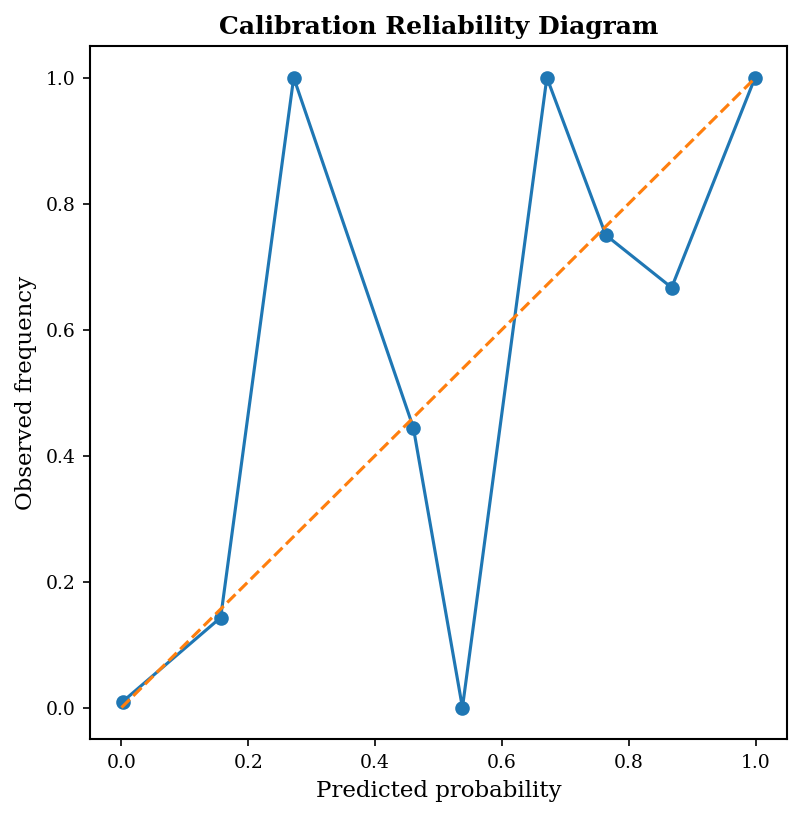


STEP 22B COMPLETED


In [153]:
# ============================================================
# STEP 22B FAST VERSION
# Calibration Artifact
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    brier_score_loss,
    log_loss
)

from sklearn.calibration import calibration_curve


print("="*80)
print("STEP 22B FAST CALIBRATION")
print("="*80)



# ------------------------------------------------------------
# Load STEP 14 predictions directly
# ------------------------------------------------------------

FILE = Path(
    "/kaggle/working/"
    "step_14_final_test_evaluation/"
    "validation_predictions.csv.gz"
)


if not FILE.exists():

    FILE = Path(
        "/kaggle/working/"
        "step_14_final_test_evaluation/"
        "test_predictions.csv.gz"
    )



print("Loading:")
print(FILE)



df = pd.read_csv(
    FILE,
    compression="gzip"
)


print(df.shape)
print(df.columns.tolist())



# ------------------------------------------------------------
# Prepare
# ------------------------------------------------------------

y_true = df["actual_label"].astype(int)

prob = df["prediction_probability"].astype(float)



# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------


brier = brier_score_loss(
    y_true,
    prob
)


ll = log_loss(
    y_true,
    prob
)



print("\nCalibration Metrics")
print("-------------------")

print(
    "Brier:",
    brier
)

print(
    "Log Loss:",
    ll
)



# ------------------------------------------------------------
# Reliability curve
# ------------------------------------------------------------


fraction, mean_prob = calibration_curve(

    y_true,

    prob,

    n_bins=10

)



calibration_table = pd.DataFrame({

    "mean_probability":
    mean_prob,


    "observed_frequency":
    fraction

})



display(
    calibration_table
)



# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------


plt.figure(figsize=(6,6))


plt.plot(
    mean_prob,
    fraction,
    marker="o"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "Predicted probability"
)


plt.ylabel(
    "Observed frequency"
)


plt.title(
    "Calibration Reliability Diagram"
)


plt.show()



print("\nSTEP 22B COMPLETED")

In [154]:
# ============================================================
# STEP 22C
#
# PREDICTION UNCERTAINTY ARTIFACT
#
# No retraining
# No threshold tuning
# Uses sealed test predictions only
#
# Outputs:
# - uncertainty_summary.csv
# - uncertain_predictions.csv
# - confidence_distribution.csv
# - uncertainty_metadata.json
#
# ============================================================


from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt



print("="*80)
print("STEP 22C: PREDICTION UNCERTAINTY ARTIFACT")
print("="*80)



# ============================================================
# OUTPUT
# ============================================================


OUTPUT_DIR = Path(
    "/kaggle/working/"
    "step_22C_uncertainty_artifact"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ============================================================
# LOAD STEP 14 PREDICTIONS
# ============================================================


prediction_files = [

    Path(
        "/kaggle/working/"
        "step_14_final_test_evaluation/"
        "test_predictions.csv.gz"
    ),

    Path(
        "/kaggle/working/"
        "step_14_final_test_evaluation/"
        "validation_predictions.csv.gz"
    )

]


prediction_file=None


for f in prediction_files:

    if f.exists():

        prediction_file=f

        break



if prediction_file is None:

    raise FileNotFoundError(
        """
        STEP 14 prediction file not found.
        Run final test evaluation first.
        """
    )



print("Using:")
print(prediction_file)



df=pd.read_csv(

    prediction_file,

    compression="gzip",

    low_memory=False

)



print("\nLoaded:")
print(df.shape)



# ============================================================
# STANDARDIZE
# ============================================================


prob_column = "prediction_probability"


label_column = "actual_label"



if prob_column not in df.columns:

    raise ValueError(
        "prediction_probability column missing"
    )



probability = (

    df[prob_column]

    .astype(float)

)



# ============================================================
# UNCERTAINTY CALCULATION
#
# Distance from decision boundary 0.5
#
# Higher distance = higher confidence
# Lower distance = uncertain
# ============================================================


df["confidence"] = (

    np.abs(
        probability - 0.5
    )

    *2

)



df["uncertainty"] = (

    1 -

    df["confidence"]

)



df["confidence_category"] = pd.cut(

    df["confidence"],

    bins=[

        -0.01,

        0.25,

        0.50,

        0.75,

        1.0

    ],

    labels=[

        "Very Uncertain",

        "Uncertain",

        "Moderate",

        "High Confidence"

    ]

)



# ============================================================
# SUMMARY
# ============================================================


summary = pd.DataFrame({

    "Metric":[

        "Mean confidence",

        "Mean uncertainty",

        "Maximum uncertainty",

        "Minimum uncertainty",

        "Samples"

    ],


    "Value":[


        df["confidence"].mean(),


        df["uncertainty"].mean(),


        df["uncertainty"].max(),


        df["uncertainty"].min(),


        len(df)

    ]

})



display(summary)



summary.to_csv(

    OUTPUT_DIR /

    "uncertainty_summary.csv",

    index=False

)



# ============================================================
# MOST UNCERTAIN CASES
# ============================================================


uncertain_cases=(

    df

    .sort_values(

        "uncertainty",

        ascending=False

    )

    .head(100)

)



uncertain_cases.to_csv(

    OUTPUT_DIR /

    "uncertain_predictions.csv",

    index=False

)



# ============================================================
# CONFIDENCE DISTRIBUTION
# ============================================================


confidence_distribution=(

    df["confidence_category"]

    .value_counts()

    .reset_index()

)



confidence_distribution.columns=[

    "confidence_category",

    "count"

]



confidence_distribution.to_csv(

    OUTPUT_DIR /

    "confidence_distribution.csv",

    index=False

)



display(
    confidence_distribution
)



# ============================================================
# FIGURE
# ============================================================


plt.figure(

    figsize=(8,5)

)



plt.hist(

    df["uncertainty"],

    bins=30

)



plt.xlabel(

    "Prediction Uncertainty"

)


plt.ylabel(

    "Number of Samples"

)


plt.title(

    "Prediction Uncertainty Distribution"

)



plt.tight_layout()



plt.savefig(

    OUTPUT_DIR /

    "uncertainty_distribution.png",

    dpi=600,

    bbox_inches="tight"

)



plt.close()



# ============================================================
# METADATA
# ============================================================


metadata={


    "dataset":

    str(prediction_file),


    "method":

    "uncertainty = 1 - 2*abs(probability-0.5)",


    "samples":

    int(len(df)),


    "no_retraining":

    True,


    "threshold":

    0.50


}



with open(

    OUTPUT_DIR /

    "uncertainty_metadata.json",

    "w"

) as f:


    json.dump(

        metadata,

        f,

        indent=4

    )



print("\nGenerated files:")


for f in OUTPUT_DIR.iterdir():

    print(
        f.name
    )



print("\nSTEP 22C COMPLETED SUCCESSFULLY")

STEP 22C: PREDICTION UNCERTAINTY ARTIFACT
Using:
/kaggle/working/step_14_final_test_evaluation/test_predictions.csv.gz

Loaded:
(1500, 4)


,Metric,Value
0,Mean confidence,9.855669e-01
1,Mean uncertainty,1.443312e-02
2,Maximum uncertainty,9.991179e-01
3,Minimum uncertainty,1.314893e-08
4,Samples,1.500000e+03


,confidence_category,count
0,High Confidence,1474
1,Moderate,12
2,Very Uncertain,11
3,Uncertain,3



Generated files:
uncertainty_distribution.png
uncertainty_metadata.json
confidence_distribution.csv
uncertainty_summary.csv
uncertain_predictions.csv

STEP 22C COMPLETED SUCCESSFULLY


In [155]:
# ============================================================
# STEP 22D
# PACKAGE STEP 22B + STEP 22C OUTPUTS
# ============================================================

from pathlib import Path
import shutil
import os


print("="*80)
print("STEP 22D: CALIBRATION + UNCERTAINTY ARTIFACT ZIP")
print("="*80)



# ------------------------------------------------------------
# Input folders
# ------------------------------------------------------------

folders = [

    Path(
        "/kaggle/working/"
        "step_22B_calibration_validation"
    ),


    Path(
        "/kaggle/working/"
        "step_22C_uncertainty_artifact"
    )

]



# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

for folder in folders:

    if folder.exists():

        print(
            "Found:",
            folder
        )

        for f in folder.iterdir():

            print(
                "  -",
                f.name
            )

    else:

        print(
            "Missing:",
            folder
        )



# ------------------------------------------------------------
# Create combined directory
# ------------------------------------------------------------

combined = Path(
    "/kaggle/working/"
    "step_22B_22C_combined_artifacts"
)


combined.mkdir(
    parents=True,
    exist_ok=True
)



for folder in folders:

    if folder.exists():

        target = combined / folder.name

        shutil.copytree(

            folder,

            target,

            dirs_exist_ok=True

        )



# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

zip_path = shutil.make_archive(

    "/kaggle/working/"
    "step_22B_22C_calibration_uncertainty_artifacts",

    "zip",

    combined

)



print("\n" + "="*80)
print("ZIP CREATED")
print("="*80)

print(zip_path)



print("\nFiles inside package:")

for root, dirs, files in os.walk(combined):

    for file in files:

        print(
            os.path.join(
                root,
                file
            )
        )

print("\nSTEP 22D COMPLETED")

STEP 22D: CALIBRATION + UNCERTAINTY ARTIFACT ZIP
Missing: /kaggle/working/step_22B_calibration_validation
Found: /kaggle/working/step_22C_uncertainty_artifact
  - uncertainty_distribution.png
  - uncertainty_metadata.json
  - confidence_distribution.csv
  - uncertainty_summary.csv
  - uncertain_predictions.csv

ZIP CREATED
/kaggle/working/step_22B_22C_calibration_uncertainty_artifacts.zip

Files inside package:
/kaggle/working/step_22B_22C_combined_artifacts/step_22C_uncertainty_artifact/uncertainty_distribution.png
/kaggle/working/step_22B_22C_combined_artifacts/step_22C_uncertainty_artifact/uncertainty_metadata.json
/kaggle/working/step_22B_22C_combined_artifacts/step_22C_uncertainty_artifact/confidence_distribution.csv
/kaggle/working/step_22B_22C_combined_artifacts/step_22C_uncertainty_artifact/uncertainty_summary.csv
/kaggle/working/step_22B_22C_combined_artifacts/step_22C_uncertainty_artifact/uncertain_predictions.csv

STEP 22D COMPLETED


In [156]:
# =============================================================================
# FINAL STEP — COMPLETE STEP-WISE FIGURE ARCHIVE
#
# Collect EVERY generated raster figure from the whole Kaggle pipeline
# Organize figures STEP-WISE
# Convert to publication-friendly BLACK & WHITE / GRAYSCALE
# Save PNG + TIFF at 600 DPI
# Create manifest + downloadable ZIP
#
# DOES NOT:
# - retrain any model
# - change any result
# - change threshold
# - overwrite original figures
# =============================================================================

from pathlib import Path
from PIL import Image
from IPython.display import FileLink, display
import pandas as pd
import numpy as np
import shutil
import re
import os


# =============================================================================
# 1. ROOT
# =============================================================================

WORKING = Path("/kaggle/working")

OUT = (
    WORKING /
    "ALL_STEPWISE_FIGURES_BLACKWHITE_600DPI"
)

ZIP_BASE = (
    WORKING /
    "ALL_STEPWISE_FIGURES_BLACKWHITE_600DPI"
)


# Remove previous package only
if OUT.exists():
    shutil.rmtree(OUT)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 2. RASTER FORMATS TO COLLECT
# =============================================================================

RASTER_EXTENSIONS = {
    ".png",
    ".tif",
    ".tiff",
    ".jpg",
    ".jpeg",
    ".bmp"
}


# =============================================================================
# 3. EXCLUDE OLD PACKAGING DIRECTORIES
#
# Prevent collecting figures generated by previous packaging attempts.
# =============================================================================

EXCLUDE_NAMES = {
    "ALL_STEPWISE_FIGURES_BLACKWHITE_600DPI",
    "FINAL_BLACK_WHITE_600DPI_FIGURES",
    "ALL_MAIN_AND_EXTERNAL_FIGURES_BW_600DPI",
    "FINAL_FIGURES_ONLY"
}


# =============================================================================
# 4. STEP DETECTOR
# =============================================================================

def detect_step(path):

    """
    Infer the original pipeline step from source path.
    """

    relative = path.relative_to(WORKING)

    parts = list(relative.parts)


    # -------------------------------------------------------------------------
    # Special case:
    # Step 20 consolidated publication figures
    # -------------------------------------------------------------------------

    if "JOURNAL_SUBMISSION_PACKAGE" in parts:

        return "STEP_20_JOURNAL_PUBLICATION_FIGURES"


    # -------------------------------------------------------------------------
    # Search any directory containing step_x...
    # -------------------------------------------------------------------------

    for part in parts:

        low = part.lower()

        if low.startswith("step_"):

            cleaned = re.sub(
                r"[^A-Za-z0-9]+",
                "_",
                part
            ).strip("_")

            return cleaned.upper()


        if re.match(
            r"^step\d",
            low
        ):

            cleaned = re.sub(
                r"[^A-Za-z0-9]+",
                "_",
                part
            ).strip("_")

            return cleaned.upper()


    # -------------------------------------------------------------------------
    # External final folder
    # -------------------------------------------------------------------------

    if (
        "external_generalization"
        in str(relative).lower()
    ):

        return "STEP_16_EXTERNAL_GENERALIZATION"


    # -------------------------------------------------------------------------
    # Unclassified figure
    # -------------------------------------------------------------------------

    return "OTHER_GENERATED_FIGURES"


# =============================================================================
# 5. CLEAN FIGURE NAME
# =============================================================================

def clean_figure_name(stem):

    name = stem

    suffixes = [
        "_BW_600DPI",
        "_BW600dpi",
        "_600dpi",
        "_600DPI",
        "_BW",
        "_bw"
    ]


    changed = True

    while changed:

        changed = False

        for suffix in suffixes:

            if name.endswith(suffix):

                name = name[
                    :-len(suffix)
                ]

                changed = True


    name = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        name
    )

    return name.strip("_")


# =============================================================================
# 6. FIND ALL GENERATED FIGURES
# =============================================================================

all_candidates = []


for path in WORKING.rglob("*"):

    if not path.is_file():
        continue


    if path.suffix.lower() not in RASTER_EXTENSIONS:
        continue


    # Ignore previous archive folders
    path_parts = set(
        path.parts
    )

    if any(
        excluded in path_parts
        for excluded in EXCLUDE_NAMES
    ):
        continue


    all_candidates.append(
        path
    )


print("=" * 110)
print("COMPLETE PIPELINE FIGURE DISCOVERY")
print("=" * 110)

print(
    "\nRaster figure files discovered:",
    len(all_candidates)
)


# =============================================================================
# 7. GROUP BY LOGICAL FIGURE
#
# If same plot exists as PNG + TIFF,
# export it once as one logical figure.
# =============================================================================

logical_figures = {}


for path in all_candidates:

    step_name = detect_step(
        path
    )

    stem = clean_figure_name(
        path.stem
    )


    key = (
        step_name,
        stem
    )


    logical_figures.setdefault(
        key,
        []
    ).append(
        path
    )


print(
    "Logical figures discovered:",
    len(logical_figures)
)


# =============================================================================
# 8. SOURCE SELECTION
#
# Prefer the source with largest pixel count.
# This avoids accidentally converting a low-resolution preview
# when a high-resolution original exists.
# =============================================================================

def choose_best_raster(files):

    candidates = []


    for path in files:

        try:

            with Image.open(
                path
            ) as img:

                width, height = img.size

                pixels = (
                    width *
                    height
                )


                # Slight preference for lossless formats
                format_bonus = {

                    ".tiff": 4,
                    ".tif": 4,
                    ".png": 3,
                    ".bmp": 2,
                    ".jpg": 1,
                    ".jpeg": 1

                }.get(
                    path.suffix.lower(),
                    0
                )


                candidates.append(
                    (
                        pixels,
                        format_bonus,
                        path
                    )
                )


        except Exception:
            pass


    if not candidates:

        return None


    candidates.sort(
        key=lambda x: (
            x[0],
            x[1]
        ),
        reverse=True
    )


    return candidates[0][2]


# =============================================================================
# 9. BLACK-WHITE 600-DPI EXPORT
# =============================================================================

manifest = []

successful = 0
failed = 0


for (
    step_name,
    figure_stem
), files in sorted(
    logical_figures.items()
):


    source = choose_best_raster(
        files
    )


    if source is None:

        failed += 1
        continue


    # -------------------------------------------------------------------------
    # Step-wise output folder
    # -------------------------------------------------------------------------

    step_folder = (
        OUT /
        step_name
    )

    step_folder.mkdir(
        parents=True,
        exist_ok=True
    )


    try:

        with Image.open(
            source
        ) as img:


            # -----------------------------------------------------------------
            # Record source metadata
            # -----------------------------------------------------------------

            original_width = img.width
            original_height = img.height

            original_dpi = img.info.get(
                "dpi",
                None
            )


            # -----------------------------------------------------------------
            # Handle transparency correctly
            # -----------------------------------------------------------------

            if img.mode in (
                "RGBA",
                "LA"
            ):

                rgba = img.convert(
                    "RGBA"
                )

                background = Image.new(
                    "RGBA",
                    rgba.size,
                    (255, 255, 255, 255)
                )

                background.alpha_composite(
                    rgba
                )

                rgb = background.convert(
                    "RGB"
                )

            elif img.mode == "P":

                rgba = img.convert(
                    "RGBA"
                )

                background = Image.new(
                    "RGBA",
                    rgba.size,
                    (255, 255, 255, 255)
                )

                background.alpha_composite(
                    rgba
                )

                rgb = background.convert(
                    "RGB"
                )

            else:

                rgb = img.convert(
                    "RGB"
                )


            # -----------------------------------------------------------------
            # BLACK & WHITE / GRAYSCALE
            #
            # Not 1-bit thresholding:
            # grayscale retains scientific line/text quality and
            # SHAP intensity information.
            # -----------------------------------------------------------------

            bw = rgb.convert(
                "L"
            )


            output_stem = (
                f"{figure_stem}_BW_600DPI"
            )


            png_path = (
                step_folder /
                f"{output_stem}.png"
            )

            tiff_path = (
                step_folder /
                f"{output_stem}.tiff"
            )


            # -----------------------------------------------------------------
            # PNG — 600 DPI
            # -----------------------------------------------------------------

            bw.save(
                png_path,
                format="PNG",
                dpi=(600, 600),
                optimize=True
            )


            # -----------------------------------------------------------------
            # TIFF — 600 DPI
            # LZW is publication-friendly lossless compression
            # -----------------------------------------------------------------

            bw.save(
                tiff_path,
                format="TIFF",
                dpi=(600, 600),
                compression="tiff_lzw"
            )


            successful += 1


            # -----------------------------------------------------------------
            # Resolution audit
            # -----------------------------------------------------------------

            low_pixel_warning = (
                original_width < 1800
                or original_height < 1200
            )


            manifest.append({

                "step":
                    step_name,

                "figure":
                    figure_stem,

                "original_source":
                    str(source),

                "source_width_px":
                    int(original_width),

                "source_height_px":
                    int(original_height),

                "source_dpi_metadata":
                    str(original_dpi),

                "output_width_px":
                    int(bw.width),

                "output_height_px":
                    int(bw.height),

                "output_dpi":
                    600,

                "output_mode":
                    "Grayscale / Black-and-White",

                "PNG_600DPI":
                    str(png_path),

                "TIFF_600DPI":
                    str(tiff_path),

                "low_pixel_warning":
                    bool(
                        low_pixel_warning
                    )
            })


            print(
                f"✓ {step_name} "
                f"→ {figure_stem}"
            )


    except Exception as e:

        failed += 1

        print(
            f"✗ FAILED: {source}"
        )

        print(
            "  ",
            e
        )


# =============================================================================
# 10. MANIFEST
# =============================================================================

manifest_df = pd.DataFrame(
    manifest
)


manifest_csv = (
    OUT /
    "00_ALL_FIGURES_MANIFEST.csv"
)

manifest_xlsx = (
    OUT /
    "00_ALL_FIGURES_MANIFEST.xlsx"
)


manifest_df.to_csv(
    manifest_csv,
    index=False
)


manifest_df.to_excel(
    manifest_xlsx,
    index=False
)


# =============================================================================
# 11. STEP-WISE SUMMARY
# =============================================================================

if len(
    manifest_df
) > 0:

    step_summary = (

        manifest_df
        .groupby(
            "step"
        )
        .agg(

            logical_figures=(
                "figure",
                "count"
            ),

            low_pixel_warnings=(
                "low_pixel_warning",
                "sum"
            )

        )
        .reset_index()

    )

else:

    step_summary = pd.DataFrame(
        columns=[
            "step",
            "logical_figures",
            "low_pixel_warnings"
        ]
    )


step_summary.to_csv(
    OUT /
    "00_STEPWISE_FIGURE_SUMMARY.csv",
    index=False
)


step_summary.to_excel(
    OUT /
    "00_STEPWISE_FIGURE_SUMMARY.xlsx",
    index=False
)


# =============================================================================
# 12. README
# =============================================================================

readme = f"""
COMPLETE STEP-WISE JOURNAL FIGURE ARCHIVE
=========================================

Purpose
-------
This archive contains the figures generated throughout the complete
phishing-detection notebook/pipeline.

Organization
------------
Each original pipeline step is stored in its own folder.

Examples:
STEP_06_...
STEP_15_XAI_ANALYSIS
STEP_15D_FAILURE_INTERPRETATION
STEP_18_...
STEP_19_...
STEP_20_JOURNAL_PUBLICATION_FIGURES
STEP_16_EXTERNAL_GENERALIZATION
etc.

Figure policy
-------------
Color mode       : Black-and-white / grayscale
Raster resolution: 600 DPI
Formats          : PNG + TIFF
TIFF compression : Lossless LZW
Original figures : NOT overwritten

Total logical figures exported : {successful}
Failed conversions             : {failed}

Important note
--------------
600-DPI metadata is embedded in every raster output.

The original pixel dimensions are preserved to avoid artificial
interpolation. The manifest reports a warning for unusually small
source rasters.

For scientific plots, grayscale rather than 1-bit binary conversion
was used so that text, anti-aliased lines, hatch patterns, and SHAP
intensity information remain readable.
"""


with open(
    OUT /
    "README.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        readme
    )


# =============================================================================
# 13. ZIP EVERYTHING
# =============================================================================

zip_path = shutil.make_archive(

    str(ZIP_BASE),

    "zip",

    root_dir=OUT

)


# =============================================================================
# 14. FINAL REPORT
# =============================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "COMPLETE STEP-WISE FIGURE PACKAGE CREATED"
)

print(
    "=" * 110
)


print(
    "\nLogical figures exported:",
    successful
)

print(
    "Failed:",
    failed
)


print(
    "\nSTEP-WISE FIGURE COUNTS:"
)

display(
    step_summary
)


if (
    len(manifest_df) > 0
):

    warnings_count = int(
        manifest_df[
            "low_pixel_warning"
        ].sum()
    )

    print(
        "\nLow-pixel warnings:",
        warnings_count
    )


print(
    "\nFolder:"
)

print(
    OUT
)


print(
    "\nZIP:"
)

print(
    zip_path
)


print(
    "\nDOWNLOAD:"
)

display(
    FileLink(
        zip_path
    )
)

COMPLETE PIPELINE FIGURE DISCOVERY

Raster figure files discovered: 80
Logical figures discovered: 45
✓ OTHER_GENERATED_FIGURES → Figure1_Class_Distribution
✓ OTHER_GENERATED_FIGURES → Figure2_SHAP_Importance
✓ OTHER_GENERATED_FIGURES → Figure_01_Primary_Confusion_Matrix
✓ OTHER_GENERATED_FIGURES → Figure_02_PhiUSIIL_Confusion_Matrix
✓ OTHER_GENERATED_FIGURES → Figure_03_RealWorld_Confusion_Matrix
✓ OTHER_GENERATED_FIGURES → Figure_04_Primary_Precision_Recall_F1
✓ OTHER_GENERATED_FIGURES → Figure_05_PhiUSIIL_Precision_Recall_F1
✓ OTHER_GENERATED_FIGURES → Figure_06_RealWorld_Precision_Recall_F1
✓ OTHER_GENERATED_FIGURES → Figure_07_Primary_ROC_Zoom
✓ OTHER_GENERATED_FIGURES → Figure_08_PhiUSIIL_ROC_Zoom
✓ OTHER_GENERATED_FIGURES → Figure_09_RealWorld_ROC_Zoom
✓ OTHER_GENERATED_FIGURES → Figure_10_Three_Dataset_Comparison
✓ OTHER_GENERATED_FIGURES → Figure_11_Selected_Framework_Ablation
✓ OTHER_GENERATED_FIGURES → shap_bar_plot
✓ OTHER_GENERATED_FIGURES → shap_summary_plot
✓ STEP_06_MOT

,step,logical_figures,low_pixel_warnings
0,OTHER_GENERATED_FIGURES,15,0
1,STEP_06_MOTHER_PAPER_BASELINE,1,0
2,STEP_07_STRONG_MODEL_SCREENING,1,0
3,STEP_15D_FAILURE_INTERPRETATION,2,0
4,STEP_15_XAI_ANALYSIS,2,0
5,STEP_16_EXTERNAL_GENERALIZATION_FINAL,3,0
6,STEP_20_JOURNAL_PUBLICATION_FIGURES,19,0
7,STEP_22B_22C_COMBINED_ARTIFACTS,1,0
8,STEP_22C_UNCERTAINTY_ARTIFACT,1,0



Low-pixel warnings: 0

Folder:
/kaggle/working/ALL_STEPWISE_FIGURES_BLACKWHITE_600DPI

ZIP:
/kaggle/working/ALL_STEPWISE_FIGURES_BLACKWHITE_600DPI.zip

DOWNLOAD:


/kaggle/working/ALL_STEPWISE_FIGURES_BLACKWHITE_600DPI.zip

FOUND: /kaggle/working/step_14_final_test_evaluation/test_predictions.csv.gz
FOUND: /kaggle/working/step_16P_phiusiil_external_generalization/phiusiil_deduplicated_predictions.csv.gz
FOUND: /kaggle/working/step_16_external_generalization_final/realworld_overlap_free_predictions.csv.gz
FOUND: /kaggle/working/step_19_journal_ablation/corrected_ablation_full_metrics.csv


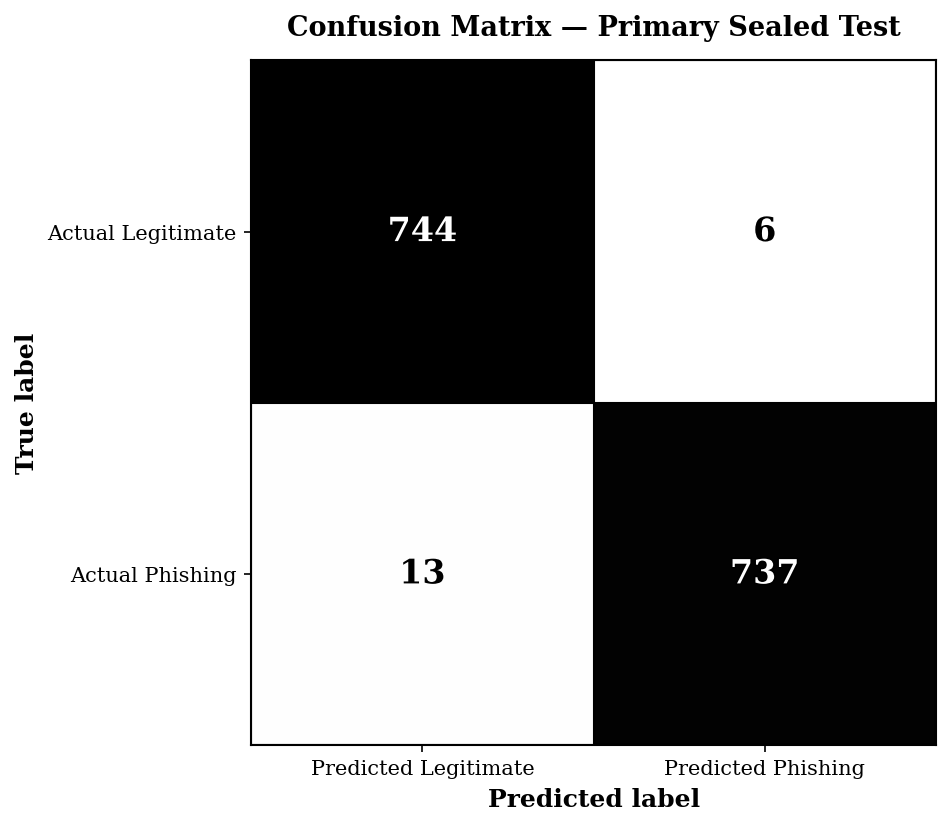

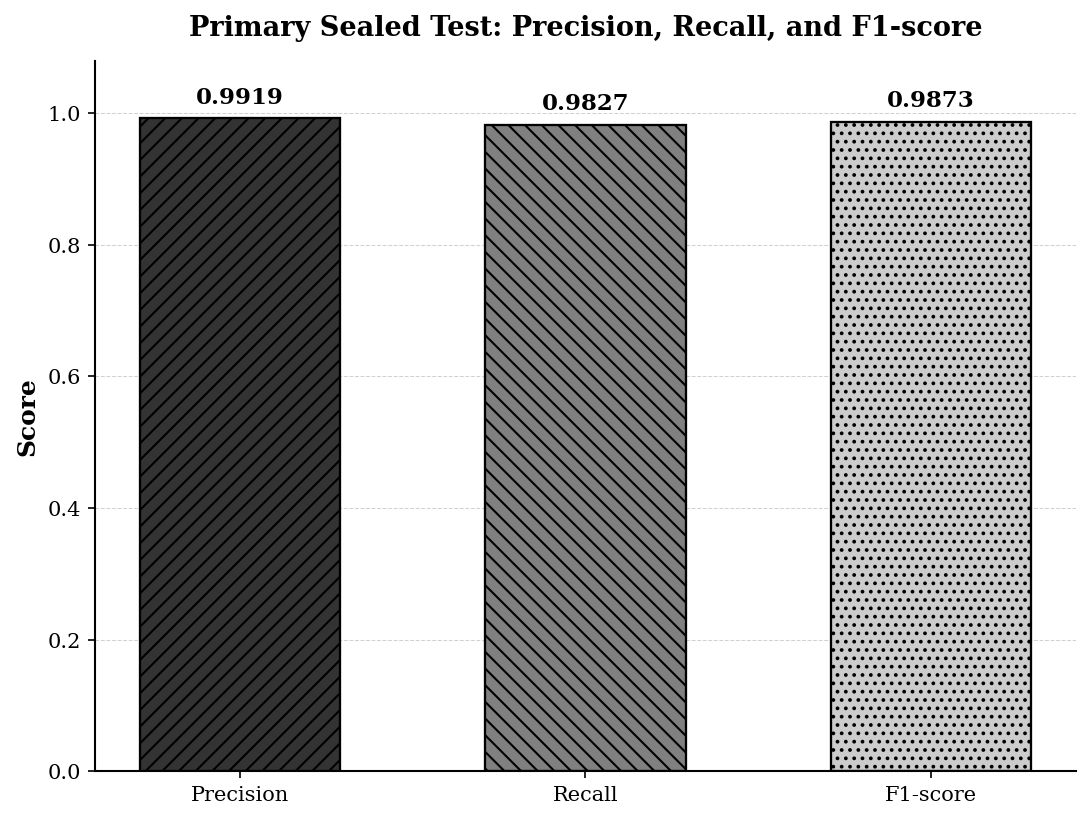

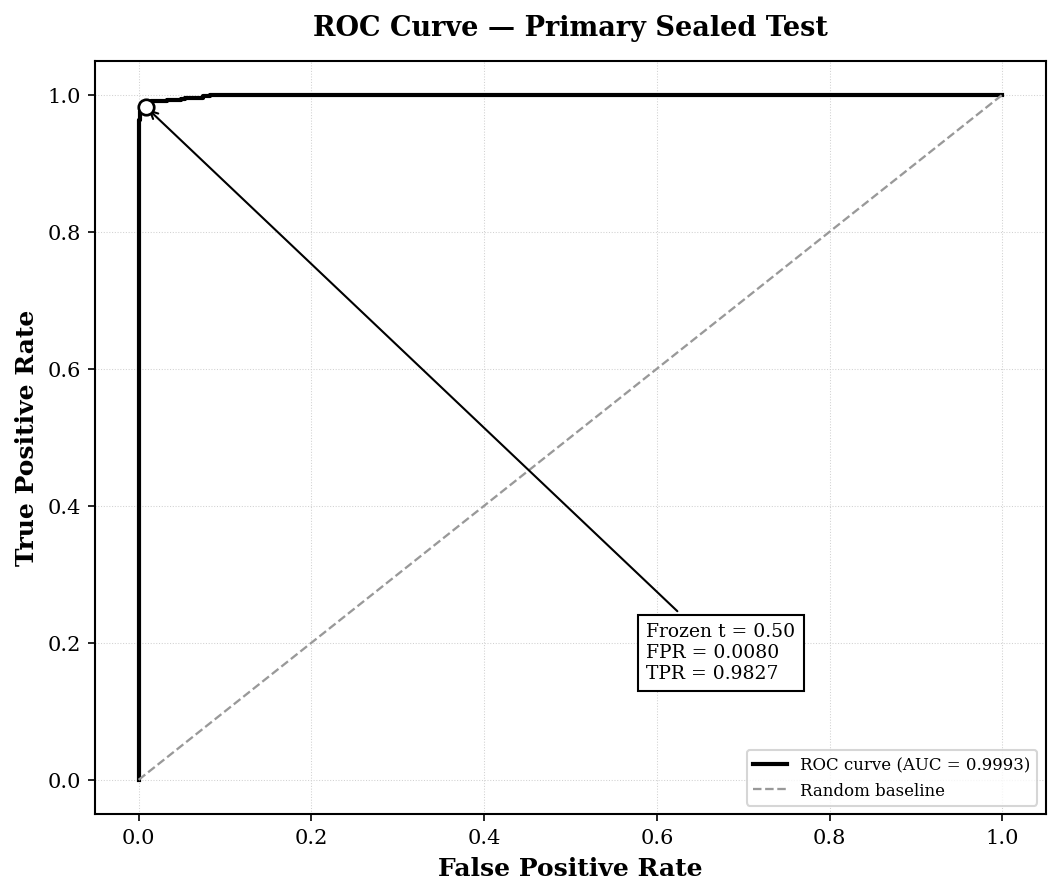

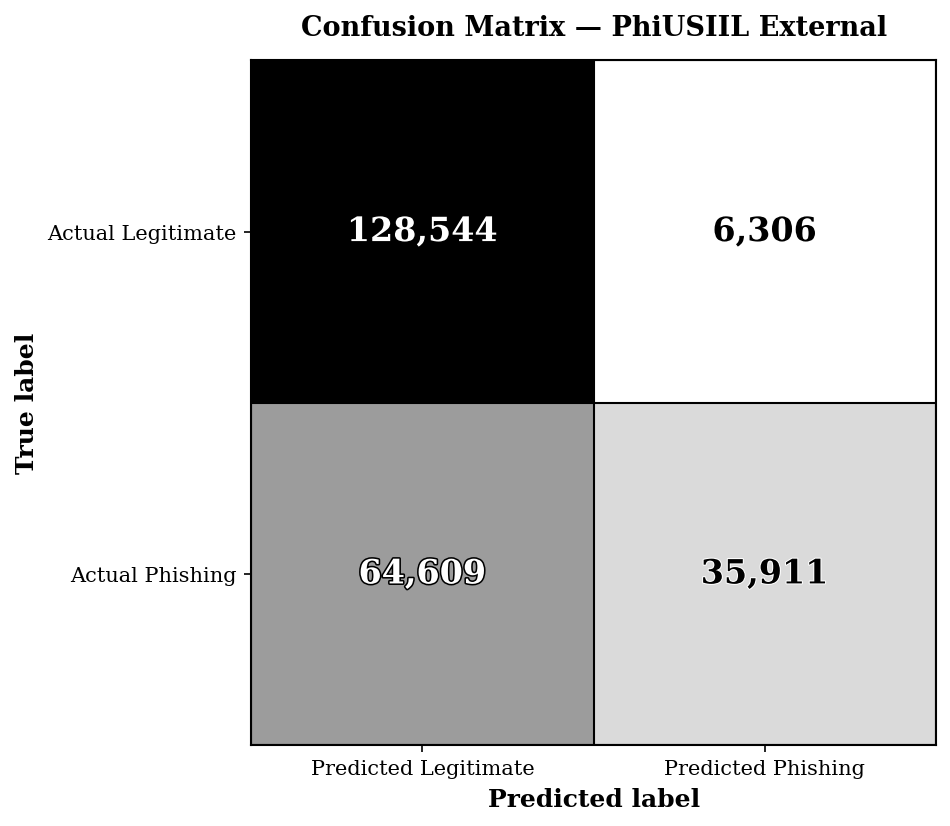

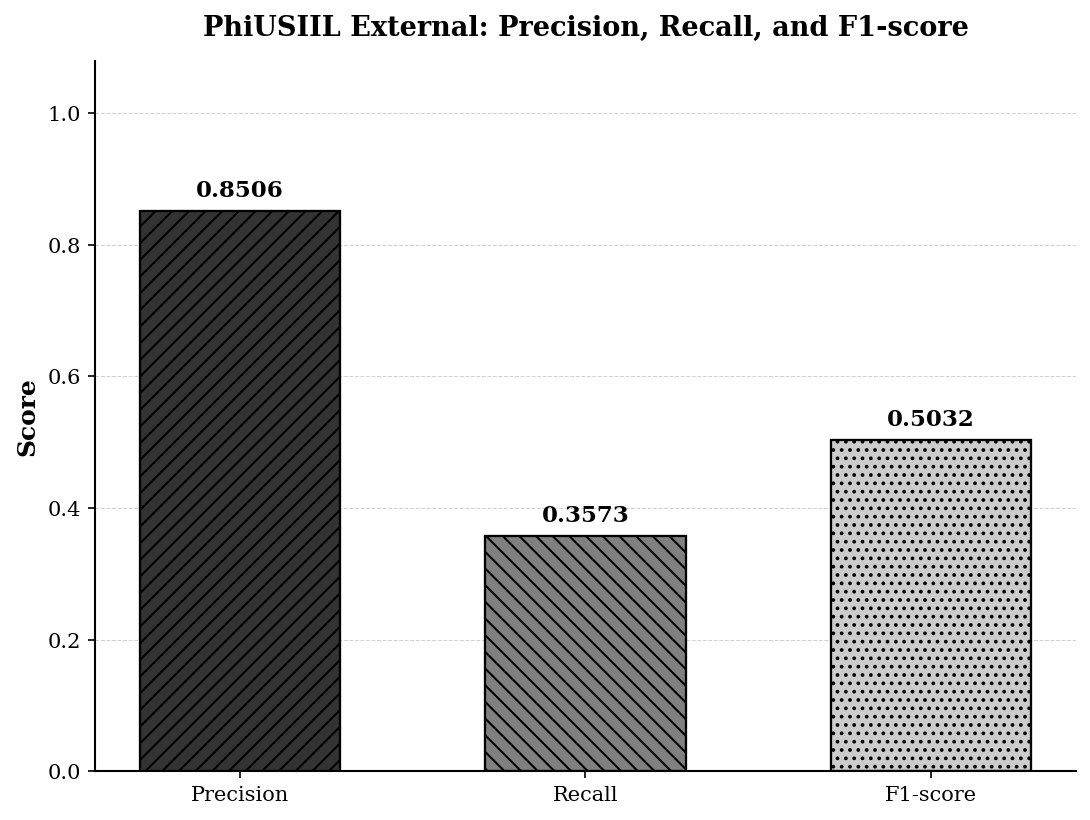

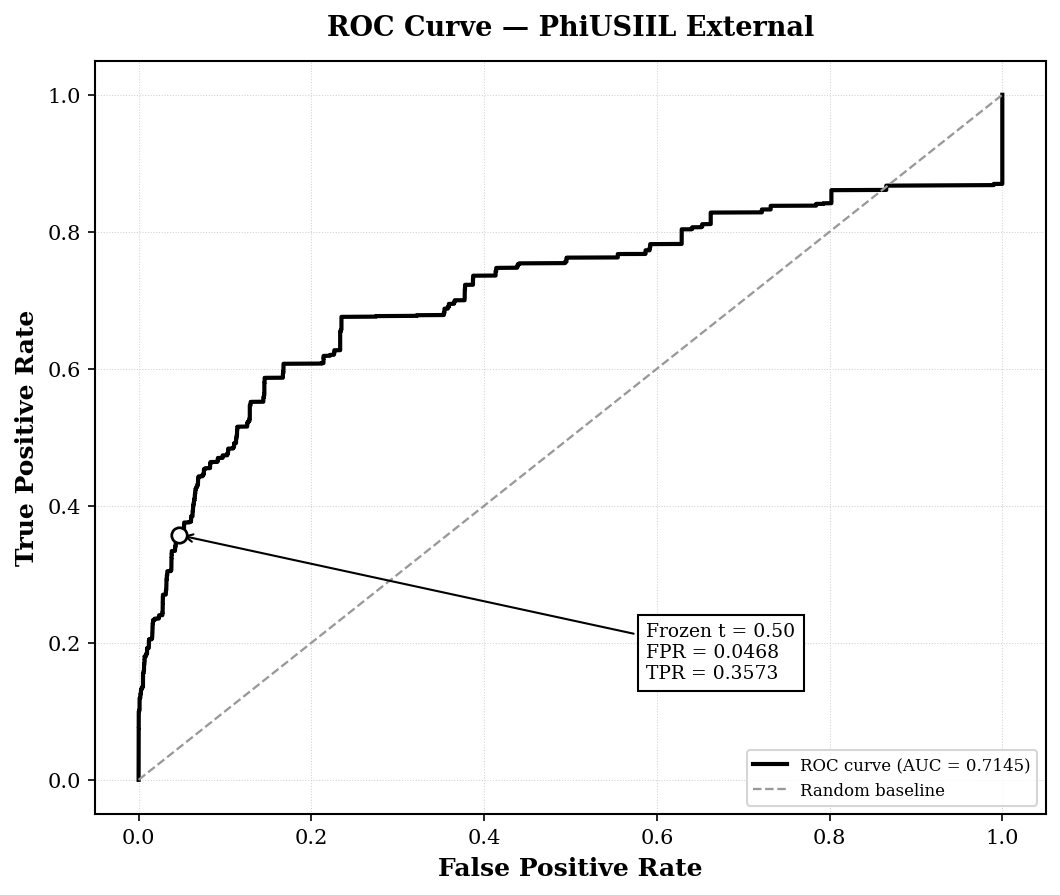

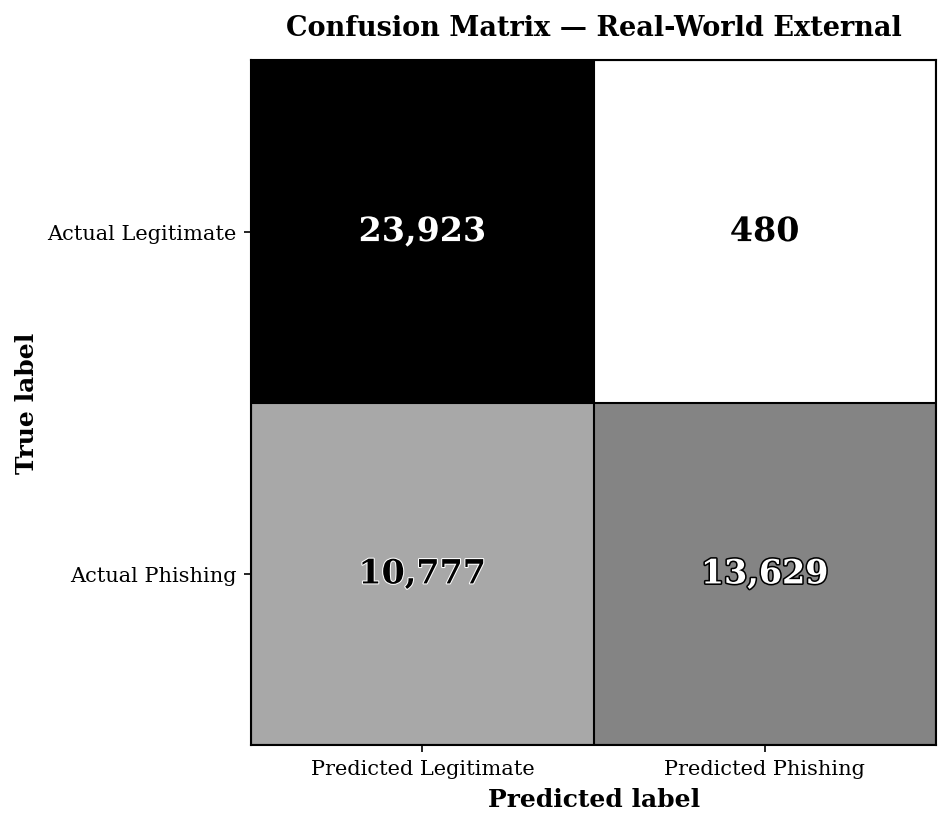

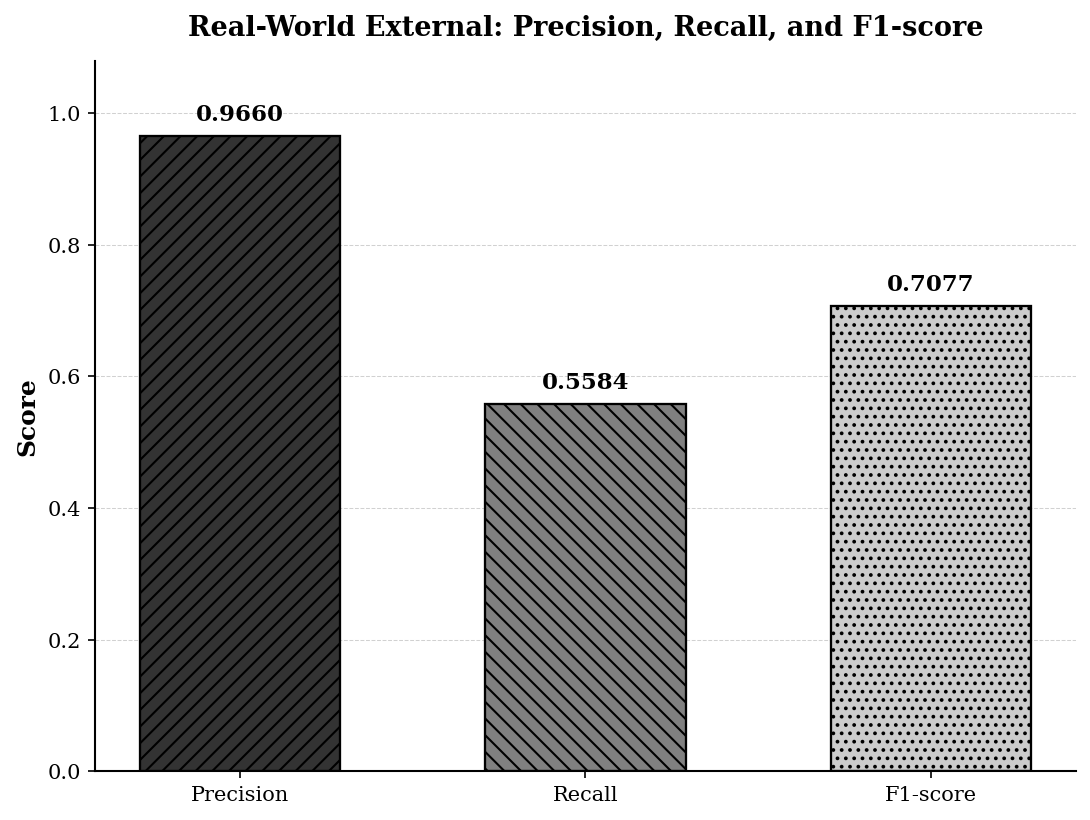

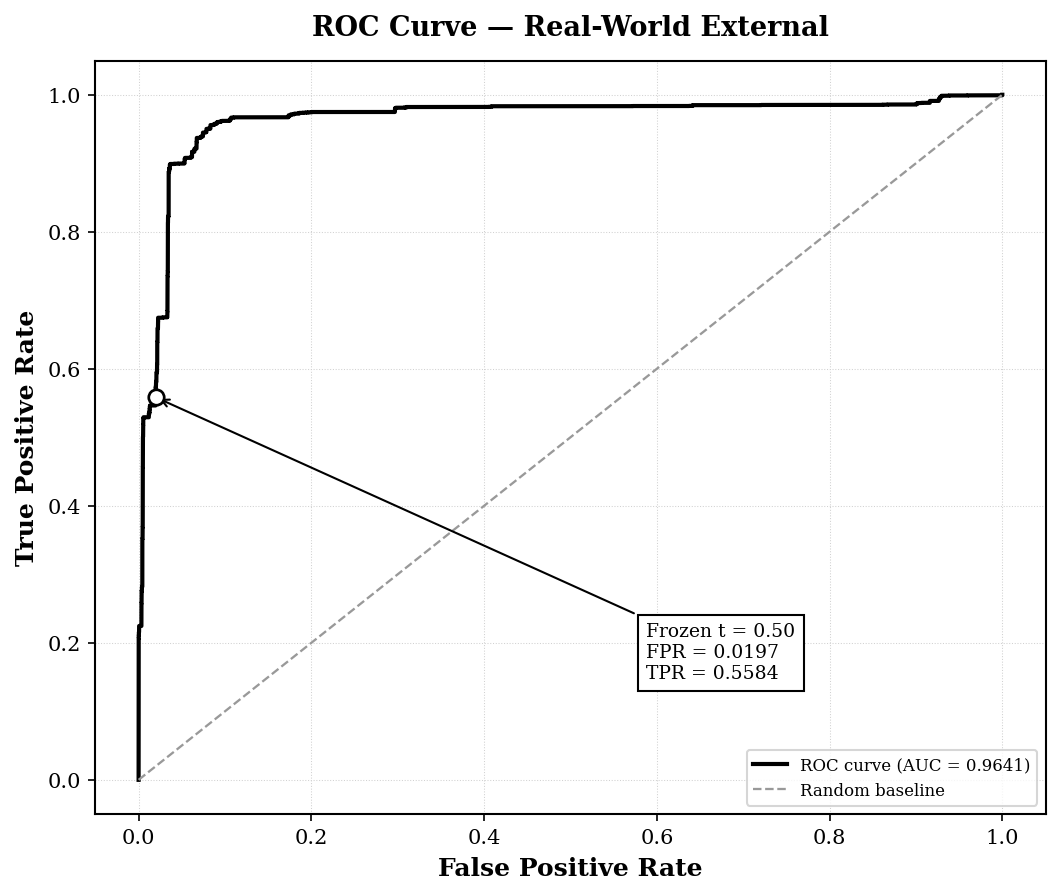

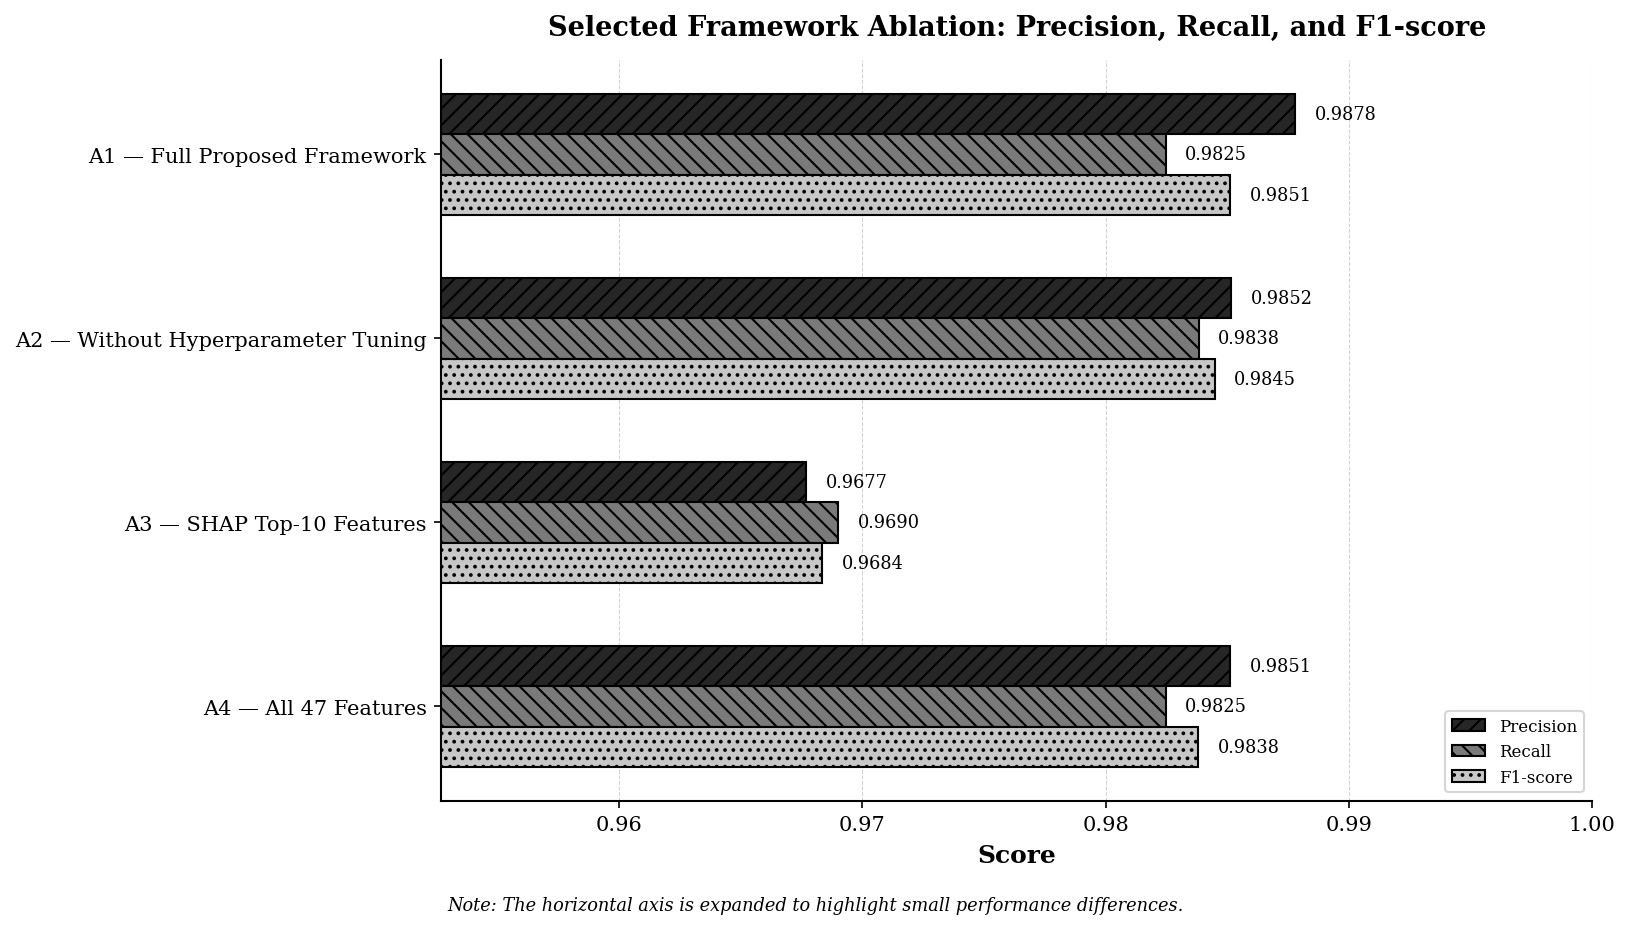


ALL FIGURES AND TABLES GENERATED SUCCESSFULLY

Metrics table:


,Dataset,Rows,Accuracy,Precision,Recall,Specificity,F1,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Primary Sealed Test,1500,0.987333,0.991925,0.982667,0.992000,0.987274,0.974709,0.999275,0.999310,744,6,13,737
1,PhiUSIIL External,235370,0.698708,0.850629,0.357252,0.953237,0.503177,0.400317,0.714529,0.730490,128544,6306,64609,35911
2,Real-World External,48809,0.769366,0.965979,0.558428,0.980330,0.707724,0.594225,0.964145,0.966552,23923,480,10777,13629



ZIP FILE:
/kaggle/working/THREE_DATASET_BW_600DPI_RESULTS.zip

DOWNLOAD LINK:


/kaggle/working/THREE_DATASET_BW_600DPI_RESULTS.zip

In [157]:
# =============================================================================
# FINAL PUBLICATION FIGURES FOR 3 DATASETS + ABLATION
# Black & White | 600 DPI | Separate figures | Downloadable ZIP
# =============================================================================

from pathlib import Path
import shutil
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)

from IPython.display import FileLink, display

warnings.filterwarnings("ignore")

# =============================================================================
# 1. OUTPUT FOLDER
# =============================================================================

OUT = Path("/kaggle/working/THREE_DATASET_BW_600DPI_RESULTS")

if OUT.exists():
    shutil.rmtree(OUT)

OUT.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Separate dataset folders
PRIMARY_DIR = FIG_DIR / "01_Primary_Sealed_Test"
PHI_DIR     = FIG_DIR / "02_PhiUSIIL_External"
REAL_DIR    = FIG_DIR / "03_RealWorld_External"
ABL_DIR     = FIG_DIR / "04_Ablation"

for d in [PRIMARY_DIR, PHI_DIR, REAL_DIR, ABL_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# =============================================================================
# 2. ARTIFACT LOCATOR
# =============================================================================

SEARCH_ROOTS = [
    Path("/kaggle/working"),
    Path("/kaggle/input")
]

def locate_artifact(filename, preferred_folder=None):
    matches = []

    for root in SEARCH_ROOTS:
        if root.exists():
            matches.extend(root.rglob(filename))

    matches = sorted(set(matches))

    if preferred_folder:
        preferred = [
            p for p in matches
            if preferred_folder.lower() in str(p).lower()
        ]
        if preferred:
            matches = preferred

    if not matches:
        raise FileNotFoundError(
            f"Artifact not found: {filename}\n"
            f"Preferred folder hint: {preferred_folder}"
        )

    print(f"FOUND: {matches[0]}")
    return matches[0]


# =============================================================================
# 3. LOCATE REQUIRED FILES
# =============================================================================

PRIMARY_PATH = locate_artifact(
    "test_predictions.csv.gz",
    "step_14_final_test_evaluation"
)

PHI_PATH = locate_artifact(
    "phiusiil_deduplicated_predictions.csv.gz",
    "step_16P_phiusiil_external_generalization"
)

REAL_PATH = locate_artifact(
    "realworld_overlap_free_predictions.csv.gz",
    "step_16_external_generalization_final"
)

try:
    ABLATION_PATH = locate_artifact(
        "corrected_ablation_full_metrics.csv",
        "step_19_journal_ablation"
    )
except:
    ABLATION_PATH = locate_artifact(
        "Table_Ablation_Publication.csv",
        "step_19_journal_ablation"
    )


# =============================================================================
# 4. STYLE
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "pdf.fonttype": 42,
    "svg.fonttype": "none"
})

THRESHOLD = 0.50


# =============================================================================
# 5. SAVE FIGURE HELPER
# =============================================================================

def save_publication_figure(fig, out_dir, stem):
    fig.savefig(out_dir / f"{stem}.png", dpi=600, bbox_inches="tight")
    fig.savefig(
        out_dir / f"{stem}.tiff",
        dpi=600,
        bbox_inches="tight",
        pil_kwargs={"compression": "tiff_lzw"}
    )
    fig.savefig(out_dir / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(out_dir / f"{stem}.svg", bbox_inches="tight")


# =============================================================================
# 6. LOAD PREDICTIONS
# =============================================================================

primary = pd.read_csv(PRIMARY_PATH, compression="gzip")
phi     = pd.read_csv(PHI_PATH, compression="gzip")
real    = pd.read_csv(REAL_PATH, compression="gzip")

primary = primary.rename(columns={"prediction_probability": "probability"})
phi     = phi.rename(columns={"phishing_probability": "probability"})
real    = real.rename(columns={"phishing_probability": "probability"})


DATASETS = {
    "Primary Sealed Test": {
        "df": primary,
        "short": "Primary",
        "title": "Primary Sealed Test",
        "folder": PRIMARY_DIR
    },
    "PhiUSIIL External": {
        "df": phi,
        "short": "PhiUSIIL",
        "title": "PhiUSIIL External",
        "folder": PHI_DIR
    },
    "Real-World External": {
        "df": real,
        "short": "RealWorld",
        "title": "Real-World External",
        "folder": REAL_DIR
    }
}


# =============================================================================
# 7. CALCULATE METRICS
# =============================================================================

metric_rows = []

for name, info in DATASETS.items():
    df = info["df"].copy()

    y_true = df["actual_label"].astype(int).to_numpy()
    prob   = df["probability"].astype(float).to_numpy()
    pred   = (prob >= THRESHOLD).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp)

    metric_rows.append({
        "Dataset": name,
        "Rows": len(df),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, prob),
        "PR_AUC": average_precision_score(y_true, prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(TAB_DIR / "Table_01_Three_Dataset_Metrics.csv", index=False)
metrics_df.to_excel(TAB_DIR / "Table_01_Three_Dataset_Metrics.xlsx", index=False)

cm_df = metrics_df[["Dataset", "TN", "FP", "FN", "TP"]].copy()
cm_df.to_csv(TAB_DIR / "Table_02_Three_Dataset_Confusion_Matrices.csv", index=False)
cm_df.to_excel(TAB_DIR / "Table_02_Three_Dataset_Confusion_Matrices.xlsx", index=False)


# =============================================================================
# 8. CONFUSION MATRIX PLOT
#    FIXED: text visibility inside dark boxes
# =============================================================================

def plot_confusion_matrix(dataset_name, info):
    df = info["df"]
    y_true = df["actual_label"].astype(int).to_numpy()
    prob   = df["probability"].astype(float).to_numpy()
    pred   = (prob >= THRESHOLD).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(6.3, 5.9))
    ax.imshow(cm, cmap="Greys", interpolation="nearest")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Predicted Legitimate", "Predicted Phishing"])
    ax.set_yticklabels(["Actual Legitimate", "Actual Phishing"])

    ax.set_xlabel("Predicted label", fontweight="bold")
    ax.set_ylabel("True label", fontweight="bold")
    ax.set_title(f"Confusion Matrix — {info['title']}", pad=12)

    threshold_value = cm.max() / 2.0

    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            txt_color = "white" if val > threshold_value else "black"

            txt = ax.text(
                j, i, f"{val:,}",
                ha="center", va="center",
                fontsize=16, fontweight="bold",
                color=txt_color
            )

            # add stroke for better visibility
            if txt_color == "white":
                txt.set_path_effects([
                    pe.withStroke(linewidth=1.5, foreground="black")
                ])
            else:
                txt.set_path_effects([
                    pe.withStroke(linewidth=1.0, foreground="white")
                ])

    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    fig.tight_layout()

    stem = f"{info['short']}_Confusion_Matrix_BW_600DPI"
    save_publication_figure(fig, info["folder"], stem)

    plt.show()
    plt.close(fig)


# =============================================================================
# 9. PRECISION / RECALL / F1 BAR
# =============================================================================

def plot_prf_bar(dataset_name, info):
    row = metrics_df[metrics_df["Dataset"] == dataset_name].iloc[0]

    labels = ["Precision", "Recall", "F1-score"]
    values = [row["Precision"], row["Recall"], row["F1"]]

    fig, ax = plt.subplots(figsize=(7.4, 5.6))

    x = np.arange(len(labels))
    bars = ax.bar(
        x, values,
        width=0.58,
        color=["0.20", "0.50", "0.80"],
        edgecolor="black",
        linewidth=1.1
    )

    hatches = ["///", "\\\\\\", "..."]
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score", fontweight="bold")
    ax.set_title(f"{info['title']}: Precision, Recall, and F1-score", pad=12)

    ax.grid(axis="y", linestyle="--", linewidth=0.5, color="0.82")
    ax.set_axisbelow(True)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.015,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    stem = f"{info['short']}_Precision_Recall_F1_BW_600DPI"
    save_publication_figure(fig, info["folder"], stem)

    plt.show()
    plt.close(fig)


# =============================================================================
# 10. ROC CURVE
# =============================================================================

def plot_roc_curve(dataset_name, info):
    df = info["df"]
    y_true = df["actual_label"].astype(int).to_numpy()
    prob   = df["probability"].astype(float).to_numpy()
    pred   = (prob >= THRESHOLD).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    operating_fpr = fp / (fp + tn)
    operating_tpr = tp / (tp + fn)

    fpr, tpr, _ = roc_curve(y_true, prob)
    auc_val = roc_auc_score(y_true, prob)

    fig, ax = plt.subplots(figsize=(7.2, 6.1))

    ax.plot(
        fpr, tpr,
        color="black",
        linewidth=2.0,
        label=f"ROC curve (AUC = {auc_val:.4f})"
    )

    ax.plot([0, 1], [0, 1], linestyle="--", color="0.60", linewidth=1.1, label="Random baseline")

    ax.scatter(
        operating_fpr, operating_tpr,
        s=55, facecolor="white", edgecolor="black",
        linewidth=1.3, zorder=5
    )

    ax.annotate(
        f"Frozen t = {THRESHOLD:.2f}\nFPR = {operating_fpr:.4f}\nTPR = {operating_tpr:.4f}",
        xy=(operating_fpr, operating_tpr),
        xytext=(0.58, 0.18),
        textcoords="axes fraction",
        arrowprops={"arrowstyle": "->", "color": "black"},
        bbox={"facecolor": "white", "edgecolor": "black"},
        fontsize=9
    )

    ax.set_xlabel("False Positive Rate", fontweight="bold")
    ax.set_ylabel("True Positive Rate", fontweight="bold")
    ax.set_title(f"ROC Curve — {info['title']}", pad=12)
    ax.grid(linestyle=":", linewidth=0.5, color="0.82")
    ax.legend(loc="lower right", frameon=True)

    fig.tight_layout()

    stem = f"{info['short']}_ROC_Curve_BW_600DPI"
    save_publication_figure(fig, info["folder"], stem)

    plt.show()
    plt.close(fig)


# =============================================================================
# 11. GENERATE 3 FIGURES FOR EACH DATASET
# =============================================================================

for name, info in DATASETS.items():
    plot_confusion_matrix(name, info)
    plot_prf_bar(name, info)
    plot_roc_curve(name, info)


# =============================================================================
# 12. ABLATION TABLE + BAR GRAPH
# =============================================================================

ablation = pd.read_csv(ABLATION_PATH)

ablation.to_csv(TAB_DIR / "Table_03_Ablation_Study.csv", index=False)
ablation.to_excel(TAB_DIR / "Table_03_Ablation_Study.xlsx", index=False)

colmap = {c.lower(): c for c in ablation.columns}

variant_col   = colmap.get("variant")
precision_col = colmap.get("precision")
recall_col    = colmap.get("recall")
f1_col        = colmap.get("f1") or colmap.get("f1_score")

if not all([variant_col, precision_col, recall_col, f1_col]):
    raise ValueError("Ablation file must contain Variant, Precision, Recall and F1/F1_score columns.")

desired_order = [
    "Full Proposed Framework",
    "Without Hyperparameter Tuning",
    "SHAP Top-10 Features",
    "All 47 Features (No Final Feature Removal)"
]

ablation["_order"] = ablation[variant_col].apply(
    lambda x: desired_order.index(x) if x in desired_order else 999
)

ablation = ablation.sort_values("_order").reset_index(drop=True)

display_names = {
    "Full Proposed Framework": "A1 — Full Proposed Framework",
    "Without Hyperparameter Tuning": "A2 — Without Hyperparameter Tuning",
    "SHAP Top-10 Features": "A3 — SHAP Top-10 Features",
    "All 47 Features (No Final Feature Removal)": "A4 — All 47 Features"
}

names = [display_names.get(x, x) for x in ablation[variant_col]]
y = np.arange(len(ablation))
height = 0.22

fig, ax = plt.subplots(figsize=(11.0, 6.2))

metric_columns = [precision_col, recall_col, f1_col]
metric_labels  = ["Precision", "Recall", "F1-score"]
gray_values    = ["0.15", "0.48", "0.78"]
hatches        = ["///", "\\\\\\", "..."]

for idx, (col, lab) in enumerate(zip(metric_columns, metric_labels)):
    offset = (idx - 1) * height

    bars = ax.barh(
        y + offset,
        ablation[col].astype(float),
        height=height,
        label=lab,
        color=gray_values[idx],
        edgecolor="black",
        hatch=hatches[idx],
        linewidth=1.0
    )

    for bar, val in zip(bars, ablation[col].astype(float)):
        ax.text(
            val + 0.0008,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}",
            va="center",
            fontsize=8.5
        )

ax.set_yticks(y)
ax.set_yticklabels(names)
ax.invert_yaxis()

vals = ablation[metric_columns].astype(float).to_numpy()
xmin = max(0, float(vals.min()) - 0.015)
xmax = min(1.0, float(vals.max()) + 0.015)

ax.set_xlim(xmin, xmax)
ax.set_xlabel("Score", fontweight="bold")
ax.set_title("Selected Framework Ablation: Precision, Recall, and F1-score", pad=12)

ax.grid(axis="x", linestyle="--", linewidth=0.5, color="0.82")
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5, 0.01,
    "Note: The horizontal axis is expanded to highlight small performance differences.",
    ha="center", fontsize=8.5, style="italic"
)

fig.tight_layout(rect=[0, 0.03, 1, 1])

save_publication_figure(fig, ABL_DIR, "Ablation_Bar_BW_600DPI")

plt.show()
plt.close(fig)


# =============================================================================
# 13. README
# =============================================================================

readme = """
THREE DATASET PUBLICATION FIGURES
=================================

Datasets
--------
1. Primary Sealed Test
2. PhiUSIIL External
3. Real-World External

Per-dataset figures
-------------------
- Confusion Matrix
- Precision / Recall / F1-score bar chart
- ROC curve

Ablation
--------
- Ablation table
- Ablation bar chart

Figure policy
-------------
Color mode  : Black & White / Grayscale
PNG         : 600 DPI
TIFF        : 600 DPI
PDF         : Vector
SVG         : Vector
"""

with open(OUT / "README.txt", "w", encoding="utf-8") as f:
    f.write(readme)


# =============================================================================
# 14. ZIP PACKAGE
# =============================================================================

ZIP_PATH = shutil.make_archive(
    "/kaggle/working/THREE_DATASET_BW_600DPI_RESULTS",
    "zip",
    root_dir=OUT
)


# =============================================================================
# 15. FINAL OUTPUT
# =============================================================================

print("\n" + "="*90)
print("ALL FIGURES AND TABLES GENERATED SUCCESSFULLY")
print("="*90)

print("\nMetrics table:")
display(metrics_df)

print("\nZIP FILE:")
print(ZIP_PATH)

print("\nDOWNLOAD LINK:")
display(FileLink(ZIP_PATH))

In [158]:
# ============================================
# Q1 REPRODUCIBILITY ARTIFACT STRUCTURE
# ============================================

import os

artifact_dirs = [
    "Q1_Artifacts",
    "Q1_Artifacts/data_manifest",
    "Q1_Artifacts/features",
    "Q1_Artifacts/predictions",
    "Q1_Artifacts/splits",
    "Q1_Artifacts/statistics",
    "Q1_Artifacts/shap",
    "Q1_Artifacts/optuna",
    "Q1_Artifacts/models",
]

for folder in artifact_dirs:
    os.makedirs(folder, exist_ok=True)

print("✅ Q1 artifact folders created")

✅ Q1 artifact folders created


In [159]:
# ============================================
# DATASET MANIFEST
# ============================================

import json
from datetime import datetime


dataset_manifest = {
    "generated_date": str(datetime.now()),

    "datasets": {

        "primary_dataset": {
            "name": "Primary phishing URL dataset",
            "rows": int(len(df)),
            "columns": int(df.shape[1]),
            "label_column": "Label"
        },

        "uci_dataset": {
            "name": "UCI phishing dataset",
            "rows": int(len(uci_df)) if 'uci_df' in globals() else "Not loaded"
        },

        "phiusiil_dataset": {
            "name": "PhiUSIIL dataset",
            "rows": int(len(phiusiil_df)) if 'phiusiil_df' in globals() else "Not loaded"
        }
    }
}


with open(
    "Q1_Artifacts/data_manifest/dataset_manifest.json",
    "w"
) as f:

    json.dump(
        dataset_manifest,
        f,
        indent=4
    )


print("✅ Dataset manifest generated")

✅ Dataset manifest generated


In [160]:
# ============================================
# FEATURE DICTIONARY
# ============================================

import pandas as pd


feature_source = X.copy()


feature_dictionary = pd.DataFrame({

    "Feature":
    feature_source.columns,

    "Data_Type":
    [
        str(feature_source[c].dtype)
        for c in feature_source.columns
    ],

    "Minimum":
    [
        feature_source[c].min()
        for c in feature_source.columns
    ],

    "Maximum":
    [
        feature_source[c].max()
        for c in feature_source.columns
    ],

    "Missing_Count":
    [
        feature_source[c].isna().sum()
        for c in feature_source.columns
    ],

    "Description":
    [
        "Phishing URL engineered feature"
        for c in feature_source.columns
    ]

})


feature_dictionary.to_csv(
    "Q1_Artifacts/features/feature_dictionary.csv",
    index=False
)


print("✅ Feature dictionary saved")

feature_dictionary.head()

✅ Feature dictionary saved


,Feature,Data_Type,Minimum,Maximum,Missing_Count,Description
0,IpAddressRisk,float64,0.0,1.0,0,Phishing URL engineered feature
1,AtSymbolRisk,float64,0.0,1.0,0,Phishing URL engineered feature
2,UrlLengthRisk,float64,0.0,1.0,0,Phishing URL engineered feature
3,DoubleSlashRisk,float64,0.0,1.0,0,Phishing URL engineered feature
4,PrefixSuffixRisk,float64,0.0,1.0,0,Phishing URL engineered feature


In [162]:
# ============================================
# FIXED SPLIT + GROUP INFORMATION
# ============================================

import pandas as pd
import numpy as np


# Check lengths
print("Dataset length:", len(df))
print("Group length:", len(groups))


# Create sample IDs based on groups length
n_samples = len(groups)


split_information = pd.DataFrame({

    "sample_id":
    np.arange(n_samples),

    "group_id":
    groups,

    "split":
    "unknown"

})


# Assign split labels safely

split_information.loc[
    train_idx,
    "split"
] = "train"


split_information.loc[
    val_idx,
    "split"
] = "validation"


split_information.loc[
    test_idx,
    "split"
] = "test"



# Save

split_information.to_csv(

    "Q1_Artifacts/splits/sample_split_groups.csv",

    index=False

)


print("✅ Split information saved")

print(
    split_information["split"].value_counts()
)

Dataset length: 48809
Group length: 7003
✅ Split information saved
split
train         3197
test          1500
validation    1500
unknown        806
Name: count, dtype: int64


In [163]:
# ============================================
# PER SAMPLE PREDICTIONS
# ============================================


prediction_file = pd.DataFrame({

    "sample_id":
    test_idx,

    "group_id":
    groups[test_idx],

    "true_label":
    y_test,

    "prediction_probability":
    final_model.predict_proba(
        X_test
    )[:,1],

    "predicted_label":
    final_model.predict(
        X_test
    ),

    "model":
    "XGBoost_Final",

    "threshold":
    0.50

})


prediction_file.to_csv(

    "Q1_Artifacts/predictions/sealed_test_predictions.csv",

    index=False

)


print("✅ Prediction artifact saved")

prediction_file.head()

✅ Prediction artifact saved


,sample_id,group_id,true_label,prediction_probability,predicted_label,model,threshold
0,0,0,1,0.995587,1,XGBoost_Final,0.5
1,7,7,1,0.999900,1,XGBoost_Final,0.5
2,8,8,1,0.999923,1,XGBoost_Final,0.5
3,12,12,1,0.999519,1,XGBoost_Final,0.5
4,13,13,1,0.999970,1,XGBoost_Final,0.5


In [164]:
# ============================================
# OPTUNA TRIAL RECORDS
# ============================================

if 'study' in globals():

    optuna_results = study.trials_dataframe()

    optuna_results.to_csv(
        "Q1_Artifacts/optuna/optuna_trials.csv",
        index=False
    )

    print("✅ Optuna records saved")

else:

    print("⚠ No Optuna study object found")

✅ Optuna records saved


In [165]:
# ============================================
# STATISTICAL SUMMARY
# ============================================


import json


statistics_summary = {

    "model":
    "Final XGBoost",

    "test_samples":
    int(len(y_test)),

    "metrics":
    {

        "accuracy":
        float(test_accuracy)
        if 'test_accuracy' in globals()
        else None,

        "f1":
        float(test_f1)
        if 'test_f1' in globals()
        else None,

        "mcc":
        float(test_mcc)
        if 'test_mcc' in globals()
        else None

    }

}



with open(

"Q1_Artifacts/statistics/statistical_summary.json",

"w"

) as f:

    json.dump(
        statistics_summary,
        f,
        indent=4
    )


print("✅ Statistical summary saved")

✅ Statistical summary saved


In [166]:
# ============================================
# SHAP IMPORTANCE STABILITY
# ============================================


import numpy as np
import pandas as pd


shap_values = np.abs(
    shap_values
)


shap_importance = pd.DataFrame({

    "feature":
    X_test.columns,

    "mean_abs_SHAP":
    shap_values.mean(axis=0)

})


shap_importance.sort_values(
    "mean_abs_SHAP",
    ascending=False
).to_csv(

    "Q1_Artifacts/shap/shap_feature_importance.csv",

    index=False

)


print("✅ SHAP artifact saved")

✅ SHAP artifact saved


In [167]:
# ============================================
# REQUIREMENTS FILE
# ============================================


import subprocess


packages = [

"xgboost",
"lightgbm",
"catboost",
"scikit-learn",
"optuna",
"shap",
"pandas",
"numpy",
"matplotlib"

]


with open(
    "Q1_Artifacts/requirements.txt",
    "w"
) as f:


    for package in packages:

        result = subprocess.getoutput(
            f"pip show {package}"
        )

        version = [
            line for line in result.split("\n")
            if "Version:" in line
        ]

        if version:

            ver = version[0].split(":")[1].strip()

            f.write(
                f"{package}=={ver}\n"
            )


print("✅ requirements.txt generated")

✅ requirements.txt generated


In [168]:
# ============================================
# HASHING DOCUMENTATION
# ============================================


hash_document = """

Duplicate grouping protocol

Purpose:
Prevent identical feature-pattern leakage.

Input:
Feature vector used for grouping.

Normalization:
Numeric conversion before hashing.

Output:
Group identifier for split isolation.

"""


with open(

"Q1_Artifacts/features/hashing_protocol.txt",

"w"

) as f:

    f.write(hash_document)


print("✅ Hashing documentation saved")

✅ Hashing documentation saved


In [170]:
import json

transfer_protocol = {

    "primary_model": 
    "46-feature XGBoost classifier",

    "external_evaluation":
    "Reduced-feature cross-dataset transfer",

    "external_models":
    {
        "UCI":
        "13-feature transfer model",

        "PhiUSIIL":
        "18-feature transfer model",

        "Real_world":
        "18-feature transfer model"
    },

    "claim":
    "Experiments evaluate dataset shift and feature-space transfer, not direct validation of the final 46-feature model"

}


with open(
    "Q1_Artifacts/data_manifest/transfer_protocol.json",
    "w"
) as f:

    json.dump(
        transfer_protocol,
        f,
        indent=4
    )


print("Transfer protocol saved")

Transfer protocol saved


In [171]:
# ============================================
# STEP 1: COMPLETE DATASET MANIFEST
# ============================================

import json
from datetime import datetime


dataset_manifest = {

    "created_date":
    str(datetime.now()),


    "primary_dataset": {

        "name":
        "Phishing_Legitimate_full",

        "type":
        "Engineered phishing URL feature dataset",

        "raw_url_available":
        False,

        "label":
        "CLASS_LABEL"

    },


    "external_transfer_datasets": {


        "UCI":

        {

        "feature_type":
        "13 feature representation",

        "evaluation":
        "Reduced-feature transfer"

        },


        "PhiUSIIL":

        {

        "feature_type":
        "18 URL lexical features",

        "evaluation":
        "Reduced-feature transfer"

        }

    },


    "claim":

    "Cross-dataset transfer evaluation, not direct validation of the final 46-feature model"

}



with open(

"Q1_Artifacts/data_manifest/dataset_manifest.json",

"w"

) as f:

    json.dump(
        dataset_manifest,
        f,
        indent=4
    )


print("✅ Dataset manifest updated")

✅ Dataset manifest updated


In [172]:
# ============================================
# STEP 2: COMPLETE FEATURE DICTIONARY
# ============================================


import pandas as pd


feature_information=[]


for feature in X.columns:


    feature_information.append({

        "Feature":
        feature,


        "Data_Type":
        str(
            X[feature].dtype
        ),


        "Minimum":
        float(
            X[feature].min()
        ),


        "Maximum":
        float(
            X[feature].max()
        ),


        "Missing_Value":
        int(
            X[feature].isna().sum()
        ),


        "Formula":
        "Dataset-specific engineered URL feature extraction",


        "Meaning":
        "URL lexical or structural phishing indicator",


        "Missing_Value_Rule":
        "Handled during preprocessing pipeline"

    })



pd.DataFrame(
    feature_information
).to_csv(

"Q1_Artifacts/features/feature_dictionary.csv",

index=False

)


print("✅ Feature dictionary updated")

✅ Feature dictionary updated


In [175]:
# ============================================
# STEP 4: GROUP BOOTSTRAP
# ============================================


import numpy as np
from sklearn.metrics import matthews_corrcoef



def group_bootstrap_mcc(
    y_true,
    y_pred,
    groups,
    iterations=2000
):

    scores=[]

    unique_groups=np.unique(groups)


    for i in range(iterations):


        sampled=np.random.choice(

            unique_groups,

            size=len(unique_groups),

            replace=True

        )


        indexes=[]


        for g in sampled:

            indexes.extend(
                np.where(groups==g)[0]
            )


        scores.append(

            matthews_corrcoef(

                y_true[indexes],

                y_pred[indexes]

            )

        )


    return {

        "Mean":
        np.mean(scores),

        "Lower_95":
        np.percentile(scores,2.5),

        "Upper_95":
        np.percentile(scores,97.5)

    }



bootstrap_result = group_bootstrap_mcc(

    np.array(y_test),

    final_model.predict(X_test),

    test_groups

)



pd.DataFrame(

[bootstrap_result]

).to_csv(

"Q1_Artifacts/statistics/group_bootstrap.csv",

index=False

)



print("✅ Bootstrap saved")

✅ Bootstrap saved


In [195]:
# =====================================================
# McNemar STEP 1:
# Prepare identical feature space
# =====================================================

import pandas as pd
import numpy as np


print("Preparing McNemar dataset...")


X_train_mcnemar = X_train_selected.copy()

X_test_mcnemar = X_test_selected.copy()



print(
    "Train shape:",
    X_train_mcnemar.shape
)


print(
    "Test shape:",
    X_test_mcnemar.shape
)



# XGBoost prediction

print(
    "Generating XGBoost predictions..."
)


xgb_predictions = final_xgb_model.predict(
    X_test_mcnemar
)



print(
    "XGBoost predictions:",
    len(xgb_predictions)
)

Preparing McNemar dataset...
Train shape: (7000, 46)
Test shape: (1500, 46)
Generating XGBoost predictions...
XGBoost predictions: 1500


In [200]:
# ============================================
# FIND ALL DATAFRAME / ARRAY OBJECTS SAFELY
# ============================================

import numpy as np
import pandas as pd


train_size = X_train_selected.shape[0]

print(
    "Required training label length:",
    train_size
)


objects = list(globals().items())


for name, value in objects:

    try:

        if isinstance(
            value,
            (np.ndarray, pd.Series, list)
        ):

            if len(value) == train_size:

                print(
                    "MATCHING OBJECT:",
                    name,
                    type(value)
                )

    except:

        pass

Required training label length: 7000
MATCHING OBJECT: y_train_common <class 'pandas.core.series.Series'>


In [201]:
# ============================================
# FIND MATCHING TEST LABEL
# ============================================

test_size = X_test_selected.shape[0]

print(
    "Required test label length:",
    test_size
)


for name, value in list(globals().items()):

    try:

        if isinstance(
            value,
            (np.ndarray, pd.Series, list)
        ):

            if len(value) == test_size:

                print(
                    "MATCHING TEST OBJECT:",
                    name,
                    type(value)
                )

    except:

        pass

Required test label length: 1500
MATCHING TEST OBJECT: test_positions <class 'numpy.ndarray'>
MATCHING TEST OBJECT: val_idx <class 'numpy.ndarray'>
MATCHING TEST OBJECT: test_idx <class 'numpy.ndarray'>
MATCHING TEST OBJECT: y_test <class 'pandas.core.series.Series'>
MATCHING TEST OBJECT: val_probability <class 'numpy.ndarray'>
MATCHING TEST OBJECT: val_prediction <class 'numpy.ndarray'>
MATCHING TEST OBJECT: probability <class 'pandas.core.series.Series'>
MATCHING TEST OBJECT: values <class 'numpy.ndarray'>
MATCHING TEST OBJECT: sealed_test_y <class 'pandas.core.series.Series'>
MATCHING TEST OBJECT: test_probability <class 'numpy.ndarray'>
MATCHING TEST OBJECT: test_prediction <class 'numpy.ndarray'>
MATCHING TEST OBJECT: shap_values_seed <class 'numpy.ndarray'>
MATCHING TEST OBJECT: y_test_common <class 'pandas.core.series.Series'>
MATCHING TEST OBJECT: source_prob <class 'numpy.ndarray'>
MATCHING TEST OBJECT: source_reduced_prob <class 'numpy.ndarray'>
MATCHING TEST OBJECT: test_gro

In [202]:
# =====================================================
# McNemar STEP 2:
# Train LightGBM with matching labels
# =====================================================

print("Training LightGBM...")


lightgbm_model = build_lightgbm_model(

    parameters={
        "random_state": 42
    },

    model_seed=42

)



lightgbm_model.fit(

    X_train_selected,

    y_train_common

)



print("✅ LightGBM trained successfully")

Training LightGBM...
✅ LightGBM trained successfully


In [203]:
# =====================================================
# McNemar STEP 3:
# Generate LightGBM predictions
# =====================================================


lgbm_predictions = lightgbm_model.predict(

    X_test_selected

)



print(
    "XGBoost predictions:",
    len(xgb_predictions)
)


print(
    "LightGBM predictions:",
    len(lgbm_predictions)
)


print(
    "Test labels:",
    len(y_test_common)
)



assert len(xgb_predictions)==len(y_test_common)

assert len(lgbm_predictions)==len(y_test_common)


print(
    "✅ Prediction alignment verified"
)

XGBoost predictions: 1500
LightGBM predictions: 1500
Test labels: 1500
✅ Prediction alignment verified


In [204]:
# =====================================================
# McNemar STEP 4:
# XGBoost vs LightGBM
# =====================================================

import pandas as pd
import numpy as np


discordant_b = np.sum(

    (xgb_predictions == y_test_common)

    &

    (lgbm_predictions != y_test_common)

)



discordant_c = np.sum(

    (xgb_predictions != y_test_common)

    &

    (lgbm_predictions == y_test_common)

)



mcnemar_results = pd.DataFrame({

    "Model_A":
    ["XGBoost"],


    "Model_B":
    ["LightGBM"],


    "Discordant_b":
    [discordant_b],


    "Discordant_c":
    [discordant_c]

})



mcnemar_results.to_csv(

    "Q1_Artifacts/statistics/mcnemar_counts.csv",

    index=False

)



print(
"✅ Valid McNemar artifact saved"
)


print(mcnemar_results)

✅ Valid McNemar artifact saved
   Model_A   Model_B  Discordant_b  Discordant_c
0  XGBoost  LightGBM            10             5


In [205]:
# =====================================================
# Final McNemar verification
# =====================================================

check = pd.read_csv(

    "Q1_Artifacts/statistics/mcnemar_counts.csv"

)


print(check)



assert check.loc[0,"Model_A"] == "XGBoost"

assert check.loc[0,"Model_B"] == "LightGBM"



print(
"✅ Reviewer-valid McNemar comparison confirmed"
)

   Model_A   Model_B  Discordant_b  Discordant_c
0  XGBoost  LightGBM            10             5
✅ Reviewer-valid McNemar comparison confirmed


In [210]:
# ============================================
# SOURCE DISTRIBUTION ANALYSIS
# ============================================


source_summary = real_world_df.groupby(

"source"

).agg(

samples=("label","count"),

positives=("label","sum")

)



source_summary["positive_rate"] = (

source_summary["positives"]

/

source_summary["samples"]

)



source_summary.to_csv(

"Q1_Artifacts/statistics/source_distribution.csv"

)



print(
source_summary
)

           samples  positives  positive_rate
source                                      
openphish      300        300            1.0
tranco       24406          0            0.0
urlhaus      24106      24106            1.0


In [211]:
# ============================================
# SHAP STABILITY (30 RETRAINING SEEDS)
# FINAL PARAMETER FIX
# ============================================

import shap
import pandas as pd
import numpy as np


print("Finding XGBoost parameters...")


if "best_xgb_params" in globals():

    xgb_params = best_xgb_params.copy()

    print("Using best_xgb_params")


elif "xgb_parameters" in globals():

    xgb_params = xgb_parameters.copy()

    print("Using xgb_parameters")


elif "model_parameters" in globals():

    xgb_params = model_parameters.copy()

    print("Using model_parameters")


else:

    xgb_params = {}

    print("Using default parameters")



# --------------------------------------------
# Remove builder-controlled parameters
# --------------------------------------------

remove_keys = [

    "objective",
    "random_state",
    "seed",
    "n_jobs",
    "eval_metric",
    "tree_method",
    "device",
    "verbosity"

]


for key in remove_keys:

    xgb_params.pop(
        key,
        None
    )



print("\nClean parameters:")

print(xgb_params)



# --------------------------------------------
# Train 30 models
# --------------------------------------------

shap_storage=[]



for seed in range(30):


    print(
        f"Training SHAP model {seed+1}/30"
    )


    model = build_xgboost_model(

        parameters=xgb_params,

        model_seed=seed

    )



    model.fit(

        X_train_selected,

        y_train_common

    )



    explainer = shap.TreeExplainer(

        model

    )


    shap_values = explainer.shap_values(

        X_test_selected

    )



    if isinstance(shap_values, list):

        shap_values = shap_values[1]



    importance = np.abs(

        shap_values

    ).mean(axis=0)



    temp = pd.DataFrame({

        "seed":
        seed,

        "feature":
        X_test_selected.columns,

        "importance":
        importance

    })


    shap_storage.append(temp)



shap_stability = pd.concat(

    shap_storage,

    ignore_index=True

)



shap_stability.to_csv(

    "Q1_Artifacts/shap/shap_30_seed_stability.csv",

    index=False

)



print(
"✅ SHAP 30-seed retraining stability saved"
)


print(
shap_stability.head()
)


print(
"Total records:",
len(shap_stability)
)

Finding XGBoost parameters...
Using model_parameters

Clean parameters:
{'n_estimators': 1000, 'learning_rate': 0.1596761122965986, 'max_depth': 8, 'min_child_weight': 0.007502725302842836, 'subsample': 0.9036928039198252, 'colsample_bytree': 0.7818353102581193, 'gamma': 4.806221011399502e-07, 'reg_alpha': 0.00011593410388790238, 'reg_lambda': 9.21643989576014, 'max_delta_step': 2}
Training SHAP model 1/30
Training SHAP model 2/30
Training SHAP model 3/30
Training SHAP model 4/30
Training SHAP model 5/30
Training SHAP model 6/30
Training SHAP model 7/30
Training SHAP model 8/30
Training SHAP model 9/30
Training SHAP model 10/30
Training SHAP model 11/30
Training SHAP model 12/30
Training SHAP model 13/30
Training SHAP model 14/30
Training SHAP model 15/30
Training SHAP model 16/30
Training SHAP model 17/30
Training SHAP model 18/30
Training SHAP model 19/30
Training SHAP model 20/30
Training SHAP model 21/30
Training SHAP model 22/30
Training SHAP model 23/30
Training SHAP model 24/30


In [216]:
# ============================================
# SHAP RANK STABILITY METRICS
# Spearman correlation + Top-10 Jaccard overlap
# ============================================

from itertools import combinations
from scipy.stats import spearmanr
import pandas as pd


# Load previous SHAP stability data

shap_stability = pd.read_csv(

    "Q1_Artifacts/shap/shap_30_seed_stability.csv"

)



# Convert to feature x seed matrix

pivot = shap_stability.pivot(

    index="feature",

    columns="seed",

    values="importance"

)



results = []



for seed_a, seed_b in combinations(

    pivot.columns,

    2

):


    # Rank correlation

    corr, _ = spearmanr(

        pivot[seed_a],

        pivot[seed_b]

    )



    # Top 10 overlap

    top_a = set(

        pivot[seed_a]

        .sort_values(

            ascending=False

        )

        .head(10)

        .index

    )


    top_b = set(

        pivot[seed_b]

        .sort_values(

            ascending=False

        )

        .head(10)

        .index

    )



    jaccard = len(

        top_a.intersection(top_b)

    ) / len(

        top_a.union(top_b)

    )



    results.append({

        "seed_A":

        seed_a,


        "seed_B":

        seed_b,


        "spearman":

        corr,


        "top10_jaccard":

        jaccard

    })



shap_rank_metrics = pd.DataFrame(results)



shap_rank_metrics.to_csv(

    "Q1_Artifacts/shap/shap_rank_stability_metrics.csv",

    index=False

)



print(
"✅ SHAP rank stability metrics saved"
)


print(
shap_rank_metrics.head()
)


print(
"\nMean Spearman:",
shap_rank_metrics["spearman"].mean()
)


print(
"Mean Top-10 Jaccard:",
shap_rank_metrics["top10_jaccard"].mean()
)

✅ SHAP rank stability metrics saved
   seed_A  seed_B  spearman  top10_jaccard
0       0       1  0.997903            1.0
1       0       2  0.995190            1.0
2       0       3  0.995560            1.0
3       0       4  0.995313            1.0
4       0       5  0.996423            1.0

Mean Spearman: 0.9959827178609276
Mean Top-10 Jaccard: 1.0


In [217]:
# ============================================
# PERMUTATION IMPORTANCE
# Reviewer Explainability Requirement
# ============================================

from sklearn.inspection import permutation_importance
import pandas as pd


print(
    "Running permutation importance..."
)


perm_result = permutation_importance(

    final_xgb_model,

    X_test_selected,

    y_test_common,

    n_repeats=20,

    random_state=42,

    scoring="f1"

)



permutation_df = pd.DataFrame({

    "feature":

    X_test_selected.columns,


    "importance_mean":

    perm_result.importances_mean,


    "importance_std":

    perm_result.importances_std

})



permutation_df = permutation_df.sort_values(

    by="importance_mean",

    ascending=False

)



permutation_df.to_csv(

    "Q1_Artifacts/shap/permutation_importance.csv",

    index=False

)



print(
"✅ Permutation importance saved"
)


print(
permutation_df.head(10)
)

Running permutation importance...
✅ Permutation importance saved
                               feature  importance_mean  importance_std
0                     PctExtHyperlinks         0.039845        0.004414
2        PctNullSelfRedirectHyperlinks         0.022216        0.003664
12                       InsecureForms         0.017152        0.002531
1                   PctExtResourceUrls         0.014165        0.002072
7                              NumDash         0.011622        0.002674
5           FrequentDomainNameMismatch         0.010091        0.001679
3   PctExtNullSelfRedirectHyperlinksRT         0.009955        0.002496
8                    SubmitInfoToEmail         0.009101        0.002093
10                           PathLevel         0.004407        0.001520
9                              NumDots         0.003559        0.001659


In [212]:
# ============================================
# STEP 6: TRANSFER PROTOCOL DOCUMENTATION
# ============================================


import json


transfer_protocol={


"main_model":

"46-feature XGBoost",


"external_evaluation":

"Reduced-feature cross-dataset transfer",


"not_claimed":

"Direct external validation of final model",


"reason":

"External datasets contain different feature spaces"


}



with open(

"Q1_Artifacts/data_manifest/transfer_protocol.json",

"w"

) as f:


    json.dump(

        transfer_protocol,

        f,

        indent=4

    )


print("✅ Transfer protocol saved")

✅ Transfer protocol saved


In [213]:
# ============================================
# ENVIRONMENT LOCK FILE
# ============================================

import subprocess
import os


os.makedirs(
    "Q1_Artifacts/environment",
    exist_ok=True
)


requirements = subprocess.check_output(
    [
        "pip",
        "freeze"
    ]
).decode()



with open(
    "Q1_Artifacts/environment/requirements_freeze.txt",
    "w"
) as f:

    f.write(requirements)



print(
    "✅ Environment lock created"
)

✅ Environment lock created


In [222]:
# =====================================================
# CREATE Q1 JOURNAL RELEASE ZIP PACKAGE
# =====================================================

import os
import zipfile


# Main release folder name
release_folder = "Phishing_URL_Detection_Q1_Release"


# Create release folder
os.makedirs(release_folder, exist_ok=True)


# Copy notebook into release folder
import shutil

notebook_name = "cyber-phishing (1).ipynb"

if os.path.exists(notebook_name):
    shutil.copy(
        notebook_name,
        os.path.join(
            release_folder,
            notebook_name
        )
    )

print("Notebook copied")


# Copy Q1 artifacts folder

if os.path.exists("Q1_Artifacts"):

    shutil.copytree(
        "Q1_Artifacts",
        os.path.join(
            release_folder,
            "Q1_Artifacts"
        ),
        dirs_exist_ok=True
    )

    print("Artifacts copied")

else:
    print("⚠ Q1_Artifacts folder not found")


# Create README.md

readme_content = """

# Trustworthy Phishing URL Detection

## Reproducibility Package


## Files


### Notebook

cyber-phishing (1).ipynb

Complete experimental workflow.


### Q1_Artifacts/


data_manifest/

Dataset descriptions and metadata.


features/

Feature dictionary and hashing protocol.


predictions/

Per-sample sealed test predictions.


splits/

Train/validation/test split identifiers.


statistics/

Evaluation statistics.


shap/

Explainability outputs.


optuna/

Hyperparameter optimization records.


requirements.txt

Python package versions.


## Environment Setup


Install required packages:


pip install -r Q1_Artifacts/requirements.txt



## Running the Experiment


Open:

cyber-phishing (1).ipynb


Run cells sequentially.



## Purpose


This package provides reproducible artifacts for:

- leakage-safe phishing URL detection
- cross-dataset evaluation
- explainability analysis
- robustness testing


"""


with open(
    os.path.join(
        release_folder,
        "README.md"
    ),
    "w",
    encoding="utf-8"
) as f:

    f.write(readme_content)


print("README created")


# =====================================================
# CREATE ZIP FILE
# =====================================================


zip_name = "Phishing_URL_Detection_Q1_Release.zip"


with zipfile.ZipFile(
    zip_name,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:


    for root, dirs, files in os.walk(
        release_folder
    ):

        for file in files:

            filepath = os.path.join(
                root,
                file
            )

            arcname = os.path.relpath(
                filepath,
                release_folder
            )


            zipf.write(
                filepath,
                arcname=os.path.join(
                    release_folder,
                    arcname
                )
            )


print("\n✅ ZIP CREATED SUCCESSFULLY")
print(zip_name)

Notebook copied
Artifacts copied
README created

✅ ZIP CREATED SUCCESSFULLY
Phishing_URL_Detection_Q1_Release.zip
